# Banking Risk Prediction: Predicting Bad Customers

**Objective.** Predict which credit-card applicants become *bad* customers (`Bad_label = 1`) using demographics, account/payment history and credit-enquiry history from three MySQL tables (`Cust_Demographics`, `Cust_Account`, `Cust_Enquiry`).

**Data.** 23,896 customers; 186,329 account rows; 413,188 enquiry rows. Only **4.2%** of customers are bad (1,004), so accuracy is not a useful metric. Models are judged on ROC-AUC / Gini and on how well they rank-order bad customers.

**Result in brief.**
- Best model: tuned **Gradient Boosting** on the top 75 features, **ROC-AUC 0.663, Gini 0.326** (project benchmark Gini 0.379, gap 0.053).
- The top 30% of customers by predicted risk contain **53.7%** of all bad customers in the test set; the top 50% contain 72.6%.
- Strongest signals: `feature_7`, maximum days-past-due, `feature_12`, `feature_52`, account age and recent enquiry amounts.
- The model works as a **risk score for ranking**, not as a yes/no classifier (at a 0.5 cut-off it flags nobody).

**Contents**
1. Setup and database connection
2. Data overview
3. Demographics: profiling, cleaning and EDA
4. Account data: quality checks, payment-history decoding, features
5. Customer-level aggregation
6. Enquiry data
7. Demographic feature preparation
8. Final feature table
9. Train/test split and preprocessing
10. Baseline models
11. Feature selection
12. Hyperparameter tuning
13. Final model evaluation
14. Interpretation
15. Saving the model
16. Review notes and next steps

> Anonymised `feature_*` columns have no data dictionary. Descriptions such as "income-like" are inferred from value ranges and are marked as such.

## Setup and database connection
Warnings are silenced in the next cell to keep the output readable (pandas `read_sql` DBAPI warning, `FutureWarning` messages, etc.). Comment that cell out if you want to see them. Database credentials are read from a `.env` file, not stored in the notebook.

In [1]:
# Suppress warnings to keep notebook output clean
import os
import warnings

warnings.filterwarnings("ignore")          # this process
os.environ["PYTHONWARNINGS"] = "ignore"    # child/worker processes (e.g. joblib)

In [2]:
import mysql.connector
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()

connection = mysql.connector.connect(
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

print("Database connected successfully!")

Database connected successfully!


## Data overview
Row counts and column layout of the three tables. Every column is stored as `varchar(255)` in MySQL and blanks are empty strings (not NULL), so all type conversion and blank handling happens later in pandas.

In [3]:
cursor = connection.cursor()

cursor.execute("SHOW TABLES")

tables = cursor.fetchall()

for table in tables:
    print(table[0])

Cust_Account
Cust_Demographics
Cust_Enquiry


In [4]:
for table in tables:
    table_name = table[0]

    cursor.execute(f"SELECT COUNT(*) FROM `{table_name}`")
    row_count = cursor.fetchone()[0]

    print(f"{table_name}: {row_count:,} rows")

Cust_Account: 186,329 rows
Cust_Demographics: 23,896 rows
Cust_Enquiry: 413,188 rows


In [5]:
for table in ["Cust_Account", "Cust_Demographics", "Cust_Enquiry"]:
    
    print(f"\n{'='*60}")
    print(f"TABLE: {table}")
    print(f"{'='*60}")
    
    cursor.execute(f"DESCRIBE `{table}`")
    
    for row in cursor.fetchall():
        print(row)


TABLE: Cust_Account
('dt_opened', 'varchar(255)', 'YES', '', None, '')
('customer_no', 'varchar(255)', 'YES', '', None, '')
('upload_dt', 'varchar(255)', 'YES', '', None, '')
('acct_type', 'varchar(255)', 'YES', '', None, '')
('owner_indic', 'varchar(255)', 'YES', '', None, '')
('opened_dt', 'varchar(255)', 'YES', '', None, '')
('last_paymt_dt', 'varchar(255)', 'YES', '', None, '')
('closed_dt', 'varchar(255)', 'YES', '', None, '')
('reporting_dt', 'varchar(255)', 'YES', '', None, '')
('high_credit_amt', 'varchar(255)', 'YES', '', None, '')
('cur_balance_amt', 'varchar(255)', 'YES', '', None, '')
('amt_past_due', 'varchar(255)', 'YES', '', None, '')
('paymenthistory1', 'varchar(255)', 'YES', '', None, '')
('paymenthistory2', 'varchar(255)', 'YES', '', None, '')
('paymt_str_dt', 'varchar(255)', 'YES', '', None, '')
('paymt_end_dt', 'varchar(255)', 'YES', '', None, '')
('creditlimit', 'varchar(255)', 'YES', '', None, '')
('cashlimit', 'varchar(255)', 'YES', '', None, '')
('rateofinteres

In [6]:
for table in ["Cust_Account", "Cust_Demographics", "Cust_Enquiry"]:
    
    cursor.execute(f"SELECT * FROM `{table}` LIMIT 5")
    rows = cursor.fetchall()
    
    print(f"\n--- {table} ---")
    
    for row in rows:
        print(row)


--- Cust_Account ---
('10-Nov-15', '12265', '20-Oct-15', '6', '1', '09-Jun-13', '30-Jun-14', '05-Jul-14', '30-Sep-15', '20900', '0', '', '"""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXSTD"""', '', '01-Sep-15', '01-Jul-14', '', '', '', '', '')
('10-Nov-15', '12265', '20-Oct-15', '10', '1', '25-May-12', '06-Sep-15', '', '03-Oct-15', '16201', '10390', '', '"""000000000000000000000000000000000000000000000000000000"""', '"""000000000000000000000000000XXX000000000000000000000000"""', '01-Oct-15', '01-Nov-12', '14000', '1400', '', '3', '5603')
('10-Nov-15', '12265', '20-Oct-15', '10', '1', '22-Mar-12', '31-Aug-15', '', '30-Sep-15', '41028', '34420', '', '"""000000000000000000000000000000000000000000000000000000"""', '"""000000000000000000000000000000000000000000000000000000"""', '01-Sep-15', '01-Oct-12', '', '', '', '', '')
('20-Jul-15', '15606', '09-Jul-15', '10', '1', '13-Jan-06', '', '26-Jul-07', '31-Jan-09', '93473', '0', '', '"""120090060060060030000000000000000000000000000000000000"""',

## Demographics: profiling
`Cust_Demographics` has one row per customer (23,896 rows, no duplicate customers) with 79 anonymised `feature_*` columns, the application date (`dt_opened`), `entry_time` and the target `Bad_label`. This section profiles the target, blanks, redundant features and feature types before any cleaning.

In [7]:
# Check duplicate customers in demographics

df_demo = pd.read_sql("SELECT * FROM Cust_Demographics", connection)

print("Total rows:", len(df_demo))
print("Unique customers:", df_demo["customer_no"].nunique())
print("Duplicate customer rows:", df_demo["customer_no"].duplicated().sum())

Total rows: 23896
Unique customers: 23896
Duplicate customer rows: 0


In [8]:
print(df_demo["Bad_label"].value_counts(dropna=False))
print("\nTarget percentage:")
print(df_demo["Bad_label"].value_counts(normalize=True, dropna=False) * 100)

Bad_label
0    22892
1     1004
Name: count, dtype: int64

Target percentage:
Bad_label
0    95.79846
1     4.20154
Name: proportion, dtype: float64


In [9]:
print("Target dtype:", df_demo["Bad_label"].dtype)
print("Unique target values:", df_demo["Bad_label"].unique())

Target dtype: object
Unique target values: ['0' '1']


**Finding.** The target is heavily imbalanced: 1,004 of 23,896 customers (**4.2%**) are bad. Predicting "good" for everyone would be 95.8% accurate, so accuracy is misleading here. `Bad_label` is stored as text (`'0'`/`'1'`) and is converted to an integer later.

In [10]:
df_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23896 entries, 0 to 23895
Data columns (total 83 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   dt_opened    23896 non-null  object
 1   customer_no  23896 non-null  object
 2   entry_time   23896 non-null  object
 3   feature_1    23896 non-null  object
 4   feature_2    23896 non-null  object
 5   feature_3    23896 non-null  object
 6   feature_4    23896 non-null  object
 7   feature_5    23896 non-null  object
 8   feature_6    23896 non-null  object
 9   feature_7    23896 non-null  object
 10  feature_8    23896 non-null  object
 11  feature_9    23896 non-null  object
 12  feature_10   23896 non-null  object
 13  feature_11   23896 non-null  object
 14  feature_12   23896 non-null  object
 15  feature_13   23896 non-null  object
 16  feature_14   23896 non-null  object
 17  feature_15   23896 non-null  object
 18  feature_16   23896 non-null  object
 19  feature_17   23896 non-nu

In [11]:
print(df_demo.head())

   dt_opened customer_no entry_time feature_1  feature_2 feature_3 feature_4  \
0  18-Apr-15           1  13-Apr-15  Insignia  13-Apr-15       650         2   
1  21-Apr-15           2  21-Apr-15  Insignia  21-Apr-15       760         1   
2  22-Apr-15           3  21-Apr-15  Insignia  21-Apr-15       774         1   
3  25-Apr-15           4  15-Apr-15  Insignia  20-Apr-15       770         1   
4  06-May-15           5  30-Apr-15  Insignia                              3   

    feature_5 feature_6 feature_7  ... feature_71 feature_72 feature_73  \
0  Card Setup        14    500000  ...         21          R              
1  Card Setup        14   1200000  ...         17          R              
2  Card Setup        14    700000  ...         17          R              
3  Card Setup        14    500000  ...         21          R              
4  Card Setup        14    500000  ...         13          R              

  feature_74  feature_75 feature_76  feature_77 feature_78 feature_7

In [12]:
df_demo.nunique().sort_values()

feature_5          2
feature_6          2
feature_54         2
Bad_label          2
feature_23         3
               ...  
feature_38      5664
feature_21      8463
feature_20     10610
feature_47     11250
customer_no    23896
Length: 83, dtype: int64

In [13]:
# Number of unique values for each feature
unique_counts = df_demo.nunique()

# Constant features
print("Constant features:")
print(unique_counts[unique_counts == 1])

# Binary features
print("\nBinary features:")
print(unique_counts[unique_counts == 2])

# Low-cardinality features (2-10 unique values)
print("\nLow-cardinality features:")
print(unique_counts[(unique_counts >= 2) & (unique_counts <= 10)])

# High-cardinality features (>100 unique values)
print("\nHigh-cardinality features:")
print(unique_counts[unique_counts > 100])

Constant features:
Series([], dtype: int64)

Binary features:
feature_5     2
feature_6     2
feature_54    2
Bad_label     2
dtype: int64

Low-cardinality features:
feature_1      8
feature_4      4
feature_5      2
feature_6      2
feature_10     8
feature_11     3
feature_14     3
feature_19     3
feature_23     3
feature_25     3
feature_32     6
feature_33     3
feature_34     4
feature_36    10
feature_46     6
feature_50     3
feature_54     2
feature_55     5
feature_57     3
feature_58     3
feature_59     3
feature_60     3
feature_61     9
feature_62     3
feature_67     3
feature_68     4
feature_72     3
feature_73     3
feature_74     4
feature_76     6
feature_78     4
feature_79     3
Bad_label      2
dtype: int64

High-cardinality features:
dt_opened        197
customer_no    23896
entry_time       297
feature_2        282
feature_3        263
feature_7        485
feature_15       365
feature_16       523
feature_17       303
feature_20     10610
feature_21      8463
f

In [14]:
print("\nBlank values:")
print((df_demo == '').sum().sort_values(ascending=False).head(20))



Blank values:
feature_61    23887
feature_74    23879
feature_18    23878
feature_10    23845
feature_49    23792
feature_17    22869
feature_8     22635
feature_9     22635
feature_57    21503
feature_73    20951
feature_48    18399
feature_45    13713
feature_13    13004
feature_53    11610
feature_51    11422
feature_14     7733
feature_37     5682
feature_36     5682
feature_38     5682
feature_27     3637
dtype: int64


In [15]:
for col in df_demo.columns:
    if col not in ['customer_no', 'Bad_label']:
        print(f"\n{'='*50}")
        print(col)
        print(df_demo[col].drop_duplicates().head(15).tolist())


dt_opened
['18-Apr-15', '21-Apr-15', '22-Apr-15', '25-Apr-15', '06-May-15', '12-May-15', '22-May-15', '28-May-15', '30-May-15', '01-Jun-15', '04-Jun-15', '05-Jun-15', '19-Jun-15', '30-Jun-15', '02-Jul-15']

entry_time
['13-Apr-15', '21-Apr-15', '15-Apr-15', '30-Apr-15', '06-May-15', '15-May-15', '27-May-15', '28-May-15', '02-Jun-15', '23-May-15', '17-Jun-15', '26-Jun-15', '30-Jun-15', '02-Jul-15', '20-Jul-15']

feature_1
['Insignia', 'Platinum Deligh', 'Platinum Maxima', 'Golf Card', 'Titanium Deligh', '', 'Platinum Cricke', 'RBL Bank Fun+']

feature_2
['13-Apr-15', '21-Apr-15', '20-Apr-15', '', '06-May-15', '15-May-15', '27-May-15', '28-May-15', '02-Jun-15', '23-May-15', '17-Jun-15', '26-Jun-15', '30-Jun-15', '02-Jul-15', '20-Jul-15']

feature_3
['650', '760', '774', '770', '', '779', '762', '799', '784', '810', '835', '742', '643', '740', '693']

feature_4
['2', '1', '3', '']

feature_5
['Card Setup', '']

feature_6
['14', '']

feature_7
['500000', '1200000', '700000', '1000000', '1

In [16]:
missing_summary = pd.DataFrame({
    'missing_count': (df_demo == '').sum(),
    'missing_pct': ((df_demo == '').sum() / len(df_demo) * 100).round(2),
    'unique_count': df_demo.nunique()
})

missing_summary = missing_summary.sort_values(
    'missing_pct',
    ascending=False
)

missing_summary

,missing_count,missing_pct,unique_count
feature_61,23887,99.96,9
feature_74,23879,99.93,4
feature_18,23878,99.92,13
feature_10,23845,99.79,8
feature_49,23792,99.56,19
...,...,...,...
feature_22,0,0.00,3251
feature_47,0,0.00,11250
feature_20,0,0.00,10610
feature_77,0,0.00,3124


**Finding.** Eight features are more than 90% blank (`feature_61`, `74`, `18`, `10`, `49`, `17`, `8`, `9`). They are too sparse to learn from reliably and are candidates for removal. For features that are only partly blank, the blankness itself can be informative (for example `feature_53`, see below).

In [17]:
# Check whether missingness is related to Bad_label

missing_target_analysis = []

for col in df_demo.columns:
    if col == 'Bad_label':
        continue

    missing_mask = df_demo[col] == ''

    bad_when_missing = df_demo.loc[missing_mask, 'Bad_label'].value_counts(normalize=True).get('1', 0) * 100
    bad_when_present = df_demo.loc[~missing_mask, 'Bad_label'].value_counts(normalize=True).get('1', 0) * 100

    missing_target_analysis.append({
        'feature': col,
        'missing_pct': missing_mask.mean() * 100,
        'bad_rate_missing': bad_when_missing,
        'bad_rate_present': bad_when_present,
        'difference': bad_when_missing - bad_when_present
    })

missing_target_df = pd.DataFrame(missing_target_analysis)

missing_target_df = missing_target_df.sort_values(
    'difference',
    key=abs,
    ascending=False
)

missing_target_df.head(20)

,feature,missing_pct,bad_rate_missing,bad_rate_present,difference
63,feature_61,99.962337,4.198937,11.111111,-6.912174
12,feature_10,99.786575,4.210526,0.000000,4.210526
1,customer_no,0.000000,0.000000,4.201540,-4.201540
49,feature_47,0.000000,0.000000,4.201540,-4.201540
24,feature_22,0.000000,0.000000,4.201540,-4.201540
79,feature_77,0.000000,0.000000,4.201540,-4.201540
22,feature_20,0.000000,0.000000,4.201540,-4.201540
0,dt_opened,0.000000,0.000000,4.201540,-4.201540
7,feature_5,0.062772,6.666667,4.199992,2.466675
2,entry_time,0.062772,6.666667,4.199992,2.466675


In [18]:
feature_summary = pd.DataFrame({
    'dtype': df_demo.dtypes,
    'unique_count': df_demo.nunique(),
    'missing_count': (df_demo == '').sum(),
    'missing_pct': ((df_demo == '').sum() / len(df_demo) * 100).round(2),
    'sample_values': [
        df_demo[col].replace('', pd.NA).dropna().unique()[:5].tolist()
        for col in df_demo.columns
    ]
})

feature_summary

,dtype,unique_count,missing_count,missing_pct,sample_values
dt_opened,object,197,0,0.00,"[18-Apr-15, 21-Apr-15, 22-Apr-15, 25-Apr-15, 0..."
customer_no,object,23896,0,0.00,"[1, 2, 3, 4, 5]"
entry_time,object,297,15,0.06,"[13-Apr-15, 21-Apr-15, 15-Apr-15, 30-Apr-15, 0..."
feature_1,object,8,15,0.06,"[Insignia, Platinum Deligh, Platinum Maxima, G..."
feature_2,object,282,2836,11.87,"[13-Apr-15, 21-Apr-15, 20-Apr-15, 06-May-15, 1..."
...,...,...,...,...,...
feature_76,object,6,15,0.06,"[0, 1, 2, 3, 4]"
feature_77,object,3124,0,0.00,"[98332XXXXX, 99455XXXXX, 98456XXXXX, 98220XXXX..."
feature_78,object,4,15,0.06,"[1, 2, 3]"
feature_79,object,3,15,0.06,"[N, Y]"


In [19]:
# Check whether feature pairs contain exactly the same values

pairs = [
    ('feature_35', 'feature_69'),
    ('feature_28', 'feature_43'),
    ('feature_29', 'feature_44'),
    ('feature_29', 'feature_66'),
    ('feature_44', 'feature_66'),
    ('feature_24', 'feature_45'),
    ('feature_22', 'feature_77')
]

for col1, col2 in pairs:
    same = (df_demo[col1] == df_demo[col2]).sum()
    print(f"{col1} vs {col2}: {same:,} identical rows out of {len(df_demo):,}")

feature_35 vs feature_69: 23,896 identical rows out of 23,896
feature_28 vs feature_43: 12,680 identical rows out of 23,896
feature_29 vs feature_44: 5,739 identical rows out of 23,896
feature_29 vs feature_66: 19,720 identical rows out of 23,896
feature_44 vs feature_66: 4,839 identical rows out of 23,896
feature_24 vs feature_45: 2,858 identical rows out of 23,896
feature_22 vs feature_77: 21,702 identical rows out of 23,896


In [20]:
# Rows where the two features differ

print("feature_29 vs feature_66")
diff_29_66 = df_demo.loc[
    df_demo['feature_29'] != df_demo['feature_66'],
    ['feature_29', 'feature_66', 'Bad_label']
]

print(diff_29_66.head(20))
print("Different rows:", len(diff_29_66))


print("\nfeature_22 vs feature_77")
diff_22_77 = df_demo.loc[
    df_demo['feature_22'] != df_demo['feature_77'],
    ['feature_22', 'feature_77', 'Bad_label']
]

print(diff_22_77.head(20))
print("Different rows:", len(diff_22_77))

feature_29 vs feature_66
    feature_29 feature_66 Bad_label
10      110096     110092         0
32      122001     110044         1
53      110049     110063         0
98      110092     110093         0
100     122001     202417         0
113     110077     761118         1
126     110045     277201         0
135     121006     121102         0
141     110045     846001         0
144     110068     221108         0
146     110086     226016         0
152     110046     211002         0
155     110051     831004         0
170     110077     174031         0
180     121001     212305         0
201     110085     844101         0
211     110046     250609         0
216     201310     135101         0
220     201005     846601         0
222     110077     304502         0
Different rows: 4176

feature_22 vs feature_77
     feature_22  feature_77 Bad_label
5    99202XXXXX  99870XXXXX         0
15   90047XXXXX  99209XXXXX         0
18   98920XXXXX  95949XXXXX         0
32   99716XXXXX     

**Finding.** `feature_35` and `feature_69` are identical in all 23,896 rows. `feature_22` and `feature_77` match in 21,702 rows and `feature_29` / `feature_66` in 19,720. Duplicated information is removed later so it does not distort feature importance.

In [21]:
id_features = [
    'customer_no',
    'feature_20',
    'feature_22',
    'feature_47',
    'feature_77'
]

for col in id_features:
    print(f"\n{col}")
    print("Unique:", df_demo[col].nunique())
    print("Missing:", (df_demo[col] == '').sum())
    print(df_demo[col].value_counts().head(5))


customer_no
Unique: 23896
Missing: 0
customer_no
23896    1
1        1
2        1
3        1
4        1
Name: count, dtype: int64

feature_20
Unique: 10610
Missing: 0
feature_20
AXMPKXXXXX    16
ATFPKXXXXX    15
XXXXX         15
AWMPKXXXXX    14
ATKPKXXXXX    13
Name: count, dtype: int64

feature_22
Unique: 3251
Missing: 0
feature_22
99999XXXXX    194
99990XXXXX    138
98100XXXXX    117
99994XXXXX    112
98110XXXXX    110
Name: count, dtype: int64

feature_47
Unique: 11250
Missing: 0
feature_47
XXXXX         94
ATFPKXXXXX    15
AXMPKXXXXX    15
DL-03XXXXX    14
AWMPKXXXXX    13
Name: count, dtype: int64

feature_77
Unique: 3124
Missing: 0
feature_77
XXXXX         2149
99999XXXXX     176
99990XXXXX     132
98100XXXXX     109
99994XXXXX     107
Name: count, dtype: int64


### Feature type classification
Each feature is classified by hand (date, identifier, categorical, numeric, code, year, ...) from its values. These groups drive the cleaning steps that follow. Since the columns are anonymised, labels such as "income-like" or "credit-score-like" are inferred from value ranges.

In [22]:
feature_profile = pd.DataFrame({
    'dtype': df_demo[[f'feature_{i}' for i in range(1, 80)]].dtypes,
    'unique_count': df_demo[[f'feature_{i}' for i in range(1, 80)]].nunique(),
    'missing_count': [
        (df_demo[f'feature_{i}'] == '').sum()
        for i in range(1, 80)
    ]
})

feature_profile['missing_pct'] = (
    feature_profile['missing_count'] / len(df_demo) * 100
)

feature_profile

,dtype,unique_count,missing_count,missing_pct
feature_1,object,8,15,0.062772
feature_2,object,282,2836,11.868095
feature_3,object,263,2836,11.868095
feature_4,object,4,15,0.062772
feature_5,object,2,15,0.062772
...,...,...,...,...
feature_75,object,63,15,0.062772
feature_76,object,6,15,0.062772
feature_77,object,3124,0,0.000000
feature_78,object,4,15,0.062772


In [23]:
numeric_candidates = [
    'feature_3', 'feature_7', 'feature_14', 'feature_17',
    'feature_26', 'feature_30', 'feature_31', 'feature_35',
    'feature_39', 'feature_40', 'feature_41', 'feature_42',
    'feature_52', 'feature_56', 'feature_64', 'feature_65',
    'feature_69', 'feature_71', 'feature_76'
]

for col in numeric_candidates:
    temp = pd.to_numeric(df_demo[col], errors='coerce')
    
    print(
        f"{col:12} | "
        f"numeric={temp.notna().sum():5} | "
        f"non_numeric={(temp.isna() & df_demo[col].ne('')).sum():5} | "
        f"missing={(df_demo[col] == '').sum():5}"
    )

feature_3    | numeric=21060 | non_numeric=    0 | missing= 2836
feature_7    | numeric=23881 | non_numeric=    0 | missing=   15
feature_14   | numeric=16163 | non_numeric=    0 | missing= 7733
feature_17   | numeric=  978 | non_numeric=   49 | missing=22869
feature_26   | numeric=23881 | non_numeric=    0 | missing=   15
feature_30   | numeric=23881 | non_numeric=    0 | missing=   15
feature_31   | numeric=23881 | non_numeric=    0 | missing=   15
feature_35   | numeric=23881 | non_numeric=    0 | missing=   15
feature_39   | numeric=23881 | non_numeric=    0 | missing=   15
feature_40   | numeric=23881 | non_numeric=    0 | missing=   15
feature_41   | numeric=23881 | non_numeric=    0 | missing=   15
feature_42   | numeric=23881 | non_numeric=    0 | missing=   15
feature_52   | numeric=23881 | non_numeric=    0 | missing=   15
feature_56   | numeric=23881 | non_numeric=    0 | missing=   15
feature_64   | numeric=23881 | non_numeric=    0 | missing=   15
feature_65   | numeric=23

In [24]:
print("feature_17 non-empty values:")
print(
    df_demo.loc[
        df_demo['feature_17'] != '',
        ['feature_17', 'Bad_label']
    ].head(100)
)

print("\nNon-numeric values:")
temp = pd.to_numeric(df_demo['feature_17'], errors='coerce')

print(
    df_demo.loc[
        (df_demo['feature_17'] != '') & temp.isna(),
        ['feature_17', 'Bad_label']
    ].value_counts().head(30)
)

feature_17 non-empty values:
     feature_17 Bad_label
0          4284         0
1          4077         0
2          4077         0
3          5107         0
4          4564         0
...         ...       ...
1902       2691         0
1924       2790         0
1940       2691         0
2042       5622         0
2047       4969         0

[100 rows x 2 columns]

Non-numeric values:
feature_17  Bad_label
D068        0            4
H002        0            4
G009        0            3
AS32        0            3
AS19        0            3
D135        0            2
G259        0            2
MA01        0            2
SRC1        0            2
`           0            2
AS16        0            1
AS33        1            1
C021        0            1
AS17        0            1
30A7        0            1
AS03        0            1
G010        0            1
D725        0            1
D041        0            1
D073        0            1
C021        1            1
H002        1            

In [25]:
print("\nUnique non-empty values:")
print(
    df_demo.loc[
        df_demo['feature_17'] != '',
        'feature_17'
    ].value_counts().head(50)
)


Unique non-empty values:
feature_17
5622    169
5736     89
5787     33
1677     31
6177     27
7259     25
6769     24
6882     21
2790     21
4455     20
3140     16
4283     16
3986     11
2815      8
4868      8
5785      8
3515      8
6662      7
3030      7
2833      7
2775      6
4424      6
4969      6
6163      6
4421      6
725       6
6295      6
6144      6
H002      5
108       5
2918      5
2827      5
4498      5
4110      5
D068      4
3403      4
5378      4
5495      4
1987      4
5093      4
4539      4
6374      4
3309      3
3404      3
4121      3
6100      3
3737      3
5950      3
G009      3
6283      3
Name: count, dtype: int64


In [26]:
check_features = [
    'feature_14',
    'feature_26',
    'feature_39',
    'feature_40',
    'feature_41',
    'feature_42',
    'feature_56',
    'feature_64',
    'feature_65',
    'feature_71',
    'feature_76'
]

for col in check_features:
    print(f"\n{'='*50}")
    print(col)
    print("Unique:", df_demo[col].nunique())
    print("Top values:")
    print(df_demo[col].value_counts().head(15))


feature_14
Unique: 3
Top values:
feature_14
12    10892
       7733
0      5271
Name: count, dtype: int64

feature_26
Unique: 12
Top values:
feature_26
0     15503
2      4292
1      2144
3      1371
4       419
5       119
6        23
         15
7         6
10        2
8         1
9         1
Name: count, dtype: int64

feature_39
Unique: 19
Top values:
feature_39
0       5667
2013    2463
2012    2402
2014    2375
2010    1989
2011    1960
2015    1504
2009    1113
2008     907
2007     860
1999     670
2005     554
2006     449
2000     307
2004     216
Name: count, dtype: int64

feature_40
Unique: 14
Top values:
feature_40
0     6344
1     5425
6     1807
2     1591
4     1399
3     1388
7     1024
8      963
5      939
9      923
11     739
12     680
10     659
        15
Name: count, dtype: int64

feature_41
Unique: 13
Top values:
feature_41
0     5944
11    4762
5     1996
10    1869
8     1827
7     1683
6     1566
4     1219
9     1109
3      993
2      590
1      323
      

In [27]:
feature_65_num = pd.to_numeric(
    df_demo['feature_65'].replace('', pd.NA),
    errors='coerce'
)

print("Unique:", df_demo['feature_65'].nunique())

print("\nSmallest values:")
print(sorted(feature_65_num.dropna().unique())[:30])

print("\nLargest values:")
print(sorted(feature_65_num.dropna().unique())[-30:])

Unique: 425

Smallest values:
[np.float64(1.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(7.0), np.float64(8.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(27.0), np.float64(29.0), np.float64(30.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(39.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0)]

Largest values:
[np.float64(816.0), np.float64(818.0), np.float64(824.0), np.float64(825.0), np.float64(826.0), np.float64(829.0), np.float64(832.0), np.float64(835.0), np.float64(836.0), np.float64(838.0), np.float64(839.0), np.float64(840.0), np.float64(844.0), np.float64(845.0), np.float64(846.0), np.float64(847.0), np.float64(891.0), np.float64(899.0), np.float64(912.0), np.float64(937.0), np.float64(947.0), np.float64(1003.0)

In [28]:
print("\nFeature 65 by Bad_label:")
print(
    df_demo.assign(feature_65_num=feature_65_num)
    .groupby('Bad_label')['feature_65_num']
    .describe()
)


Feature 65 by Bad_label:
             count        mean         std  min   25%    50%    75%      max
Bad_label                                                                   
0          22878.0  157.396932  191.639925  1.0  39.0  157.0  157.0  10008.0
1           1003.0  162.463609  175.247608  3.0  39.0  157.0  157.0    846.0


In [29]:
print(df_demo[['feature_65', 'Bad_label']].head(20))

   feature_65 Bad_label
0          15         0
1          12         0
2          12         0
3          16         0
4           3         0
5          15         0
6         157         0
7          12         0
8          12         1
9           3         0
10        157         0
11         15         0
12         15         1
13         15         0
14        157         0
15         15         0
16        144         0
17         71         1
18         15         0
19         15         0


In [30]:
print("\nFeature 65 statistics:")
print(feature_65_num.describe())


Feature 65 statistics:
count    23881.000000
mean       157.609732
std        190.979066
min          1.000000
25%         39.000000
50%        157.000000
75%        157.000000
max      10008.000000
Name: feature_65, dtype: float64


In [31]:
check_cols = [
    'feature_56',
    'feature_64',
    'feature_65',
    'feature_71'
]

print(df_demo[check_cols].corr(numeric_only=True))

Empty DataFrame
Columns: []
Index: []


In [32]:
compare_cols = [
    'feature_26',
    'feature_30',
    'feature_31',
    'feature_35',
    'feature_39',
    'feature_40',
    'feature_41',
    'feature_42',
    'feature_52',
    'feature_65'
]

temp_numeric = df_demo[compare_cols].replace('', pd.NA).apply(
    pd.to_numeric,
    errors='coerce'
)

print(temp_numeric.corr()['feature_65'].sort_values(ascending=False))

feature_65    1.000000
feature_30    0.128532
feature_39    0.074691
feature_40    0.023789
feature_41    0.023230
feature_42    0.011247
feature_31   -0.011120
feature_26   -0.012503
feature_35   -0.017046
feature_52   -0.032751
Name: feature_65, dtype: float64


In [33]:
print(df_demo['feature_14'].value_counts(dropna=False))
print(
    df_demo[['feature_14', 'Bad_label']]
    .value_counts()
    .sort_index()
)

feature_14
12    10892
       7733
0      5271
Name: count, dtype: int64
feature_14  Bad_label
            0             7324
            1              409
0           0             5071
            1              200
12          0            10497
            1              395
Name: count, dtype: int64


In [34]:
print(df_demo['feature_56'].value_counts(dropna=False))
print(
    df_demo[['feature_56', 'Bad_label']]
    .value_counts()
    .sort_index()
)

feature_56
10    12539
13     2490
2      2481
33     2311
21     2093
12      941
17      542
31      423
35       45
         15
29        8
20        7
8         1
Name: count, dtype: int64
feature_56  Bad_label
            0               14
            1                1
10          0            11982
            1              557
12          0              922
            1               19
13          0             2374
            1              116
17          0              511
            1               31
2           0             2396
            1               85
20          0                7
21          0             2011
            1               82
29          0                7
            1                1
31          0              412
            1               11
33          0             2212
            1               99
35          0               43
            1                2
8           0                1
Name: count, dtype: int64


In [35]:
print(df_demo['feature_64'].value_counts(dropna=False))
print(
    df_demo[['feature_64', 'Bad_label']]
    .value_counts()
    .sort_index()
)

feature_64
10    10257
33     3154
2      2511
13     2067
21     2060
12      945
5       746
17      547
31      433
26      175
29      165
34      155
16      152
35      141
20      123
28       68
14       64
18       35
4        23
15       21
         15
7        15
6         8
22        7
25        5
23        2
11        1
8         1
Name: count, dtype: int64


feature_64  Bad_label
            0              14
            1               1
10          0            9803
            1             454
11          0               1
12          0             925
            1              20
13          0            1969
            1              98
14          0              61
            1               3
15          0              17
            1               4
16          0             149
            1               3
17          0             516
            1              31
18          0              33
            1               2
2           0            2427
            1              84
20          0             117
            1               6
21          0            1978
            1              82
22          0               6
            1               1
23          0               2
25          0               5
26          0             167
            1               8
28          0              64
            1    

In [36]:
print(df_demo['feature_71'].value_counts(dropna=False))
print(
    df_demo[['feature_71', 'Bad_label']]
    .value_counts()
    .sort_index()
)

feature_71
10    9760
13    4248
33    3332
2     2482
21    2100
12     940
17     539
31     420
35      44
        15
29       7
20       7
9        1
8        1
Name: count, dtype: int64
feature_71  Bad_label
            0              14
            1               1
10          0            9343
            1             417
12          0             921
            1              19
13          0            4049
            1             199
17          0             509
            1              30
2           0            2397
            1              85
20          0               7
21          0            2017
            1              83
29          0               6
            1               1
31          0             409
            1              11
33          0            3176
            1             156
35          0              42
            1               2
8           0               1
9           0               1
Name: count, dtype: int64


In [37]:
print(df_demo['feature_76'].value_counts(dropna=False))
print(
    df_demo[['feature_76', 'Bad_label']]
    .value_counts()
    .sort_index()
)

feature_76
0    23817
1       44
2       15
        15
4        3
3        2
Name: count, dtype: int64
feature_76  Bad_label
            0               14
            1                1
0           0            22818
            1              999
1           0               40
            1                4
2           0               15
3           0                2
4           0                3
Name: count, dtype: int64


In [38]:
feature_classification = {
    # Date / date-like
    'dt_opened': 'date',
    'entry_time': 'date',
    'feature_2': 'date',
    'feature_21': 'date',
    'feature_53': 'date',
    'feature_54': 'date',
    'feature_70': 'date_mixed',
    'feature_75': 'date_mixed',

    # Identifiers / sensitive identifier-like fields
    'customer_no': 'identifier',
    'feature_20': 'identifier',
    'feature_22': 'identifier',
    'feature_47': 'identifier',
    'feature_77': 'identifier',

    # Categorical
    'feature_1': 'categorical',
    'feature_4': 'categorical',
    'feature_5': 'categorical',
    'feature_6': 'categorical',
    'feature_8': 'categorical',
    'feature_9': 'categorical',
    'feature_11': 'categorical',
    'feature_12': 'categorical',
    'feature_13': 'categorical',
    'feature_14': 'categorical',
    'feature_17': 'categorical_code',
    'feature_19': 'categorical',
    'feature_23': 'categorical',
    'feature_25': 'categorical',
    'feature_27': 'categorical',
    'feature_28': 'categorical',
    'feature_32': 'categorical',
    'feature_33': 'categorical',
    'feature_34': 'categorical',
    'feature_36': 'categorical',
    'feature_37': 'categorical',
    'feature_38': 'categorical',
    'feature_43': 'categorical',
    'feature_46': 'categorical',
    'feature_48': 'categorical',
    'feature_50': 'categorical',
    'feature_51': 'categorical',
    'feature_55': 'categorical',
    'feature_56': 'categorical_code',
    'feature_57': 'categorical',
    'feature_58': 'categorical',
    'feature_59': 'categorical',
    'feature_60': 'categorical',
    'feature_62': 'categorical',
    'feature_64': 'categorical_code',
    'feature_67': 'categorical',
    'feature_68': 'categorical',
    'feature_71': 'categorical_code',
    'feature_72': 'categorical',
    'feature_73': 'categorical',
    'feature_76': 'categorical_code',
    'feature_78': 'categorical',
    'feature_79': 'categorical',

    # Numeric / count / amount
    'feature_3': 'numeric',
    'feature_7': 'numeric',
    'feature_26': 'numeric_count',
    'feature_30': 'year',
    'feature_31': 'numeric_count',
    'feature_35': 'numeric_amount',
    'feature_39': 'year',
    'feature_40': 'numeric_count',
    'feature_41': 'numeric_count',
    'feature_42': 'numeric_count',
    'feature_52': 'numeric_amount',
    'feature_65': 'numeric',

    # Duplicate
    'feature_69': 'duplicate_of_feature_35'
}

print(f"Total classified features: {len(feature_classification)}")

Total classified features: 69


In [39]:
all_features = [f'feature_{i}' for i in range(1, 80)]

unclassified = [
    feature for feature in all_features
    if feature not in feature_classification
]

print("Unclassified features:", unclassified)

Unclassified features: ['feature_10', 'feature_15', 'feature_16', 'feature_18', 'feature_24', 'feature_29', 'feature_44', 'feature_45', 'feature_49', 'feature_61', 'feature_63', 'feature_66', 'feature_74']


In [40]:
feature_classification.update({

    # Additional categorical / code fields
    'feature_10': 'identifier_code',
    'feature_15': 'categorical_code',
    'feature_16': 'categorical_code',
    'feature_18': 'categorical_code',
    'feature_24': 'categorical',
    'feature_29': 'categorical',
    'feature_44': 'categorical',
    'feature_45': 'categorical',
    'feature_49': 'identifier_code',
    'feature_61': 'categorical_code',
    'feature_63': 'date_mixed',
    'feature_66': 'categorical',
    'feature_74': 'categorical_code'
})

all_features = [f'feature_{i}' for i in range(1, 80)]

unclassified = [
    feature for feature in all_features
    if feature not in feature_classification
]

print("Unclassified features:", unclassified)

Unclassified features: []


In [41]:
from collections import Counter

classification_counts = Counter(feature_classification.values())

print("Classification counts:")
for category, count in classification_counts.items():
    print(f"{category}: {count}")

Classification counts:
date: 6
date_mixed: 3
identifier: 5
categorical: 43
categorical_code: 10
numeric: 3
numeric_count: 5
year: 2
numeric_amount: 2
duplicate_of_feature_35: 1
identifier_code: 2


In [42]:
# Show every feature grouped by classification

for category in sorted(set(feature_classification.values())):
    features = [
        feature
        for feature, classification in feature_classification.items()
        if classification == category
    ]

    print(f"\n{category} ({len(features)}):")
    print(features)


categorical (43):
['feature_1', 'feature_4', 'feature_5', 'feature_6', 'feature_8', 'feature_9', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_19', 'feature_23', 'feature_25', 'feature_27', 'feature_28', 'feature_32', 'feature_33', 'feature_34', 'feature_36', 'feature_37', 'feature_38', 'feature_43', 'feature_46', 'feature_48', 'feature_50', 'feature_51', 'feature_55', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_62', 'feature_67', 'feature_68', 'feature_72', 'feature_73', 'feature_78', 'feature_79', 'feature_24', 'feature_29', 'feature_44', 'feature_45', 'feature_66']

categorical_code (10):
['feature_17', 'feature_56', 'feature_64', 'feature_71', 'feature_76', 'feature_15', 'feature_16', 'feature_18', 'feature_61', 'feature_74']

date (6):
['dt_opened', 'entry_time', 'feature_2', 'feature_21', 'feature_53', 'feature_54']

date_mixed (3):
['feature_70', 'feature_75', 'feature_63']

duplicate_of_feature_35 (1):
['feature_69']

identifier (5):
['c

## Data Cleaning

This section reviews features one by one using blank counts, cardinality and bad rate per category. Decisions accumulate in a list (`drop_candidates`, later `drop_features`). The list is redefined several times as the review progresses, so **the last `drop_features` list, the one applied with `.drop(columns=drop_features)`, is the final one.** One stray line (`result['bad_rate_%'] = ...` on its own) does nothing and can be ignored.

In [43]:
# Create a working copy
df_clean = df_demo.copy()

# Convert empty strings to NaN
df_clean = df_clean.replace('', pd.NA)

# Check missing values
missing_check = df_clean.isna().sum()

print("Total missing values:", missing_check.sum())
print("\nTop 15 columns by missing values:")
print(missing_check.sort_values(ascending=False).head(15))

Total missing values: 333644

Top 15 columns by missing values:
feature_61    23887
feature_74    23879
feature_18    23878
feature_10    23845
feature_49    23792
feature_17    22869
feature_8     22635
feature_9     22635
feature_57    21503
feature_73    20951
feature_48    18399
feature_45    13713
feature_13    13004
feature_53    11610
feature_51    11422
dtype: int64


In [44]:
# Check for exact duplicate rows
duplicate_rows = df_clean.duplicated().sum()

print("Exact duplicate rows:", duplicate_rows)

Exact duplicate rows: 0


In [45]:
missing_summary = pd.DataFrame({
    'missing_count': df_clean.isna().sum(),
    'missing_pct': df_clean.isna().mean() * 100
})

missing_summary = missing_summary.sort_values(
    'missing_pct',
    ascending=False
)

print(missing_summary)

            missing_count  missing_pct
feature_61          23887    99.962337
feature_74          23879    99.928858
feature_18          23878    99.924674
feature_10          23845    99.786575
feature_49          23792    99.564781
...                   ...          ...
feature_22              0     0.000000
feature_47              0     0.000000
feature_20              0     0.000000
feature_77              0     0.000000
Bad_label               0     0.000000

[83 rows x 2 columns]


In [46]:
missing_pct = df_clean.isna().mean() * 100

missing_bands = pd.cut(
    missing_pct,
    bins=[-0.01, 1, 10, 30, 50, 90, 100],
    labels=[
        "0-1%",
        "1-10%",
        "10-30%",
        "30-50%",
        "50-90%",
        "90-100%"
    ]
)

print(missing_bands.value_counts().sort_index())

0-1%       60
1-10%       1
10-30%      6
30-50%      3
50-90%      5
90-100%     8
Name: count, dtype: int64


In [47]:
extreme_missing = missing_summary[
    missing_summary['missing_pct'] >= 90
]

print(extreme_missing)

            missing_count  missing_pct
feature_61          23887    99.962337
feature_74          23879    99.928858
feature_18          23878    99.924674
feature_10          23845    99.786575
feature_49          23792    99.564781
feature_17          22869    95.702210
feature_8           22635    94.722966
feature_9           22635    94.722966


In [48]:
extreme_features = [
    'feature_61',
    'feature_74',
    'feature_18',
    'feature_10',
    'feature_49',
    'feature_17',
    'feature_8',
    'feature_9'
]

for col in extreme_features:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"{'='*50}")
    
    print(df_clean[col].dropna().value_counts().head(20))


feature_61
feature_61
GNWX-B    2
229766    1
500034    1
258625    1
631280    1
M         1
5617      1
137968    1
Name: count, dtype: int64

feature_74
feature_74
2    11
3     5
4     1
Name: count, dtype: int64

feature_18
feature_18
180     5
113     3
4539    1
91      1
TD3     1
q       1
2219    1
6380    1
3344    1
3452    1
MA03    1
3665    1
Name: count, dtype: int64

feature_10
feature_10
3.09E+11       42
1.01E+15        4
3.07E+11        1
C               1
30900114539     1
1.00E+15        1
5.54E+15        1
Name: count, dtype: int64

feature_49
feature_49
3.09E+11       76
4.09E+11        6
1.01E+11        4
1.00E+11        2
1650139         2
3.10E+11        2
1676840         1
1531761         1
756857          1
772374          1
10621493        1
1731996         1
3.00E+11        1
30900961529     1
30900048978     1
10614179        1
10490498        1
8.09E+11        1
Name: count, dtype: int64

feature_17
feature_17
5622    169
5736     89
5787     33
1677  

In [49]:
sparse_candidates = [
    'feature_61',
    'feature_74',
    'feature_18',
    'feature_10',
    'feature_49'
]

for col in sparse_candidates:
    temp = df_clean[[col, 'Bad_label']].copy()
    temp[col] = temp[col].fillna('MISSING')

    result = pd.crosstab(
        temp[col],
        temp['Bad_label'],
        normalize='index'
    ) * 100

    print(f"\n{'='*60}")
    print(col)
    print(f"{'='*60}")
    print(result)


feature_61
Bad_label            0          1
feature_61                       
137968      100.000000   0.000000
229766      100.000000   0.000000
258625      100.000000   0.000000
500034      100.000000   0.000000
5617        100.000000   0.000000
631280      100.000000   0.000000
GNWX-B       50.000000  50.000000
M           100.000000   0.000000
MISSING      95.801063   4.198937

feature_74
Bad_label            0         1
feature_74                      
2            90.909091  9.090909
3           100.000000  0.000000
4           100.000000  0.000000
MISSING      95.799657  4.200343

feature_18
Bad_label            0          1
feature_18                       
113         100.000000   0.000000
180          80.000000  20.000000
2219        100.000000   0.000000
3344        100.000000   0.000000
3452        100.000000   0.000000
3665        100.000000   0.000000
4539        100.000000   0.000000
6380        100.000000   0.000000
91          100.000000   0.000000
MA03        100.00

In [50]:
drop_sparse = [
    'feature_61',
    'feature_74',
    'feature_18',
    'feature_10',
    'feature_49'
]

In [51]:
mapping_check = (
    df_clean[['feature_8', 'feature_9']]
    .dropna()
    .drop_duplicates()
    .sort_values('feature_8')
)

print(mapping_check.to_string(index=False))

feature_8                                                 feature_9
     RCBL                                  CIBIL Guidelines Not Met
    RCBNH                                              CIBIL No Hit
    RCBSR                           CIBIL Score Requirement Not Met
     RCFO                          Contactability Failure at Office
     RCFR                       Contactability Failure at Residence
     RFCU                                      Fraud Check Negative
     RINF                                      Information Mismatch
     RMIC           Minimum Income Requirement Not Met - VI Program
    RMINV Minimum Account / Loan / Card Vintage Requirement Not Met
    RMTVR                         Negative Mobile tele Verification
     RNOA                                               Not Applied
     RNOI                                            Not Interested
    ROCPV                        Negative Office Field Verification
    ROTVR                         Negative Offic

In [52]:
drop_candidates = [
    'feature_61',
    'feature_74',
    'feature_18',
    'feature_10',
    'feature_49',
    'feature_8',
    'feature_69'
]

In [53]:
feature_17_non_missing = df_clean['feature_17'].dropna()

print("Non-missing:", len(feature_17_non_missing))
print("Unique:", feature_17_non_missing.nunique())

print("\nTop 30 values:")
print(feature_17_non_missing.value_counts().head(30))

print("\nData types of values:")
print(
    feature_17_non_missing
    .map(lambda x: 'numeric' if str(x).replace('.', '', 1).isdigit() else 'non_numeric')
    .value_counts()
)

Non-missing: 1027
Unique: 302

Top 30 values:
feature_17
5622    169
5736     89
5787     33
1677     31
6177     27
7259     25
6769     24
6882     21
2790     21
4455     20
3140     16
4283     16
3986     11
2815      8
4868      8
5785      8
3515      8
6662      7
3030      7
2833      7
2775      6
4424      6
4969      6
6163      6
4421      6
725       6
6295      6
6144      6
H002      5
108       5
Name: count, dtype: int64

Data types of values:
feature_17
numeric        978
non_numeric     49
Name: count, dtype: int64


In [54]:
date_columns = [
    'dt_opened',
    'entry_time',
    'feature_2',
    'feature_21',
    'feature_53',
    'feature_54',
    'feature_70',
    'feature_75'
]

for col in date_columns:
    print(f"\n{'='*60}")
    print(col)
    print(f"{'='*60}")
    print(df_clean[col].dropna().head(10).tolist())


dt_opened
['18-Apr-15', '21-Apr-15', '22-Apr-15', '25-Apr-15', '06-May-15', '12-May-15', '22-May-15', '22-May-15', '28-May-15', '30-May-15']

entry_time
['13-Apr-15', '21-Apr-15', '21-Apr-15', '15-Apr-15', '30-Apr-15', '06-May-15', '06-May-15', '15-May-15', '15-May-15', '27-May-15']

feature_2
['13-Apr-15', '21-Apr-15', '21-Apr-15', '20-Apr-15', '06-May-15', '06-May-15', '15-May-15', '15-May-15', '27-May-15', '27-May-15']

feature_21
['03-Sep-65', '14-Jul-62', '10-Apr-66', '16-Apr-64', '03-Jan-54', '10-Jul-63', '22-Apr-54', '26-Apr-51', '01-Sep-77', '09-Oct-69']

feature_53
['01-Jun-13', '01-Jun-14', '01-Jan-10', '01-Oct-05', '01-Oct-14', '01-Aug-14', '01-Apr-14', '01-Mar-02', '01-Nov-13', '01-Jan-09']

feature_54
['17-Jun-16', '17-Jun-16', '17-Jun-16', '17-Jun-16', '17-Jun-16', '17-Jun-16', '17-Jun-16', '17-Jun-16', '17-Jun-16', '17-Jun-16']

feature_70
['Nov-00', 'Nov-00', 'Nov-00', 'Nov-00', 'Nov-00', 'Nov-00', '0-0', 'Nov-00', 'Nov-00', 'Nov-00']

feature_75
['0000-00-00', '0000-0

In [55]:
for col in ['feature_70', 'feature_75']:
    print(f"\n{'='*60}")
    print(col)
    print(f"{'='*60}")

    print("Unique values:", df_clean[col].nunique())
    print("Missing:", df_clean[col].isna().sum())

    print("\nValue counts:")
    print(df_clean[col].value_counts(dropna=False).head(30))


feature_70
Unique values: 133
Missing: 15

Value counts:
feature_70
0-0       18235
Nov-00     1976
Oct-00      363
May-00      355
Aug-00      245
Jun-00      200
Apr-00      175
Mar-00      175
Jul-00      171
Feb-00      127
Sep-00       99
Jan-00       82
06-May       40
01-May       38
01-Jun       33
05-May       32
04-Apr       31
04-May       29
06-Mar       26
03-May       26
06-Oct       26
02-May       25
01-Apr       25
03-Mar       23
08-May       22
06-Jun       22
04-Feb       22
07-Oct       22
01-Oct       22
02-Mar       21
Name: count, dtype: int64

feature_75
Unique values: 62
Missing: 15

Value counts:
feature_75
0000-00-00    23820
<NA>             15
6/15/65           1
09-01-1960        1
10/16/71          1
1/15/96           1
10/27/63          1
10/26/84          1
05-11-1984        1
07-06-1970        1
04-01-1954        1
09-08-1940        1
09-05-1982        1
5/15/89           1
1/17/91           1
05-12-1991        1
1/29/86           1
12/18/90         

In [56]:
categorical_columns = [
    'feature_1',
    'feature_4',
    'feature_5',
    'feature_6',
    'feature_11',
    'feature_12',
    'feature_13',
    'feature_14',
    'feature_19',
    'feature_23',
    'feature_25',
    'feature_27',
    'feature_32',
    'feature_33',
    'feature_34',
    'feature_36',
    'feature_37',
    'feature_43',
    'feature_46',
    'feature_48',
    'feature_50',
    'feature_51',
    'feature_55',
    'feature_57',
    'feature_58',
    'feature_59',
    'feature_60',
    'feature_62',
    'feature_67',
    'feature_68',
    'feature_72',
    'feature_73',
    'feature_78',
    'feature_79'
]

for col in categorical_columns:
    print(f"{col}: {df_clean[col].nunique()} unique")

feature_1: 7 unique
feature_4: 3 unique
feature_5: 1 unique
feature_6: 1 unique
feature_11: 2 unique
feature_12: 16 unique
feature_13: 14 unique
feature_14: 2 unique
feature_19: 2 unique
feature_23: 2 unique
feature_25: 2 unique
feature_27: 10 unique
feature_32: 5 unique
feature_33: 2 unique
feature_34: 3 unique
feature_36: 9 unique
feature_37: 11 unique
feature_43: 70 unique
feature_46: 5 unique
feature_48: 56 unique
feature_50: 2 unique
feature_51: 10 unique
feature_55: 4 unique
feature_57: 2 unique
feature_58: 2 unique
feature_59: 2 unique
feature_60: 2 unique
feature_62: 2 unique
feature_67: 2 unique
feature_68: 3 unique
feature_72: 2 unique
feature_73: 2 unique
feature_78: 3 unique
feature_79: 2 unique


In [57]:
drop_candidates += ['feature_5', 'feature_6']

In [58]:
for col in ['feature_43', 'feature_48']:
    print(f"\n{'='*60}")
    print(col)
    print(f"{'='*60}")
    
    print(df_clean[col].value_counts(dropna=False).head(30))


feature_43
feature_43
New Delhi              9760
Gurgaon                3555
Noida                  2712
Hyderabad              2232
Mumbai                 1314
Faridabad               682
Bangalore               533
Ghaziabad               527
Ahmedabad               487
Vadodara                387
Thane                   291
Pune                    280
Chennai                 233
Rangareddy              190
Navi mumbai              88
Kolhapur                 82
Kanchipuram              74
Greater Noida            68
Coimbatore               67
Tiruvallur               41
Surat                    37
Kolkata                  36
Medak                    35
Nagpur                   20
Gandhinagar              18
RAIGARHMH                18
Secunderabad             16
<NA>                     15
Gautam Buddha Nagar      14
Lucknow                   6
Name: count, dtype: int64

feature_48
feature_48
<NA>                         18399
HDFC Bank                     1368
ICICI Bank        

In [59]:
for col in ['feature_27', 'feature_37', 'feature_38', 'feature_51']:
    print(f"\n{'='*60}")
    print(col)
    print(f"{'='*60}")
    print(df_clean[col].value_counts(dropna=False).head(25))


feature_27
feature_27
Graduate         14610
Post-Graduate     4624
<NA>              3637
Diploma            237
MBA/MMS            237
Doctor             169
Others             157
Professional       122
Engineer            71
CA                  30
Architect            2
Name: count, dtype: int64

feature_37
feature_37
Banking/Financial Services    13187
<NA>                           5682
Others                         3457
Information Technology          735
Industrial                      228
KPO/LPO/ITES                    200
Health Care                     199
Manufacturing                    81
Transportation/Logistics         58
Real Estate                      41
Tourism                          27
Agriculture                       1
Name: count, dtype: int64

feature_38
feature_38
<NA>                 5682
MANAGER              1624
ASST MANAGER          810
EXECUTIVE             674
SR EXECUTIVE          593
ACCOUNTANT            285
TEAM LEADER           241
SR MANAGER  

In [60]:
for col in categorical_columns:
    counts = df_clean[col].value_counts(dropna=True)

    print(f"\n{col}")
    print("Categories:", len(counts))
    print("Categories with <= 5 observations:", (counts <= 5).sum())


feature_1
Categories: 7
Categories with <= 5 observations: 0

feature_4
Categories: 3
Categories with <= 5 observations: 0

feature_5
Categories: 1
Categories with <= 5 observations: 0

feature_6
Categories: 1
Categories with <= 5 observations: 0

feature_11
Categories: 2
Categories with <= 5 observations: 0

feature_12
Categories: 16
Categories with <= 5 observations: 5

feature_13
Categories: 14
Categories with <= 5 observations: 10

feature_14
Categories: 2
Categories with <= 5 observations: 0

feature_19
Categories: 2
Categories with <= 5 observations: 0

feature_23
Categories: 2
Categories with <= 5 observations: 0

feature_25
Categories: 2
Categories with <= 5 observations: 0

feature_27
Categories: 10
Categories with <= 5 observations: 1

feature_32
Categories: 5
Categories with <= 5 observations: 0

feature_33
Categories: 2
Categories with <= 5 observations: 0

feature_34
Categories: 3
Categories with <= 5 observations: 0

feature_36
Categories: 9
Categories with <= 5 observat

In [61]:
code_columns = [
    'feature_15',
    'feature_16',
    'feature_17',
    'feature_18',
    'feature_56',
    'feature_61',
    'feature_64',
    'feature_71',
    'feature_74',
]

In [62]:
for col in code_columns:
    print(f"\n{'='*60}")
    print(col)
    print(f"{'='*60}")
    
    print("Unique:", df_clean[col].nunique())
    print("Missing:", df_clean[col].isna().sum())
    print("\nTop values:")
    print(df_clean[col].value_counts(dropna=False).head(15))


feature_15
Unique: 364
Missing: 23

Top values:
feature_15
SA03    9331
SA05    1428
SA01    1337
HA03     964
SA40     721
W01      720
SARE     609
SA32     573
MA03     539
SA43     442
SA31     436
HA08     425
BA05     395
HA06     355
CD01     288
Name: count, dtype: int64

feature_16
Unique: 522
Missing: 27

Top values:
feature_16
AS19    1374
MA01    1299
AS16    1259
AS17    1243
AS03    1221
AS34     870
AS32     818
G009     780
AS33     737
AS06     700
AS11     574
G010     468
AS15     446
G011     431
IC01     386
Name: count, dtype: int64

feature_17
Unique: 302
Missing: 22869

Top values:
feature_17
<NA>    22869
5622      169
5736       89
5787       33
1677       31
6177       27
7259       25
6769       24
6882       21
2790       21
4455       20
4283       16
3140       16
3986       11
2815        8
Name: count, dtype: int64

feature_18
Unique: 12
Missing: 23878

Top values:
feature_18
<NA>    23878
180         5
113         3
4539        1
91          1
TD3    

In [63]:
drop_candidates = [
    'feature_61',
    'feature_74',
    'feature_18',
    'feature_10',
    'feature_49',
    'feature_8',
    'feature_69',
    'feature_70',
    'feature_75',
    'feature_5',
    'feature_6'
]

In [64]:
numeric_candidates = [
    'feature_3',
    'feature_7',
    'feature_26',
    'feature_30',
    'feature_31',
    'feature_35',
    'feature_39',
    'feature_40',
    'feature_41',
    'feature_42',
    'feature_52',
    'feature_65'
]

for col in numeric_candidates:
    temp = pd.to_numeric(df_clean[col], errors='coerce')
    
    print(f"\n{'='*50}")
    print(col)
    print(f"{'='*50}")
    print("Missing:", df_clean[col].isna().sum())
    print("Numeric values:", temp.notna().sum())
    print("Min:", temp.min())
    print("Median:", temp.median())
    print("Max:", temp.max())


feature_3
Missing: 2836
Numeric values: 21060
Min: -1.0
Median: 721.0
Max: 896.0

feature_7
Missing: 15
Numeric values: 23881
Min: 0.0
Median: 104000.0
Max: 1217000.0

feature_26
Missing: 15
Numeric values: 23881
Min: 0.0
Median: 0.0
Max: 10.0

feature_30
Missing: 15
Numeric values: 23881
Min: 1964.0
Median: 2005.0
Max: 2015.0

feature_31
Missing: 15
Numeric values: 23881
Min: 0.0
Median: 0.0
Max: 12.0

feature_35
Missing: 15
Numeric values: 23881
Min: 1.0
Median: 30000.0
Max: 15000000.0

feature_39
Missing: 15
Numeric values: 23881
Min: 0.0
Median: 2010.0
Max: 2015.0

feature_40
Missing: 15
Numeric values: 23881
Min: 0.0
Median: 2.0
Max: 12.0

feature_41
Missing: 15
Numeric values: 23881
Min: 0.0
Median: 6.0
Max: 11.0

feature_42
Missing: 15
Numeric values: 23881
Min: 0.0
Median: 0.0
Max: 11.0

feature_52
Missing: 15
Numeric values: 23881
Min: 0.0
Median: 50000.0
Max: 3777000.0

feature_65
Missing: 15
Numeric values: 23881
Min: 1.0
Median: 157.0
Max: 10008.0


In [65]:
numeric_columns = [
    'feature_3',
    'feature_7',
    'feature_26',
    'feature_31',
    'feature_35',
    'feature_40',
    'feature_41',
    'feature_42',
    'feature_52',
    'feature_65'
]

year_columns = [
    'feature_30',
    'feature_39'
]
categorical_code_columns = [
    'feature_15',
    'feature_16',
    'feature_17',
    'feature_56',
    'feature_64',
    'feature_71'
]

In [66]:
for col in ['feature_3', 'feature_39']:
    print(f"\n{'='*50}")
    print(col)
    print(f"{'='*50}")
    print(df_clean[col].value_counts(dropna=False).head(20))


feature_3
feature_3
<NA>    2836
694      606
676      560
682      511
705      476
700      466
725      411
737      405
715      362
736      345
687      341
693      280
719      280
708      273
711      266
748      263
728      251
727      249
724      249
718      249
Name: count, dtype: int64

feature_39
feature_39
0       5667
2013    2463
2012    2402
2014    2375
2010    1989
2011    1960
2015    1504
2009    1113
2008     907
2007     860
1999     670
2005     554
2006     449
2000     307
2004     216
2003     174
2002     143
2001     128
<NA>      15
Name: count, dtype: int64


In [67]:
date_columns = [
    'dt_opened',
    'entry_time',
    'feature_2',
    'feature_21',
    'feature_53',
    'feature_54'
]
for col in date_columns:
    parsed = pd.to_datetime(
        df_clean[col],
        format='%d-%b-%y',
        errors='coerce'
    )
    
    print(f"\n{'='*50}")
    print(col)
    print(f"{'='*50}")
    print("Original missing:", df_clean[col].isna().sum())
    print("Successfully parsed:", parsed.notna().sum())
    print("Invalid/unparseable:", parsed.isna().sum() - df_clean[col].isna().sum())
    print("Min date:", parsed.min())
    print("Max date:", parsed.max())


dt_opened
Original missing: 0
Successfully parsed: 23896
Invalid/unparseable: 0
Min date: 2015-04-16 00:00:00
Max date: 2015-12-31 00:00:00

entry_time
Original missing: 15
Successfully parsed: 23881
Invalid/unparseable: 0
Min date: 2015-02-01 00:00:00
Max date: 2015-12-23 00:00:00

feature_2
Original missing: 2836
Successfully parsed: 21060
Invalid/unparseable: 0
Min date: 2015-02-02 00:00:00
Max date: 2015-12-24 00:00:00

feature_21
Original missing: 15
Successfully parsed: 23881
Invalid/unparseable: 0
Min date: 1969-01-01 00:00:00
Max date: 2068-12-31 00:00:00

feature_53
Original missing: 11610
Successfully parsed: 12286
Invalid/unparseable: 0
Min date: 1989-06-01 00:00:00
Max date: 2015-10-01 00:00:00

feature_54
Original missing: 15
Successfully parsed: 23881
Invalid/unparseable: 0
Min date: 2016-06-17 00:00:00
Max date: 2016-06-17 00:00:00


In [68]:
drop_candidates = [
    'feature_61',
    'feature_74',
    'feature_18',
    'feature_10',
    'feature_49',
    'feature_8',
    'feature_69',
    'feature_70',
    'feature_75',
    'feature_5',
    'feature_6',
    'feature_54'
]

In [69]:
dob = pd.to_datetime(
    df_clean['feature_21'],
    format='%d-%b-%y',
    errors='coerce'
)

print("Dates after 2015:")
print(df_clean.loc[dob.dt.year > 2015, 'feature_21'].value_counts())

print("\nCount after 2015:", (dob.dt.year > 2015).sum())

Dates after 2015:
feature_21
01-Jul-67    9
01-Jan-68    6
01-Jun-66    5
01-Jun-64    4
02-Jan-65    4
            ..
30-Oct-68    1
30-Dec-51    1
21-Apr-51    1
24-Apr-53    1
10-Mar-51    1
Name: count, Length: 1389, dtype: int64

Count after 2015: 1695


In [70]:
# Current drop candidates
drop_candidates = [
    'feature_61',
    'feature_74',
    'feature_18',
    'feature_10',
    'feature_49',
    'feature_8',
    'feature_69',
    'feature_70',
    'feature_75',
    'feature_5',
    'feature_6',
    'feature_54'
]

remaining_cols = [
    col for col in df_clean.columns
    if col not in drop_candidates
]

missing_remaining = (
    df_clean[remaining_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing_remaining.head(20))

feature_17    22869
feature_9     22635
feature_57    21503
feature_73    20951
feature_48    18399
feature_45    13713
feature_13    13004
feature_53    11610
feature_51    11422
feature_14     7733
feature_38     5682
feature_36     5682
feature_37     5682
feature_27     3637
feature_2      2836
feature_3      2836
feature_24      640
feature_46       94
feature_16       27
feature_15       23
dtype: int64


In [71]:
# Temporary numeric target for analysis
target_numeric = pd.to_numeric(df_clean['Bad_label'], errors='coerce')

for col in ['feature_57', 'feature_73']:
    print(f"\n{'='*50}")
    print(col)
    print(f"{'='*50}")
    
    print("\nValue counts:")
    print(df_clean[col].value_counts(dropna=False))
    
    print("\nBad rate by value:")
    result = (
        df_clean.assign(target_numeric=target_numeric)
        .groupby(col, dropna=False)['target_numeric']
        .agg(['count', 'mean'])
    )
    
    result['bad_rate_%'] = result['mean'] * 100
    
    print(result)


feature_57

Value counts:
feature_57
<NA>    21503
Y        2242
N         151
Name: count, dtype: int64

Bad rate by value:
            count      mean  bad_rate_%
feature_57                             
N             151  0.026490    2.649007
Y            2242  0.035682    3.568243
NaN         21503  0.042785    4.278473

feature_73

Value counts:
feature_73
<NA>    20951
Y        2126
N         819
Name: count, dtype: int64

Bad rate by value:
            count      mean  bad_rate_%
feature_73                             
N             819  0.047619    4.761905
Y            2126  0.034337    3.433678
NaN         20951  0.042576    4.257553


In [72]:
drop_candidates = [
    'feature_61',
    'feature_74',
    'feature_18',
    'feature_10',
    'feature_49',
    'feature_8',
    'feature_69',
    'feature_70',
    'feature_75',
    'feature_5',
    'feature_6',
    'feature_54',
    'feature_57',
    'feature_73'
]

In [73]:
col = 'feature_13'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by value:")
result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result)

Value counts:
feature_13
<NA>    13004
PD3      8416
TD3      2430
PM1        18
PM2         7
PM3         5
TD1         4
PD1         3
PD2         3
IS2         1
GO1         1
TD5         1
PM4         1
TD4         1
DD3         1
Name: count, dtype: int64

Bad rate by value:
            count      mean  bad_rate_%
feature_13                             
DD3             1  0.000000    0.000000
GO1             1  0.000000    0.000000
IS2             1  0.000000    0.000000
PD1             3  0.000000    0.000000
PD2             3  0.000000    0.000000
PD3          8416  0.038142    3.814163
PM1            18  0.055556    5.555556
PM2             7  0.000000    0.000000
PM3             5  0.000000    0.000000
PM4             1  0.000000    0.000000
TD1             4  0.250000   25.000000
TD3          2430  0.029630    2.962963
TD4             1  0.000000    0.000000
TD5             1  0.000000    0.000000
NaN         13004  0.046832    4.683174


In [74]:
col = 'feature_51'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by value:")
result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result)

Value counts:
feature_51
<NA>                                    11422
HDFC Bank                                5704
State Bank of India                      2674
Citibank N.A.                            1511
AXIS Bank                                1039
ICICI Bank                                610
Standard Chartered Bank                   458
Kotak Mahindra Bank Ltd.                  142
IndusInd Bank Ltd.                        131
HSBC Bank                                 117
American Express Banking Corporation       88
Name: count, dtype: int64

Bad rate by value:
                                      count      mean  bad_rate_%
feature_51                                                       
AXIS Bank                              1039  0.030799    3.079885
American Express Banking Corporation     88  0.045455    4.545455
Citibank N.A.                          1511  0.035738    3.573792
HDFC Bank                              5704  0.030330    3.032959
HSBC Bank                  

In [75]:
col = 'feature_45'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False).head(30))

print("\nBad rate by value:")
result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False).head(30))

Value counts:
feature_45
<NA>                13713
@GMAIL.COM           1854
@RBLBANK.COM          267
@YAHOO.COM            239
@YAHOO.CO.IN          105
@REDIFFMAIL.COM       104
@GENPACT.COM           96
@KOTAK.COM             94
@HCL.COM               91
@HOTMAIL.COM           64
@ICICIBANK.COM         63
@TCS.COM               56
@YAHOO.IN              47
@ACCENTURE.COM         46
@AEXP.COM              46
@IN.IBM.COM            46
@HDFCBANK.COM          43
@RELIANCEADA.COM       43
@DMRC.ORG              35
@AONHEWITT.COM         34
@WIPRO.COM             32
@AXISBANK.COM          31
@INDUSIND.COM          31
@OPTUM.COM             31
@INDIABULLS.COM        31
@YESBANK.IN            26
@SNAPDEAL.COM          25
@CONCENTRIX.COM        24
@RIL.COM               23
@DELL.COM              23
Name: count, dtype: int64

Bad rate by value:
                   count      mean  bad_rate_%
feature_45                                    
NaN                13713  0.042879    4.287902
@GMAIL.C

In [76]:
for col in ['dt_opened', 'entry_time', 'feature_2', 'feature_53']:
    print(f"\n{'='*50}")
    print(col)
    print(f"{'='*50}")
    
    print(df_clean[col].dropna().head(10).tolist())
    
    parsed = pd.to_datetime(
        df_clean[col],
        format='%d-%b-%y',
        errors='coerce'
    )
    
    print("Min:", parsed.min())
    print("Max:", parsed.max())


dt_opened
['18-Apr-15', '21-Apr-15', '22-Apr-15', '25-Apr-15', '06-May-15', '12-May-15', '22-May-15', '22-May-15', '28-May-15', '30-May-15']
Min: 2015-04-16 00:00:00
Max: 2015-12-31 00:00:00

entry_time
['13-Apr-15', '21-Apr-15', '21-Apr-15', '15-Apr-15', '30-Apr-15', '06-May-15', '06-May-15', '15-May-15', '15-May-15', '27-May-15']
Min: 2015-02-01 00:00:00
Max: 2015-12-23 00:00:00

feature_2
['13-Apr-15', '21-Apr-15', '21-Apr-15', '20-Apr-15', '06-May-15', '06-May-15', '15-May-15', '15-May-15', '27-May-15', '27-May-15']
Min: 2015-02-02 00:00:00
Max: 2015-12-24 00:00:00

feature_53
['01-Jun-13', '01-Jun-14', '01-Jan-10', '01-Oct-05', '01-Oct-14', '01-Aug-14', '01-Apr-14', '01-Mar-02', '01-Nov-13', '01-Jan-09']
Min: 1989-06-01 00:00:00
Max: 2015-10-01 00:00:00


In [77]:
d1 = pd.to_datetime(df_clean['dt_opened'], format='%d-%b-%y', errors='coerce')
d53 = pd.to_datetime(df_clean['feature_53'], format='%d-%b-%y', errors='coerce')

date_diff = (d1 - d53).dt.days

print(date_diff.describe())

count    12286.000000
mean       794.178252
std        666.668895
min         -4.000000
25%        435.000000
50%        599.000000
75%        882.000000
max       9560.000000
dtype: float64


In [78]:
col = 'feature_48'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by value:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_48
<NA>                                         18399
HDFC Bank                                     1368
ICICI Bank                                    1130
AXIS Bank                                      528
The Ratnakar Bank Ltd.                         456
State Bank of India                            382
Kotak Mahindra Bank Ltd.                       210
Citibank N.A.                                  194
Standard Chartered Bank                        133
Yes Bank                                       120
IDBI Bank Ltd.                                 107
Punjab National Bank                            88
Union Bank of India                             55
HDFC Ltd.                                       55
Corporation Bank                                52
Bank of Baroda                                  49
IndusInd Bank Ltd.                              49
Oriental Bank of Commerce                       43
Canara Bank                                     43
Indian

In [79]:
for col in ['feature_36', 'feature_37', 'feature_38']:
    print("\n" + "="*60)
    print(col)
    print("="*60)

    result = (
        df_clean.assign(target_numeric=target_numeric)
        .groupby(col, dropna=False)['target_numeric']
        .agg(['count', 'mean'])
    )

    result['bad_rate_%'] = result['mean'] * 100

    print(result.sort_values('count', ascending=False).head(20))


feature_36
                         count      mean  bad_rate_%
feature_36                                          
Private Ltd. Co.          8677  0.039184    3.918405
NaN                       5682  0.048046    4.804646
Public Ltd Co.            5665  0.038482    3.848191
Proprietorship            1669  0.046735    4.673457
MNC                       1511  0.044341    4.434150
Government Organisation    642  0.042056    4.205607
Partnership Co.             22  0.045455    4.545455
PSU                         21  0.000000    0.000000
Partnership                  6  0.000000    0.000000
Others                       1  0.000000    0.000000

feature_37
                            count      mean  bad_rate_%
feature_37                                             
Banking/Financial Services  13187  0.039584    3.958444
NaN                          5682  0.048046    4.804646
Others                       3457  0.041076    4.107608
Information Technology        735  0.043537    4.353741
Indu

In [80]:
col = 'feature_27'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by education:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_27
Graduate         14610
Post-Graduate     4624
<NA>              3637
Diploma            237
MBA/MMS            237
Doctor             169
Others             157
Professional       122
Engineer            71
CA                  30
Architect            2
Name: count, dtype: int64

Bad rate by education:
               count      mean  bad_rate_%
feature_27                                
Graduate       14610  0.043874    4.387406
Post-Graduate   4624  0.040225    4.022491
NaN             3637  0.037393    3.739346
Diploma          237  0.025316    2.531646
MBA/MMS          237  0.054852    5.485232
Doctor           169  0.047337    4.733728
Others           157  0.050955    5.095541
Professional     122  0.024590    2.459016
Engineer          71  0.042254    4.225352
CA                30  0.000000    0.000000
Architect          2  0.000000    0.000000


In [81]:
for col in ['feature_24', 'feature_45']:
    print("\n" + "="*60)
    print(col)
    print("="*60)

    result = (
        df_clean.assign(target_numeric=target_numeric)
        .groupby(col, dropna=False)['target_numeric']
        .agg(['count', 'mean'])
    )

    result['bad_rate_%'] = result['mean'] * 100

    print(result.sort_values('count', ascending=False).head(20))


feature_24
                 count      mean  bad_rate_%
feature_24                                  
@GMAIL.COM       15595  0.043540    4.353960
@YAHOO.COM        2111  0.036476    3.647560
@YAHOO.CO.IN      1136  0.036092    3.609155
@gmail.com        1029  0.036929    3.692906
@REDIFFMAIL.COM    832  0.042067    4.206731
NaN                640  0.051562    5.156250
@HOTMAIL.COM       489  0.032720    3.271984
@YAHOO.IN          320  0.056250    5.625000
@yahoo.com         174  0.040230    4.022989
@YMAIL.COM         138  0.028986    2.898551
@LIVE.COM           95  0.031579    3.157895
@yahoo.co.in        85  0.035294    3.529412
@OUTLOOK.COM        83  0.036145    3.614458
@rediffmail.com     49  0.000000    0.000000
@RBLBANK.COM        46  0.000000    0.000000
@LIVE.IN            40  0.050000    5.000000
@GAMIL.COM          36  0.166667   16.666667
@hotmail.com        32  0.000000    0.000000
@YAHOO.CO.UK        17  0.000000    0.000000
@KOTAK.COM          15  0.000000    0.00000

In [82]:
print("Rows where feature_24 == feature_45:",
      (df_clean['feature_24'] == df_clean['feature_45']).sum())

print("Rows where both are present:",
      (df_clean['feature_24'].notna() & df_clean['feature_45'].notna()).sum())

print("Rows where they differ while both are present:",
      ((df_clean['feature_24'].notna()) &
       (df_clean['feature_45'].notna()) &
       (df_clean['feature_24'] != df_clean['feature_45'])).sum())

Rows where feature_24 == feature_45: 2447
Rows where both are present: 9954
Rows where they differ while both are present: 7507


In [83]:
col = 'feature_46'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by document type:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_46
PAN Card           22796
Passport             373
Driving License      285
Aadhar Card          218
Voter ID             130
<NA>                  94
Name: count, dtype: int64

Bad rate by document type:
                 count      mean  bad_rate_%
feature_46                                  
PAN Card         22796  0.042332    4.233199
Passport           373  0.037534    3.753351
Driving License    285  0.035088    3.508772
Aadhar Card        218  0.036697    3.669725
Voter ID           130  0.030769    3.076923
NaN                 94  0.031915    3.191489


In [84]:
col = 'feature_47'

print("Unique values:", df_clean[col].nunique(dropna=False))
print("Missing values:", df_clean[col].isna().sum())

print("\nTop values:")
print(df_clean[col].value_counts(dropna=False).head(15))

Unique values: 11250
Missing values: 0

Top values:
feature_47
XXXXX         94
ATFPKXXXXX    15
AXMPKXXXXX    15
DL-03XXXXX    14
AWMPKXXXXX    13
ATKPKXXXXX    13
ARPPKXXXXX    13
BZXPSXXXXX    13
AUXPKXXXXX    12
BXCPSXXXXX    12
AIPPAXXXXX    12
AUSPKXXXXX    12
BKVPKXXXXX    11
AXLPKXXXXX    11
AMZPGXXXXX    11
Name: count, dtype: int64


In [85]:
print(
    "Rows with duplicated feature_47 values:",
    df_clean[col].duplicated(keep=False).sum()
)

print(
    "Unique feature_47 values:",
    df_clean[col].nunique()
)

Rows with duplicated feature_47 values: 18245
Unique feature_47 values: 11250


In [86]:
col = 'feature_48'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False).head(30))

print("\nBad rate by bank:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False).head(30))

Value counts:
feature_48
<NA>                         18399
HDFC Bank                     1368
ICICI Bank                    1130
AXIS Bank                      528
The Ratnakar Bank Ltd.         456
State Bank of India            382
Kotak Mahindra Bank Ltd.       210
Citibank N.A.                  194
Standard Chartered Bank        133
Yes Bank                       120
IDBI Bank Ltd.                 107
Punjab National Bank            88
Union Bank of India             55
HDFC Ltd.                       55
Corporation Bank                52
Bank of Baroda                  49
IndusInd Bank Ltd.              49
Oriental Bank of Commerce       43
Canara Bank                     43
Indian Overseas Bank            37
Bank of India                   36
Syndicate Bank                  33
HSBC Bank                       32
Royal Bank of Scotland          30
Central Bank of India           29
Andhra Bank                     23
Indian Bank                     22
Karnataka Bank Ltd.           

In [87]:
col = 'feature_49'

print("Unique values:", df_clean[col].nunique(dropna=False))
print("Missing values:", df_clean[col].isna().sum())

print("\nValue counts:")
print(df_clean[col].value_counts(dropna=False).head(20))

Unique values: 19
Missing values: 23792

Value counts:
feature_49
<NA>           23792
3.09E+11          76
4.09E+11           6
1.01E+11           4
1.00E+11           2
1650139            2
3.10E+11           2
1676840            1
1531761            1
756857             1
772374             1
10621493           1
1731996            1
3.00E+11           1
30900961529        1
30900048978        1
10614179           1
10490498           1
8.09E+11           1
Name: count, dtype: int64


In [88]:
print(
    "Rows with duplicated feature_49 values:",
    df_clean[col].duplicated(keep=False).sum()
)

Rows with duplicated feature_49 values: 23884


In [89]:
drop_candidates = [
    'feature_61',
    'feature_74',
    'feature_18',
    'feature_10',
    'feature_49',   # confirmed DROP
    'feature_8',
    'feature_69',
    'feature_70',
    'feature_75',
    'feature_5',
    'feature_6',
    'feature_54',
    'feature_57',
    'feature_73',
    'feature_47'    # confirmed DROP
]

In [90]:
col = 'feature_50'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_50
Y       12565
N       11316
<NA>       15
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_50                             
Y           12565  0.030481    3.048150
N           11316  0.054790    5.478968
NaN            15  0.066667    6.666667


In [91]:
col = 'feature_51'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False).head(20))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False).head(20))

Value counts:
feature_51
<NA>                                    11422
HDFC Bank                                5704
State Bank of India                      2674
Citibank N.A.                            1511
AXIS Bank                                1039
ICICI Bank                                610
Standard Chartered Bank                   458
Kotak Mahindra Bank Ltd.                  142
IndusInd Bank Ltd.                        131
HSBC Bank                                 117
American Express Banking Corporation       88
Name: count, dtype: int64

Bad rate by category:
                                      count      mean  bad_rate_%
feature_51                                                       
NaN                                   11422  0.054719    5.471896
HDFC Bank                              5704  0.030330    3.032959
State Bank of India                    2674  0.030666    3.066567
Citibank N.A.                          1511  0.035738    3.573792
AXIS Bank               

In [92]:
col = 'feature_52'

print("Data type:", df_clean[col].dtype)
print("Missing values:", df_clean[col].isna().sum())

print("\nUnique values:", df_clean[col].nunique(dropna=True))

print("\nDescriptive statistics:")
print(pd.to_numeric(df_clean[col], errors='coerce').describe())

print("\nSample values:")
print(df_clean[col].dropna().head(20).tolist())

Data type: object
Missing values: 15

Unique values: 659

Descriptive statistics:
count    2.388100e+04
mean     6.500073e+04
std      1.008225e+05
min      0.000000e+00
25%      0.000000e+00
50%      5.000000e+04
75%      1.000000e+05
max      3.777000e+06
Name: feature_52, dtype: float64

Sample values:
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']


In [93]:
col = 'feature_53'

print("Missing values:", df_clean[col].isna().sum())
print("Unique values:", df_clean[col].nunique(dropna=True))

print("\nSample values:")
print(df_clean[col].dropna().head(20).tolist())

print("\nBad rate: missing vs present")

temp = df_clean.assign(
    target_numeric=target_numeric,
    is_missing=df_clean[col].isna()
)

result = (
    temp.groupby('is_missing')['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result)

Missing values: 11610
Unique values: 180

Sample values:
['01-Jun-13', '01-Jun-14', '01-Jan-10', '01-Oct-05', '01-Oct-14', '01-Aug-14', '01-Apr-14', '01-Mar-02', '01-Nov-13', '01-Jan-09', '01-Mar-14', '01-Dec-12', '01-Jan-01', '01-Nov-02', '01-May-13', '01-Oct-13', '01-Sep-13', '01-Apr-14', '01-Jan-12', '01-May-11']

Bad rate: missing vs present
            count      mean  bad_rate_%
is_missing                             
False       12286  0.030034    3.003419
True        11610  0.054694    5.469423


In [94]:
result['bad_rate_%'] = result['mean'] * 100

In [95]:
col = 'feature_55'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_55
1       22693
3         843
2         337
<NA>       15
4           8
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_55                             
1           22693  0.041643    4.164280
3             843  0.042705    4.270463
2             337  0.059347    5.934718
NaN            15  0.066667    6.666667
4               8  0.250000   25.000000


In [96]:
col = 'feature_58'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_58
N       23425
Y         456
<NA>       15
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_58                             
N           23425  0.042433    4.243330
Y             456  0.019737    1.973684
NaN            15  0.066667    6.666667


In [97]:
col = 'feature_59'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_59
Y       22611
N        1270
<NA>       15
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_59                             
Y           22611  0.041440    4.144001
N            1270  0.051969    5.196850
NaN            15  0.066667    6.666667


In [98]:
col = 'feature_60'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_60
N       23563
Y         318
<NA>       15
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_60                             
N           23563  0.042524    4.252430
Y             318  0.003145    0.314465
NaN            15  0.066667    6.666667


In [99]:
col = 'feature_62'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_62
Y       23876
<NA>       15
N           5
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_62                             
Y           23876  0.042009    4.200871
NaN            15  0.066667    6.666667
N               5  0.000000    0.000000


In [100]:
col = 'feature_63'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False).head(30))

print("\nUnique values:", df_clean[col].nunique(dropna=True))
print("Missing values:", df_clean[col].isna().sum())

print("\nSample values:")
print(df_clean[col].dropna().sample(
    min(30, df_clean[col].notna().sum()),
    random_state=42
).tolist())

Value counts:
feature_63
2010-0    1670
2012-0    1567
2013-0    1524
2000-0    1499
2011-0    1338
2014-0    1182
2005-0    1156
2009-0     920
2007-0     749
1995-0     732
1990-0     707
2008-0     702
1985-0     612
2006-0     439
2003-0     419
1980-0     355
1984-0     351
1987-0     332
1986-0     331
2015-0     326
1988-0     319
2004-0     316
2001-0     294
1989-0     293
1999-0     267
1983-0     261
1982-0     256
2002-0     253
1981-0     191
1991-0     158
Name: count, dtype: int64

Unique values: 491
Missing values: 15

Sample values:
['1985-0', '2011-0', '1990-0', '1982-0', '2002-0', '1995-0', '2010-0', '2014-0', '1998-0', '2011-0', '2010-0', '2014-0', '2004-0', '2000-0', '1981-0', '2012-0', '2009-0', '2014-0', '2002-0', '2011-0', '2000-0', '2008-0', '2014-0', '2013-12', '2013-0', '1983-0', '2008-0', '2012-0', '2012-0', '2000-0']


In [101]:
col = 'feature_63'

# Split into year and second component
temp = df_clean[col].dropna().astype(str).str.split('-', expand=True)

print("Second component value counts:")
print(temp[1].value_counts().sort_index())

print("\nYear range:")
print(temp[0].astype(int).min(), "to", temp[0].astype(int).max())

print("\nExamples where second component is NOT 0:")
print(
    df_clean.loc[
        df_clean[col].notna() &
        ~df_clean[col].astype(str).str.endswith('-0'),
        col
    ].value_counts().head(30)
)

Second component value counts:
1
0     21315
1       700
10       97
11      214
12      460
2       124
3       119
4       177
5       103
6       220
7        94
8        94
9       164
Name: count, dtype: int64

Year range:
1964 to 2015

Examples where second component is NOT 0:
feature_63
2000-1     78
2013-1     65
2010-1     53
2012-1     52
2005-12    52
2005-1     47
2011-1     46
2010-12    36
2008-1     34
2007-1     33
2000-12    33
2014-1     32
2011-12    31
1995-1     31
1995-12    29
2013-12    27
2012-12    24
1990-1     23
2012-6     23
1990-12    22
2009-1     21
1985-1     21
2000-11    21
2009-12    20
2013-6     20
2008-12    20
2014-6     19
2014-12    18
2006-1     17
2010-11    16
Name: count, dtype: int64


In [102]:
col = 'feature_64'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_64
10      10257
33       3154
2        2511
13       2067
21       2060
12        945
5         746
17        547
31        433
26        175
29        165
34        155
16        152
35        141
20        123
28         68
14         64
18         35
4          23
15         21
<NA>       15
7          15
6           8
22          7
25          5
23          2
11          1
8           1
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_64                             
10          10257  0.044262    4.426245
33           3154  0.042169    4.216867
2            2511  0.033453    3.345281
13           2067  0.047412    4.741171
21           2060  0.039806    3.980583
12            945  0.021164    2.116402
5             746  0.045576    4.557641
17            547  0.056673    5.667276
31            433  0.025404    2.540416
26            175  0.045714    4.571429
29            165  0.030303    3.030303
34            

In [103]:
col = 'feature_65'

print("Missing values:", df_clean[col].isna().sum())
print("Unique values:", df_clean[col].nunique(dropna=True))

print("\nBasic statistics:")
print(pd.to_numeric(df_clean[col], errors='coerce').describe())

print("\nBad rate: missing vs present")

temp = df_clean.assign(
    target_numeric=target_numeric,
    is_missing=df_clean[col].isna()
)

result = (
    temp.groupby('is_missing')['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result)

Missing values: 15
Unique values: 424

Basic statistics:
count    23881.000000
mean       157.609732
std        190.979066
min          1.000000
25%         39.000000
50%        157.000000
75%        157.000000
max      10008.000000
Name: feature_65, dtype: float64

Bad rate: missing vs present
            count      mean  bad_rate_%
is_missing                             
False       23881  0.042000    4.199992
True           15  0.066667    6.666667


In [104]:
col = 'feature_66'

print("Unique values:", df_clean[col].nunique(dropna=True))
print("Missing values:", df_clean[col].isna().sum())

print("\nTop values:")
print(df_clean[col].value_counts(dropna=False).head(20))

print("\nBad rate by category:")
result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False).head(20))

Unique values: 3012
Missing values: 15

Top values:
feature_66
110059    944
122001    560
110085    467
110092    442
110062    375
121001    361
201301    351
110018    350
110053    336
110044    298
110045    296
201001    277
110094    276
201010    218
110032    217
110043    211
110086    210
110019    208
110034    207
110041    202
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_66                             
110059        944  0.046610    4.661017
122001        560  0.042857    4.285714
110085        467  0.057816    5.781585
110092        442  0.040724    4.072398
110062        375  0.037333    3.733333
121001        361  0.049861    4.986150
201301        351  0.062678    6.267806
110018        350  0.040000    4.000000
110053        336  0.014881    1.488095
110044        298  0.063758    6.375839
110045        296  0.043919    4.391892
201001        277  0.036101    3.610108
110094        276  0.061594    6.159420
201010  

In [105]:
col = 'feature_67'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_67
0       19478
1        4403
<NA>       15
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_67                             
0           19478  0.041637    4.163672
1            4403  0.043607    4.360663
NaN            15  0.066667    6.666667


In [106]:
col = 'feature_68'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_68
1       18214
2        5630
3          37
<NA>       15
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_68                             
1           18214  0.040134    4.013396
2            5630  0.048135    4.813499
3              37  0.027027    2.702703
NaN            15  0.066667    6.666667


In [107]:
col = 'feature_70'

print("Missing values:", df_clean[col].isna().sum())
print("Unique values:", df_clean[col].nunique(dropna=True))

print("\nTop values:")
print(df_clean[col].value_counts(dropna=False).head(30))

Missing values: 15
Unique values: 133

Top values:
feature_70
0-0       18235
Nov-00     1976
Oct-00      363
May-00      355
Aug-00      245
Jun-00      200
Apr-00      175
Mar-00      175
Jul-00      171
Feb-00      127
Sep-00       99
Jan-00       82
06-May       40
01-May       38
01-Jun       33
05-May       32
04-Apr       31
04-May       29
06-Mar       26
03-May       26
06-Oct       26
02-May       25
01-Apr       25
03-Mar       23
08-May       22
06-Jun       22
04-Feb       22
07-Oct       22
01-Oct       22
02-Mar       21
Name: count, dtype: int64


In [108]:
col = 'feature_71'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_71
10      9760
13      4248
33      3332
2       2482
21      2100
12       940
17       539
31       420
35        44
<NA>      15
29         7
20         7
9          1
8          1
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_71                             
10           9760  0.042725    4.272541
13           4248  0.046846    4.684557
33           3332  0.046819    4.681873
2            2482  0.034247    3.424658
21           2100  0.039524    3.952381
12            940  0.020213    2.021277
17            539  0.055659    5.565863
31            420  0.026190    2.619048
35             44  0.045455    4.545455
NaN            15  0.066667    6.666667
20              7  0.000000    0.000000
29              7  0.142857   14.285714
8               1  0.000000    0.000000
9               1  0.000000    0.000000


In [109]:
col = 'feature_72'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_72
R       15617
O        8264
<NA>       15
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_72                             
R           15617  0.043158    4.315810
O            8264  0.039811    3.981123
NaN            15  0.066667    6.666667


In [110]:
col = 'feature_74'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_74
<NA>    23879
2          11
3           5
4           1
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_74                             
NaN         23879  0.042003    4.200343
2              11  0.090909    9.090909
3               5  0.000000    0.000000
4               1  0.000000    0.000000


In [111]:
drop_candidates = [
    'feature_61',
    'feature_74',   # confirmed
    'feature_18',
    'feature_10',
    'feature_49',
    'feature_8',
    'feature_69',
    'feature_70',
    'feature_75',
    'feature_5',
    'feature_6',
    'feature_54',
    'feature_57',
    'feature_73',
    'feature_47'
]

In [112]:
col = 'feature_75'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False).head(30))

print("\nNumber of unique values:")
print(df_clean[col].nunique(dropna=False))

Value counts:
feature_75
0000-00-00    23820
<NA>             15
6/15/65           1
09-01-1960        1
10/16/71          1
1/15/96           1
10/27/63          1
10/26/84          1
05-11-1984        1
07-06-1970        1
04-01-1954        1
09-08-1940        1
09-05-1982        1
5/15/89           1
1/17/91           1
05-12-1991        1
1/29/86           1
12/18/90          1
7/23/71           1
3/25/87           1
8/14/82           1
7/19/62           1
2/27/83           1
10/17/95          1
2/13/70           1
9/29/69           1
08-01-1990        1
11-08-1968        1
11-04-1985        1
06-03-1978        1
Name: count, dtype: int64

Number of unique values:
63


In [113]:
col = 'feature_76'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_76
0       23817
1          44
2          15
<NA>       15
4           3
3           2
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_76                             
0           23817  0.041945    4.194483
1              44  0.090909    9.090909
2              15  0.000000    0.000000
NaN            15  0.066667    6.666667
4               3  0.000000    0.000000
3               2  0.000000    0.000000


In [114]:
col = 'feature_77'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False).head(30))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))


Value counts:
feature_77
XXXXX         2149
99999XXXXX     176
99990XXXXX     132
98100XXXXX     109
99994XXXXX     107
98110XXXXX     100
98116XXXXX      99
98111XXXXX      97
99993XXXXX      96
99100XXXXX      95
99996XXXXX      94
98104XXXXX      92
99997XXXXX      92
98103XXXXX      90
98112XXXXX      89
99992XXXXX      89
98102XXXXX      87
98105XXXXX      87
98999XXXXX      87
98993XXXXX      86
99900XXXXX      86
98114XXXXX      85
98115XXXXX      85
97111XXXXX      83
98119XXXXX      83
98109XXXXX      81
98106XXXXX      81
98998XXXXX      80
98113XXXXX      79
99111XXXXX      78
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_77                             
XXXXX        2149  0.049325    4.932527
99999XXXXX    176  0.051136    5.113636
99990XXXXX    132  0.015152    1.515152
98100XXXXX    109  0.036697    3.669725
99994XXXXX    107  0.037383    3.738318
...           ...       ...         ...
92969XXXXX      1  0.000000    0.000

In [115]:
col = 'feature_78'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_78
1       22958
2         814
3         109
<NA>       15
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_78                             
1           22958  0.042338    4.233818
2             814  0.029484    2.948403
3             109  0.064220    6.422018
NaN            15  0.066667    6.666667


In [116]:
col = 'feature_79'

print("Value counts:")
print(df_clean[col].value_counts(dropna=False))

print("\nBad rate by category:")

result = (
    df_clean.assign(target_numeric=target_numeric)
    .groupby(col, dropna=False)['target_numeric']
    .agg(['count', 'mean'])
)

result['bad_rate_%'] = result['mean'] * 100

print(result.sort_values('count', ascending=False))

Value counts:
feature_79
N       23876
<NA>       15
Y           5
Name: count, dtype: int64

Bad rate by category:
            count      mean  bad_rate_%
feature_79                             
N           23876  0.042009    4.200871
NaN            15  0.066667    6.666667
Y               5  0.000000    0.000000


### Final drop list
17 demographic features are removed: `feature_5`, `6`, `8`, `10`, `18`, `47`, `49`, `54`, `57`, `61`, `69`, `70`, `73`, `74`, `75`, `77`, `79`. Reasons: nearly empty, a single category, malformed date-like values, identifier-like or masked values, or a duplicate of another feature.

**Findings from the bad-rate checks that shaped these decisions**
- `feature_50 = N` has a 5.5% bad rate vs 3.0% for `Y`. `feature_60 = Y` is 0.3% (318 rows) and `feature_58 = Y` is 2.0%.
- Blank `feature_53` has a 5.5% bad rate vs 3.0% when present.
- `feature_55 = 4` shows 25% but only 8 rows, so it is not reliable.
- Education, employer type, industry and bank show only small differences (see the EDA below).

In [117]:
drop_features = [
    'feature_5',
    'feature_6',
    'feature_8',
    'feature_10',
    'feature_18',
    'feature_47',
    'feature_49',
    'feature_54',
    'feature_57',
    'feature_61',
    'feature_69',
    'feature_70',
    'feature_73',
    'feature_74',
    'feature_75',
    'feature_77',
    'feature_79'
]

In [118]:
# Create a copy of the original demographics data
df_clean = df_demo.copy()

# Convert blank strings to missing values
df_clean = df_clean.replace('', pd.NA)

# Features identified for removal
drop_features = [
    'feature_5',
    'feature_6',
    'feature_8',
    'feature_10',
    'feature_18',
    'feature_47',
    'feature_49',
    'feature_54',
    'feature_57',
    'feature_61',
    'feature_69',
    'feature_70',
    'feature_73',
    'feature_74',
    'feature_75',
    'feature_77',
    'feature_79'
]

# Remove the selected features
df_clean = df_clean.drop(columns=drop_features)

print("Original shape :", df_demo.shape)
print("Cleaned shape  :", df_clean.shape)

Original shape : (23896, 83)
Cleaned shape  : (23896, 66)


In [119]:
df_clean.head()


,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_7,feature_9,feature_11,...,feature_64,feature_65,feature_66,feature_67,feature_68,feature_71,feature_72,feature_76,feature_78,Bad_label
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650,2,500000,<NA>,Y,...,21,15,400610,0,2,21,R,0,1,0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760,1,1200000,<NA>,Y,...,17,12,560042,0,2,17,R,0,1,0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774,1,700000,<NA>,Y,...,17,12,560042,0,2,17,R,0,1,0
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770,1,500000,<NA>,Y,...,21,16,411001,0,2,21,R,1,1,0
4,06-May-15,5,30-Apr-15,Insignia,<NA>,<NA>,3,500000,<NA>,Y,...,13,3,122009,0,2,13,R,0,1,0


In [120]:
df_clean.columns.tolist()

['dt_opened',
 'customer_no',
 'entry_time',
 'feature_1',
 'feature_2',
 'feature_3',
 'feature_4',
 'feature_7',
 'feature_9',
 'feature_11',
 'feature_12',
 'feature_13',
 'feature_14',
 'feature_15',
 'feature_16',
 'feature_17',
 'feature_19',
 'feature_20',
 'feature_21',
 'feature_22',
 'feature_23',
 'feature_24',
 'feature_25',
 'feature_26',
 'feature_27',
 'feature_28',
 'feature_29',
 'feature_30',
 'feature_31',
 'feature_32',
 'feature_33',
 'feature_34',
 'feature_35',
 'feature_36',
 'feature_37',
 'feature_38',
 'feature_39',
 'feature_40',
 'feature_41',
 'feature_42',
 'feature_43',
 'feature_44',
 'feature_45',
 'feature_46',
 'feature_48',
 'feature_50',
 'feature_51',
 'feature_52',
 'feature_53',
 'feature_55',
 'feature_56',
 'feature_58',
 'feature_59',
 'feature_60',
 'feature_62',
 'feature_63',
 'feature_64',
 'feature_65',
 'feature_66',
 'feature_67',
 'feature_68',
 'feature_71',
 'feature_72',
 'feature_76',
 'feature_78',
 'Bad_label']

## Demographics: EDA
A working copy (`eda_df`) with temporary numeric versions of age, income-like `feature_35` and credit-score-like `feature_3` is used for plots. The modelling tables are built separately later.

In [121]:
target_counts = df_clean['Bad_label'].value_counts()

print(target_counts)

Bad_label
0    22892
1     1004
Name: count, dtype: int64


In [122]:
target_percent = df_clean['Bad_label'].value_counts(normalize=True) * 100

print(target_percent.round(2))

Bad_label
0    95.8
1     4.2
Name: proportion, dtype: float64


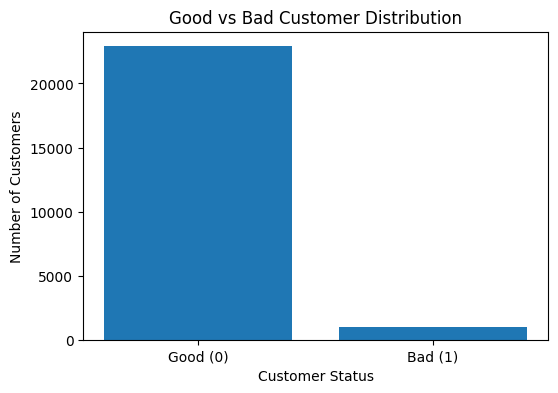

In [123]:
import matplotlib.pyplot as plt

target_counts = df_clean['Bad_label'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(
    ['Good (0)', 'Bad (1)'],
    [target_counts['0'], target_counts['1']]
)

plt.title('Good vs Bad Customer Distribution')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.show()

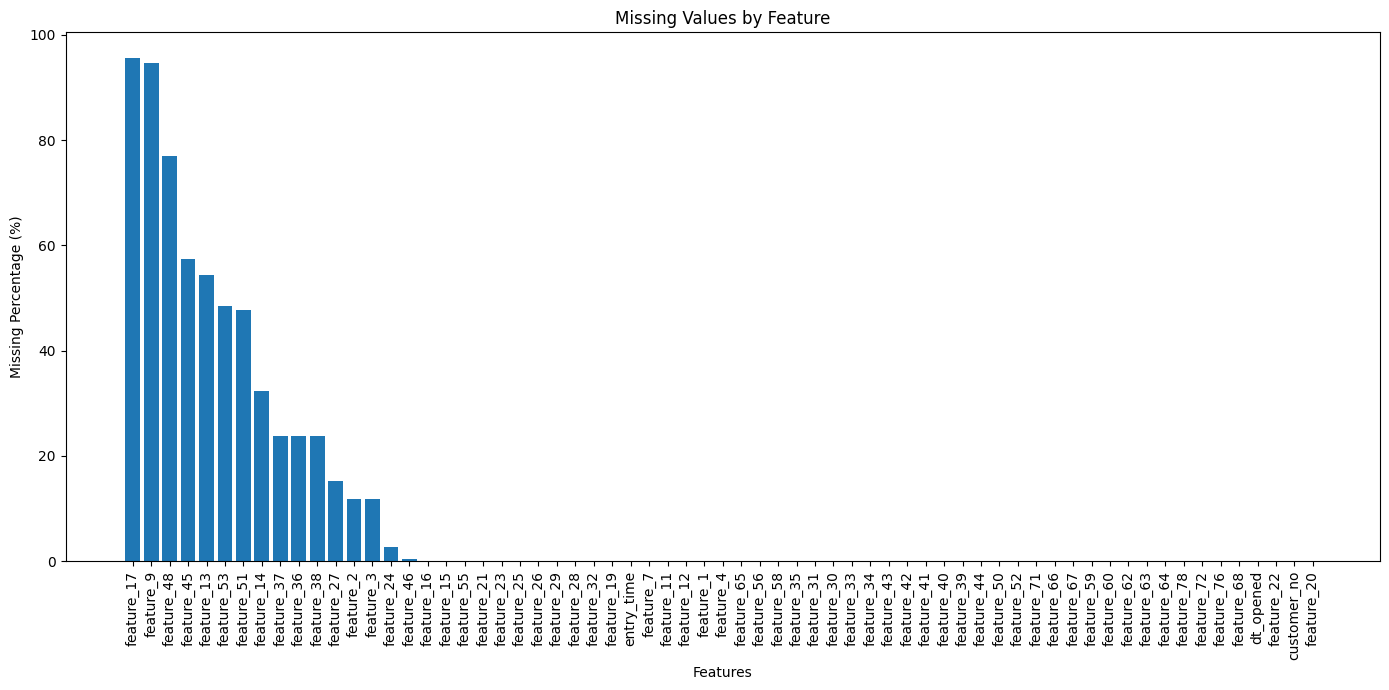

In [124]:
missing_pct = (
    df_clean.drop(columns='Bad_label')
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 7))

plt.bar(
    missing_pct.index,
    missing_pct.values
)

plt.title('Missing Values by Feature')
plt.xlabel('Features')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [125]:
import pandas as pd
import matplotlib.pyplot as plt

# Create temporary numeric versions for EDA
eda_df = df_clean.copy()

eda_df['birth_date'] = pd.to_datetime(
    eda_df['feature_21'],
    format='%d-%b-%y',
    errors='coerce'
)

eda_df['income'] = pd.to_numeric(
    eda_df['feature_35'],
    errors='coerce'
)

eda_df['credit_score'] = pd.to_numeric(
    eda_df['feature_3'],
    errors='coerce'
)

In [126]:
print(eda_df['birth_date'].describe())
print()
print(eda_df['birth_date'].head(10))

count                            23881
mean     1988-09-27 15:06:24.858255488
min                1969-01-01 00:00:00
25%                1980-02-20 00:00:00
50%                1984-06-03 00:00:00
75%                1987-11-15 00:00:00
max                2068-12-31 00:00:00
Name: birth_date, dtype: object

0   2065-09-03
1   2062-07-14
2   2066-04-10
3   2064-04-16
4   2054-01-03
5   2063-07-10
6   2054-04-22
7   2051-04-26
8   1977-09-01
9   1969-10-09
Name: birth_date, dtype: datetime64[ns]


**Note: two-digit years in date of birth.** `feature_21` stores years as two digits, so 1965 is read as 2065. Dates of birth later than the application date are shifted back 100 years. The resulting ages are plausible (18.7 to 76.4 years, median 32.3; none under 18 or over 100).

In [127]:
# Correct DOB century using application date
eda_df['birth_date'] = eda_df['birth_date'].mask(
    eda_df['birth_date'] > pd.to_datetime(
        eda_df['dt_opened'],
        format='%d-%b-%y',
        errors='coerce'
    ),
    eda_df['birth_date'] - pd.DateOffset(years=100)
)

# Calculate age at application
application_date = pd.to_datetime(
    eda_df['dt_opened'],
    format='%d-%b-%y',
    errors='coerce'
)

eda_df['age'] = (
    (application_date - eda_df['birth_date']).dt.days / 365.25
)

print(eda_df['age'].describe())

count    23881.000000
mean        34.068176
std          7.341029
min         18.669405
25%         28.903491
50%         32.331280
75%         37.494867
max         76.361396
Name: age, dtype: float64


In [128]:
print("Missing age:", eda_df['age'].isna().sum())
print("Age < 18:", (eda_df['age'] < 18).sum())
print("Age > 100:", (eda_df['age'] > 100).sum())

Missing age: 15
Age < 18: 0
Age > 100: 0


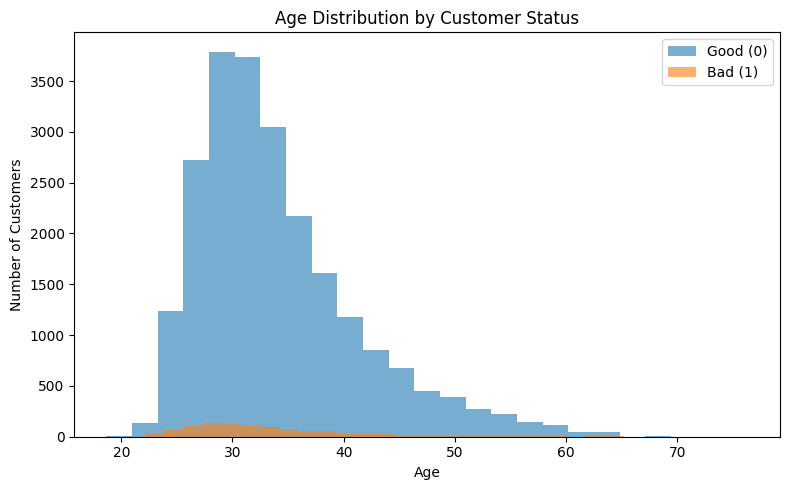

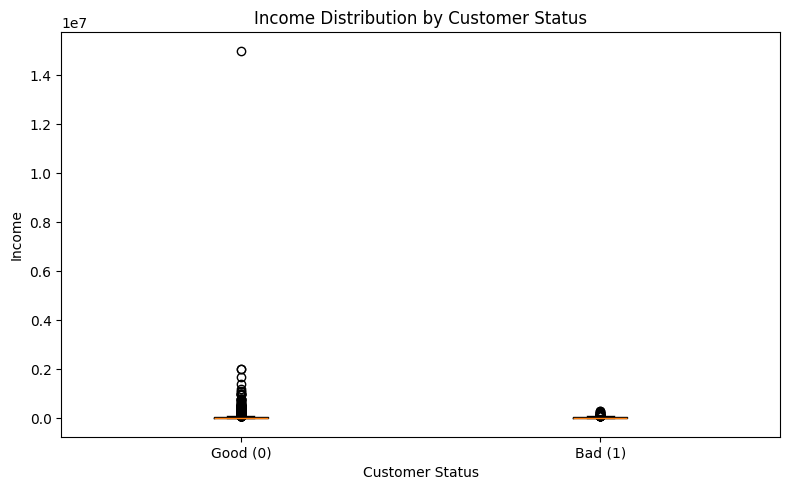

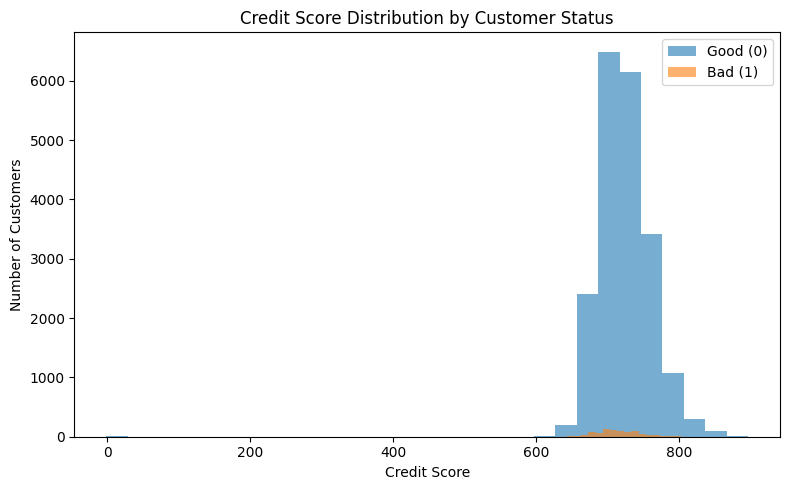

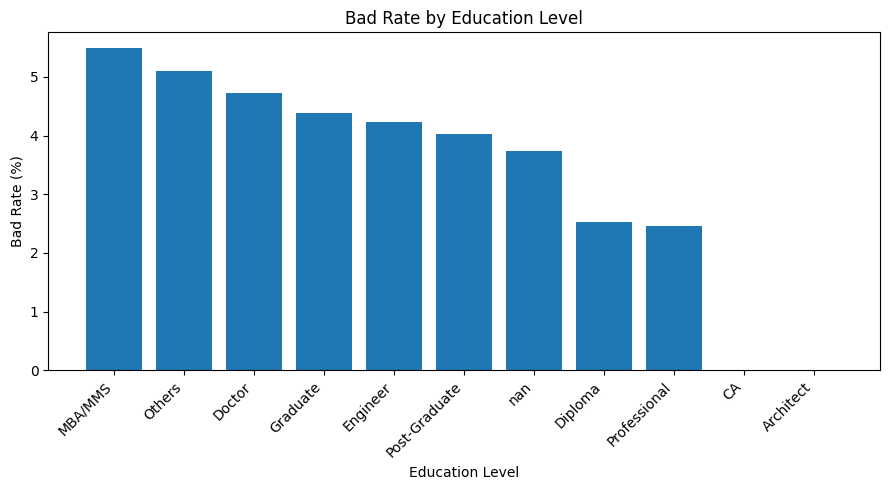

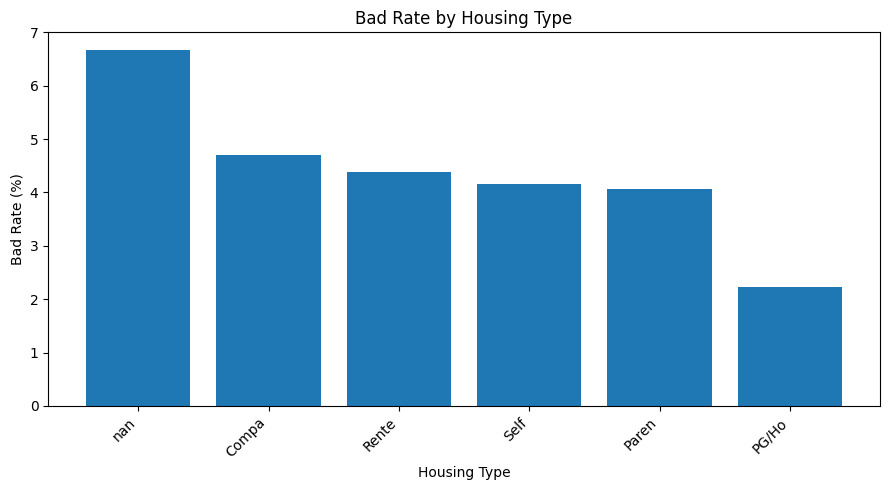

In [129]:
# ==============================
# BATCH 2 — DEMOGRAPHIC EDA
# ==============================

# 1. Age distribution
plt.figure(figsize=(8, 5))

plt.hist(
    eda_df.loc[eda_df['Bad_label'] == '0', 'age'].dropna(),
    bins=25,
    alpha=0.6,
    label='Good (0)'
)

plt.hist(
    eda_df.loc[eda_df['Bad_label'] == '1', 'age'].dropna(),
    bins=25,
    alpha=0.6,
    label='Bad (1)'
)

plt.title('Age Distribution by Customer Status')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()


# 2. Income distribution
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        eda_df.loc[eda_df['Bad_label'] == '0', 'income'].dropna(),
        eda_df.loc[eda_df['Bad_label'] == '1', 'income'].dropna()
    ],
    tick_labels=['Good (0)', 'Bad (1)']
)

plt.title('Income Distribution by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Income')
plt.tight_layout()
plt.show()


# 3. Credit score distribution
plt.figure(figsize=(8, 5))

plt.hist(
    eda_df.loc[eda_df['Bad_label'] == '0', 'credit_score'].dropna(),
    bins=30,
    alpha=0.6,
    label='Good (0)'
)

plt.hist(
    eda_df.loc[eda_df['Bad_label'] == '1', 'credit_score'].dropna(),
    bins=30,
    alpha=0.6,
    label='Bad (1)'
)

plt.title('Credit Score Distribution by Customer Status')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()


# 4. Education vs Bad Rate
education_bad_rate = (
    eda_df.groupby('feature_27', dropna=False)['Bad_label']
    .apply(lambda x: (x == '1').mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    education_bad_rate.index.astype(str),
    education_bad_rate.values
)

plt.title('Bad Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Bad Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 5. Housing vs Bad Rate
housing_bad_rate = (
    eda_df.groupby('feature_32', dropna=False)['Bad_label']
    .apply(lambda x: (x == '1').mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    housing_bad_rate.index.astype(str),
    housing_bad_rate.values
)

plt.title('Bad Rate by Housing Type')
plt.xlabel('Housing Type')
plt.ylabel('Bad Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [130]:
print("Education Bad Rate:")
print(education_bad_rate)

print("\nHousing Bad Rate:")
print(housing_bad_rate)

Education Bad Rate:
feature_27
MBA/MMS          5.485232
Others           5.095541
Doctor           4.733728
Graduate         4.387406
Engineer         4.225352
Post-Graduate    4.022491
NaN              3.739346
Diploma          2.531646
Professional     2.459016
CA               0.000000
Architect        0.000000
Name: Bad_label, dtype: float64

Housing Bad Rate:
feature_32
NaN      6.666667
Compa    4.697987
Rente    4.391040
Self     4.163205
Paren    4.056928
PG/Ho    2.222222
Name: Bad_label, dtype: float64


**Finding.** Bad rates by education range from 5.5% (MBA/MMS) and 5.1% (Others) down to 2.5% (Diploma, Professional); CA and Architect show 0% but have only 30 and 2 customers. Housing type ranges from 4.7% (company-provided) to 2.2% (PG/hostel, 45 customers). Differences are modest and several groups are tiny, so these are weak signals.

In [131]:
print("Education Counts:")
print(eda_df['feature_27'].value_counts(dropna=False))

print("\nHousing Counts:")
print(eda_df['feature_32'].value_counts(dropna=False))

Education Counts:
feature_27
Graduate         14610
Post-Graduate     4624
<NA>              3637
Diploma            237
MBA/MMS            237
Doctor             169
Others             157
Professional       122
Engineer            71
CA                  30
Architect            2
Name: count, dtype: int64

Housing Counts:
feature_32
Self     10833
Rente     6741
Paren     6113
Compa      149
PG/Ho       45
<NA>        15
Name: count, dtype: int64


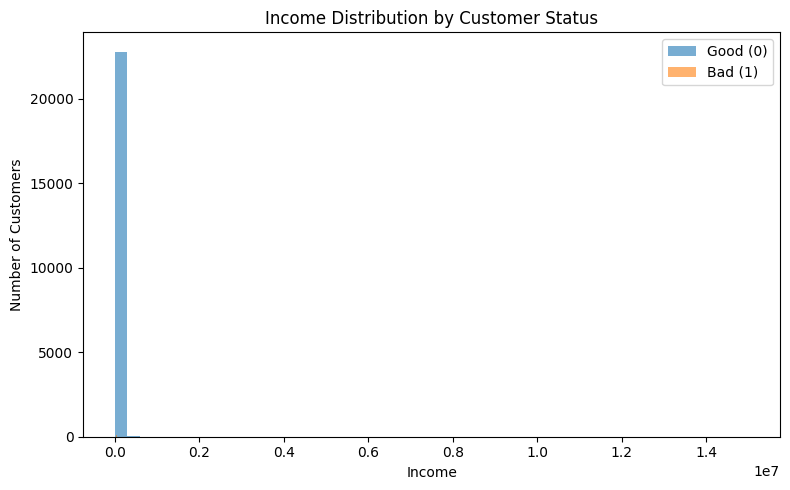

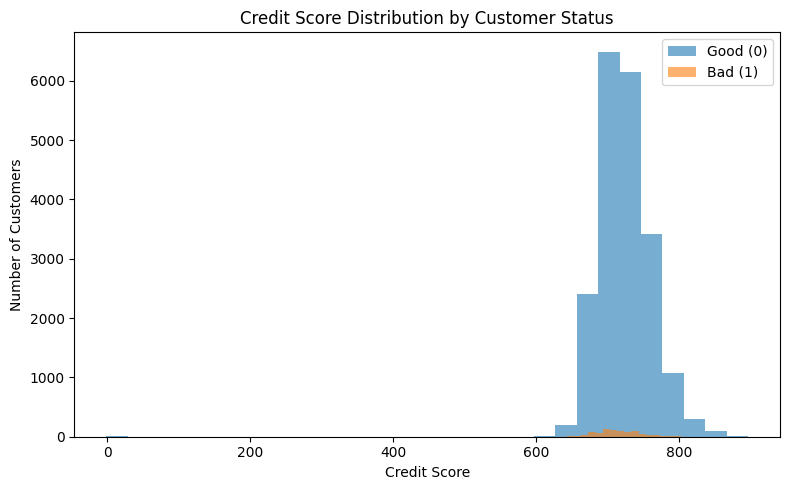

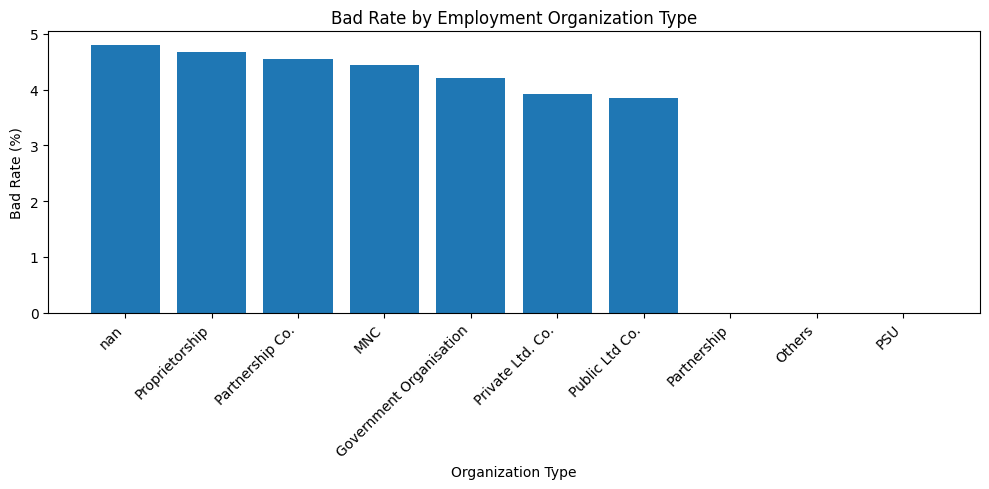

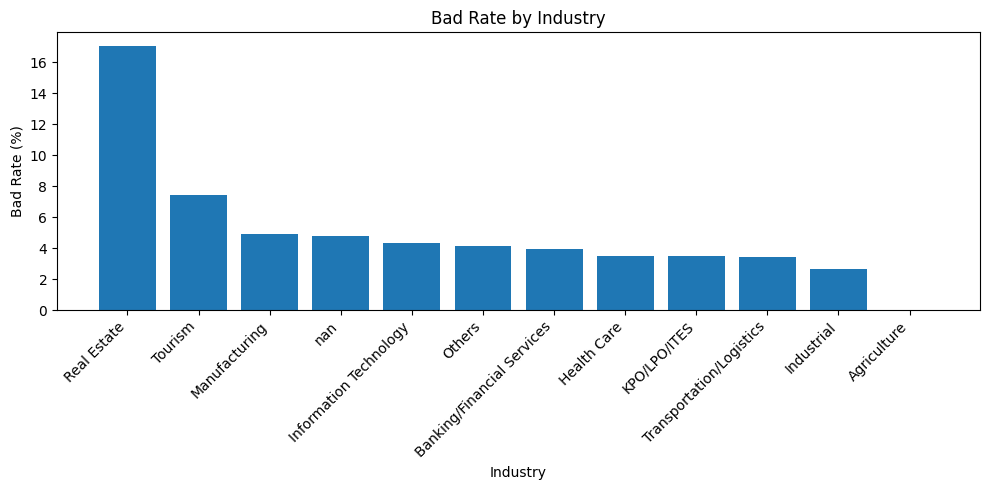

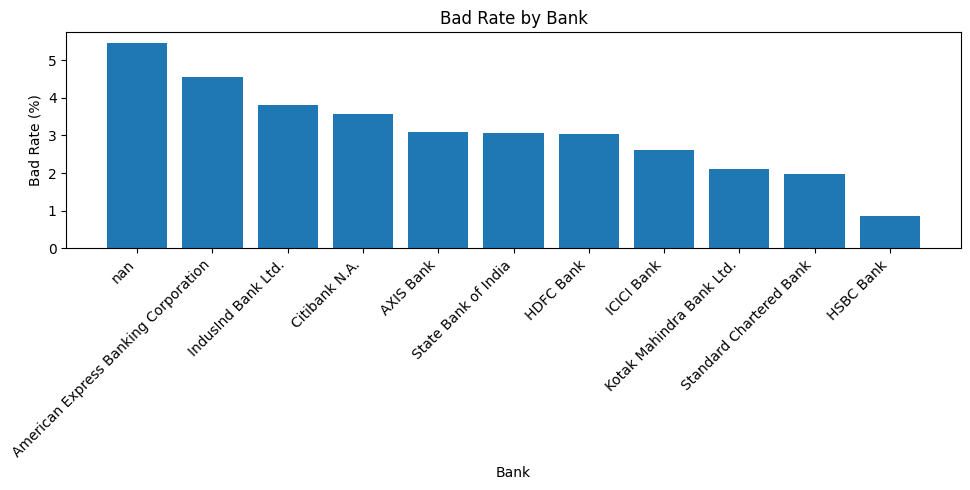

In [132]:
# ==========================================
# BATCH 3 — EMPLOYMENT + FINANCIAL EDA
# ==========================================

# 1. Income distribution
plt.figure(figsize=(8, 5))

plt.hist(
    eda_df.loc[eda_df['Bad_label'] == '0', 'income'].dropna(),
    bins=50,
    alpha=0.6,
    label='Good (0)'
)

plt.hist(
    eda_df.loc[eda_df['Bad_label'] == '1', 'income'].dropna(),
    bins=50,
    alpha=0.6,
    label='Bad (1)'
)

plt.title('Income Distribution by Customer Status')
plt.xlabel('Income')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()


# 2. Credit score distribution
plt.figure(figsize=(8, 5))

plt.hist(
    eda_df.loc[eda_df['Bad_label'] == '0', 'credit_score'].dropna(),
    bins=30,
    alpha=0.6,
    label='Good (0)'
)

plt.hist(
    eda_df.loc[eda_df['Bad_label'] == '1', 'credit_score'].dropna(),
    bins=30,
    alpha=0.6,
    label='Bad (1)'
)

plt.title('Credit Score Distribution by Customer Status')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()


# 3. Employment organization type vs Bad Rate
org_bad_rate = (
    eda_df.groupby('feature_36', dropna=False)['Bad_label']
    .apply(lambda x: (x == '1').mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    org_bad_rate.index.astype(str),
    org_bad_rate.values
)

plt.title('Bad Rate by Employment Organization Type')
plt.xlabel('Organization Type')
plt.ylabel('Bad Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 4. Industry vs Bad Rate
industry_bad_rate = (
    eda_df.groupby('feature_37', dropna=False)['Bad_label']
    .apply(lambda x: (x == '1').mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    industry_bad_rate.index.astype(str),
    industry_bad_rate.values
)

plt.title('Bad Rate by Industry')
plt.xlabel('Industry')
plt.ylabel('Bad Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 5. Bank vs Bad Rate
bank_bad_rate = (
    eda_df.groupby('feature_51', dropna=False)['Bad_label']
    .apply(lambda x: (x == '1').mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    bank_bad_rate.index.astype(str),
    bank_bad_rate.values
)

plt.title('Bad Rate by Bank')
plt.xlabel('Bank')
plt.ylabel('Bad Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [133]:
print("Organization:")
print(eda_df['feature_36'].value_counts(dropna=False))

print("\nIndustry:")
print(eda_df['feature_37'].value_counts(dropna=False))

print("\nBank:")
print(eda_df['feature_51'].value_counts(dropna=False))

Organization:
feature_36
Private Ltd. Co.           8677
<NA>                       5682
Public Ltd Co.             5665
Proprietorship             1669
MNC                        1511
Government Organisation     642
Partnership Co.              22
PSU                          21
Partnership                   6
Others                        1
Name: count, dtype: int64

Industry:
feature_37
Banking/Financial Services    13187
<NA>                           5682
Others                         3457
Information Technology          735
Industrial                      228
KPO/LPO/ITES                    200
Health Care                     199
Manufacturing                    81
Transportation/Logistics         58
Real Estate                      41
Tourism                          27
Agriculture                       1
Name: count, dtype: int64

Bank:
feature_51
<NA>                                    11422
HDFC Bank                                5704
State Bank of India                    

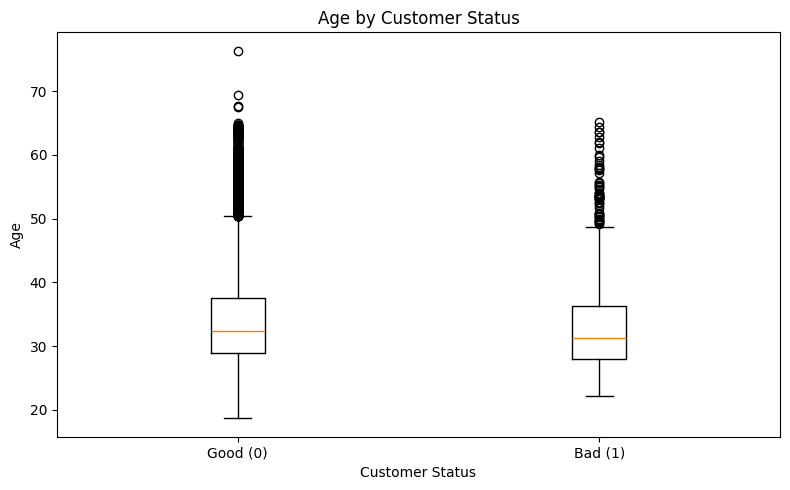

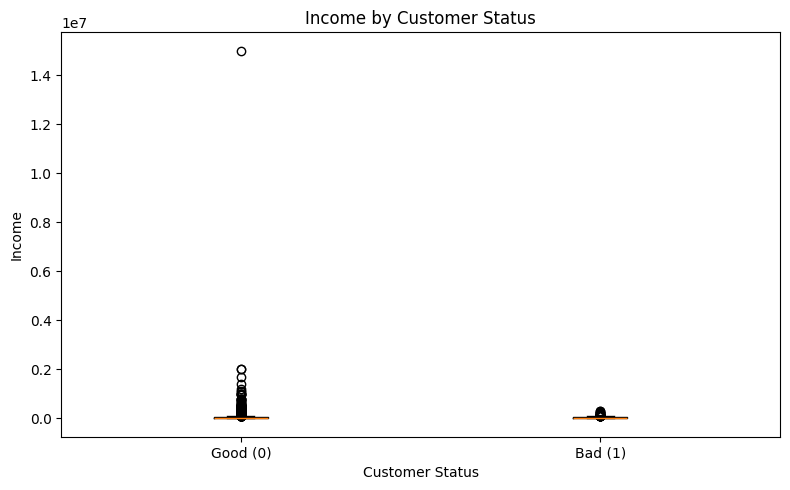

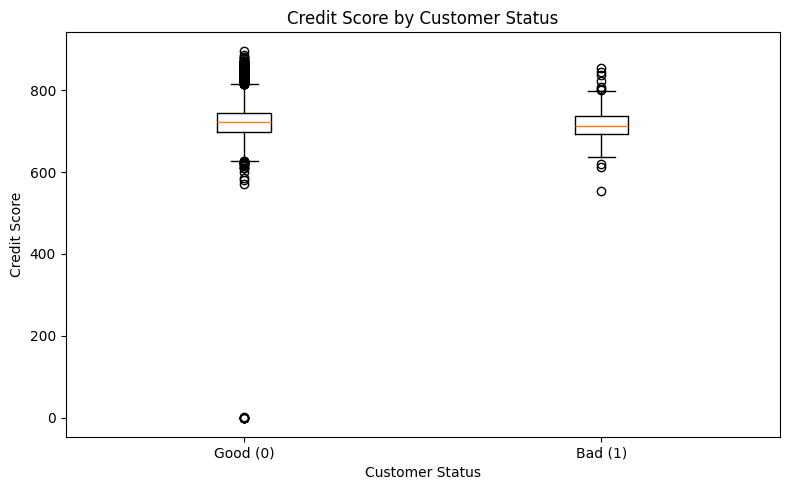

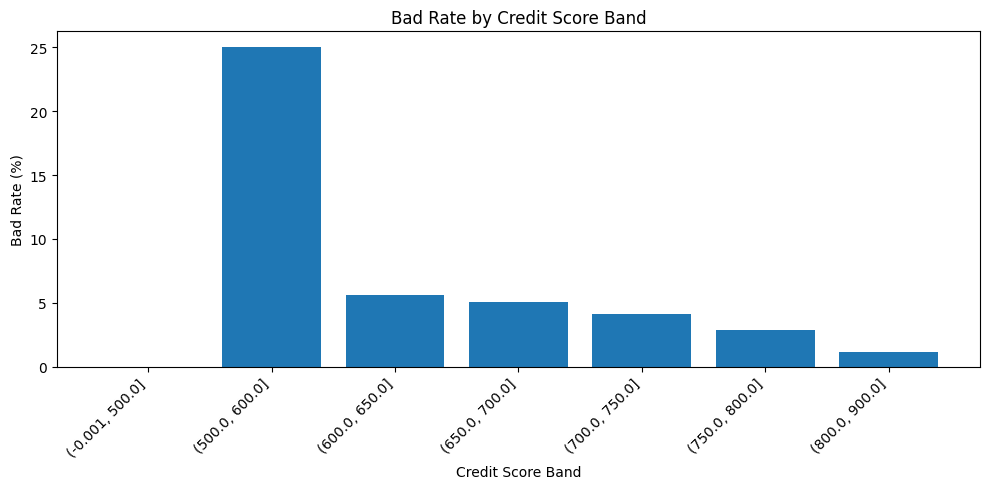

In [134]:
# ==========================================
# BATCH 4 — NUMERICAL RISK ANALYSIS
# ==========================================

# 1. Age vs Bad Label
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        eda_df.loc[eda_df['Bad_label'] == '0', 'age'].dropna(),
        eda_df.loc[eda_df['Bad_label'] == '1', 'age'].dropna()
    ],
    tick_labels=['Good (0)', 'Bad (1)']
)

plt.title('Age by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Age')
plt.tight_layout()
plt.show()


# 2. Income vs Bad Label
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        eda_df.loc[eda_df['Bad_label'] == '0', 'income'].dropna(),
        eda_df.loc[eda_df['Bad_label'] == '1', 'income'].dropna()
    ],
    tick_labels=['Good (0)', 'Bad (1)']
)

plt.title('Income by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Income')
plt.tight_layout()
plt.show()


# 3. Credit Score vs Bad Label
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        eda_df.loc[eda_df['Bad_label'] == '0', 'credit_score'].dropna(),
        eda_df.loc[eda_df['Bad_label'] == '1', 'credit_score'].dropna()
    ],
    tick_labels=['Good (0)', 'Bad (1)']
)

plt.title('Credit Score by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Credit Score')
plt.tight_layout()
plt.show()


# 4. Bad rate by credit-score bands
eda_df['credit_score_band'] = pd.cut(
    eda_df['credit_score'],
    bins=[0, 500, 600, 650, 700, 750, 800, 900],
    include_lowest=True
)

credit_bad_rate = (
    eda_df.groupby('credit_score_band', observed=False)['Bad_label']
    .apply(lambda x: (x == '1').mean() * 100)
)

plt.figure(figsize=(10, 5))

plt.bar(
    credit_bad_rate.index.astype(str),
    credit_bad_rate.values
)

plt.title('Bad Rate by Credit Score Band')
plt.xlabel('Credit Score Band')
plt.ylabel('Bad Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [135]:
print("Age:")
print(eda_df.groupby('Bad_label')['age'].describe())

print("\nIncome:")
print(eda_df.groupby('Bad_label')['income'].describe())

print("\nCredit Score:")
print(eda_df.groupby('Bad_label')['credit_score'].describe())

print("\nCredit Score Bad Rate:")
print(credit_bad_rate)

Age:
             count       mean       std        min        25%        50%  \
Bad_label                                                                  
0          22878.0  34.106524  7.329456  18.669405  28.947296  32.380561   
1           1003.0  33.193476  7.551242  22.157426  27.969884  31.299110   

                 75%        max  
Bad_label                        
0          37.530459  76.361396  
1          36.368241  65.226557  

Income:
             count          mean            std  min  25%      50%       75%  \
Bad_label                                                                      
0          22878.0  32960.459874  110945.508079  1.0  1.0  30000.0  43163.75   
1           1003.0  28885.969093   31570.373860  1.0  1.0  30000.0  40000.00   

                  max  
Bad_label              
0          15000000.0  
1            300000.0  

Credit Score:
             count        mean        std    min    25%    50%    75%    max
Bad_label                           

**Finding.** Bad customers are slightly younger (mean age 33.2 vs 34.1) and have a slightly lower credit score (715 vs 724, shown in the interpretation section). The distributions overlap heavily, so no single variable separates the groups. That is consistent with the modest model performance later.

In [136]:
# ==========================================
# BATCH 5 — EMPLOYMENT + BANK RISK RATES
# ==========================================

def bad_rate_table(df, column, min_count=50):
    result = (
        df.groupby(column, dropna=False)['Bad_label']
        .agg(
            customers='count',
            bad_customers=lambda x: (x == '1').sum()
        )
    )

    result['bad_rate_%'] = (
        result['bad_customers'] / result['customers'] * 100
    )

    return result[
        result['customers'] >= min_count
    ].sort_values('bad_rate_%', ascending=False)


organization_risk = bad_rate_table(
    eda_df,
    'feature_36',
    min_count=50
)

industry_risk = bad_rate_table(
    eda_df,
    'feature_37',
    min_count=50
)

bank_risk = bad_rate_table(
    eda_df,
    'feature_51',
    min_count=50
)


print("=== ORGANIZATION RISK ===")
print(organization_risk)

print("\n=== INDUSTRY RISK ===")
print(industry_risk)

print("\n=== BANK RISK ===")
print(bank_risk)

=== ORGANIZATION RISK ===
                         customers  bad_customers  bad_rate_%
feature_36                                                   
NaN                           5682            273    4.804646
Proprietorship                1669             78    4.673457
MNC                           1511             67    4.434150
Government Organisation        642             27    4.205607
Private Ltd. Co.              8677            340    3.918405
Public Ltd Co.                5665            218    3.848191

=== INDUSTRY RISK ===
                            customers  bad_customers  bad_rate_%
feature_37                                                      
Manufacturing                      81              4    4.938272
NaN                              5682            273    4.804646
Information Technology            735             32    4.353741
Others                           3457            142    4.107608
Banking/Financial Services      13187            522    3.958444


**Finding.** Bad rates by organisation type sit in a narrow 3.8% to 4.8% band (blank 4.8%, proprietorship 4.7%, MNC 4.4%, private ltd 3.9%, public ltd 3.8%). Organisation, industry and bank are weak signals individually.

### Temporal EDA

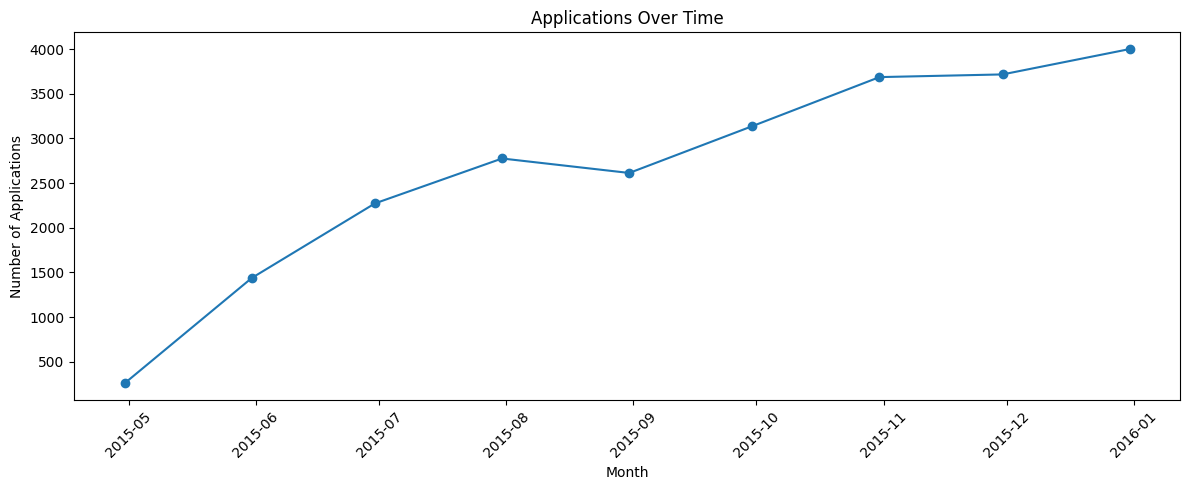

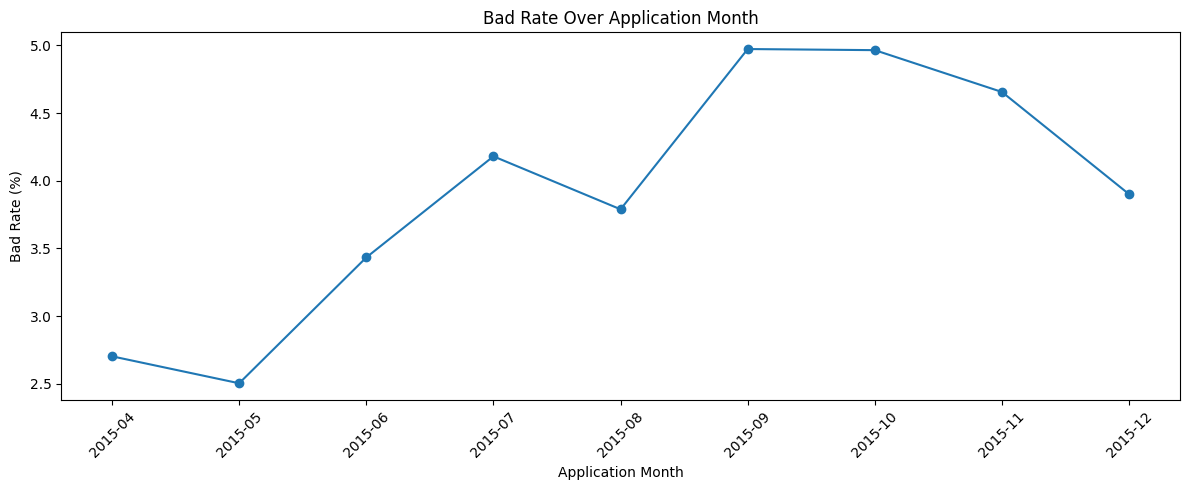

Feature 2 missingness vs bad rate:
feature_2_date
False    4.112061
True     4.866008
Name: Bad_label, dtype: float64

Feature 53 missingness vs bad rate:
feature_53_date
False    3.003419
True     5.469423
Name: Bad_label, dtype: float64

Date ranges:
dt_opened: 2015-04-16 00:00:00 to 2015-12-31 00:00:00
entry_time: 2015-02-01 00:00:00 to 2015-12-23 00:00:00
feature_2: 2015-02-02 00:00:00 to 2015-12-24 00:00:00
feature_53: 1989-06-01 00:00:00 to 2015-10-01 00:00:00


In [137]:
# ==========================================
# BATCH 6 — TEMPORAL EDA
# ==========================================

# Convert dates
eda_df['dt_opened_date'] = pd.to_datetime(
    eda_df['dt_opened'],
    format='%d-%b-%y',
    errors='coerce'
)

eda_df['entry_time_date'] = pd.to_datetime(
    eda_df['entry_time'],
    format='%d-%b-%y',
    errors='coerce'
)

eda_df['feature_2_date'] = pd.to_datetime(
    eda_df['feature_2'],
    format='%d-%b-%y',
    errors='coerce'
)

eda_df['feature_53_date'] = pd.to_datetime(
    eda_df['feature_53'],
    format='%d-%b-%y',
    errors='coerce'
)

# 1. Applications over time
monthly_applications = (
    eda_df
    .set_index('dt_opened_date')
    .resample('ME')
    .size()
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_applications.index,
    monthly_applications.values,
    marker='o'
)
plt.title('Applications Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2. Bad rate over application month
eda_df['application_month'] = (
    eda_df['dt_opened_date'].dt.to_period('M').astype(str)
)

monthly_bad_rate = (
    eda_df.groupby('application_month')['Bad_label']
    .apply(lambda x: (x == '1').mean() * 100)
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_bad_rate.index,
    monthly_bad_rate.values,
    marker='o'
)
plt.title('Bad Rate Over Application Month')
plt.xlabel('Application Month')
plt.ylabel('Bad Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 3. Feature 2 missingness vs target
feature2_missing = eda_df['feature_2_date'].isna()

feature2_missing_risk = (
    eda_df.groupby(feature2_missing)['Bad_label']
    .apply(lambda x: (x == '1').mean() * 100)
)

print("Feature 2 missingness vs bad rate:")
print(feature2_missing_risk)


# 4. Feature 53 missingness vs target
feature53_missing = eda_df['feature_53_date'].isna()

feature53_missing_risk = (
    eda_df.groupby(feature53_missing)['Bad_label']
    .apply(lambda x: (x == '1').mean() * 100)
)

print("\nFeature 53 missingness vs bad rate:")
print(feature53_missing_risk)


# 5. Date ranges
print("\nDate ranges:")
print("dt_opened:", eda_df['dt_opened_date'].min(),
      "to", eda_df['dt_opened_date'].max())

print("entry_time:", eda_df['entry_time_date'].min(),
      "to", eda_df['entry_time_date'].max())

print("feature_2:", eda_df['feature_2_date'].min(),
      "to", eda_df['feature_2_date'].max())

print("feature_53:", eda_df['feature_53_date'].min(),
      "to", eda_df['feature_53_date'].max())

**Finding.** Applications span 16 Apr to 31 Dec 2015. A blank `feature_53` goes with a higher bad rate (5.5% vs 3.0%) and a blank `feature_2` with 4.9% vs 4.1%, so blankness is kept as information (`feature53_missing`) rather than filled silently.

## Cust_Account EDA

The account table has 186,329 rows covering all 23,896 customers (about 7.8 rows each; a row is a reported account record). It is checked for duplicates, blanks, amounts, payment-history strings and date logic before being aggregated to one row per customer.

In [138]:
df_account = pd.read_sql(
    "SELECT * FROM Cust_Account",
    connection
)

print("Shape:", df_account.shape)
df_account.head()

Shape: (186329, 21)


,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,...,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
0,10-Nov-15,12265,20-Oct-15,6,1,09-Jun-13,30-Jun-14,05-Jul-14,30-Sep-15,20900,...,,"""""""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...",,01-Sep-15,01-Jul-14,,,,,
1,10-Nov-15,12265,20-Oct-15,10,1,25-May-12,06-Sep-15,,03-Oct-15,16201,...,,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000000XXX0000000000000...",01-Oct-15,01-Nov-12,14000,1400,,3,5603
2,10-Nov-15,12265,20-Oct-15,10,1,22-Mar-12,31-Aug-15,,30-Sep-15,41028,...,,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Sep-15,01-Oct-12,,,,,
3,20-Jul-15,15606,09-Jul-15,10,1,13-Jan-06,,26-Jul-07,31-Jan-09,93473,...,,"""""""1200900600600600300000000000000000000000000...",,01-Jul-07,01-Feb-06,,,,,
4,20-Jul-15,15606,09-Jul-15,6,1,18-Jan-15,05-May-15,,31-May-15,20250,...,,"""""""000000000000000""""""",,01-May-15,01-Jan-15,,,,,


In [139]:
print("Shape:", df_account.shape)

print("Unique customers:", df_account['customer_no'].nunique())

print("Duplicate rows:", df_account.duplicated().sum())

print("\nAccounts per customer:")
print(df_account['customer_no'].value_counts().describe())

Shape: (186329, 21)
Unique customers: 23896
Duplicate rows: 2401

Accounts per customer:
count    23896.000000
mean         7.797497
std          6.723154
min          1.000000
25%          3.000000
50%          6.000000
75%         10.000000
max        120.000000
Name: count, dtype: float64


**Finding.** 2,401 rows are exact duplicates of another row. They are concentrated in 400 customers (one customer alone has 80 redundant rows) and mostly appear as 2 or 3 identical copies, which looks like repeated uploads rather than real accounts. Only exact duplicates are removed later.

In [140]:
duplicate_rows = df_account[df_account.duplicated(keep=False)]

print("Duplicate rows:", len(duplicate_rows))

duplicate_rows.head(10)

Duplicate rows: 4608


,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,...,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
76,27-Aug-15,17744,10-Aug-15,10,1,22-Aug-14,25-Jun-15,,11-Jul-15,15702,...,,"""""""000000000000000000000000000000000""""""",,01-Jul-15,01-Sep-14,116000,34800,,3,810
77,27-Aug-15,17744,10-Aug-15,5,1,05-May-14,05-May-15,,31-May-15,100000,...,,"""""""000000000000000""""""",,01-May-15,01-Jan-15,,,,,
78,27-Aug-15,17744,10-Aug-15,10,1,08-May-13,10-Jun-15,,30-Jun-15,28261,...,,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000""""""",01-Jun-15,01-May-13,,,,,
79,27-Aug-15,17744,10-Aug-15,10,1,19-Mar-12,29-Jun-15,,30-Jun-15,25523,...,,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Jun-15,01-Jul-12,73000,,39,,1000
80,27-Aug-15,17744,10-Aug-15,10,1,22-Aug-14,25-Jun-15,,11-Jul-15,15702,...,,"""""""000000000000000000000000000000000""""""",,01-Jul-15,01-Sep-14,116000,34800,,3,810
81,27-Aug-15,17744,10-Aug-15,5,1,05-May-14,05-May-15,,31-May-15,100000,...,,"""""""000000000000000""""""",,01-May-15,01-Jan-15,,,,,
82,27-Aug-15,17744,10-Aug-15,10,1,08-May-13,10-Jun-15,,30-Jun-15,28261,...,,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000""""""",01-Jun-15,01-May-13,,,,,
83,27-Aug-15,17744,10-Aug-15,10,1,19-Mar-12,29-Jun-15,,30-Jun-15,25523,...,,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Jun-15,01-Jul-12,73000,,39,,1000
377,06-Nov-15,4920,29-Oct-15,10,1,04-May-06,,04-May-06,30-Sep-06,,...,,"""""""000""""""",,01-May-06,01-May-06,,,,,
378,06-Nov-15,4920,29-Oct-15,10,1,04-May-06,,04-May-06,30-Sep-06,,...,,"""""""000""""""",,01-May-06,01-May-06,,,,,


In [141]:
print(
    "Duplicate customer-account combinations:",
    df_account.duplicated(
        subset=['customer_no', 'acct_type', 'dt_opened'],
        keep=False
    ).sum()
)

Duplicate customer-account combinations: 157212


In [142]:
duplicate_rows = df_account[
    df_account.duplicated(keep=False)
].copy()

print("Total rows involved in exact duplicates:", len(duplicate_rows))
print("Unique duplicate records:", duplicate_rows.drop_duplicates().shape[0])

print("\nDuplicate rows by customer:")
print(
    duplicate_rows['customer_no']
    .value_counts()
    .head(10)
)

Total rows involved in exact duplicates: 4608
Unique duplicate records: 2207

Duplicate rows by customer:
customer_no
8516     120
10076    112
6391      88
8869      72
8092      70
6147      63
10043     62
7884      56
16124     54
1682      52
Name: count, dtype: int64


In [143]:
print("\nExample exact duplicate records:")
duplicate_rows.sort_values('customer_no').head(20)


Example exact duplicate records:


,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,...,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
145894,01-Oct-15,10043,28-Sep-15,10,1,13-Jul-12,06-Sep-14,,12-Sep-14,18878,...,,"""""""000000000000000000000000008""""""",,01-Sep-14,01-Jan-14,,,,,
145901,01-Oct-15,10043,28-Sep-15,10,1,26-Sep-08,09-Jan-09,12-May-09,11-Jul-11,54534,...,,"""""""000090060030000030000000000""""""",,01-May-09,01-Sep-08,,,,,
145900,01-Oct-15,10043,28-Sep-15,7,1,13-Jan-12,,,31-Jul-12,73000,...,,"""""""STDSTDSTDSTDSTDSTDSTD""""""",,01-Jul-12,01-Jan-12,,,,,
145899,01-Oct-15,10043,28-Sep-15,7,1,14-Feb-12,,,31-Jul-12,130000,...,,"""""""STDSTDSTDSTDSTDSTD""""""",,01-Jul-12,01-Feb-12,,,,,
145898,01-Oct-15,10043,28-Sep-15,7,1,21-Mar-12,,,31-Jul-12,87000,...,,"""""""STDSTDSTDSTDSTD""""""",,01-Jul-12,01-Mar-12,,,,,
145897,01-Oct-15,10043,28-Sep-15,7,1,19-Apr-12,03-May-13,03-May-13,31-May-13,66000,...,,"""""""STDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTD""""""",,01-May-13,01-Apr-12,,,,,
145896,01-Oct-15,10043,28-Sep-15,7,1,27-Apr-12,,,31-Aug-12,86000,...,,"""""""STDSTDSTDSTDSTD""""""",,01-Aug-12,01-Apr-12,,,,,
145895,01-Oct-15,10043,28-Sep-15,7,1,29-Jun-12,03-Jul-13,03-Jul-13,31-Jul-13,30000,...,,"""""""000STDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTD""""""",,01-Jul-13,01-Jun-12,,,,,
145913,01-Oct-15,10043,28-Sep-15,1,1,30-Sep-14,28-Oct-14,,31-Jul-15,728000,...,,"""""""STDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTD""""""",,01-Jul-15,01-Sep-14,,,10,3,
145893,01-Oct-15,10043,28-Sep-15,53,1,16-Jul-12,13-Sep-13,13-Sep-13,30-Sep-13,146000,...,,"""""""STDSTDXXXSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDS...",,01-Sep-13,01-Oct-10,,,,,


In [144]:
duplicate_counts = (
    df_account.value_counts()
    .reset_index(name='count')
)

print(duplicate_counts['count'].value_counts().sort_index())

count
1     181721
2       2064
3        107
4         31
5          2
6          1
9          1
10         1
Name: count, dtype: int64


In [145]:
print(duplicate_counts.head(10))

   dt_opened customer_no  upload_dt acct_type owner_indic  opened_dt  \
0  19-Aug-15       17411  10-Aug-15         1           3  16-Aug-14   
1  29-Dec-15        6085  07-Dec-15        17           3  01-Nov-12   
2  19-Aug-15       17411  10-Aug-15         1           3  31-Aug-14   
3  14-Sep-15        3910  26-Aug-15         7           1              
4  01-Dec-15       13223  15-Oct-15        51           1  03-Jul-03   
5  02-Jun-15       15352  21-Apr-15        10           1  14-Sep-13   
6  02-Jun-15       15352  21-Apr-15         5           1  04-May-13   
7  11-Sep-15        9115  27-Aug-15         5           1              
8  02-Jun-15       15352  21-Apr-15         5           1  28-Dec-13   
9  07-Aug-15        8092  02-Jul-15         7           1  23-Oct-09   

  last_paymt_dt  closed_dt reporting_dt high_credit_amt  ...  \
0     15-May-15               31-May-15          373000  ...   
1     22-Sep-15  22-Sep-15    30-Sep-15          341694  ...   
2     02-May-15

In [146]:
duplicate_rows = df_account[
    df_account.duplicated(keep=False)
].copy()

print(
    "Unique upload dates among exact duplicate records:",
    duplicate_rows['upload_dt'].nunique()
)

print("\nTop upload dates:")
print(duplicate_rows['upload_dt'].value_counts().head(15))

Unique upload dates among exact duplicate records: 70

Top upload dates:
upload_dt
28-Sep-15    508
01-May-15    378
21-Apr-15    327
21-Dec-15    322
17-Dec-15    256
23-Apr-15    233
05-May-15    196
30-Jul-15    194
02-Jul-15    170
20-Aug-15    148
28-Apr-15    140
30-Nov-15    122
22-Jun-15    116
10-Aug-15    114
15-Jun-15     91
Name: count, dtype: int64


In [147]:
print("\nDuplicate records by upload date:")
print(
    duplicate_rows.groupby('upload_dt').size()
    .sort_values(ascending=False)
    .head(15)
)


Duplicate records by upload date:
upload_dt
28-Sep-15    508
01-May-15    378
21-Apr-15    327
21-Dec-15    322
17-Dec-15    256
23-Apr-15    233
05-May-15    196
30-Jul-15    194
02-Jul-15    170
20-Aug-15    148
28-Apr-15    140
30-Nov-15    122
22-Jun-15    116
10-Aug-15    114
15-Jun-15     91
dtype: int64


In [148]:
account_missing = (
    df_account.replace('', pd.NA)
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(account_missing)

amt_past_due           185453
rateofinterest         161496
cashlimit              151047
actualpaymentamount    145276
creditlimit            137477
paymentfrequency       122436
closed_dt              109075
paymenthistory2        107824
last_paymt_dt           25487
high_credit_amt          8875
opened_dt                 455
paymt_str_dt                1
paymt_end_dt                1
owner_indic                 0
acct_type                   0
upload_dt                   0
customer_no                 0
dt_opened                   0
paymenthistory1             0
reporting_dt                0
cur_balance_amt             0
dtype: int64


In [149]:
account_missing_pct = (
    df_account.replace('', pd.NA)
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(account_missing_pct)

amt_past_due           99.529864
rateofinterest         86.672499
cashlimit              81.064676
actualpaymentamount    77.967466
creditlimit            73.781859
paymentfrequency       65.709578
closed_dt              58.538928
paymenthistory2        57.867535
last_paymt_dt          13.678493
high_credit_amt         4.763080
opened_dt               0.244192
paymt_str_dt            0.000537
paymt_end_dt            0.000537
owner_indic             0.000000
acct_type               0.000000
upload_dt               0.000000
customer_no             0.000000
dt_opened               0.000000
paymenthistory1         0.000000
reporting_dt            0.000000
cur_balance_amt         0.000000
dtype: float64


**Finding.** Amount fields are sparse: `amt_past_due` is 99.5% blank, `rateofinterest` 86.7%, `cashlimit` 81.1%, `actualpaymentamount` 78.0% and `creditlimit` 73.8%. Availability depends on `acct_type` (some types never carry credit limits), so blank is meaningful and is turned into `has_...` indicators later. `paymenthistory1` is always present; `paymenthistory2` in about 42% of rows.

In [150]:
financial_cols = [
    'high_credit_amt',
    'cur_balance_amt',
    'amt_past_due',
    'creditlimit',
    'cashlimit',
    'rateofinterest',
    'actualpaymentamount'
]

for col in financial_cols:
    temp = pd.to_numeric(
        df_account[col].replace('', pd.NA),
        errors='coerce'
    )

    print(f"\n{'='*50}")
    print(col)
    print(f"Non-missing: {temp.notna().sum()}")
    print(f"Missing:     {temp.isna().sum()}")
    print(f"Min:         {temp.min()}")
    print(f"Median:      {temp.median()}")
    print(f"Max:         {temp.max()}")
    print(f"Negative:    {(temp < 0).sum()}")
    print(f"Zero:        {(temp == 0).sum()}")


high_credit_amt
Non-missing: 177454
Missing:     8875
Min:         1.0
Median:      45223.5
Max:         180000000.0
Negative:    0
Zero:        0

cur_balance_amt
Non-missing: 186329
Missing:     0
Min:         -7355205
Median:      0.0
Max:         136009965
Negative:    8881
Zero:        89872

amt_past_due
Non-missing: 876
Missing:     185453
Min:         1.0
Median:      1209.5
Max:         4869309.0
Negative:    0
Zero:        0

creditlimit
Non-missing: 48852
Missing:     137477
Min:         1.0
Median:      60000.0
Max:         2500000.0
Negative:    0
Zero:        0

cashlimit
Non-missing: 35282
Missing:     151047
Min:         1.0
Median:      12500.0
Max:         1000000.0
Negative:    0
Zero:        0

rateofinterest
Non-missing: 24823
Missing:     161506
Min:         0.001
Median:      37.8
Max:         62.972
Negative:    0
Zero:        0

actualpaymentamount
Non-missing: 41053
Missing:     145276
Min:         1.0
Median:      7590.0
Max:         67853221.0
Negative:    

In [151]:
balance = pd.to_numeric(
    df_account['cur_balance_amt'].replace('', pd.NA),
    errors='coerce'
)

print("Negative balance count:", (balance < 0).sum())

print("\nMost common negative balances:")
print(
    balance[balance < 0]
    .value_counts()
    .head(20)
)

print("\nNegative balance statistics:")
print(
    balance[balance < 0].describe()
)

Negative balance count: 8881

Most common negative balances:
cur_balance_amt
-1      1919
-2       434
-3       307
-4       228
-5       151
-6       128
-7       112
-8       103
-10       82
-11       72
-9        70
-12       63
-13       57
-15       56
-16       53
-19       52
-20       49
-101      46
-22       42
-27       40
Name: count, dtype: int64

Negative balance statistics:
count    8.881000e+03
mean    -3.837264e+03
std      1.003282e+05
min     -7.355205e+06
25%     -2.780000e+02
50%     -3.200000e+01
75%     -2.000000e+00
max     -1.000000e+00
Name: cur_balance_amt, dtype: float64


**Finding.** 8,881 rows (4.8%) have a negative `cur_balance_amt`. Most are tiny (median -32, most common -1), which likely reflects small credit balances or rounding rather than losses. A few reach -7.4 million; they are kept and flagged, not removed.

In [152]:
print("Unique account types:", df_account['acct_type'].nunique())

print("\nAccount type distribution:")
print(df_account['acct_type'].value_counts().sort_index())

Unique account types: 31

Account type distribution:
acct_type
0       3944
1       9427
10    100239
11         4
12      1196
13      8569
14         5
15       519
16         2
17       453
2       5639
3        672
31        27
32       744
33         5
34         5
35        54
4        188
5      22921
51       732
52        97
53       386
54        73
55        17
56         8
57         1
59        22
6      25664
7       4256
8        407
9         53
Name: count, dtype: int64


In [153]:
print("\nCustomers per account type:")
print(
    df_account.groupby('acct_type')['customer_no']
    .nunique()
    .sort_values(ascending=False)
)


Customers per account type:
acct_type
10    23215
5     10240
6      9205
13     6332
1      5620
2      3649
0      3056
7      1396
12      973
32      689
3       503
51      447
8       367
15      314
17      218
53      202
4       123
52       81
54       59
35       51
9        40
31       22
59       21
55       15
56        8
34        5
14        4
11        4
33        4
16        1
57        1
Name: customer_no, dtype: int64


In [154]:
account_type_financial = df_account.replace('', pd.NA).groupby('acct_type').agg(
    accounts=('customer_no', 'size'),
    creditlimit_available=('creditlimit', lambda x: x.notna().sum()),
    cashlimit_available=('cashlimit', lambda x: x.notna().sum()),
    interest_available=('rateofinterest', lambda x: x.notna().sum()),
    paymentfrequency_available=('paymentfrequency', lambda x: x.notna().sum()),
    actualpayment_available=('actualpaymentamount', lambda x: x.notna().sum()),
    pastdue_available=('amt_past_due', lambda x: x.notna().sum())
)

print(account_type_financial)

           accounts  creditlimit_available  cashlimit_available  \
acct_type                                                         
0              3944                      0                    0   
1              9427                      0                    0   
10           100239                  48838                35269   
11                4                      0                    0   
12             1196                      0                    0   
13             8569                      0                    0   
14                5                      0                    0   
15              519                      0                    0   
16                2                      0                    0   
17              453                      0                    0   
2              5639                      0                    0   
3               672                      0                    0   
31               27                      0                    

### Payment History

### How to read the payment-history strings
`paymenthistory1` and `paymenthistory2` are text wrapped in triple quotes and read in blocks of **3 characters**, one block per month (up to 18 months each, 36 combined). The order appears to run backwards from the payment start date.

Each block is a number (days past due, **DPD**: `000` on time, `030` 30 days late, ...) or a status code: `STD` standard, `XXX` no information reported, `SUB` / `DBT` / `LSS` substandard / doubtful / loss, `SMA` special mention. The value `900` only appears together with DPD of 180 or more. These meanings follow common credit-bureau conventions and are inferred, not documented in the data.

In [155]:
for col in ['paymenthistory1', 'paymenthistory2']:
    temp = df_account[col].replace('', pd.NA).dropna().astype(str)

    print(f"\n{'='*60}")
    print(col)

    print("Non-missing:", len(temp))

    print("\nLength distribution:")
    print(temp.str.len().value_counts().sort_index().head(30))

    print("\nMost common lengths:")
    print(temp.str.len().value_counts().head(10))


paymenthistory1
Non-missing: 186329

Length distribution:
paymenthistory1
9     21410
12     6674
15     6292
18     5834
21     5022
24     5474
27     5299
30     5620
33     6702
36     6852
39     5987
42     4860
45     4467
48     4122
51     3638
54     3365
57     3145
60    81566
Name: count, dtype: int64

Most common lengths:
paymenthistory1
60    81566
9     21410
36     6852
33     6702
12     6674
15     6292
39     5987
18     5834
30     5620
24     5474
Name: count, dtype: int64

paymenthistory2
Non-missing: 78505

Length distribution:
paymenthistory2
9      3039
12     2609
15     2431
18     2432
21     2374
24     2538
27     3030
30     2496
33     2100
36     1954
39     1956
42     1865
45     1861
48     1735
51     1562
54     1585
57     1736
60    41202
Name: count, dtype: int64

Most common lengths:
paymenthistory2
60    41202
9      3039
27     3030
12     2609
24     2538
30     2496
18     2432
15     2431
21     2374
33     2100
Name: count, dtype: int64

In [156]:
for col in ['paymenthistory1', 'paymenthistory2']:
    temp = df_account[col].replace('', pd.NA).dropna().astype(str)

    chars = set(''.join(temp))

    print(f"\n{col} unique characters:")
    print(sorted(chars))


paymenthistory1 unique characters:
['"', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'D', 'L', 'M', 'S', 'T', 'U', 'X']

paymenthistory2 unique characters:
['"', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'D', 'L', 'M', 'S', 'T', 'U', 'X']


In [157]:
for col in ['paymenthistory1', 'paymenthistory2']:
    print(f"\n{'='*70}")
    print(col)

    print("\nSample values:")
    print(
        df_account[col]
        .replace('', pd.NA)
        .dropna()
        .drop_duplicates()
        .head(20)
        .to_string(index=False)
    )


paymenthistory1

Sample values:
"""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXST...
"""00000000000000000000000000000000000000000000...
"""12009006006006003000000000000000000000000000...
                             """000000000000000"""
                          """000000000000000000"""
                    """000000000000000000000000"""
"""000000000XXX000000000000030XXX00000000000000...
"""00090090090090090090088885782979876773770667...
                                         """000"""
                                   """000017000"""
                                         """XXX"""
"""XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX...
                                      """000000"""
"""STDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDST...
"""000XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX...
                 """000000000000000000000000000"""
                                """000000000000"""
"""00000000000000000000000000000000000000000000...
"""STDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDST..

In [158]:
for col in ['paymenthistory1', 'paymenthistory2']:
    print(f"\n{'='*70}")
    print(col)

    temp = df_account[col].replace('', pd.NA).dropna().astype(str)

    print("\nFirst 20 three-character chunks:")
    for value in temp.head(5):
        print(value, " -> ", [value[i:i+3] for i in range(0, len(value), 3)])


paymenthistory1

First 20 three-character chunks:
"""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXSTD"""  ->  ['"""', 'STD', 'STD', 'STD', 'XXX', 'XXX', 'XXX', 'XXX', 'XXX', 'STD', 'XXX', 'XXX', 'XXX', 'XXX', 'XXX', 'STD', '"""']
"""000000000000000000000000000000000000000000000000000000"""  ->  ['"""', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '"""']
"""000000000000000000000000000000000000000000000000000000"""  ->  ['"""', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '"""']
"""120090060060060030000000000000000000000000000000000000"""  ->  ['"""', '120', '090', '060', '060', '060', '030', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '"""']
"""000000000000000"""  ->  ['"""', '000', '000', '000', '000', '000', '"""']

paymenthistory2

First 20 three-character chunks:
"""00000000000000000000

In [159]:
for col in ['paymenthistory1', 'paymenthistory2']:
    print(f"\n{'='*70}")
    print(col)

    temp = (
        df_account[col]
        .replace('', pd.NA)
        .dropna()
        .astype(str)
        .str.replace('"""', '', regex=False)
    )

    chunks = []

    for value in temp:
        chunks.extend(
            value[i:i+3]
            for i in range(0, len(value), 3)
        )

    code_counts = pd.Series(chunks).value_counts()

    print("Total 3-character codes:", len(chunks))
    print("Unique codes:", len(code_counts))
    print("\nTop 30 codes:")
    print(code_counts.head(30))


paymenthistory1
Total 3-character codes: 2215834
Unique codes: 899

Top 30 codes:
000    1757758
XXX     233218
STD     147940
900       7173
030       5526
001       3419
015       2820
180       2729
060       2728
150       2028
090       1857
025       1720
026       1293
120       1256
007       1098
024        931
008        925
006        710
SUB        693
023        650
055        646
020        631
016        594
038        548
085        531
028        527
029        521
056        500
005        490
021        488
Name: count, dtype: int64

paymenthistory2
Total 3-character codes: 1044311
Unique codes: 890

Top 30 codes:
000    798678
XXX    152659
STD     51330
900      3052
030      2881
001      2336
180      2116
015      1870
150      1163
060      1111
025      1045
026       789
090       532
024       513
008       495
007       482
023       481
020       454
055       449
006       434
120       426
016       382
027       357
019       335
021       316
003     

In [160]:
for col in ['paymenthistory1', 'paymenthistory2']:

    print(f"\n{'='*70}")
    print(col)

    temp = (
        df_account[col]
        .replace('', pd.NA)
        .dropna()
        .astype(str)
        .str.replace('"""', '', regex=False)
    )

    codes = []

    for value in temp:
        codes.extend(
            value[i:i+3]
            for i in range(0, len(value), 3)
        )

    code_series = pd.Series(codes)

    numeric_codes = code_series[
        code_series.str.fullmatch(r'\d{3}')
    ]

    numeric_values = pd.to_numeric(numeric_codes)

    print("Numeric code count:", len(numeric_values))
    print("Unique numeric codes:", numeric_values.nunique())
    print("Minimum numeric code:", numeric_values.min())
    print("Maximum numeric code:", numeric_values.max())

    print("\nMost common numeric codes:")
    print(numeric_values.value_counts().head(30))


paymenthistory1
Numeric code count: 1833451
Unique numeric codes: 893
Minimum numeric code: 0
Maximum numeric code: 900

Most common numeric codes:
0      1757758
900       7173
30        5526
1         3419
15        2820
180       2729
60        2728
150       2028
90        1857
25        1720
26        1293
120       1256
7         1098
24         931
8          925
6          710
23         650
55         646
20         631
16         594
38         548
85         531
28         527
29         521
56         500
5          490
21         488
22         483
4          433
3          431
Name: count, dtype: int64

paymenthistory2
Numeric code count: 839770
Unique numeric codes: 884
Minimum numeric code: 0
Maximum numeric code: 900

Most common numeric codes:
0      798678
900      3052
30       2881
1        2336
180      2116
15       1870
150      1163
60       1111
25       1045
26        789
90        532
24        513
8         495
7         482
23        481
20        454
55 

In [161]:
history_date_check = df_account[
    ['customer_no',
     'paymenthistory1',
     'paymenthistory2',
     'paymt_str_dt',
     'paymt_end_dt']
].copy()

history_date_check = history_date_check.replace('', pd.NA)

history_date_check['history1_length'] = (
    history_date_check['paymenthistory1']
    .str.replace('"""', '', regex=False)
    .str.len()
)

history_date_check['history2_length'] = (
    history_date_check['paymenthistory2']
    .str.replace('"""', '', regex=False)
    .str.len()
)

history_date_check[
    ['paymt_str_dt',
     'paymt_end_dt',
     'history1_length',
     'history2_length']
].head(20)

,paymt_str_dt,paymt_end_dt,history1_length,history2_length
0,01-Sep-15,01-Jul-14,45,<NA>
1,01-Oct-15,01-Nov-12,54,54
2,01-Sep-15,01-Oct-12,54,54
3,01-Jul-07,01-Feb-06,54,<NA>
4,01-May-15,01-Jan-15,15,<NA>
5,01-May-15,01-Jan-15,15,<NA>
6,01-May-15,01-Dec-14,18,<NA>
7,01-May-15,01-Oct-14,24,<NA>
8,01-May-15,01-Dec-12,54,36
9,01-Jun-15,01-Aug-12,54,51


In [162]:
print(
    history_date_check[
        ['paymt_str_dt', 'paymt_end_dt',
         'history1_length', 'history2_length']
    ].describe(include='all')
)

       paymt_str_dt paymt_end_dt  history1_length  history2_length
count        186328       186328    186329.000000          78505.0
unique          233          234              NaN             18.0
top       01-Jul-15    01-Jan-15              NaN             54.0
freq          16747         5640              NaN          41202.0
mean            NaN          NaN        35.676153              NaN
std             NaN          NaN        19.682810              NaN
min             NaN          NaN         3.000000              NaN
25%             NaN          NaN        18.000000              NaN
50%             NaN          NaN        42.000000              NaN
75%             NaN          NaN        54.000000              NaN
max             NaN          NaN        54.000000              NaN


In [163]:
sample_history = history_date_check[
    history_date_check['history2_length'].notna()
].copy()

sample_history['history1_clean'] = (
    sample_history['paymenthistory1']
    .str.replace('"""', '', regex=False)
)

sample_history['history2_clean'] = (
    sample_history['paymenthistory2']
    .str.replace('"""', '', regex=False)
)

sample_history['h1_first'] = sample_history['history1_clean'].str[:3]
sample_history['h1_last'] = sample_history['history1_clean'].str[-3:]

sample_history['h2_first'] = sample_history['history2_clean'].str[:3]
sample_history['h2_last'] = sample_history['history2_clean'].str[-3:]

sample_history[
    [
        'paymt_str_dt',
        'paymt_end_dt',
        'history1_length',
        'history2_length',
        'h1_first',
        'h1_last',
        'h2_first',
        'h2_last'
    ]
].head(20)

,paymt_str_dt,paymt_end_dt,history1_length,history2_length,h1_first,h1_last,h2_first,h2_last
1,01-Oct-15,01-Nov-12,54,54,000,000,000,000
2,01-Sep-15,01-Oct-12,54,54,000,000,000,000
8,01-May-15,01-Dec-12,54,36,000,000,000,000
9,01-Jun-15,01-Aug-12,54,51,000,000,030,000
10,01-Dec-11,01-Jan-09,54,54,000,000,000,000
11,01-Nov-11,01-Dec-08,54,54,000,584,553,007
16,01-Nov-08,01-Dec-05,54,54,XXX,XXX,XXX,STD
21,01-Jan-14,01-Feb-11,54,6,STD,STD,XXX,STD
22,01-Jan-14,01-Feb-11,54,54,000,XXX,XXX,XXX
23,01-Jan-14,01-Mar-11,54,51,000,XXX,XXX,XXX


In [164]:
date_check = history_date_check.copy()

date_check['paymt_str_dt_parsed'] = pd.to_datetime(
    date_check['paymt_str_dt'],
    format='%d-%b-%y',
    errors='coerce'
)

date_check['paymt_end_dt_parsed'] = pd.to_datetime(
    date_check['paymt_end_dt'],
    format='%d-%b-%y',
    errors='coerce'
)

date_check['months_between'] = (
    (date_check['paymt_str_dt_parsed'].dt.year -
     date_check['paymt_end_dt_parsed'].dt.year) * 12
    +
    (date_check['paymt_str_dt_parsed'].dt.month -
     date_check['paymt_end_dt_parsed'].dt.month)
)

date_check['total_history_months'] = (
    date_check['history1_length'].fillna(0) / 3
    +
    date_check['history2_length'].fillna(0) / 3
)

date_check[
    [
        'paymt_str_dt',
        'paymt_end_dt',
        'history1_length',
        'history2_length',
        'months_between',
        'total_history_months'
    ]
].head(30)

,paymt_str_dt,paymt_end_dt,history1_length,history2_length,months_between,total_history_months
0,01-Sep-15,01-Jul-14,45,<NA>,14.0,15.0
1,01-Oct-15,01-Nov-12,54,54,35.0,36.0
2,01-Sep-15,01-Oct-12,54,54,35.0,36.0
3,01-Jul-07,01-Feb-06,54,<NA>,17.0,18.0
4,01-May-15,01-Jan-15,15,<NA>,4.0,5.0
5,01-May-15,01-Jan-15,15,<NA>,4.0,5.0
6,01-May-15,01-Dec-14,18,<NA>,5.0,6.0
7,01-May-15,01-Oct-14,24,<NA>,7.0,8.0
8,01-May-15,01-Dec-12,54,36,29.0,30.0
9,01-Jun-15,01-Aug-12,54,51,34.0,35.0


In [165]:
print(
    date_check[
        ['months_between', 'total_history_months']
    ].value_counts().head(20)
)

months_between  total_history_months
35.0            36.0                    41201
0.0             1.0                     21408
8.0             9.0                      6371
9.0             10.0                     6334
1.0             2.0                      6272
2.0             3.0                      5977
3.0             4.0                      5311
7.0             8.0                      5309
5.0             6.0                      5271
10.0            11.0                     5154
6.0             7.0                      4892
4.0             5.0                      4720
11.0            12.0                     4493
12.0            13.0                     4030
13.0            14.0                     3762
14.0            15.0                     3386
15.0            16.0                     3173
16.0            17.0                     2984
17.0            18.0                     2875
18.0            19.0                     2839
Name: count, dtype: int64


In [166]:
examples = df_account[
    df_account['paymenthistory1']
    .fillna('')
    .str.contains('030|060|090|120|180|900', regex=True)
].copy()

examples = examples[
    [
        'customer_no',
        'paymt_str_dt',
        'paymt_end_dt',
        'paymenthistory1',
        'paymenthistory2'
    ]
].head(10)

print(examples.to_string(index=False))

customer_no paymt_str_dt paymt_end_dt                                              paymenthistory1                                              paymenthistory2
      15606    01-Jul-07    01-Feb-06 """120090060060060030000000000000000000000000000000000000"""                                                             
      15606    01-Jun-15    01-Aug-12 """000000000XXX000000000000030XXX000000000000000000000000"""    """030000000000XXX000000000000000000000000XXX000000000"""
      15606    01-Nov-11    01-Dec-08 """000900900900900900900888857829798767737706676645614584""" """553523492464433402372XXX311280249219188158127099XXX007"""
      12379    01-Sep-05    01-Feb-05                               """000012000011000000000000"""                                                             
        370    01-Feb-08    01-Sep-07                                     """120090XXX060030000"""                                                             
      19312    01-Oct-07    01-Jun-05 ""

In [167]:
account_target = df_account[
    ['customer_no', 'paymenthistory1', 'paymenthistory2']
].copy()

account_target['Bad_label'] = (
    account_target['customer_no']
    .map(
        df_clean.set_index('customer_no')['Bad_label']
    )
)

print(account_target['Bad_label'].value_counts(dropna=False))

Bad_label
0    179716
1      6613
Name: count, dtype: int64


In [168]:
print(
    "Accounts with target:",
    account_target['Bad_label'].notna().sum()
)

print(
    "Accounts without target:",
    account_target['Bad_label'].isna().sum()
)

Accounts with target: 186329
Accounts without target: 0


### Payment-history decoding and feature functions
Helper functions split each string into 3-character codes and derive counts (DPD buckets, 30+ and 90+ counts, maximum DPD, status-code counts). `payment_history_features` is redefined several times as it evolves; **the last version (takes both history strings and adds DPD buckets) is the one applied to the whole table.**

In [169]:
def extract_dpd_features(history):

    if pd.isna(history):
        return []

    history = str(history).replace('"""', '')

    codes = [
        history[i:i+3]
        for i in range(0, len(history), 3)
        if len(history[i:i+3]) == 3
    ]

    dpd_values = []

    for code in codes:
        if code.isdigit():
            dpd_values.append(int(code))

    return dpd_values


test_history = account_target['paymenthistory1'].iloc[1]

print("Raw history:")
print(test_history)

print("\nExtracted DPD values:")
print(extract_dpd_features(test_history))

Raw history:
"""000000000000000000000000000000000000000000000000000000"""

Extracted DPD values:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [170]:
test_history = df_account['paymenthistory1'].iloc[0]

dpd_values = extract_dpd_features(test_history)

print("DPD values:")
print(dpd_values)

print("\nNumber of 30+ DPD observations:")
print(sum(dpd >= 30 for dpd in dpd_values))

print("\nMaximum DPD:")
print(max(dpd_values) if dpd_values else None)

DPD values:
[]

Number of 30+ DPD observations:
0

Maximum DPD:
None


In [171]:
test_history = df_account.loc[
    df_account['paymenthistory1'].str.contains(
        '120090060060060030',
        na=False
    ),
    'paymenthistory1'
].iloc[0]

print("Raw history:")
print(test_history)

print("\nExtracted DPD values:")
print(extract_dpd_features(test_history))


Raw history:
"""120090060060060030000000000000000000000000000000000000"""

Extracted DPD values:
[120, 90, 60, 60, 60, 30, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [172]:
def payment_history_features(history):
    
    dpd_values = extract_dpd_features(history)
    
    if not dpd_values:
        return pd.Series({
            'payment_history_length': 0,
            'dpd_observation_count': 0,
            'dpd_30_plus_count': 0,
            'max_dpd': 0
        })
    
    return pd.Series({
        'payment_history_length': len(dpd_values),
        'dpd_observation_count': len(dpd_values),
        'dpd_30_plus_count': sum(dpd >= 30 for dpd in dpd_values),
        'max_dpd': max(dpd_values)
    })


test_features = payment_history_features(
    df_account['paymenthistory1'].iloc[0]
)

print(test_features)

payment_history_length    0
dpd_observation_count     0
dpd_30_plus_count         0
max_dpd                   0
dtype: int64


In [173]:
test_history = '"""STDSTDXXX030060000000"""'

print("Raw history:")
print(test_history)

print("\nExtracted DPD values:")
print(extract_dpd_features(test_history))

print("\nFeatures:")
print(payment_history_features(test_history))

Raw history:
"""STDSTDXXX030060000000"""

Extracted DPD values:
[30, 60, 0, 0]

Features:
payment_history_length     4
dpd_observation_count      4
dpd_30_plus_count          2
max_dpd                   60
dtype: int64


In [174]:
def payment_history_features(history):

    if pd.isna(history):
        return pd.Series({
            'history_length': 0,
            'dpd_observation_count': 0,
            'dpd_30_plus_count': 0,
            'max_dpd': 0
        })

    history = str(history).replace('"""', '')

    codes = [
        history[i:i+3]
        for i in range(0, len(history), 3)
        if len(history[i:i+3]) == 3
    ]

    dpd_values = [
        int(code)
        for code in codes
        if code.isdigit()
    ]

    return pd.Series({
        'history_length': len(codes),
        'dpd_observation_count': len(dpd_values),
        'dpd_30_plus_count': sum(dpd >= 30 for dpd in dpd_values),
        'max_dpd': max(dpd_values) if dpd_values else 0
    })


test_history = '"""STDSTDXXX030060000000"""'

print(payment_history_features(test_history))

history_length            7
dpd_observation_count     4
dpd_30_plus_count         2
max_dpd                  60
dtype: int64


In [175]:
payment_history1_features = df_account['paymenthistory1'].apply(
    payment_history_features
)

print(payment_history1_features.head())
print("\nShape:", payment_history1_features.shape)

   history_length  dpd_observation_count  dpd_30_plus_count  max_dpd
0              15                      0                  0        0
1              18                     18                  0        0
2              18                     18                  0        0
3              18                     18                  6      120
4               5                      5                  0        0

Shape: (186329, 4)


In [176]:
print("\nHistory length:")
print(payment_history1_features['history_length'].describe())

print("\n30+ DPD count:")
print(payment_history1_features['dpd_30_plus_count'].describe())

print("\nMaximum DPD:")
print(payment_history1_features['max_dpd'].describe())


History length:
count    186329.000000
mean         11.892051
std           6.560937
min           1.000000
25%           6.000000
50%          14.000000
75%          18.000000
max          18.000000
Name: history_length, dtype: float64

30+ DPD count:
count    186329.000000
mean          0.289472
std           1.739079
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          18.000000
Name: dpd_30_plus_count, dtype: float64

Maximum DPD:
count    186329.000000
mean         10.386478
std          70.978722
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         900.000000
Name: max_dpd, dtype: float64


In [177]:
def get_history_codes(history):
    
    if pd.isna(history):
        return []
    
    history = str(history).replace('"""', '')
    
    return [
        history[i:i+3]
        for i in range(0, len(history), 3)
        if len(history[i:i+3]) == 3
    ]


code_type_counts = {
    'numeric': 0,
    'STD': 0,
    'XXX': 0,
    'other': 0
}

for history in df_account['paymenthistory1']:
    
    codes = get_history_codes(history)
    
    if not codes:
        continue
    
    for code in codes:
        if code.isdigit():
            code_type_counts['numeric'] += 1
        elif code == 'STD':
            code_type_counts['STD'] += 1
        elif code == 'XXX':
            code_type_counts['XXX'] += 1
        else:
            code_type_counts['other'] += 1

print(code_type_counts)

{'numeric': 1833451, 'STD': 147940, 'XXX': 233218, 'other': 1225}


In [178]:
other_codes = {}

for history in df_account['paymenthistory1']:
    
    codes = get_history_codes(history)
    
    for code in codes:
        if not code.isdigit() and code not in ['STD', 'XXX']:
            other_codes[code] = other_codes.get(code, 0) + 1

print("Number of other codes:", len(other_codes))

print("\nOther codes and frequencies:")
print(
    sorted(
        other_codes.items(),
        key=lambda x: x[1],
        reverse=True
    )
)

Number of other codes: 4

Other codes and frequencies:
[('SUB', 693), ('DBT', 281), ('LSS', 176), ('SMA', 75)]


In [179]:
status_account_counts = {
    'STD': 0,
    'XXX': 0,
    'SUB': 0,
    'DBT': 0,
    'LSS': 0,
    'SMA': 0
}

for history in df_account['paymenthistory1']:
    
    codes = set(get_history_codes(history))
    
    for status in status_account_counts:
        if status in codes:
            status_account_counts[status] += 1

print(status_account_counts)

{'STD': 19374, 'XXX': 55098, 'SUB': 189, 'DBT': 40, 'LSS': 43, 'SMA': 38}


In [180]:
status_account_counts_h2 = {
    'STD': 0,
    'XXX': 0,
    'SUB': 0,
    'DBT': 0,
    'LSS': 0,
    'SMA': 0
}

for history in df_account['paymenthistory2']:

    codes = set(get_history_codes(history))

    for status in status_account_counts_h2:
        if status in codes:
            status_account_counts_h2[status] += 1

print(status_account_counts_h2)

{'STD': 6579, 'XXX': 26916, 'SUB': 81, 'DBT': 26, 'LSS': 15, 'SMA': 15}


In [181]:
dpd_values_h2 = []

for history in df_account['paymenthistory2']:
    
    dpd_values_h2.extend(extract_dpd_features(history))

print("Total numeric DPD observations:", len(dpd_values_h2))

print("\nUnique numeric DPD values:", len(set(dpd_values_h2)))

print("\nMinimum DPD:", min(dpd_values_h2))

print("Maximum DPD:", max(dpd_values_h2))

print("\nMost common DPD values:")
print(pd.Series(dpd_values_h2).value_counts().head(20))

Total numeric DPD observations: 839770

Unique numeric DPD values: 884

Minimum DPD: 0
Maximum DPD: 900

Most common DPD values:
0      798678
900      3052
30       2881
1        2336
180      2116
15       1870
150      1163
60       1111
25       1045
26        789
90        532
24        513
8         495
7         482
23        481
20        454
55        449
6         434
120       426
16        382
Name: count, dtype: int64


In [182]:
row = df_account[
    (df_account['customer_no'] == '15606') &
    (df_account['paymt_str_dt'] == '01-Jul-07') &
    (df_account['paymt_end_dt'] == '01-Feb-06')
].iloc[0]

print("Start date:", row['paymt_str_dt'])
print("End date:", row['paymt_end_dt'])

codes = get_history_codes(row['paymenthistory1'])

print("\nNumber of codes:", len(codes))
print("First 6 codes:", codes[:6])
print("Last 6 codes:", codes[-6:])

Start date: 01-Jul-07
End date: 01-Feb-06

Number of codes: 18
First 6 codes: ['120', '090', '060', '060', '060', '030']
Last 6 codes: ['000', '000', '000', '000', '000', '000']


In [183]:
date_check = df_account.copy()

date_check['start_date'] = pd.to_datetime(
    date_check['paymt_str_dt'],
    format='%d-%b-%y',
    errors='coerce'
)

date_check['end_date'] = pd.to_datetime(
    date_check['paymt_end_dt'],
    format='%d-%b-%y',
    errors='coerce'
)

date_check['history1_length'] = date_check['paymenthistory1'].apply(
    lambda x: len(get_history_codes(x))
)

date_check['month_span'] = (
    (date_check['start_date'].dt.year - date_check['end_date'].dt.year) * 12
    + (date_check['start_date'].dt.month - date_check['end_date'].dt.month)
)

date_check['expected_length'] = date_check['month_span'] + 1

print(
    "Exact matches:",
    (date_check['history1_length'] == date_check['expected_length']).sum()
)

print(
    "Mismatches:",
    (date_check['history1_length'] != date_check['expected_length']).sum()
)

print(
    "Missing dates:",
    date_check[['start_date', 'end_date']].isna().any(axis=1).sum()
)

Exact matches: 101723
Mismatches: 84606
Missing dates: 1


In [184]:
mismatch = date_check[
    date_check['history1_length'] != date_check['expected_length']
].copy()

print(
    mismatch[
        [
            'paymt_str_dt',
            'paymt_end_dt',
            'history1_length',
            'month_span',
            'expected_length'
        ]
    ].head(20).to_string(index=False)
)

print("\nHistory length distribution for mismatches:")
print(mismatch['history1_length'].value_counts().sort_index().head(20))

print("\nExpected length distribution for mismatches:")
print(mismatch['expected_length'].value_counts().sort_index().head(20))

paymt_str_dt paymt_end_dt  history1_length  month_span  expected_length
   01-Oct-15    01-Nov-12               18        35.0             36.0
   01-Sep-15    01-Oct-12               18        35.0             36.0
   01-May-15    01-Dec-12               18        29.0             30.0
   01-Jun-15    01-Aug-12               18        34.0             35.0
   01-Dec-11    01-Jan-09               18        35.0             36.0
   01-Nov-11    01-Dec-08               18        35.0             36.0
   01-Nov-08    01-Dec-05               18        35.0             36.0
   01-Jan-14    01-Feb-11               18        35.0             36.0
   01-Jan-14    01-Feb-11               18        35.0             36.0
   01-Jan-14    01-Mar-11               18        34.0             35.0
   01-May-15    01-Nov-13               18        18.0             19.0
   01-Jan-14    01-Feb-11               18        35.0             36.0
   01-Jul-15    01-Aug-12               18        35.0          

In [185]:
date_check['history2_length'] = date_check['paymenthistory2'].apply(
    lambda x: len(get_history_codes(x))
)

date_check['combined_history_length'] = (
    date_check['history1_length'].fillna(0)
    + date_check['history2_length'].fillna(0)
)

date_check['combined_expected_match'] = (
    date_check['combined_history_length']
    == date_check['expected_length']
)

print(
    "Combined history exact matches:",
    date_check['combined_expected_match'].sum()
)

print(
    "Combined history mismatches:",
    (~date_check['combined_expected_match']).sum()
)

print(
    "Missing date records:",
    date_check[['start_date', 'end_date']].isna().any(axis=1).sum()
)

Combined history exact matches: 178107
Combined history mismatches: 8222
Missing date records: 1


In [186]:
# Recalculate combined history length and expected length
date_check['history2_length'] = date_check['paymenthistory2'].apply(
    lambda x: len(get_history_codes(x))
)

date_check['combined_history_length'] = (
    date_check['history1_length'] +
    date_check['history2_length']
)

mismatch = date_check[
    date_check['combined_history_length'] != date_check['expected_length']
].copy()

# Difference: actual combined history - expected history
mismatch['difference'] = (
    mismatch['combined_history_length']
    - mismatch['expected_length']
)

print("Difference distribution:")
print(
    mismatch['difference']
    .value_counts()
    .sort_index()
)

Difference distribution:
difference
-35.0      1
-34.0    402
-33.0    315
-32.0    523
-31.0    301
-30.0    203
-29.0    407
-28.0    311
-27.0    331
-26.0    518
-25.0    833
-24.0    366
-23.0    437
-22.0    359
-21.0    251
-20.0    192
-19.0    161
-18.0    186
-17.0    197
-16.0    169
-15.0    107
-14.0    113
-13.0     98
-12.0    160
-11.0    344
-10.0    206
-9.0     103
-8.0      70
-7.0      63
-6.0      76
-5.0      90
-4.0      80
-3.0      89
-2.0      60
-1.0      65
 1.0       4
 2.0       1
 3.0       2
 5.0       2
 6.0       1
 7.0       2
 8.0       4
 9.0       1
 10.0      3
 11.0      3
 12.0      1
 14.0      1
 15.0      3
 16.0      4
 17.0      2
Name: count, dtype: int64


**Finding.** Combined, the two history strings match the number of months between payment start and end dates exactly for 178,107 of 186,329 rows (95.6%); `paymenthistory1` alone matches only 101,723. This is why both strings are combined (36 months) when building features.

In [187]:
def get_history_codes(history):
    if pd.isna(history):
        return []
    
    history = str(history).replace('"""', '')
    
    return [
        history[i:i+3]
        for i in range(0, len(history), 3)
        if len(history[i:i+3]) == 3
    ]


status_codes = ['STD', 'XXX', 'SUB', 'DBT', 'LSS', 'SMA']

status_presence = {}

for status in status_codes:
    status_presence[status] = (
        df_account['paymenthistory1']
        .fillna('')
        .str.contains(status, regex=False)
        |
        df_account['paymenthistory2']
        .fillna('')
        .str.contains(status, regex=False)
    ).sum()

print("Customers/accounts containing each status:")
for status, count in status_presence.items():
    print(f"{status}: {count}")

Customers/accounts containing each status:
STD: 21019
XXX: 66001
SUB: 245
DBT: 50
LSS: 51
SMA: 48


In [188]:
def get_combined_history(row):
    h1 = get_history_codes(row['paymenthistory1'])
    h2 = get_history_codes(row['paymenthistory2'])
    return h1 + h2


def get_numeric_dpd(codes):
    return [
        int(code)
        for code in codes
        if code.isdigit()
    ]


combined_dpd_counts = df_account.apply(
    lambda row: len(
        get_numeric_dpd(get_combined_history(row))
    ),
    axis=1
)

combined_30_plus_counts = df_account.apply(
    lambda row: sum(
        dpd >= 30
        for dpd in get_numeric_dpd(get_combined_history(row))
    ),
    axis=1
)

print("Numeric DPD observations:")
print(combined_dpd_counts.describe())

print("\n30+ DPD observations:")
print(combined_30_plus_counts.describe())

Numeric DPD observations:
count    186329.000000
mean         14.346779
std          12.776307
min           0.000000
25%           2.000000
50%          11.000000
75%          26.000000
max          36.000000
dtype: float64

30+ DPD observations:
count    186329.000000
mean          0.435982
std           2.761138
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          36.000000
dtype: float64


In [189]:
for _, row in examples.iterrows():
    h1 = get_history_codes(row['paymenthistory1'])
    h2 = get_history_codes(row['paymenthistory2'])

    print("\nCustomer:", row['customer_no'])
    print("Start:", row['paymt_str_dt'])
    print("End:", row['paymt_end_dt'])
    print("History 1:", h1)
    print("History 2:", h2)


Customer: 15606
Start: 01-Jul-07
End: 01-Feb-06
History 1: ['120', '090', '060', '060', '060', '030', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000']
History 2: []

Customer: 15606
Start: 01-Jun-15
End: 01-Aug-12
History 1: ['000', '000', '000', 'XXX', '000', '000', '000', '000', '030', 'XXX', '000', '000', '000', '000', '000', '000', '000', '000']
History 2: ['030', '000', '000', '000', 'XXX', '000', '000', '000', '000', '000', '000', '000', '000', 'XXX', '000', '000', '000']

Customer: 15606
Start: 01-Nov-11
End: 01-Dec-08
History 1: ['000', '900', '900', '900', '900', '900', '900', '888', '857', '829', '798', '767', '737', '706', '676', '645', '614', '584']
History 2: ['553', '523', '492', '464', '433', '402', '372', 'XXX', '311', '280', '249', '219', '188', '158', '127', '099', 'XXX', '007']

Customer: 12379
Start: 01-Sep-05
End: 01-Feb-05
History 1: ['000', '012', '000', '011', '000', '000', '000', '000']
History 2: []

Customer: 370
Start: 01-

In [190]:
for _, row in examples.iterrows():
    h1 = get_history_codes(row['paymenthistory1'])
    h2 = get_history_codes(row['paymenthistory2'])

    print(
        f"Customer {row['customer_no']} | "
        f"H1 last: {h1[-1] if h1 else None} | "
        f"H2 first: {h2[0] if h2 else None}"
    )

Customer 15606 | H1 last: 000 | H2 first: None
Customer 15606 | H1 last: 000 | H2 first: 030
Customer 15606 | H1 last: 584 | H2 first: 553
Customer 12379 | H1 last: 000 | H2 first: None
Customer 370 | H1 last: 000 | H2 first: None
Customer 19312 | H1 last: 000 | H2 first: 000
Customer 810 | H1 last: 000 | H2 first: 020
Customer 16592 | H1 last: 090 | H2 first: None
Customer 16592 | H1 last: 090 | H2 first: 060
Customer 11399 | H1 last: 000 | H2 first: None


In [191]:
def payment_history_features(history1, history2):
    codes = get_history_codes(history1) + get_history_codes(history2)

    numeric_dpd = [
        int(code)
        for code in codes
        if code.isdigit()
    ]

    return pd.Series({
        'history_length': len(codes),
        'numeric_dpd_count': len(numeric_dpd),
        'dpd_30_plus_count': sum(dpd >= 30 for dpd in numeric_dpd),
        'max_dpd': max(numeric_dpd) if numeric_dpd else 0,
        'std_count': codes.count('STD'),
        'xxx_count': codes.count('XXX'),
        'sub_count': codes.count('SUB'),
        'dbt_count': codes.count('DBT'),
        'lss_count': codes.count('LSS'),
        'sma_count': codes.count('SMA')
    })


test_features = payment_history_features(
    df_account.loc[2, 'paymenthistory1'],
    df_account.loc[2, 'paymenthistory2']
)

print(test_features)

history_length       36
numeric_dpd_count    36
dpd_30_plus_count     0
max_dpd               0
std_count             0
xxx_count             0
sub_count             0
dbt_count             0
lss_count             0
sma_count             0
dtype: int64


In [192]:
payment_history_features_df = df_account.apply(
    lambda row: payment_history_features(
        row['paymenthistory1'],
        row['paymenthistory2']
    ),
    axis=1
)

print("Shape:", payment_history_features_df.shape)
print("\nFirst 5 rows:")
print(payment_history_features_df.head())

print("\nSummary:")
print(payment_history_features_df.describe())

Shape: (186329, 10)

First 5 rows:
   history_length  numeric_dpd_count  dpd_30_plus_count  max_dpd  std_count  \
0              15                  0                  0        0          5   
1              36                 35                  0        0          0   
2              36                 36                  0        0          0   
3              18                 18                  6      120          0   
4               5                  5                  0        0          0   

   xxx_count  sub_count  dbt_count  lss_count  sma_count  
0         10          0          0          0          0  
1          1          0          0          0          0  
2          0          0          0          0          0  
3          0          0          0          0          0  
4          0          0          0          0          0  

Summary:
       history_length  numeric_dpd_count  dpd_30_plus_count        max_dpd  \
count   186329.000000      186329.000000      18

In [193]:
def payment_history_features(history1, history2):
    codes = get_history_codes(history1) + get_history_codes(history2)

    numeric_dpd = [
        int(code)
        for code in codes
        if code.isdigit()
    ]

    return pd.Series({
        'history_length': len(codes),
        'numeric_dpd_count': len(numeric_dpd),

        'dpd_0_29_count': sum(0 <= dpd <= 29 for dpd in numeric_dpd),
        'dpd_30_59_count': sum(30 <= dpd <= 59 for dpd in numeric_dpd),
        'dpd_60_89_count': sum(60 <= dpd <= 89 for dpd in numeric_dpd),
        'dpd_90_plus_count': sum(dpd >= 90 for dpd in numeric_dpd),

        'dpd_30_plus_count': sum(dpd >= 30 for dpd in numeric_dpd),
        'max_dpd': max(numeric_dpd) if numeric_dpd else 0,

        'std_count': codes.count('STD'),
        'xxx_count': codes.count('XXX'),
        'sub_count': codes.count('SUB'),
        'dbt_count': codes.count('DBT'),
        'lss_count': codes.count('LSS'),
        'sma_count': codes.count('SMA')
    })


test_features = payment_history_features(
    df_account.loc[2, 'paymenthistory1'],
    df_account.loc[2, 'paymenthistory2']
)

print(test_features)

history_length       36
numeric_dpd_count    36
dpd_0_29_count       36
dpd_30_59_count       0
dpd_60_89_count       0
dpd_90_plus_count     0
dpd_30_plus_count     0
max_dpd               0
std_count             0
xxx_count             0
sub_count             0
dbt_count             0
lss_count             0
sma_count             0
dtype: int64


In [194]:
payment_history_features_df = df_account.apply(
    lambda row: payment_history_features(
        row['paymenthistory1'],
        row['paymenthistory2']
    ),
    axis=1
)

print("Shape:", payment_history_features_df.shape)

print("\nFirst 5 rows:")
print(payment_history_features_df.head())

print("\nSummary:")
print(payment_history_features_df.describe())

Shape: (186329, 14)

First 5 rows:
   history_length  numeric_dpd_count  dpd_0_29_count  dpd_30_59_count  \
0              15                  0               0                0   
1              36                 35              35                0   
2              36                 36              36                0   
3              18                 18              12                1   
4               5                  5               5                0   

   dpd_60_89_count  dpd_90_plus_count  dpd_30_plus_count  max_dpd  std_count  \
0                0                  0                  0        0          5   
1                0                  0                  0        0          0   
2                0                  0                  0        0          0   
3                3                  2                  6      120          0   
4                0                  0                  0        0          0   

   xxx_count  sub_count  dbt_count  lss_count

In [195]:
bucket_check = (
    payment_history_features_df['dpd_0_29_count']
    + payment_history_features_df['dpd_30_59_count']
    + payment_history_features_df['dpd_60_89_count']
    + payment_history_features_df['dpd_90_plus_count']
)

print(
    "Bucket mismatch:",
    (bucket_check != payment_history_features_df['numeric_dpd_count']).sum()
)

print(
    "30+ mismatch:",
    (
        payment_history_features_df['dpd_30_plus_count']
        != (
            payment_history_features_df['dpd_30_59_count']
            + payment_history_features_df['dpd_60_89_count']
            + payment_history_features_df['dpd_90_plus_count']
        )
    ).sum()
)

Bucket mismatch: 0
30+ mismatch: 0


### Account EDA: types, ranges and dates
Dates and amounts are converted to proper types in a working copy (`account_eda`) to inspect ranges and outliers.

In [196]:
account_eda = df_account.copy()

# Convert empty strings to missing values
account_eda = account_eda.replace('', pd.NA)

# Convert date columns
date_columns = [
    'dt_opened',
    'upload_dt',
    'opened_dt',
    'last_paymt_dt',
    'closed_dt',
    'reporting_dt',
    'paymt_str_dt',
    'paymt_end_dt'
]

for col in date_columns:
    account_eda[col] = pd.to_datetime(
        account_eda[col],
        format='%d-%b-%y',
        errors='coerce'
    )

# Convert financial columns to numeric
financial_columns = [
    'high_credit_amt',
    'cur_balance_amt',
    'amt_past_due',
    'creditlimit',
    'cashlimit',
    'rateofinterest',
    'actualpaymentamount'
]

for col in financial_columns:
    account_eda[col] = pd.to_numeric(
        account_eda[col],
        errors='coerce'
    )

# Display data types after conversion
account_eda[date_columns + financial_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186329 entries, 0 to 186328
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   dt_opened            186329 non-null  datetime64[ns]
 1   upload_dt            186329 non-null  datetime64[ns]
 2   opened_dt            185874 non-null  datetime64[ns]
 3   last_paymt_dt        160842 non-null  datetime64[ns]
 4   closed_dt            77254 non-null   datetime64[ns]
 5   reporting_dt         186329 non-null  datetime64[ns]
 6   paymt_str_dt         186328 non-null  datetime64[ns]
 7   paymt_end_dt         186328 non-null  datetime64[ns]
 8   high_credit_amt      177454 non-null  float64       
 9   cur_balance_amt      186329 non-null  int64         
 10  amt_past_due         876 non-null     float64       
 11  creditlimit          48852 non-null   float64       
 12  cashlimit            35282 non-null   float64       
 13  rateofinterest

In [197]:
# Financial summary
financial_summary = account_eda[financial_columns].describe().T

financial_summary

,count,mean,std,min,25%,50%,75%,max
high_credit_amt,177454.0,175610.351652,984264.331718,1.000,22975.0,45223.5,106000.00,1.800000e+08
cur_balance_amt,186329.0,76402.694932,618678.291810,-7355205.000,0.0,0.0,20998.00,1.360100e+08
amt_past_due,876.0,25831.509132,203067.995753,1.000,153.5,1209.5,7663.25,4.869309e+06
creditlimit,48852.0,75528.806559,71741.089587,1.000,31000.0,60000.0,100000.00,2.500000e+06
cashlimit,35282.0,20608.503401,24856.481410,1.000,7500.0,12500.0,27000.00,1.000000e+06
rateofinterest,24823.0,28.331968,13.461286,0.001,13.0,37.8,39.96,6.297200e+01
actualpaymentamount,41053.0,30166.160914,387082.205866,1.000,3110.0,7590.0,18000.00,6.785322e+07


In [198]:
# Date summary
date_summary = pd.DataFrame({
    'missing_count': account_eda[date_columns].isna().sum(),
    'min_date': account_eda[date_columns].min(),
    'max_date': account_eda[date_columns].max()
})

date_summary

,missing_count,min_date,max_date
dt_opened,0,2015-04-16,2015-12-31
upload_dt,0,2015-04-21,2015-12-31
opened_dt,455,1979-10-01,2015-12-15
last_paymt_dt,25487,1993-02-20,2015-12-10
closed_dt,109075,1993-10-14,2015-12-11
reporting_dt,0,2004-02-14,2015-12-20
paymt_str_dt,1,1993-10-01,2015-12-01
paymt_end_dt,1,1993-02-01,2015-12-01


In [199]:
financial_columns = [
    'high_credit_amt',
    'cur_balance_amt',
    'amt_past_due',
    'creditlimit',
    'cashlimit',
    'rateofinterest',
    'actualpaymentamount'
]

for col in financial_columns:
    print(f"\n{'=' * 60}")
    print(f"Column: {col}")

    print("\nSmallest values:")
    print(account_eda[col].nsmallest(5).to_list())

    print("\nLargest values:")
    print(account_eda[col].nlargest(5).to_list())


Column: high_credit_amt

Smallest values:
[1.0, 1.0, 1.0, 1.0, 1.0]

Largest values:
[180000000.0, 100000000.0, 95463505.0, 85000000.0, 70555622.0]

Column: cur_balance_amt

Smallest values:
[-7355205, -4410220, -2384012, -1622449, -1390199]

Largest values:
[136009965, 43403125, 42444359, 39138851, 38950534]

Column: amt_past_due

Smallest values:
[1.0, 1.0, 1.0, 1.0, 1.0]

Largest values:
[4869309.0, 2528846.0, 1561783.0, 1053440.0, 1053440.0]

Column: creditlimit

Smallest values:
[1.0, 1.0, 1.0, 1.0, 1.0]

Largest values:
[2500000.0, 1500000.0, 1365500.0, 1350000.0, 1200000.0]

Column: cashlimit

Smallest values:
[1.0, 1.0, 1.0, 1.0, 1.0]

Largest values:
[1000000.0, 576200.0, 450000.0, 450000.0, 450000.0]

Column: rateofinterest

Smallest values:
[0.001, 0.01, 0.01, 0.01, 0.01]

Largest values:
[62.972, 62.965, 62.897, 62.797, 61.027]

Column: actualpaymentamount

Smallest values:
[1.0, 1.0, 1.0, 1.0, 1.0]

Largest values:
[67853221.0, 22604549.0, 14476286.0, 7792050.0, 7466202.0

In [200]:
negative_balance = account_eda[
    account_eda['cur_balance_amt'] < 0
]

print("Negative balance records:", len(negative_balance))

negative_balance[['customer_no', 'acct_type', 'cur_balance_amt']].head(20)

Negative balance records: 8881


,customer_no,acct_type,cur_balance_amt
39,12379,10,-34
42,12379,10,-7
54,12379,10,-2
65,12379,10,-1
72,12379,10,-1
78,17744,10,-6327
82,17744,10,-6327
88,370,1,-1771
107,6218,10,-45
110,6218,10,-1


In [201]:
# Compare financial values by account type
account_type_financial_summary = (
    account_eda
    .groupby('acct_type')[financial_columns]
    .agg(['count', 'median', 'max'])
)

account_type_financial_summary

high_credit_amt                         cur_balance_amt             \
                    count     median          max           count     median   
acct_type                                                                      
0                    3721   100000.0   69966552.0            3944       20.0   
1                    9403   320000.0   15000000.0            9427     9494.0   
10                  92384    36852.0    8271802.0          100239     1205.0   
11                      2   578938.0    1128276.0               4     9412.0   
12                    794    90000.0   14058000.0            1196        0.0   
13                   8549    38514.0    1280000.0            8569        0.0   
14                      4     5000.0      75000.0               5        0.0   
15                    443    73000.0    9500000.0             519        0.0   
16                      2  1035000.0    1920000.0               2   783776.0   
17                    453   475000.0    3730000.0             453        0.0   
2                    5623  1330920.0  180000000.0            5639   659321.0   
3                     664  1300000.0   70555622.0             672   455757.5   
31                     27    13500.0     180000.0              27        0.0   
32                    744   224189.5    3600000.0             744    90394.0   
33                      5  1956000.0    4000000.0               5   265147.0   
34                      5   202526.0     435799.0               5   183312.0   
35                     42    45318.0     995140.0              54        0.0   
4                     177    90000.0   20000000.0             188        0.0   
5                   22877   150000.0    5600000.0           22921        0.0   
51                    726   400000.0  100000000.0             732        0.0   
52                     97   200000.0    7000000.0              97        0.0   
53                    377    85000.0    3000000.0             386        0.0   
54                     73   224000.0    5000000.0              73        0.0   
55                     17    25000.0     350000.0              17        0.0   
56                      8    15000.0      15000.0               8     7727.0   
57                      0        NaN          NaN               1  1005000.0   
59                     17   219000.0    5400000.0              22        0.0   
6                   25664    23900.0    4685650.0           25664        0.0   
7                    4099    78000.0    3422000.0            4256        0.0   
8                     404   284750.0    8000000.0             407    59600.0   
9                      53   150000.0    2600000.0              53        0.0   

                     amt_past_due                     creditlimit  ...  \
                 max        count   median        max       count  ...   
acct_type                                                          ...   
0           32339854           14   3506.0   633372.0           0  ...   
1           15000000           67   2785.0   140000.0           0  ...   
10           4869309          449    555.0  4869309.0       48838  ...   
11             34420            0      NaN        NaN           0  ...   
12          11143153           22     39.0  1561783.0           0  ...   
13           1095772           16   1083.0    11120.0           0  ...   
14              5000            0      NaN        NaN           0  ...   
15          10098623            7   2355.0   150260.0           0  ...   
16           1467809            0      NaN        NaN           0  ...   
17           4244893            4    896.0    79972.0           0  ...   
2          136009965           87   7724.0   576298.0           0  ...   
3           43403125            8   4480.0    88483.0           0  ...   
31             44704            0      NaN        NaN           0  ...   
32           2818443            1  27298.0    27298.0           0  ...   
33           1073391           

In [202]:
# Show records with the largest values in selected columns
extreme_columns = [
    'high_credit_amt',
    'cur_balance_amt',
    'amt_past_due',
    'creditlimit',
    'cashlimit',
    'actualpaymentamount'
]

for col in extreme_columns:
    print(f"\n{'=' * 70}")
    print(f"Top records for: {col}")

    cols_to_show = [
        'customer_no',
        'acct_type',
        'dt_opened',
        'reporting_dt',
        col
    ]

    print(
        account_eda[
            cols_to_show
        ]
        .sort_values(col, ascending=False, na_position='last')
        .head(10)
    )


Top records for: high_credit_amt
       customer_no acct_type  dt_opened reporting_dt  high_credit_amt
176100        6999         2 2015-06-18   2014-04-30      180000000.0
176105        6999        51 2015-06-18   2012-05-31      100000000.0
176104        6999        51 2015-06-18   2014-06-29       95463505.0
176110        6999        51 2015-06-18   2012-12-31       85000000.0
90671           60         3 2015-12-30   2015-11-30       70555622.0
90670           60         0 2015-12-30   2015-11-30       69966552.0
70602        20248        51 2015-10-26   2014-06-29       60500000.0
153169       16438         3 2015-07-31   2015-05-31       60000000.0
70603        20248         3 2015-10-26   2015-09-30       51700000.0
142558       17594         3 2015-08-23   2015-06-30       46000000.0

Top records for: cur_balance_amt
       customer_no acct_type  dt_opened reporting_dt  cur_balance_amt
176100        6999         2 2015-06-18   2014-04-30        136009965
153169       16438    

In [203]:
print("Most negative balance records:")

account_eda[
    [
        'customer_no',
        'acct_type',
        'dt_opened',
        'reporting_dt',
        'high_credit_amt',
        'cur_balance_amt'
    ]
].sort_values(
    'cur_balance_amt',
    ascending=True
).head(20)

Most negative balance records:


,customer_no,acct_type,dt_opened,reporting_dt,high_credit_amt,cur_balance_amt
170538,15861,12,2015-07-23,2015-05-31,NaN,-7355205
41892,12210,52,2015-11-10,2011-11-30,5000000.0,-4410220
50863,12128,2,2015-11-07,2012-01-31,2444076.0,-2384012
100076,5722,12,2015-12-15,2015-04-30,2000000.0,-1622449
100073,5722,2,2015-12-15,2015-04-30,1384000.0,-1390199
121074,12508,3,2015-11-17,2014-07-31,1000000.0,-1011553
35228,7557,12,2015-07-10,2005-09-30,1000000.0,-996000
35227,7557,51,2015-07-10,2006-08-31,1000000.0,-976000
115500,10115,12,2015-10-03,2015-07-31,NaN,-948506
110212,8643,52,2015-08-31,2011-11-30,800000.0,-783306


### De-duplication of the account table
Exact duplicate rows are removed, leaving 183,928 rows in `df_account_clean`. The untouched table is kept as `df_account_original`.

In [204]:
# Count exact duplicate rows
exact_duplicate_count = df_account.duplicated().sum()

print("Exact duplicate rows:", exact_duplicate_count)

# Remove only exact duplicates for a temporary investigation copy
account_no_exact_duplicates = df_account.drop_duplicates().copy()

print("Original shape:", df_account.shape)
print("After removing exact duplicates:", account_no_exact_duplicates.shape)
print("Rows removed:", df_account.shape[0] - account_no_exact_duplicates.shape[0])

Exact duplicate rows: 2401
Original shape: (186329, 21)
After removing exact duplicates: (183928, 21)
Rows removed: 2401


In [205]:
print(
    "Remaining exact duplicates:",
    account_no_exact_duplicates.duplicated().sum()
)

Remaining exact duplicates: 0


In [206]:
# Original account data
df_account_original = df_account.copy()

# Account data without exact duplicate rows
df_account_clean = df_account.drop_duplicates().copy()

print("Original shape:", df_account_original.shape)
print("Cleaned shape:", df_account_clean.shape)
print("Exact duplicates remaining:", df_account_clean.duplicated().sum())

Original shape: (186329, 21)
Cleaned shape: (183928, 21)
Exact duplicates remaining: 0


### Date consistency checks

In [207]:
date_columns = [
    'dt_opened',
    'upload_dt',
    'opened_dt',
    'last_paymt_dt',
    'closed_dt',
    'reporting_dt',
    'paymt_str_dt',
    'paymt_end_dt'
]

date_quality_summary = []

for col in date_columns:
    parsed_dates = pd.to_datetime(
        df_account_clean[col].replace('', pd.NA),
        format='%d-%b-%y',
        errors='coerce'
    )

    date_quality_summary.append({
        'column': col,
        'total_rows': len(df_account_clean),
        'missing_values': df_account_clean[col].replace('', pd.NA).isna().sum(),
        'valid_dates': parsed_dates.notna().sum(),
        'invalid_dates': (
            df_account_clean[col].replace('', pd.NA).notna()
            & parsed_dates.isna()
        ).sum(),
        'minimum_date': parsed_dates.min(),
        'maximum_date': parsed_dates.max()
    })

date_quality_df = pd.DataFrame(date_quality_summary)

date_quality_df

,column,total_rows,missing_values,valid_dates,invalid_dates,minimum_date,maximum_date
0,dt_opened,183928,0,183928,0,2015-04-16,2015-12-31
1,upload_dt,183928,0,183928,0,2015-04-21,2015-12-31
2,opened_dt,183928,426,183502,0,1979-10-01,2015-12-15
3,last_paymt_dt,183928,25095,158833,0,1993-02-20,2015-12-10
4,closed_dt,183928,107775,76153,0,1993-10-14,2015-12-11
5,reporting_dt,183928,0,183928,0,2004-02-14,2015-12-20
6,paymt_str_dt,183928,1,183927,0,1993-10-01,2015-12-01
7,paymt_end_dt,183928,1,183927,0,1993-02-01,2015-12-01


In [208]:
account_dates = df_account_clean.copy()

date_columns = [
    'dt_opened',
    'upload_dt',
    'opened_dt',
    'last_paymt_dt',
    'closed_dt',
    'reporting_dt',
    'paymt_str_dt',
    'paymt_end_dt'
]

for col in date_columns:
    account_dates[col] = pd.to_datetime(
        account_dates[col].replace('', pd.NA),
        format='%d-%b-%y',
        errors='coerce'
    )

date_relationship_checks = {
    'upload_before_dt_opened': (
        account_dates['upload_dt'] < account_dates['dt_opened']
    ).sum(),

    'opened_after_dt_opened': (
        account_dates['opened_dt'] > account_dates['dt_opened']
    ).sum(),

    'last_payment_before_opened': (
        (account_dates['last_paymt_dt'] < account_dates['opened_dt'])
        & account_dates['last_paymt_dt'].notna()
        & account_dates['opened_dt'].notna()
    ).sum(),

    'closed_before_opened': (
        (account_dates['closed_dt'] < account_dates['opened_dt'])
        & account_dates['closed_dt'].notna()
        & account_dates['opened_dt'].notna()
    ).sum(),

    'last_payment_after_reporting': (
        (account_dates['last_paymt_dt'] > account_dates['reporting_dt'])
        & account_dates['last_paymt_dt'].notna()
    ).sum(),

    'closed_after_reporting': (
        (account_dates['closed_dt'] > account_dates['reporting_dt'])
        & account_dates['closed_dt'].notna()
    ).sum(),

    'payment_start_after_end': (
        (account_dates['paymt_str_dt'] > account_dates['paymt_end_dt'])
        & account_dates['paymt_str_dt'].notna()
        & account_dates['paymt_end_dt'].notna()
    ).sum()
}

date_relationship_checks

{'upload_before_dt_opened': np.int64(181961),
 'opened_after_dt_opened': np.int64(0),
 'last_payment_before_opened': np.int64(97),
 'closed_before_opened': np.int64(2),
 'last_payment_after_reporting': np.int64(0),
 'closed_after_reporting': np.int64(0),
 'payment_start_after_end': np.int64(162850)}

**Finding.** Only two genuine date problems: 97 rows with a last-payment date earlier than the account opening date, and 2 rows closed before opening. No date falls after the reporting date. Two checks in the previous cell print very large counts (`upload_before_dt_opened` 181,961 and `payment_start_after_end` 162,850), but both are expected by design (uploads precede the application date; history runs backwards from start to end) and are **not** errors.

In [209]:
# Records where last payment occurred before account opening
last_payment_anomalies = account_dates[
    (
        account_dates['last_paymt_dt'] < account_dates['opened_dt']
    )
    & account_dates['last_paymt_dt'].notna()
    & account_dates['opened_dt'].notna()
].copy()

print("Last-payment anomalies:", len(last_payment_anomalies))

last_payment_anomalies[
    [
        'customer_no',
        'acct_type',
        'opened_dt',
        'last_paymt_dt',
        'closed_dt',
        'reporting_dt',
        'dt_opened',
        'upload_dt'
    ]
].head(20)

Last-payment anomalies: 97


,customer_no,acct_type,opened_dt,last_paymt_dt,closed_dt,reporting_dt,dt_opened,upload_dt
759,22373,10,2009-04-25,2008-10-31,NaT,2015-09-30,2015-12-07,2015-11-09
3208,7921,10,2012-04-13,2011-02-24,NaT,2015-05-31,2015-07-30,2015-07-30
4186,2021,10,2012-03-17,2000-06-22,NaT,2014-12-31,2015-06-23,2015-06-04
7091,4254,10,2015-05-19,2014-08-09,NaT,2015-07-31,2015-10-05,2015-08-31
8700,3147,10,2012-04-13,2012-02-10,NaT,2015-05-31,2015-07-24,2015-07-06
9851,2044,10,2010-11-15,2010-05-14,NaT,2011-03-16,2015-06-23,2015-06-01
10353,17481,10,2014-09-03,2014-05-05,NaT,2015-06-30,2015-08-20,2015-08-10
11020,16566,10,2014-11-20,2014-10-28,NaT,2015-06-30,2015-08-03,2015-07-16
11690,14251,10,2015-06-17,2015-05-11,NaT,2015-10-31,2015-12-23,2015-11-19
14839,2417,10,2015-02-09,2015-01-13,NaT,2015-04-30,2015-07-01,2015-06-08


In [210]:
closed_date_anomalies = account_dates[
    (
        account_dates['closed_dt'] < account_dates['opened_dt']
    )
    & account_dates['closed_dt'].notna()
    & account_dates['opened_dt'].notna()
].copy()

print("Closed-date anomalies:", len(closed_date_anomalies))

closed_date_anomalies[
    [
        'customer_no',
        'acct_type',
        'opened_dt',
        'last_paymt_dt',
        'closed_dt',
        'reporting_dt',
        'dt_opened',
        'upload_dt'
    ]
]

Closed-date anomalies: 2


,customer_no,acct_type,opened_dt,last_paymt_dt,closed_dt,reporting_dt,dt_opened,upload_dt
70142,19732,10,2013-06-06,2013-12-05,2010-07-27,2015-05-31,2015-10-13,2015-09-21
164953,23626,2,2008-08-30,2008-09-30,2008-05-09,2010-11-30,2015-10-27,2015-10-29


In [211]:
account_dates['closed_before_opened_flag'] = (
    (
        account_dates['closed_dt'] < account_dates['opened_dt']
    )
    & account_dates['closed_dt'].notna()
    & account_dates['opened_dt'].notna()
).astype(int)

In [212]:
print(
    "Closed before opened:",
    account_dates['closed_before_opened_flag'].sum()
)

Closed before opened: 2


In [213]:
account_dates['last_payment_before_opened_flag'] = (
    (
        account_dates['last_paymt_dt'] < account_dates['opened_dt']
    )
    & account_dates['last_paymt_dt'].notna()
    & account_dates['opened_dt'].notna()
).astype(int)

In [214]:
print(
    "Last payment before opened:",
    account_dates['last_payment_before_opened_flag'].sum()
)

print(
    "Closed before opened:",
    account_dates['closed_before_opened_flag'].sum()
)

Last payment before opened: 97
Closed before opened: 2


### Multiple rows per customer and account type
Customers have several rows per account type. The checks below test whether repeated rows are the same record repeated or separate accounts.

In [215]:
account_reporting_summary = (
    df_account_clean
    .groupby(['customer_no', 'acct_type'])
    .agg(
        row_count=('customer_no', 'size'),
        unique_dt_opened=('dt_opened', 'nunique'),
        unique_upload_dt=('upload_dt', 'nunique'),
        unique_reporting_dt=('reporting_dt', 'nunique')
    )
    .reset_index()
)

account_reporting_summary.head(20)

,customer_no,acct_type,row_count,unique_dt_opened,unique_upload_dt,unique_reporting_dt
0,1,10,8,1,1,8
1,1,2,4,1,1,3
2,1,5,3,1,1,3
3,1,6,3,1,1,3
4,10,1,2,1,1,2
5,10,10,7,1,1,7
6,10,12,1,1,1,1
7,10,5,1,1,1,1
8,10,6,1,1,1,1
9,100,0,1,1,1,1


In [216]:
print(
    "Customer-account combinations:",
    len(account_reporting_summary)
)

print(
    "Combinations with multiple rows:",
    (
        account_reporting_summary['row_count'] > 1
    ).sum()
)

print(
    "Maximum rows for one customer-account combination:",
    account_reporting_summary['row_count'].max()
)

Customer-account combinations: 66865
Combinations with multiple rows: 37451
Maximum rows for one customer-account combination: 58


In [217]:
multiple_account_records = account_reporting_summary[
    account_reporting_summary['row_count'] > 1
].copy()

multiple_account_records.sort_values(
    'row_count',
    ascending=False
).head(20)

,customer_no,acct_type,row_count,unique_dt_opened,unique_upload_dt,unique_reporting_dt
63257,8872,7,58,1,1,27
42398,23863,10,52,1,1,33
7774,12379,10,39,1,1,25
64502,9257,10,37,1,1,23
55975,6719,1,36,1,1,19
58482,7452,10,35,1,1,25
63648,8998,10,34,1,1,23
54328,6225,10,34,1,1,19
6283,11922,10,34,1,1,23
53166,5867,10,33,1,1,21


In [218]:
top_customer = multiple_account_records.iloc[0]['customer_no']
top_acct_type = multiple_account_records.iloc[0]['acct_type']

repeated_account_records = df_account_clean[
    (df_account_clean['customer_no'] == top_customer)
    & (df_account_clean['acct_type'] == top_acct_type)
].copy()

repeated_account_records[
    [
        'customer_no',
        'acct_type',
        'dt_opened',
        'upload_dt',
        'opened_dt',
        'reporting_dt',
        'last_paymt_dt',
        'closed_dt',
        'high_credit_amt',
        'cur_balance_amt'
    ]
].sort_values('reporting_dt')

,customer_no,acct_type,dt_opened,upload_dt,opened_dt,reporting_dt,last_paymt_dt,closed_dt,high_credit_amt,cur_balance_amt
98242,1,10,18-Apr-15,21-Apr-15,06-Jan-01,01-Oct-10,20-Nov-03,24-Jun-04,211135,0
98235,1,10,18-Apr-15,21-Apr-15,09-May-05,13-Mar-15,07-Mar-15,,290596,37598
98243,1,10,18-Apr-15,21-Apr-15,07-Nov-00,19-Apr-10,,18-Mar-03,,9363
98230,1,10,18-Apr-15,21-Apr-15,26-May-00,27-Feb-15,28-Feb-03,,2528846,2528846
98232,1,10,18-Apr-15,21-Apr-15,02-May-06,28-Feb-13,,05-Mar-09,139765,0
98231,1,10,18-Apr-15,21-Apr-15,28-Feb-14,28-Feb-15,03-Feb-15,,125459,58882
98233,1,10,18-Apr-15,21-Apr-15,12-Dec-05,31-Jul-07,,08-Jan-07,,0
98234,1,10,18-Apr-15,21-Apr-15,09-May-05,31-May-12,13-Apr-10,03-May-10,171256,0


In [219]:
# Get the customer-account combination with the highest row count
top_combination = (
    account_reporting_summary
    .sort_values('row_count', ascending=False)
    .iloc[0]
)

top_customer = top_combination['customer_no']
top_acct_type = top_combination['acct_type']

print("Top customer:", top_customer)
print("Top account type:", top_acct_type)
print("Number of rows:", top_combination['row_count'])

Top customer: 8872
Top account type: 7
Number of rows: 58


In [220]:
repeated_account_records = df_account_clean[
    (df_account_clean['customer_no'] == top_customer)
    & (df_account_clean['acct_type'] == top_acct_type)
].copy()

In [221]:
repeated_account_records[
    [
        'customer_no',
        'acct_type',
        'dt_opened',
        'upload_dt',
        'opened_dt',
        'reporting_dt',
        'last_paymt_dt',
        'closed_dt',
        'high_credit_amt',
        'cur_balance_amt'
    ]
].sort_values('reporting_dt')

,customer_no,acct_type,dt_opened,upload_dt,opened_dt,reporting_dt,last_paymt_dt,closed_dt,high_credit_amt,cur_balance_amt
117434,8872,7,04-Sep-15,27-Aug-15,30-Nov-12,28-Feb-13,,15-Feb-13,,0
117421,8872,7,04-Sep-15,27-Aug-15,02-Dec-13,28-Feb-15,,06-Feb-15,,0
117429,8872,7,04-Sep-15,27-Aug-15,03-Dec-12,30-Apr-13,,,107000,108421
117442,8872,7,04-Sep-15,27-Aug-15,22-Mar-12,30-Apr-13,,03-Apr-13,,0
117443,8872,7,04-Sep-15,27-Aug-15,19-Mar-12,30-Apr-13,,03-Apr-13,,0
117475,8872,7,04-Sep-15,27-Aug-15,20-Nov-09,30-Jun-10,,12-May-10,10000,0
117413,8872,7,04-Sep-15,27-Aug-15,28-May-14,30-Jun-14,,04-Jun-14,,0
117408,8872,7,04-Sep-15,27-Aug-15,13-Dec-14,30-Jun-15,,,32000,32826
117406,8872,7,04-Sep-15,27-Aug-15,06-Feb-15,30-Jun-15,,,94500,56827
117405,8872,7,04-Sep-15,27-Aug-15,10-Mar-15,30-Jun-15,,,68000,68000


In [222]:
repeated_account_records = df_account_clean[
    (df_account_clean['customer_no'] == '8872') &
    (df_account_clean['acct_type'] == '7')
].copy()

repeated_account_records = repeated_account_records.sort_values(
    by=['reporting_dt', 'opened_dt']
)

repeated_account_records[
    [
        'customer_no',
        'acct_type',
        'dt_opened',
        'upload_dt',
        'opened_dt',
        'reporting_dt',
        'last_paymt_dt',
        'closed_dt',
        'high_credit_amt',
        'cur_balance_amt',
        'amt_past_due',
        'paymenthistory1',
        'paymenthistory2'
    ]
]

,customer_no,acct_type,dt_opened,upload_dt,opened_dt,reporting_dt,last_paymt_dt,closed_dt,high_credit_amt,cur_balance_amt,amt_past_due,paymenthistory1,paymenthistory2
117434,8872,7,04-Sep-15,27-Aug-15,30-Nov-12,28-Feb-13,,15-Feb-13,,0,,"""""""STD""""""",
117421,8872,7,04-Sep-15,27-Aug-15,02-Dec-13,28-Feb-15,,06-Feb-15,,0,,"""""""STDXXXSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDS...",
117429,8872,7,04-Sep-15,27-Aug-15,03-Dec-12,30-Apr-13,,,107000,108421,,"""""""STDXXXSTD""""""",
117443,8872,7,04-Sep-15,27-Aug-15,19-Mar-12,30-Apr-13,,03-Apr-13,,0,,"""""""STD""""""",
117442,8872,7,04-Sep-15,27-Aug-15,22-Mar-12,30-Apr-13,,03-Apr-13,,0,,"""""""STD""""""",
117475,8872,7,04-Sep-15,27-Aug-15,20-Nov-09,30-Jun-10,,12-May-10,10000,0,,"""""""XXXXXXSTDXXXXXXSTD""""""",
117413,8872,7,04-Sep-15,27-Aug-15,28-May-14,30-Jun-14,,04-Jun-14,,0,,"""""""STD""""""",
117412,8872,7,04-Sep-15,27-Aug-15,01-Oct-14,30-Jun-15,,,36000,39373,,"""""""STDSTDSTDSTDSTDSTDSTDSTDSTD""""""",
117406,8872,7,04-Sep-15,27-Aug-15,06-Feb-15,30-Jun-15,,,94500,56827,,"""""""STDSTDSTDSTDSTD""""""",
117405,8872,7,04-Sep-15,27-Aug-15,10-Mar-15,30-Jun-15,,,68000,68000,,"""""""STDSTDSTDSTD""""""",


In [223]:
customer_8872 = df_account_clean[
    df_account_clean['customer_no'] == '8872'
].copy()

print("Total records for customer 8872:", len(customer_8872))
print(
    "Unique account types:",
    customer_8872['acct_type'].nunique()
)
print(
    "Unique opened dates:",
    customer_8872['opened_dt'].nunique()
)

Total records for customer 8872: 68
Unique account types: 5
Unique opened dates: 51


In [224]:
account_structure_check = (
    customer_8872
    .groupby(['acct_type', 'opened_dt'], dropna=False)
    .size()
    .reset_index(name='row_count')
    .sort_values('row_count', ascending=False)
)

account_structure_check

,acct_type,opened_dt,row_count
11,7,02-Dec-13,3
38,7,22-Nov-11,3
28,7,13-Dec-14,3
49,7,30-Nov-12,3
50,7,31-Oct-12,2
39,7,23-Nov-11,2
36,7,21-Oct-11,2
19,7,08-Oct-11,2
33,7,18-Oct-10,2
45,7,26-Oct-12,2


In [225]:
repeated_opened_dates = (
    customer_8872
    .groupby(
        ['customer_no', 'acct_type', 'opened_dt'],
        dropna=False
    )
    .size()
    .reset_index(name='row_count')
)

repeated_opened_dates = repeated_opened_dates[
    repeated_opened_dates['row_count'] > 1
].sort_values('row_count', ascending=False)

repeated_opened_dates

,customer_no,acct_type,opened_dt,row_count
11,8872,7,02-Dec-13,3
28,8872,7,13-Dec-14,3
38,8872,7,22-Nov-11,3
49,8872,7,30-Nov-12,3
3,8872,10,26-Mar-14,2
19,8872,7,08-Oct-11,2
13,8872,7,03-Dec-12,2
36,8872,7,21-Oct-11,2
33,8872,7,18-Oct-10,2
39,8872,7,23-Nov-11,2


In [226]:
first_repeated = repeated_opened_dates.iloc[0]

same_account_records = customer_8872[
    (customer_8872['customer_no'] == first_repeated['customer_no']) &
    (customer_8872['acct_type'] == first_repeated['acct_type']) &
    (customer_8872['opened_dt'] == first_repeated['opened_dt'])
].copy()

same_account_records[
    [
        'customer_no',
        'acct_type',
        'opened_dt',
        'dt_opened',
        'upload_dt',
        'reporting_dt',
        'last_paymt_dt',
        'closed_dt',
        'high_credit_amt',
        'cur_balance_amt',
        'amt_past_due',
        'paymenthistory1',
        'paymenthistory2'
    ]
]

,customer_no,acct_type,opened_dt,dt_opened,upload_dt,reporting_dt,last_paymt_dt,closed_dt,high_credit_amt,cur_balance_amt,amt_past_due,paymenthistory1,paymenthistory2
117417,8872,7,02-Dec-13,04-Sep-15,27-Aug-15,31-Jan-15,,31-Jan-15,,0,,"""""""STDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTD""""""",
117420,8872,7,02-Dec-13,04-Sep-15,27-Aug-15,31-Dec-13,,23-Dec-13,,0,,"""""""STD""""""",
117421,8872,7,02-Dec-13,04-Sep-15,27-Aug-15,28-Feb-15,,06-Feb-15,,0,,"""""""STDXXXSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDSTDS...",


In [227]:
customer_8872_reporting = (
    customer_8872
    .groupby('reporting_dt', dropna=False)
    .size()
    .reset_index(name='row_count')
    .sort_values('reporting_dt')
)

customer_8872_reporting

,reporting_dt,row_count
0,11-Apr-15,1
1,11-Aug-15,1
2,28-Feb-13,1
3,28-Feb-15,1
4,30-Apr-13,3
5,30-Jun-10,2
6,30-Jun-14,1
7,30-Jun-15,5
8,30-Nov-11,18
9,30-Nov-13,1


In [228]:
reporting_date_summary = (
    df_account_clean
    .groupby('reporting_dt')
    .size()
    .reset_index(name='row_count')
    .sort_values('reporting_dt')
)

reporting_date_summary.head(20)

,reporting_dt,row_count
0,01-Apr-06,2
1,01-Apr-08,1
2,01-Apr-10,2
3,01-Apr-12,6
4,01-Apr-14,3
5,01-Apr-15,55
6,01-Aug-09,12
7,01-Aug-10,1
8,01-Aug-12,2
9,01-Aug-13,3


In [229]:
print(
    "Unique reporting dates:",
    df_account_clean['reporting_dt'].nunique()
)

print(
    "Minimum reporting date:",
    df_account_clean['reporting_dt'].min()
)

print(
    "Maximum reporting date:",
    df_account_clean['reporting_dt'].max()
)

Unique reporting dates: 1877
Minimum reporting date: 01-Apr-06
Maximum reporting date: 31-Oct-15


In [230]:
opened_date_reporting_check = (
    customer_8872
    .groupby(['acct_type', 'opened_dt'], dropna=False)
    .agg(
        row_count=('customer_no', 'size'),
        unique_reporting_dates=('reporting_dt', 'nunique'),
        min_reporting_date=('reporting_dt', 'min'),
        max_reporting_date=('reporting_dt', 'max')
    )
    .reset_index()
    .sort_values(
        ['unique_reporting_dates', 'row_count'],
        ascending=False
    )
)

opened_date_reporting_check

,acct_type,opened_dt,row_count,unique_reporting_dates,min_reporting_date,max_reporting_date
11,7,02-Dec-13,3,3,28-Feb-15,31-Jan-15
49,7,30-Nov-12,3,3,28-Feb-13,31-Oct-13
28,7,13-Dec-14,3,2,30-Jun-15,31-May-15
3,10,26-Mar-14,2,2,11-Apr-15,11-Aug-15
13,7,03-Dec-12,2,2,30-Apr-13,31-Aug-13
33,7,18-Oct-10,2,2,31-Mar-11,31-Oct-11
45,7,26-Oct-12,2,2,31-Dec-13,31-Jul-13
47,7,28-Jun-11,2,2,30-Nov-11,30-Sep-11
50,7,31-Oct-12,2,2,30-Nov-13,31-Dec-13
38,7,22-Nov-11,3,1,30-Nov-11,30-Nov-11


In [231]:
opened_date_reporting_check[
    opened_date_reporting_check['unique_reporting_dates'] > 1
].head(20)

,acct_type,opened_dt,row_count,unique_reporting_dates,min_reporting_date,max_reporting_date
11,7,02-Dec-13,3,3,28-Feb-15,31-Jan-15
49,7,30-Nov-12,3,3,28-Feb-13,31-Oct-13
28,7,13-Dec-14,3,2,30-Jun-15,31-May-15
3,10,26-Mar-14,2,2,11-Apr-15,11-Aug-15
13,7,03-Dec-12,2,2,30-Apr-13,31-Aug-13
33,7,18-Oct-10,2,2,31-Mar-11,31-Oct-11
45,7,26-Oct-12,2,2,31-Dec-13,31-Jul-13
47,7,28-Jun-11,2,2,30-Nov-11,30-Sep-11
50,7,31-Oct-12,2,2,30-Nov-13,31-Dec-13


In [232]:
reporting_duplicate_summary = (
    df_account_clean
    .groupby(
        ['customer_no', 'acct_type', 'opened_dt', 'reporting_dt'],
        dropna=False
    )
    .size()
    .reset_index(name='row_count')
)

print("Total grouped records:", len(reporting_duplicate_summary))

print(
    "Groups with more than one row:",
    (reporting_duplicate_summary['row_count'] > 1).sum()
)

print(
    "Maximum rows in one group:",
    reporting_duplicate_summary['row_count'].max()
)

reporting_duplicate_summary[
    reporting_duplicate_summary['row_count'] > 1
].sort_values('row_count', ascending=False).head(20)

Total grouped records: 180070
Groups with more than one row: 3490
Maximum rows in one group: 7


,customer_no,acct_type,opened_dt,reporting_dt,row_count
136762,5410,6,28-Jul-15,30-Sep-15,7
37718,14321,6,28-Nov-14,30-Sep-15,6
142391,6036,6,17-Dec-11,30-Nov-14,6
65381,17533,17,29-Jun-13,30-Jun-15,5
39334,14521,6,25-Jun-15,31-Oct-15,5
176177,9533,6,21-Nov-13,30-Sep-14,5
154668,7295,6,30-Apr-14,28-Feb-15,5
167001,8504,6,13-Feb-15,31-May-15,5
89483,20735,10,27-Jul-06,31-Jul-08,4
6554,10725,6,22-Jan-15,31-Jul-15,4


In [233]:
# Identify the most repeated visible account group
most_repeated_group = (
    reporting_duplicate_summary
    .sort_values('row_count', ascending=False)
    .iloc[0]
)

print("Customer:", most_repeated_group['customer_no'])
print("Account type:", most_repeated_group['acct_type'])
print("Opened date:", most_repeated_group['opened_dt'])
print("Reporting date:", most_repeated_group['reporting_dt'])
print("Rows:", most_repeated_group['row_count'])

Customer: 5410
Account type: 6
Opened date: 28-Jul-15
Reporting date: 30-Sep-15
Rows: 7


In [234]:
repeated_group_records = df_account_clean[
    (df_account_clean['customer_no'] == most_repeated_group['customer_no']) &
    (df_account_clean['acct_type'] == most_repeated_group['acct_type']) &
    (df_account_clean['opened_dt'] == most_repeated_group['opened_dt']) &
    (df_account_clean['reporting_dt'] == most_repeated_group['reporting_dt'])
].copy()

In [235]:
columns_to_compare = [
    'customer_no',
    'acct_type',
    'opened_dt',
    'reporting_dt',
    'upload_dt',
    'last_paymt_dt',
    'closed_dt',
    'high_credit_amt',
    'cur_balance_amt',
    'amt_past_due',
    'creditlimit',
    'cashlimit',
    'rateofinterest',
    'paymentfrequency',
    'actualpaymentamount',
    'paymenthistory1',
    'paymenthistory2'
]

repeated_group_records[columns_to_compare]

,customer_no,acct_type,opened_dt,reporting_dt,upload_dt,last_paymt_dt,closed_dt,high_credit_amt,cur_balance_amt,amt_past_due,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount,paymenthistory1,paymenthistory2
91514,5410,6,28-Jul-15,30-Sep-15,02-Nov-15,,,28700,16740,,,,,,,"""""""000000000""""""",
91515,5410,6,28-Jul-15,30-Sep-15,02-Nov-15,,,12000,7000,,,,,,,"""""""000000000""""""",
91516,5410,6,28-Jul-15,30-Sep-15,02-Nov-15,,,7000,4080,,,,,,,"""""""000000000""""""",
91517,5410,6,28-Jul-15,30-Sep-15,02-Nov-15,,,12750,7435,,,,,,,"""""""000000000""""""",
91518,5410,6,28-Jul-15,30-Sep-15,02-Nov-15,02-Sep-15,,23000,13415,,,,,,,"""""""000000000""""""",
91519,5410,6,28-Jul-15,30-Sep-15,02-Nov-15,,,19200,11200,,,,,,,"""""""000000000""""""",
91520,5410,6,28-Jul-15,30-Sep-15,02-Nov-15,,,39800,23880,,,,,,,"""""""000000000""""""",


In [236]:
comparison_columns = [
    'high_credit_amt',
    'cur_balance_amt',
    'amt_past_due',
    'creditlimit',
    'cashlimit',
    'rateofinterest',
    'paymentfrequency',
    'actualpaymentamount',
    'paymenthistory1',
    'paymenthistory2'
]

repeated_group_records[comparison_columns].nunique(dropna=False)

high_credit_amt        7
cur_balance_amt        7
amt_past_due           1
creditlimit            1
cashlimit              1
rateofinterest         1
paymentfrequency       1
actualpaymentamount    1
paymenthistory1        1
paymenthistory2        1
dtype: int64

In [237]:
repeated_group_records[
    comparison_columns
].duplicated(keep=False)

91514    False
91515    False
91516    False
91517    False
91518    False
91519    False
91520    False
dtype: bool

In [238]:
repeated_group_records[
    ['high_credit_amt', 'cur_balance_amt']
].apply(pd.to_numeric, errors='coerce').describe()

,high_credit_amt,cur_balance_amt
count,7.000000,7.000000
mean,20350.000000,11964.285714
std,11269.982254,6767.581072
min,7000.000000,4080.000000
25%,12375.000000,7217.500000
50%,19200.000000,11200.000000
75%,25850.000000,15077.500000
max,39800.000000,23880.000000


In [239]:
repeated_group_records[
    [
        'customer_no',
        'acct_type',
        'opened_dt',
        'reporting_dt',
        'upload_dt',
        'last_paymt_dt',
        'closed_dt',
        'high_credit_amt',
        'cur_balance_amt',
        'paymenthistory1',
        'paymenthistory2'
    ]
].T

,91514,91515,91516,91517,91518,91519,91520
customer_no,5410,5410,5410,5410,5410,5410,5410
acct_type,6,6,6,6,6,6,6
opened_dt,28-Jul-15,28-Jul-15,28-Jul-15,28-Jul-15,28-Jul-15,28-Jul-15,28-Jul-15
reporting_dt,30-Sep-15,30-Sep-15,30-Sep-15,30-Sep-15,30-Sep-15,30-Sep-15,30-Sep-15
upload_dt,02-Nov-15,02-Nov-15,02-Nov-15,02-Nov-15,02-Nov-15,02-Nov-15,02-Nov-15
last_paymt_dt,,,,,02-Sep-15,,
closed_dt,,,,,,,
high_credit_amt,28700,12000,7000,12750,23000,19200,39800
cur_balance_amt,16740,7000,4080,7435,13415,11200,23880
paymenthistory1,"""""""000000000""""""","""""""000000000""""""","""""""000000000""""""","""""""000000000""""""","""""""000000000""""""","""""""000000000""""""","""""""000000000"""""""


In [240]:
financial_check = repeated_group_records[
    ['high_credit_amt', 'cur_balance_amt']
].apply(pd.to_numeric, errors='coerce')

financial_check['balance_to_high_credit_ratio'] = (
    financial_check['cur_balance_amt']
    / financial_check['high_credit_amt']
)

financial_check

,high_credit_amt,cur_balance_amt,balance_to_high_credit_ratio
91514,28700,16740,0.583275
91515,12000,7000,0.583333
91516,7000,4080,0.582857
91517,12750,7435,0.583137
91518,23000,13415,0.583261
91519,19200,11200,0.583333
91520,39800,23880,0.600000


**Finding.** In the most repeated group (customer 5410, account type 6) all seven rows share the same payment history but have different high-credit and balance amounts, so they are treated as separate records, not duplicates. No further rows are dropped.

In [241]:
customer_record_counts = (
    df_account_clean
    .groupby('customer_no')
    .size()
    .reset_index(name='record_count')
)

customer_record_counts['record_count'].describe()

count    23896.000000
mean         7.697020
std          6.453654
min          1.000000
25%          3.000000
50%          6.000000
75%         10.000000
max         76.000000
Name: record_count, dtype: float64

In [242]:
customer_record_counts['record_count'].value_counts().sort_index()

record_count
1     1072
2     2640
3     2800
4     2610
5     2319
      ... 
65       1
66       1
68       1
71       1
76       1
Name: count, Length: 65, dtype: int64

In [243]:
customer_record_counts.sort_values(
    'record_count',
    ascending=False
).head(20)

,customer_no,record_count
22580,8814,76
2138,11922,71
22644,8872,68
18453,51,66
9930,18936,65
22531,8770,64
3336,1300,62
21445,7793,60
15405,23863,59
87,10076,56


In [244]:
customer_account_type_features = (
    df_account_clean
    .groupby('customer_no')
    .agg(
        unique_account_types=('acct_type', 'nunique'),
        total_records=('customer_no', 'size')
    )
    .reset_index()
)

customer_account_type_features['unique_account_types'].describe()

count    23896.000000
mean         2.798167
std          1.483276
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         11.000000
Name: unique_account_types, dtype: float64

In [245]:
customer_account_type_features[
    'unique_account_types'
].value_counts().sort_index()

unique_account_types
1     4976
2     6588
3     5585
4     3617
5     1899
6      810
7      282
8      100
9       31
10       6
11       2
Name: count, dtype: int64

In [246]:
customer_account_type_features[
    ['unique_account_types', 'total_records']
].corr()

,unique_account_types,total_records
unique_account_types,1.000000,0.702861
total_records,0.702861,1.000000


**Finding.** After de-duplication customers have on average 7.7 account rows (median 6, maximum 76); 1,072 customers have just one. The number of account types and total rows are correlated (0.70), so they do not add fully independent information.

In [247]:
account_type_customer_summary = (
    df_account_clean
    .groupby('acct_type')
    .agg(
        total_records=('customer_no', 'size'),
        unique_customers=('customer_no', 'nunique')
    )
    .reset_index()
)

account_type_customer_summary['records_per_customer'] = (
    account_type_customer_summary['total_records']
    / account_type_customer_summary['unique_customers']
)

account_type_customer_summary = (
    account_type_customer_summary
    .sort_values('total_records', ascending=False)
)

account_type_customer_summary

,acct_type,total_records,unique_customers,records_per_customer
2,10,99102,23215,4.268878
27,6,25252,9205,2.743292
18,5,22629,10240,2.209863
1,1,9291,5620,1.653203
5,13,8478,6332,1.338913
10,2,5577,3649,1.528364
28,7,4163,1396,2.982092
0,0,3891,3056,1.273233
4,12,1188,973,1.220966
13,32,735,689,1.066763


In [248]:
customer_account_type_counts = (
    df_account_clean
    .groupby(['customer_no', 'acct_type'])
    .size()
    .reset_index(name='record_count')
)

customer_account_type_counts['record_count'].describe()

count    66865.000000
mean         2.750737
std          2.873001
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         58.000000
Name: record_count, dtype: float64

In [249]:
customer_account_type_counts[
    'record_count'
].value_counts().sort_index().head(20)

record_count
1     29414
2     14417
3      7845
4      4822
5      3001
6      2053
7      1304
8       959
9       710
10      478
11      388
12      314
13      237
14      193
15      151
16      132
17       90
18       64
19       67
20       46
Name: count, dtype: int64

In [250]:
account_type_repetition_summary = (
    customer_account_type_counts
    .groupby('acct_type')
    .agg(
        customer_account_combinations=('record_count', 'size'),
        mean_records=('record_count', 'mean'),
        median_records=('record_count', 'median'),
        max_records=('record_count', 'max'),
        combinations_with_multiple_records=(
            'record_count',
            lambda x: (x > 1).sum()
        )
    )
    .reset_index()
)

account_type_repetition_summary[
    'percentage_multiple_records'
] = (
    account_type_repetition_summary[
        'combinations_with_multiple_records'
    ]
    / account_type_repetition_summary[
        'customer_account_combinations'
    ]
    * 100
)

account_type_repetition_summary.sort_values(
    'mean_records',
    ascending=False
)

,acct_type,customer_account_combinations,mean_records,median_records,max_records,combinations_with_multiple_records,percentage_multiple_records
2,10,23215,4.268878,3.0,52,19843,85.474908
28,7,1396,2.982092,2.0,58,810,58.022923
27,6,9205,2.743292,2.0,32,5581,60.630092
18,5,10240,2.209863,2.0,21,5258,51.347656
8,16,1,2.000000,2.0,2,1,100.000000
9,17,218,1.889908,1.0,25,65,29.816514
21,53,202,1.866337,1.0,15,73,36.138614
1,1,5620,1.653203,1.0,36,1941,34.537367
19,51,447,1.608501,1.0,10,148,33.109620
7,15,314,1.570064,1.0,16,95,30.254777


In [251]:
account_type_repetition_summary.sort_values(
    'max_records',
    ascending=False
).head(15)

,acct_type,customer_account_combinations,mean_records,median_records,max_records,combinations_with_multiple_records,percentage_multiple_records
28,7,1396,2.982092,2.0,58,810,58.022923
2,10,23215,4.268878,3.0,52,19843,85.474908
1,1,5620,1.653203,1.0,36,1941,34.537367
27,6,9205,2.743292,2.0,32,5581,60.630092
9,17,218,1.889908,1.0,25,65,29.816514
18,5,10240,2.209863,2.0,21,5258,51.347656
7,15,314,1.570064,1.0,16,95,30.254777
0,0,3056,1.273233,1.0,16,565,18.488220
17,4,123,1.495935,1.0,15,31,25.203252
21,53,202,1.866337,1.0,15,73,36.138614


In [252]:
payment_history_by_account_type = (
    df_account_clean
    .groupby('acct_type')
    .agg(
        total_records=('customer_no', 'size'),

        history1_available=(
            'paymenthistory1',
            lambda x: x.notna().sum()
        ),

        history2_available=(
            'paymenthistory2',
            lambda x: x.notna().sum()
        )
    )
    .reset_index()
)

payment_history_by_account_type[
    'history1_available_pct'
] = (
    payment_history_by_account_type['history1_available']
    / payment_history_by_account_type['total_records']
    * 100
)

payment_history_by_account_type[
    'history2_available_pct'
] = (
    payment_history_by_account_type['history2_available']
    / payment_history_by_account_type['total_records']
    * 100
)

payment_history_by_account_type.sort_values(
    'total_records',
    ascending=False
)

,acct_type,total_records,history1_available,history2_available,history1_available_pct,history2_available_pct
2,10,99102,99102,99102,100.0,100.0
27,6,25252,25252,25252,100.0,100.0
18,5,22629,22629,22629,100.0,100.0
1,1,9291,9291,9291,100.0,100.0
5,13,8478,8478,8478,100.0,100.0
10,2,5577,5577,5577,100.0,100.0
28,7,4163,4163,4163,100.0,100.0
0,0,3891,3891,3891,100.0,100.0
4,12,1188,1188,1188,100.0,100.0
13,32,735,735,735,100.0,100.0


In [253]:
major_account_types = [10, 6, 5, 1, 13, 7, 0]

payment_history_by_account_type[
    payment_history_by_account_type['acct_type'].isin(
        major_account_types
    )
]

,acct_type,total_records,history1_available,history2_available,history1_available_pct,history2_available_pct


### Payment-history sanity checks
Blank strings, string lengths and code frequencies on the de-duplicated table.

In [254]:
history_columns = [
    'paymenthistory1',
    'paymenthistory2'
]

for column in history_columns:
    print(f"\nColumn: {column}")

    print("Pandas missing values:", df_account_clean[column].isna().sum())

    print(
        "Empty strings:",
        (df_account_clean[column].astype(str).str.strip() == '').sum()
    )

    print(
        "String 'nan':",
        (df_account_clean[column].astype(str).str.lower().eq('nan')).sum()
    )

    print(
        "String 'none':",
        (df_account_clean[column].astype(str).str.lower().eq('none')).sum()
    )

    print("Unique values:", df_account_clean[column].nunique(dropna=False))


Column: paymenthistory1
Pandas missing values: 0
Empty strings: 0
String 'nan': 0
String 'none': 0
Unique values: 18311

Column: paymenthistory2
Pandas missing values: 0
Empty strings: 106395
String 'nan': 0
String 'none': 0
Unique values: 11912


In [255]:
for column in history_columns:
    history_lengths = (
        df_account_clean[column]
        .astype(str)
        .str.replace('"""', '', regex=False)
        .str.len()
    )

    print(f"\n{column}")
    print("Minimum length:", history_lengths.min())
    print("Maximum length:", history_lengths.max())
    print(history_lengths.value_counts().sort_index().head(15))


paymenthistory1
Minimum length: 3
Maximum length: 54
paymenthistory1
3     21079
6      6610
9      6209
12     5765
15     4965
18     5409
21     5235
24     5543
27     6595
30     6760
33     5893
36     4796
39     4404
42     4075
45     3597
Name: count, dtype: int64

paymenthistory2
Minimum length: 0
Maximum length: 54
paymenthistory2
0     106395
3       3001
6       2584
9       2401
12      2400
15      2344
18      2514
21      2999
24      2464
27      2077
30      1934
33      1939
36      1843
39      1839
42      1719
Name: count, dtype: int64


In [256]:
def get_history_codes(history):
    if pd.isna(history):
        return []

    history = str(history).replace('"""', '')

    return [
        history[i:i+3]
        for i in range(0, len(history), 3)
        if len(history[i:i+3]) == 3
    ]

In [257]:
for column in history_columns:
    print(f"\n{column}")

    for value in df_account_clean[column].head(5):
        print("Original:", value)
        print("Decoded :", get_history_codes(value))
        print()


paymenthistory1
Original: """STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXSTD"""
Decoded : ['STD', 'STD', 'STD', 'XXX', 'XXX', 'XXX', 'XXX', 'XXX', 'STD', 'XXX', 'XXX', 'XXX', 'XXX', 'XXX', 'STD']

Original: """000000000000000000000000000000000000000000000000000000"""
Decoded : ['000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000']

Original: """000000000000000000000000000000000000000000000000000000"""
Decoded : ['000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000']

Original: """120090060060060030000000000000000000000000000000000000"""
Decoded : ['120', '090', '060', '060', '060', '030', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000', '000']

Original: """000000000000000"""
Decoded : ['000', '000', '000', '000', '000']


paymenthistory2
Original: 
Decoded : []

Original: """000000000000000000000000000XXX0000000000000

In [258]:
def history_content_summary(history):
    codes = get_history_codes(history)

    numeric_codes = [
        int(code)
        for code in codes
        if code.isdigit()
    ]

    status_codes = [
        code
        for code in codes
        if not code.isdigit()
    ]

    return pd.Series({
        'total_codes': len(codes),
        'numeric_codes': len(numeric_codes),
        'status_codes': len(status_codes),
        'has_real_dpd': any(value > 0 for value in numeric_codes),
        'has_30_plus_dpd': any(value >= 30 for value in numeric_codes),
        'has_status_code': len(status_codes) > 0
    })

In [259]:
history1_content = df_account_clean[
    'paymenthistory1'
].apply(history_content_summary)

history2_content = df_account_clean[
    'paymenthistory2'
].apply(history_content_summary)

In [260]:
print("Payment History 1")
display(history1_content.sum(numeric_only=True))

print("\nPayment History 2")
display(history2_content.sum(numeric_only=True))

Payment History 1


total_codes        2187955
numeric_codes      1811145
status_codes        376810
has_real_dpd         14851
has_30_plus_dpd       8892
has_status_code      64858
dtype: int64


Payment History 2


total_codes        1031001
numeric_codes       829076
status_codes        201925
has_real_dpd          8892
has_30_plus_dpd       4577
has_status_code      29277
dtype: int64

In [261]:
print(
    "History 1 - records with real DPD:",
    history1_content['has_real_dpd'].sum()
)

print(
    "History 1 - records with 30+ DPD:",
    history1_content['has_30_plus_dpd'].sum()
)

print(
    "History 2 - records with real DPD:",
    history2_content['has_real_dpd'].sum()
)

print(
    "History 2 - records with 30+ DPD:",
    history2_content['has_30_plus_dpd'].sum()
)

History 1 - records with real DPD: 14851
History 1 - records with 30+ DPD: 8892
History 2 - records with real DPD: 8892
History 2 - records with 30+ DPD: 4577


**Finding.** Delinquency is rare: only 14,851 of 183,928 account rows (8.1%) show any non-zero DPD in `paymenthistory1`, and 8,892 (4.8%) show 30+ DPD. Most history is `000` (on time), so delinquency features are sparse.

In [262]:
from collections import Counter

history1_codes = (
    df_account_clean['paymenthistory1']
    .apply(get_history_codes)
)

history2_codes = (
    df_account_clean['paymenthistory2']
    .apply(get_history_codes)
)

In [263]:
history1_all_codes = [
    code
    for code_list in history1_codes
    for code in code_list
]

history2_all_codes = [
    code
    for code_list in history2_codes
    for code in code_list
]

In [264]:
history1_numeric_dpds = [
    int(code)
    for code in history1_all_codes
    if code.isdigit()
]

history2_numeric_dpds = [
    int(code)
    for code in history2_all_codes
    if code.isdigit()
]

print("History 1 numeric DPD values:")
print(Counter(history1_numeric_dpds).most_common(20))

print("\nHistory 2 numeric DPD values:")
print(Counter(history2_numeric_dpds).most_common(20))

History 1 numeric DPD values:
[(0, 1736198), (900, 7126), (30, 5460), (1, 3380), (15, 2806), (60, 2699), (180, 2697), (150, 2020), (90, 1836), (25, 1696), (26, 1288), (120, 1228), (7, 1089), (8, 922), (24, 914), (6, 701), (55, 641), (23, 640), (16, 590), (20, 583)]

History 2 numeric DPD values:
[(0, 788342), (900, 3016), (30, 2858), (1, 2316), (180, 2098), (15, 1851), (150, 1147), (60, 1103), (25, 1035), (26, 784), (90, 529), (24, 509), (8, 488), (23, 477), (7, 475), (20, 445), (55, 440), (6, 428), (120, 409), (16, 379)]


In [265]:
history1_status_codes = [
    code
    for code in history1_all_codes
    if not code.isdigit()
]

history2_status_codes = [
    code
    for code in history2_all_codes
    if not code.isdigit()
]

print("History 1 status codes:")
print(Counter(history1_status_codes).most_common())

print("\nHistory 2 status codes:")
print(Counter(history2_status_codes).most_common())

History 1 status codes:
[('XXX', 230193), ('STD', 145439), ('SUB', 670), ('DBT', 281), ('LSS', 152), ('SMA', 75)]

History 2 status codes:
[('XXX', 150827), ('STD', 50548), ('SUB', 278), ('DBT', 141), ('LSS', 87), ('SMA', 44)]


In [266]:
print(
    "History 1 maximum DPD:",
    max(history1_numeric_dpds)
)

print(
    "History 2 maximum DPD:",
    max(history2_numeric_dpds)
)

History 1 maximum DPD: 900
History 2 maximum DPD: 900


### The DPD code 900

In [267]:
def has_dpd_900(history):
    codes = get_history_codes(history)
    return '900' in codes


df_account_clean['history1_has_900'] = (
    df_account_clean['paymenthistory1']
    .apply(has_dpd_900)
)

df_account_clean['history2_has_900'] = (
    df_account_clean['paymenthistory2']
    .apply(has_dpd_900)
)

print("History 1 accounts with 900 DPD:")
print(df_account_clean['history1_has_900'].value_counts())

print("\nHistory 2 accounts with 900 DPD:")
print(df_account_clean['history2_has_900'].value_counts())

print("\nAccounts with 900 in either history:")
print(
    (
        df_account_clean['history1_has_900']
        | df_account_clean['history2_has_900']
    ).value_counts()
)

History 1 accounts with 900 DPD:
history1_has_900
False    183254
True        674
Name: count, dtype: int64

History 2 accounts with 900 DPD:
history2_has_900
False    183599
True        329
Name: count, dtype: int64

Accounts with 900 in either history:
False    183214
True        714
Name: count, dtype: int64


In [268]:
history_900_accounts = df_account_clean[
    df_account_clean['history1_has_900']
    | df_account_clean['history2_has_900']
].copy()

print("Shape:", history_900_accounts.shape)

print("\nAccount types containing 900:")
print(
    history_900_accounts['acct_type']
    .value_counts()
)

print("\nSample payment histories containing 900:")
print(
    history_900_accounts[
        ['customer_no', 'acct_type', 'paymenthistory1', 'paymenthistory2']
    ].head(10).to_string(index=False)
)

Shape: (714, 23)

Account types containing 900:
acct_type
10    426
5     153
13     63
6      21
1      15
12     14
0       9
8       7
51      2
2       2
52      1
4       1
Name: count, dtype: int64

Sample payment histories containing 900:
customer_no acct_type                                              paymenthistory1                                              paymenthistory2
      15606        10 """000900900900900900900888857829798767737706676645614584""" """553523492464433402372XXX311280249219188158127099XXX007"""
      11399         5 """000900XXX900900900XXX900900XXX900900900900XXX900900900""" """XXX900XXXXXXXXXXXX900XXX900XXX900900878878817817756729"""
      11399        13                                              """000900900"""                                                             
      11399        13 """000900XXX900900900XXX900900XXX900900900900XXX900900900""" """XXXXXXXXXXXXXXXXXX900XXX900XXX900900XXX863802802741710"""
      10765         5 """000900900

In [269]:
def count_dpd_900(history):
    codes = get_history_codes(history)
    return codes.count('900')


df_account_clean['history1_900_count'] = (
    df_account_clean['paymenthistory1']
    .apply(count_dpd_900)
)

df_account_clean['history2_900_count'] = (
    df_account_clean['paymenthistory2']
    .apply(count_dpd_900)
)

df_account_clean['total_900_count'] = (
    df_account_clean['history1_900_count']
    + df_account_clean['history2_900_count']
)

print("History 1 900-count summary:")
print(df_account_clean['history1_900_count'].describe())

print("\nHistory 2 900-count summary:")
print(df_account_clean['history2_900_count'].describe())

print("\nTotal 900-count summary:")
print(df_account_clean['total_900_count'].describe())

print("\nFrequency of total 900 counts:")
print(
    df_account_clean['total_900_count']
    .value_counts()
    .sort_index()
    .head(30)
)

History 1 900-count summary:
count    183928.000000
mean          0.038743
std           0.731872
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          18.000000
Name: history1_900_count, dtype: float64

History 2 900-count summary:
count    183928.000000
mean          0.016398
std           0.462978
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          18.000000
Name: history2_900_count, dtype: float64

Total 900-count summary:
count    183928.000000
mean          0.055141
std           1.104029
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          35.000000
Name: total_900_count, dtype: float64

Frequency of total 900 counts:
total_900_count
0     183214
1         76
2         36
3         32
4         28
5         25
6         35
7         21
8         22
9         20
10        19
11        23
12        14
13        27
14        30


In [270]:
print("Missing values in history1_900_count:")
print(df_account_clean['history1_900_count'].isna().sum())

print("\nMissing values in history2_900_count:")
print(df_account_clean['history2_900_count'].isna().sum())

print("\nMissing values in total_900_count:")
print(df_account_clean['total_900_count'].isna().sum())

print("\nRows with missing 900 counts:")
print(
    df_account_clean[
        df_account_clean['total_900_count'].isna()
    ][
        ['paymenthistory1', 'paymenthistory2',
         'history1_900_count', 'history2_900_count',
         'total_900_count']
    ].head(10)
)

Missing values in history1_900_count:
0

Missing values in history2_900_count:
0

Missing values in total_900_count:
0

Rows with missing 900 counts:
Empty DataFrame
Columns: [paymenthistory1, paymenthistory2, history1_900_count, history2_900_count, total_900_count]
Index: []


In [271]:
affected_900 = df_account_clean[
    df_account_clean['total_900_count'] > 0
]['total_900_count']

print("Number of affected accounts:", affected_900.shape[0])

print("\n900-count distribution among affected accounts:")
print(
    affected_900
    .value_counts()
    .sort_index()
)

print("\nSummary among affected accounts:")
print(affected_900.describe())

Number of affected accounts: 714

900-count distribution among affected accounts:
total_900_count
1     76
2     36
3     32
4     28
5     25
6     35
7     21
8     22
9     20
10    19
11    23
12    14
13    27
14    30
15    18
16    18
17    21
18    21
19    12
20    19
21     9
22    17
23    14
24    13
25    10
26    12
27     6
28    12
29     9
30     5
31    10
32    13
33    23
34    28
35    16
Name: count, dtype: int64

Summary among affected accounts:
count    714.000000
mean      14.204482
std       10.637607
min        1.000000
25%        5.000000
50%       13.000000
75%       22.000000
max       35.000000
Name: total_900_count, dtype: float64


In [272]:
def high_dpd_summary(history):
    codes = get_history_codes(history)

    numeric_dpds = [
        int(code)
        for code in codes
        if code.isdigit()
    ]

    return pd.Series({
        'has_90_plus': any(dpd >= 90 for dpd in numeric_dpds),
        'has_180_plus': any(dpd >= 180 for dpd in numeric_dpds),
        'has_900': '900' in codes,
        'max_dpd': max(numeric_dpds) if numeric_dpds else 0
    })


history1_high_dpd = df_account_clean[
    'paymenthistory1'
].apply(high_dpd_summary)

history2_high_dpd = df_account_clean[
    'paymenthistory2'
].apply(high_dpd_summary)

print("History 1:")
print(history1_high_dpd.sum(numeric_only=True))

print("\nHistory 2:")
print(history2_high_dpd.sum(numeric_only=True))

History 1:
has_90_plus        5147
has_180_plus       2770
has_900             674
max_dpd         1917220
dtype: int64

History 2:
has_90_plus       2158
has_180_plus      1202
has_900            329
max_dpd         938569
dtype: int64


In [273]:
def inspect_900_with_high_dpd(history):
    codes = get_history_codes(history)

    numeric_dpds = [
        int(code)
        for code in codes
        if code.isdigit()
    ]

    return pd.Series({
        'has_900': '900' in codes,
        'has_90_plus': any(dpd >= 90 for dpd in numeric_dpds),
        'has_180_plus': any(dpd >= 180 for dpd in numeric_dpds),
        'max_dpd': max(numeric_dpds) if numeric_dpds else 0
    })


history1_relation = df_account_clean['paymenthistory1'].apply(
    inspect_900_with_high_dpd
)

history2_relation = df_account_clean['paymenthistory2'].apply(
    inspect_900_with_high_dpd
)

print("History 1 - 900 and high DPD relationship:")
print(
    pd.crosstab(
        history1_relation['has_900'],
        history1_relation['has_90_plus']
    )
)

print("\nHistory 2 - 900 and high DPD relationship:")
print(
    pd.crosstab(
        history2_relation['has_900'],
        history2_relation['has_90_plus']
    )
)

History 1 - 900 and high DPD relationship:
has_90_plus   False  True 
has_900                   
False        178781   4473
True              0    674

History 2 - 900 and high DPD relationship:
has_90_plus   False  True 
has_900                   
False        181770   1829
True              0    329


In [274]:
print("History 1 - 900 and DPD >= 180 relationship:")
print(
    pd.crosstab(
        history1_relation['has_900'],
        history1_relation['has_180_plus']
    )
)

print("\nHistory 2 - 900 and DPD >= 180 relationship:")
print(
    pd.crosstab(
        history2_relation['has_900'],
        history2_relation['has_180_plus']
    )
)

History 1 - 900 and DPD >= 180 relationship:
has_180_plus   False  True 
has_900                    
False         181158   2096
True               0    674

History 2 - 900 and DPD >= 180 relationship:
has_180_plus   False  True 
has_900                    
False         182726    873
True               0    329


In [275]:
print("History 1 - number of records with 900 and DPD >= 180:")
print(
    (
        history1_relation['has_900']
        & history1_relation['has_180_plus']
    ).sum()
)

print("\nHistory 2 - number of records with 900 and DPD >= 180:")
print(
    (
        history2_relation['has_900']
        & history2_relation['has_180_plus']
    ).sum()
)

History 1 - number of records with 900 and DPD >= 180:
674

History 2 - number of records with 900 and DPD >= 180:
329


**Finding.** Every account with `900` in history 1 (674 rows) or history 2 (329 rows) also has DPD of 180 or more. It behaves like a severe-delinquency / write-off marker, so it is counted separately (`total_900_count`) and also remains inside `max_dpd`.

### Status-code flags and combined payment-history table

In [276]:
special_codes = ['STD', 'XXX', 'SUB', 'DBT', 'LSS', 'SMA']

def special_code_summary(history):
    codes = get_history_codes(history)

    numeric_dpds = [
        int(code)
        for code in codes
        if code.isdigit()
    ]

    return pd.Series({
        f'has_{code}': code in codes
        for code in special_codes
    } | {
        'has_numeric_dpd': len(numeric_dpds) > 0,
        'has_30_plus_dpd': any(dpd >= 30 for dpd in numeric_dpds),
        'has_90_plus_dpd': any(dpd >= 90 for dpd in numeric_dpds)
    })


history1_special = df_account_clean['paymenthistory1'].apply(
    special_code_summary
)

history2_special = df_account_clean['paymenthistory2'].apply(
    special_code_summary
)

print("Payment History 1:")
print(history1_special.sum())

print("\nPayment History 2:")
print(history2_special.sum())

Payment History 1:
has_STD             19021
has_XXX             54297
has_SUB               185
has_DBT                40
has_LSS                39
has_SMA                38
has_numeric_dpd    162895
has_30_plus_dpd      8892
has_90_plus_dpd      5147
dtype: int64

Payment History 2:
has_STD             6485
has_XXX            26554
has_SUB               79
has_DBT               26
has_LSS               15
has_SMA               15
has_numeric_dpd    68592
has_30_plus_dpd     4577
has_90_plus_dpd     2158
dtype: int64


In [277]:
test_rows = df_account_clean[
    ['paymenthistory1', 'paymenthistory2']
].head(10).copy()

history1_test_features = test_rows['paymenthistory1'].apply(
    special_code_summary
)

history2_test_features = test_rows['paymenthistory2'].apply(
    special_code_summary
)

print("History 1 features:")
display(history1_test_features)

print("\nHistory 2 features:")
display(history2_test_features)

History 1 features:


,has_STD,has_XXX,has_SUB,has_DBT,has_LSS,has_SMA,has_numeric_dpd,has_30_plus_dpd,has_90_plus_dpd
0,True,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,True,True,True
4,False,False,False,False,False,False,True,False,False
5,False,False,False,False,False,False,True,False,False
6,False,False,False,False,False,False,True,False,False
7,False,False,False,False,False,False,True,False,False
8,False,False,False,False,False,False,True,False,False
9,False,True,False,False,False,False,True,True,False



History 2 features:


,has_STD,has_XXX,has_SUB,has_DBT,has_LSS,has_SMA,has_numeric_dpd,has_30_plus_dpd,has_90_plus_dpd
0,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,True,False,False
9,False,True,False,False,False,False,True,True,False


In [278]:
history1_test_features = history1_test_features.reset_index(drop=True)
history2_test_features = history2_test_features.reset_index(drop=True)

display(history1_test_features)
display(history2_test_features)

,has_STD,has_XXX,has_SUB,has_DBT,has_LSS,has_SMA,has_numeric_dpd,has_30_plus_dpd,has_90_plus_dpd
0,True,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,True,True,True
4,False,False,False,False,False,False,True,False,False
5,False,False,False,False,False,False,True,False,False
6,False,False,False,False,False,False,True,False,False
7,False,False,False,False,False,False,True,False,False
8,False,False,False,False,False,False,True,False,False
9,False,True,False,False,False,False,True,True,False


,has_STD,has_XXX,has_SUB,has_DBT,has_LSS,has_SMA,has_numeric_dpd,has_30_plus_dpd,has_90_plus_dpd
0,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,True,False,False
9,False,True,False,False,False,False,True,True,False


In [279]:
history1_special = df_account_clean['paymenthistory1'].apply(
    special_code_summary
)

history2_special = df_account_clean['paymenthistory2'].apply(
    special_code_summary
)

print("History 1 shape:", history1_special.shape)
print("History 2 shape:", history2_special.shape)

display(history1_special.head())
display(history2_special.head())

History 1 shape: (183928, 9)
History 2 shape: (183928, 9)


,has_STD,has_XXX,has_SUB,has_DBT,has_LSS,has_SMA,has_numeric_dpd,has_30_plus_dpd,has_90_plus_dpd
0,True,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,True,True,True
4,False,False,False,False,False,False,True,False,False


,has_STD,has_XXX,has_SUB,has_DBT,has_LSS,has_SMA,has_numeric_dpd,has_30_plus_dpd,has_90_plus_dpd
0,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False


In [280]:
print("Original account DataFrame shape:", df_account.shape)
print("Clean account DataFrame shape:", df_account_clean.shape)

print("\nOriginal rows:", len(df_account))
print("Clean rows:", len(df_account_clean))
print("Rows removed:", len(df_account) - len(df_account_clean))

Original account DataFrame shape: (186329, 21)
Clean account DataFrame shape: (183928, 26)

Original rows: 186329
Clean rows: 183928
Rows removed: 2401


In [281]:
print("Exact duplicate rows in original:", df_account.duplicated().sum())
print("Exact duplicate rows in clean:", df_account_clean.duplicated().sum())

Exact duplicate rows in original: 2401
Exact duplicate rows in clean: 0


In [282]:
print("Original index range:", df_account.index.min(), "to", df_account.index.max())
print("Clean index range:", df_account_clean.index.min(), "to", df_account_clean.index.max())

print("Clean index is unique:", df_account_clean.index.is_unique)

Original index range: 0 to 186328
Clean index range: 0 to 186328
Clean index is unique: True


In [283]:
print("Account index equals History 1 index:",
      df_account_clean.index.equals(history1_special.index))

print("Account index equals History 2 index:",
      df_account_clean.index.equals(history2_special.index))

print("History 1 index is unique:",
      history1_special.index.is_unique)

print("History 2 index is unique:",
      history2_special.index.is_unique)

Account index equals History 1 index: True
Account index equals History 2 index: True
History 1 index is unique: True
History 2 index is unique: True


In [284]:
history1_special = history1_special.add_prefix('h1_')
history2_special = history2_special.add_prefix('h2_')

print("History 1 columns:")
print(history1_special.columns.tolist())

print("\nHistory 2 columns:")
print(history2_special.columns.tolist())

History 1 columns:
['h1_has_STD', 'h1_has_XXX', 'h1_has_SUB', 'h1_has_DBT', 'h1_has_LSS', 'h1_has_SMA', 'h1_has_numeric_dpd', 'h1_has_30_plus_dpd', 'h1_has_90_plus_dpd']

History 2 columns:
['h2_has_STD', 'h2_has_XXX', 'h2_has_SUB', 'h2_has_DBT', 'h2_has_LSS', 'h2_has_SMA', 'h2_has_numeric_dpd', 'h2_has_30_plus_dpd', 'h2_has_90_plus_dpd']


In [285]:
payment_special_features = pd.concat(
    [history1_special, history2_special],
    axis=1
)

print("Combined shape:", payment_special_features.shape)

display(payment_special_features.head())

Combined shape: (183928, 18)


,h1_has_STD,h1_has_XXX,h1_has_SUB,h1_has_DBT,h1_has_LSS,h1_has_SMA,h1_has_numeric_dpd,h1_has_30_plus_dpd,h1_has_90_plus_dpd,h2_has_STD,h2_has_XXX,h2_has_SUB,h2_has_DBT,h2_has_LSS,h2_has_SMA,h2_has_numeric_dpd,h2_has_30_plus_dpd,h2_has_90_plus_dpd
0,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False


In [286]:
print("Total missing values:",
      payment_special_features.isna().sum().sum())

print("\nMissing values by column:")
print(payment_special_features.isna().sum())

Total missing values: 0

Missing values by column:
h1_has_STD            0
h1_has_XXX            0
h1_has_SUB            0
h1_has_DBT            0
h1_has_LSS            0
h1_has_SMA            0
h1_has_numeric_dpd    0
h1_has_30_plus_dpd    0
h1_has_90_plus_dpd    0
h2_has_STD            0
h2_has_XXX            0
h2_has_SUB            0
h2_has_DBT            0
h2_has_LSS            0
h2_has_SMA            0
h2_has_numeric_dpd    0
h2_has_30_plus_dpd    0
h2_has_90_plus_dpd    0
dtype: int64


In [287]:
print("Data types:")
print(payment_special_features.dtypes)

print("\nUnique values in each column:")
for column in payment_special_features.columns:
    print(column, payment_special_features[column].unique())

Data types:
h1_has_STD            bool
h1_has_XXX            bool
h1_has_SUB            bool
h1_has_DBT            bool
h1_has_LSS            bool
h1_has_SMA            bool
h1_has_numeric_dpd    bool
h1_has_30_plus_dpd    bool
h1_has_90_plus_dpd    bool
h2_has_STD            bool
h2_has_XXX            bool
h2_has_SUB            bool
h2_has_DBT            bool
h2_has_LSS            bool
h2_has_SMA            bool
h2_has_numeric_dpd    bool
h2_has_30_plus_dpd    bool
h2_has_90_plus_dpd    bool
dtype: object

Unique values in each column:
h1_has_STD [ True False]
h1_has_XXX [ True False]
h1_has_SUB [False  True]
h1_has_DBT [False  True]
h1_has_LSS [False  True]
h1_has_SMA [False  True]
h1_has_numeric_dpd [False  True]
h1_has_30_plus_dpd [False  True]
h1_has_90_plus_dpd [False  True]
h2_has_STD [False  True]
h2_has_XXX [False  True]
h2_has_SUB [False  True]
h2_has_DBT [False  True]
h2_has_LSS [False  True]
h2_has_SMA [False  True]
h2_has_numeric_dpd [False  True]
h2_has_30_plus_dpd [False

In [288]:
payment_history_all_features = pd.concat(
    [
        payment_history_features_df,
        payment_special_features
    ],
    axis=1
)

print("Combined payment-history feature shape:",
      payment_history_all_features.shape)

print("\nDuplicate column names:",
      payment_history_all_features.columns[
          payment_history_all_features.columns.duplicated()
      ].tolist())

print("\nTotal missing values:",
      payment_history_all_features.isna().sum().sum())

display(payment_history_all_features.head())

Combined payment-history feature shape: (186329, 32)

Duplicate column names: []

Total missing values: 43218


,history_length,numeric_dpd_count,dpd_0_29_count,dpd_30_59_count,dpd_60_89_count,dpd_90_plus_count,dpd_30_plus_count,max_dpd,std_count,xxx_count,...,h1_has_90_plus_dpd,h2_has_STD,h2_has_XXX,h2_has_SUB,h2_has_DBT,h2_has_LSS,h2_has_SMA,h2_has_numeric_dpd,h2_has_30_plus_dpd,h2_has_90_plus_dpd
0,15,0,0,0,0,0,0,0,5,10,...,False,False,False,False,False,False,False,False,False,False
1,36,35,35,0,0,0,0,0,0,1,...,False,False,True,False,False,False,False,True,False,False
2,36,36,36,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,True,False,False
3,18,18,12,1,3,2,6,120,0,0,...,True,False,False,False,False,False,False,False,False,False
4,5,5,5,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [289]:
payment_history_features_clean = payment_history_features_df.loc[
    df_account_clean.index
].copy()

print("Original payment-history features shape:",
      payment_history_features_df.shape)

print("Cleaned payment-history features shape:",
      payment_history_features_clean.shape)

print("Clean account shape:",
      df_account_clean.shape)

Original payment-history features shape: (186329, 14)
Cleaned payment-history features shape: (183928, 14)
Clean account shape: (183928, 26)


In [290]:
print(
    "Index alignment:",
    payment_history_features_clean.index.equals(
        payment_special_features.index
    )
)

print(
    "Missing values in cleaned numerical features:",
    payment_history_features_clean.isna().sum().sum()
)

Index alignment: True
Missing values in cleaned numerical features: 0


In [291]:
payment_history_all_features = pd.concat(
    [
        payment_history_features_clean,
        payment_special_features
    ],
    axis=1
)

print(
    "Combined payment-history feature shape:",
    payment_history_all_features.shape
)

print(
    "\nDuplicate column names:",
    payment_history_all_features.columns[
        payment_history_all_features.columns.duplicated()
    ].tolist()
)

print(
    "\nTotal missing values:",
    payment_history_all_features.isna().sum().sum()
)

print("\nData types:")
print(payment_history_all_features.dtypes)

display(payment_history_all_features.head())

Combined payment-history feature shape: (183928, 32)

Duplicate column names: []

Total missing values: 0

Data types:
history_length        int64
numeric_dpd_count     int64
dpd_0_29_count        int64
dpd_30_59_count       int64
dpd_60_89_count       int64
dpd_90_plus_count     int64
dpd_30_plus_count     int64
max_dpd               int64
std_count             int64
xxx_count             int64
sub_count             int64
dbt_count             int64
lss_count             int64
sma_count             int64
h1_has_STD             bool
h1_has_XXX             bool
h1_has_SUB             bool
h1_has_DBT             bool
h1_has_LSS             bool
h1_has_SMA             bool
h1_has_numeric_dpd     bool
h1_has_30_plus_dpd     bool
h1_has_90_plus_dpd     bool
h2_has_STD             bool
h2_has_XXX             bool
h2_has_SUB             bool
h2_has_DBT             bool
h2_has_LSS             bool
h2_has_SMA             bool
h2_has_numeric_dpd     bool
h2_has_30_plus_dpd     bool
h2_has_90_plu

,history_length,numeric_dpd_count,dpd_0_29_count,dpd_30_59_count,dpd_60_89_count,dpd_90_plus_count,dpd_30_plus_count,max_dpd,std_count,xxx_count,...,h1_has_90_plus_dpd,h2_has_STD,h2_has_XXX,h2_has_SUB,h2_has_DBT,h2_has_LSS,h2_has_SMA,h2_has_numeric_dpd,h2_has_30_plus_dpd,h2_has_90_plus_dpd
0,15,0,0,0,0,0,0,0,5,10,...,False,False,False,False,False,False,False,False,False,False
1,36,35,35,0,0,0,0,0,0,1,...,False,False,True,False,False,False,False,True,False,False
2,36,36,36,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,True,False,False
3,18,18,12,1,3,2,6,120,0,0,...,True,False,False,False,False,False,False,False,False,False
4,5,5,5,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [292]:
print("Numerical feature summary:")
display(
    payment_history_all_features[
        [
            'history_length',
            'numeric_dpd_count',
            'dpd_30_plus_count',
            'dpd_90_plus_count',
            'max_dpd',
            'std_count',
            'xxx_count',
            'sub_count',
            'dbt_count',
            'lss_count',
            'sma_count'
        ]
    ].describe().T
)

print("Boolean feature counts:")
for column in payment_history_all_features.columns:
    if payment_history_all_features[column].dtype == bool:
        print(
            f"{column}: "
            f"{payment_history_all_features[column].sum()} True, "
            f"{(~payment_history_all_features[column]).sum()} False"
        )

Numerical feature summary:


,count,mean,std,min,25%,50%,75%,max
history_length,183928.0,17.501174,13.018909,1.0,6.0,14.0,32.0,36.0
numeric_dpd_count,183928.0,14.354644,12.772643,0.0,2.0,11.0,26.0,36.0
dpd_30_plus_count,183928.0,0.437840,2.767044,0.0,0.0,0.0,0.0,36.0
dpd_90_plus_count,183928.0,0.288787,2.420928,0.0,0.0,0.0,0.0,36.0
max_dpd,183928.0,11.753474,73.446849,0.0,0.0,0.0,0.0,900.0
std_count,183928.0,1.065564,4.284189,0.0,0.0,0.0,0.0,36.0
xxx_count,183928.0,2.071571,5.873588,0.0,0.0,0.0,1.0,36.0
sub_count,183928.0,0.005154,0.205233,0.0,0.0,0.0,0.0,29.0
dbt_count,183928.0,0.002294,0.205338,0.0,0.0,0.0,0.0,35.0
lss_count,183928.0,0.001299,0.131462,0.0,0.0,0.0,0.0,31.0


Boolean feature counts:
h1_has_STD: 19021 True, 164907 False
h1_has_XXX: 54297 True, 129631 False
h1_has_SUB: 185 True, 183743 False
h1_has_DBT: 40 True, 183888 False
h1_has_LSS: 39 True, 183889 False
h1_has_SMA: 38 True, 183890 False
h1_has_numeric_dpd: 162895 True, 21033 False
h1_has_30_plus_dpd: 8892 True, 175036 False
h1_has_90_plus_dpd: 5147 True, 178781 False
h2_has_STD: 6485 True, 177443 False
h2_has_XXX: 26554 True, 157374 False
h2_has_SUB: 79 True, 183849 False
h2_has_DBT: 26 True, 183902 False
h2_has_LSS: 15 True, 183913 False
h2_has_SMA: 15 True, 183913 False
h2_has_numeric_dpd: 68592 True, 115336 False
h2_has_30_plus_dpd: 4577 True, 179351 False
h2_has_90_plus_dpd: 2158 True, 181770 False


In [293]:
original_customer_counts = (
    df_account['customer_no']
    .value_counts()
    .sort_index()
)

clean_customer_counts = (
    df_account_clean['customer_no']
    .value_counts()
    .sort_index()
)

customer_duplicate_impact = pd.DataFrame({
    'original_account_count': original_customer_counts,
    'clean_account_count': clean_customer_counts
}).fillna(0)

customer_duplicate_impact['removed_count'] = (
    customer_duplicate_impact['original_account_count']
    - customer_duplicate_impact['clean_account_count']
)

print("Customers affected by duplicate removal:",
      (customer_duplicate_impact['removed_count'] > 0).sum())

print("\nTotal removed rows:",
      customer_duplicate_impact['removed_count'].sum())

print("\nRemoved-row distribution:")
display(
    customer_duplicate_impact[
        customer_duplicate_impact['removed_count'] > 0
    ]['removed_count'].value_counts().sort_index()
)

print("\nCustomers with the highest removed counts:")
display(
    customer_duplicate_impact
    .sort_values('removed_count', ascending=False)
    .head(10)
)

Customers affected by duplicate removal: 400

Total removed rows: 2401

Removed-row distribution:


removed_count
1     154
2      42
3      23
4      25
5      13
6      24
7      12
8      16
9       8
10      7
11     10
12      9
13      6
14      6
15      8
16      3
17      4
18      6
19      2
20      5
22      2
23      4
26      1
27      2
28      1
31      1
36      2
42      1
44      1
56      1
80      1
Name: count, dtype: int64


Customers with the highest removed counts:


,original_account_count,clean_account_count,removed_count
customer_no,,,
8516,120,40,80
10076,112,56,56
6391,88,44,44
6147,63,21,42
8869,72,36,36
8092,70,34,36
10043,62,31,31
7884,56,28,28
16124,54,27,27


In [294]:
customer_id = '8516'

customer_original = df_account[
    df_account['customer_no'] == customer_id
].copy()

customer_clean = df_account_clean[
    df_account_clean['customer_no'] == customer_id
].copy()

print("Original customer rows:", customer_original.shape)
print("Clean customer rows:", customer_clean.shape)

print("\nOriginal account-type distribution:")
display(customer_original['acct_type'].value_counts().sort_index())

print("\nClean account-type distribution:")
display(customer_clean['acct_type'].value_counts().sort_index())

print("\nOriginal rows:")
display(customer_original.sort_values(
    ['acct_type', 'dt_opened', 'upload_dt']
).head(30))

print("\nClean rows:")
display(customer_clean.sort_values(
    ['acct_type', 'dt_opened', 'upload_dt']
).head(30))

Original customer rows: (120, 21)
Clean customer rows: (40, 26)

Original account-type distribution:


acct_type
0      3
10    48
13     3
2      3
5     21
6     21
7     21
Name: count, dtype: int64


Clean account-type distribution:


acct_type
0      1
10    16
13     1
2      1
5      7
6      7
7      7
Name: count, dtype: int64


Original rows:


,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,...,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
95743,27-Aug-15,8516,30-Jul-15,0,1,19-Apr-02,16-Jun-06,16-Jun-06,30-May-10,50000,...,,"""""""XXXLSSLSSLSS""""""",,01-Jun-06,01-Mar-06,,,,,
95783,27-Aug-15,8516,30-Jul-15,0,1,19-Apr-02,16-Jun-06,16-Jun-06,30-May-10,50000,...,,"""""""XXXLSSLSSLSS""""""",,01-Jun-06,01-Mar-06,,,,,
95823,27-Aug-15,8516,30-Jul-15,0,1,19-Apr-02,16-Jun-06,16-Jun-06,30-May-10,50000,...,,"""""""XXXLSSLSSLSS""""""",,01-Jun-06,01-Mar-06,,,,,
95705,27-Aug-15,8516,30-Jul-15,10,1,24-Jun-15,,,21-Jul-15,,...,,"""""""000""""""",,01-Jul-15,01-Jul-15,,,,3,
95709,27-Aug-15,8516,30-Jul-15,10,1,26-Aug-13,02-May-15,,31-May-15,19755,...,,"""""""0000000000000000000000000000000000000000000...","""""""000000000000""""""",01-May-15,01-Aug-13,10000,2000,,,
95710,27-Aug-15,8516,30-Jul-15,10,1,20-May-13,13-Jun-15,,30-Jun-15,38001,...,,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000""""""",01-Jun-15,01-May-13,73000,,39,,15839
95719,27-Aug-15,8516,30-Jul-15,10,1,12-Sep-11,06-Jul-15,,17-Jul-15,76969,...,,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Jul-15,01-Aug-12,77000,23100,15,3,14044
95725,27-Aug-15,8516,30-Jul-15,10,1,04-Apr-09,05-Oct-11,22-Oct-11,30-Jun-15,114073,...,,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000000000000""""""",01-Oct-11,01-Jun-09,112023,,,3,
95726,27-Aug-15,8516,30-Jul-15,10,1,01-Dec-07,30-Nov-10,24-Apr-15,30-Jun-15,2911,...,,"""""""000XXX0000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Jun-15,01-Jul-12,,,,,
95727,27-Aug-15,8516,30-Jul-15,10,1,19-Oct-07,12-Mar-12,10-Jul-12,31-Dec-13,25000,...,,"""""""0000000000000000000000000000000000000000000...","""""""000000""""""",01-Jul-12,01-Dec-10,12000,,,3,



Clean rows:


,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,...,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount,history1_has_900,history2_has_900,history1_900_count,history2_900_count,total_900_count
95743,27-Aug-15,8516,30-Jul-15,0,1,19-Apr-02,16-Jun-06,16-Jun-06,30-May-10,50000,...,,,,,,False,False,0,0,0
95705,27-Aug-15,8516,30-Jul-15,10,1,24-Jun-15,,,21-Jul-15,,...,,,,3,,False,False,0,0,0
95709,27-Aug-15,8516,30-Jul-15,10,1,26-Aug-13,02-May-15,,31-May-15,19755,...,10000,2000,,,,False,False,0,0,0
95710,27-Aug-15,8516,30-Jul-15,10,1,20-May-13,13-Jun-15,,30-Jun-15,38001,...,73000,,39,,15839,False,False,0,0,0
95719,27-Aug-15,8516,30-Jul-15,10,1,12-Sep-11,06-Jul-15,,17-Jul-15,76969,...,77000,23100,15,3,14044,False,False,0,0,0
95725,27-Aug-15,8516,30-Jul-15,10,1,04-Apr-09,05-Oct-11,22-Oct-11,30-Jun-15,114073,...,112023,,,3,,False,False,0,0,0
95726,27-Aug-15,8516,30-Jul-15,10,1,01-Dec-07,30-Nov-10,24-Apr-15,30-Jun-15,2911,...,,,,,,False,False,0,0,0
95727,27-Aug-15,8516,30-Jul-15,10,1,19-Oct-07,12-Mar-12,10-Jul-12,31-Dec-13,25000,...,12000,,,3,,False,False,0,0,0
95729,27-Aug-15,8516,30-Jul-15,10,1,31-Dec-06,15-Apr-15,,01-May-15,15388,...,,,,,,False,False,0,0,0
95731,27-Aug-15,8516,30-Jul-15,10,1,02-Aug-06,04-Dec-06,,30-Jun-15,25902,...,,,,3,,False,False,0,0,0


In [295]:
duplicate_multiplicity = (
    customer_original
    .value_counts()
    .reset_index(name='copy_count')
)

print("Duplicate multiplicity distribution:")
display(
    duplicate_multiplicity['copy_count']
    .value_counts()
    .sort_index()
)

print("\nRecords grouped by copy count:")
display(
    duplicate_multiplicity
    .groupby('copy_count')
    .size()
    .reset_index(name='unique_record_count')
    .sort_values('copy_count')
)

Duplicate multiplicity distribution:


copy_count
3    40
Name: count, dtype: int64


Records grouped by copy count:


,copy_count,unique_record_count
0,3,40


In [296]:
customer_id = '10076'

customer_original_2 = df_account[
    df_account['customer_no'] == customer_id
].copy()

customer_clean_2 = df_account_clean[
    df_account_clean['customer_no'] == customer_id
].copy()

print("Original customer rows:", customer_original_2.shape)
print("Clean customer rows:", customer_clean_2.shape)

duplicate_multiplicity_2 = (
    customer_original_2
    .value_counts()
    .reset_index(name='copy_count')
)

print("\nDuplicate multiplicity distribution:")
display(
    duplicate_multiplicity_2['copy_count']
    .value_counts()
    .sort_index()
)

print("\nRecords grouped by copy count:")
display(
    duplicate_multiplicity_2
    .groupby('copy_count')
    .size()
    .reset_index(name='unique_record_count')
    .sort_values('copy_count')
)

Original customer rows: (112, 21)
Clean customer rows: (56, 26)

Duplicate multiplicity distribution:


copy_count
2    56
Name: count, dtype: int64


Records grouped by copy count:


,copy_count,unique_record_count
0,2,56


In [297]:
demo_customers = set(
    df_demo['customer_no'].astype(str)
)

account_customers = set(
    df_account_clean['customer_no'].astype(str)
)

missing_account_customers = demo_customers - account_customers
extra_account_customers = account_customers - demo_customers

print("Customers in demographics:", len(demo_customers))
print("Customers in cleaned account data:", len(account_customers))

print("Demographics customers without account records:",
      len(missing_account_customers))

print("Account customers not in demographics:",
      len(extra_account_customers))

if missing_account_customers:
    print("\nSample customers missing from account data:")
    print(list(missing_account_customers)[:10])

Customers in demographics: 23896
Customers in cleaned account data: 23896
Demographics customers without account records: 0
Account customers not in demographics: 0


In [298]:
original_counts = (
    df_account
    .groupby('customer_no')
    .size()
    .rename('original_account_count')
)

clean_counts = (
    df_account_clean
    .groupby('customer_no')
    .size()
    .rename('clean_account_count')
)

account_count_comparison = pd.concat(
    [original_counts, clean_counts],
    axis=1
).fillna(0)

account_count_comparison['removed_count'] = (
    account_count_comparison['original_account_count']
    - account_count_comparison['clean_account_count']
)

print("Account-count comparison shape:",
      account_count_comparison.shape)

print("\nOriginal account-count summary:")
display(account_count_comparison['original_account_count'].describe())

print("\nClean account-count summary:")
display(account_count_comparison['clean_account_count'].describe())

print("\nRemoved-count summary:")
display(account_count_comparison['removed_count'].describe())

print("\nCustomers with no removed rows:",
      (account_count_comparison['removed_count'] == 0).sum())

print("\nCustomers with removed rows:",
      (account_count_comparison['removed_count'] > 0).sum())

print("\nTotal removed rows:",
      account_count_comparison['removed_count'].sum())

Account-count comparison shape: (23896, 3)

Original account-count summary:


count    23896.000000
mean         7.797497
std          6.723154
min          1.000000
25%          3.000000
50%          6.000000
75%         10.000000
max        120.000000
Name: original_account_count, dtype: float64


Clean account-count summary:


count    23896.000000
mean         7.697020
std          6.453654
min          1.000000
25%          3.000000
50%          6.000000
75%         10.000000
max         76.000000
Name: clean_account_count, dtype: float64


Removed-count summary:


count    23896.000000
mean         0.100477
std          1.305320
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         80.000000
Name: removed_count, dtype: float64


Customers with no removed rows: 23496

Customers with removed rows: 400

Total removed rows: 2401


**Finding.** De-duplication affects 400 customers (154 lose only one row). All 23,896 customers still have account records afterwards, and customer IDs match the demographics table exactly.

### Type conversion of the cleaned account table

In [299]:
print("Clean account shape:", df_account_clean.shape)

print("\nClean account columns:")
print(df_account_clean.columns.tolist())

print("\nDuplicate column names:")
print(
    df_account_clean.columns[
        df_account_clean.columns.duplicated()
    ].tolist()
)

print("\nMissing values by column:")
display(
    df_account_clean.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name='missing_count')
)

print("\nData types:")
display(df_account_clean.dtypes.to_frame(name='dtype'))

Clean account shape: (183928, 26)

Clean account columns:
['dt_opened', 'customer_no', 'upload_dt', 'acct_type', 'owner_indic', 'opened_dt', 'last_paymt_dt', 'closed_dt', 'reporting_dt', 'high_credit_amt', 'cur_balance_amt', 'amt_past_due', 'paymenthistory1', 'paymenthistory2', 'paymt_str_dt', 'paymt_end_dt', 'creditlimit', 'cashlimit', 'rateofinterest', 'paymentfrequency', 'actualpaymentamount', 'history1_has_900', 'history2_has_900', 'history1_900_count', 'history2_900_count', 'total_900_count']

Duplicate column names:
[]

Missing values by column:


,missing_count
dt_opened,0
customer_no,0
upload_dt,0
acct_type,0
owner_indic,0
opened_dt,0
last_paymt_dt,0
closed_dt,0
reporting_dt,0
high_credit_amt,0



Data types:


,dtype
dt_opened,object
customer_no,object
upload_dt,object
acct_type,object
owner_indic,object
opened_dt,object
last_paymt_dt,object
closed_dt,object
reporting_dt,object
high_credit_amt,object


In [300]:
account_empty_string_counts = (
    df_account_clean
    .astype('object')
    .apply(lambda column: (column == '').sum())
    .sort_values(ascending=False)
)

print("Empty-string counts by column:")
display(
    account_empty_string_counts[
        account_empty_string_counts > 0
    ].to_frame(name='empty_string_count')
)

print(
    "\nTotal empty-string values:",
    account_empty_string_counts.sum()
)

Empty-string counts by column:


,empty_string_count
amt_past_due,183063
rateofinterest,159408
cashlimit,149025
actualpaymentamount,143343
creditlimit,135629
paymentfrequency,120801
closed_dt,107775
paymenthistory2,106395
last_paymt_dt,25095
high_credit_amt,8718



Total empty-string values: 1139680


In [301]:
# Create a new copy before converting missing values
df_account_clean = df_account_clean.copy()

# Convert empty strings to pandas missing values
df_account_clean = df_account_clean.replace('', pd.NA)

print("Missing values after conversion:")
display(
    df_account_clean.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name='missing_count')
)

print(
    "\nTotal missing values:",
    df_account_clean.isna().sum().sum()
)

print(
    "\nRemaining empty-string values:",
    (
        df_account_clean
        .astype('object')
        .apply(lambda column: (column == '').sum())
        .sum()
    )
)

Missing values after conversion:


,missing_count
amt_past_due,183063
rateofinterest,159408
cashlimit,149025
actualpaymentamount,143343
creditlimit,135629
paymentfrequency,120801
closed_dt,107775
paymenthistory2,106395
last_paymt_dt,25095
high_credit_amt,8718



Total missing values: 1139680

Remaining empty-string values: 0


In [302]:
financial_columns = [
    'high_credit_amt',
    'cur_balance_amt',
    'amt_past_due',
    'creditlimit',
    'cashlimit',
    'rateofinterest',
    'actualpaymentamount'
]

for column in financial_columns:
    df_account_clean[column] = pd.to_numeric(
        df_account_clean[column],
        errors='coerce'
    )

print("Financial-column data types:")
display(
    df_account_clean[financial_columns]
    .dtypes
    .to_frame(name='dtype')
)

print("\nMissing values after numeric conversion:")
display(
    df_account_clean[financial_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name='missing_count')
)

Financial-column data types:


,dtype
high_credit_amt,float64
cur_balance_amt,int64
amt_past_due,float64
creditlimit,float64
cashlimit,float64
rateofinterest,float64
actualpaymentamount,float64



Missing values after numeric conversion:


,missing_count
amt_past_due,183063
rateofinterest,159418
cashlimit,149025
actualpaymentamount,143343
creditlimit,135629
high_credit_amt,8718
cur_balance_amt,0


In [303]:
financial_columns = [
    'high_credit_amt',
    'cur_balance_amt',
    'amt_past_due',
    'creditlimit',
    'cashlimit',
    'rateofinterest',
    'actualpaymentamount'
]

financial_summary = df_account_clean[financial_columns].describe().T

financial_summary['negative_count'] = (
    df_account_clean[financial_columns] < 0
).sum()

financial_summary['zero_count'] = (
    df_account_clean[financial_columns] == 0
).sum()

print("Financial-column summary:")
display(financial_summary)

Financial-column summary:


,count,mean,std,min,25%,50%,75%,max,negative_count,zero_count
high_credit_amt,175210.0,175704.012642,989001.200872,1.000,22978.25,45210.0,105898.50,1.800000e+08,0,0
cur_balance_amt,183928.0,76465.942526,621034.522017,-7355205.000,0.00,0.0,21057.25,1.360100e+08,8781,88588
amt_past_due,865.0,24857.145665,201328.907159,1.000,151.00,1200.0,7641.00,4.869309e+06,0,0
creditlimit,48299.0,75530.703700,71671.853520,1.000,31000.00,60000.0,100000.00,2.500000e+06,0,0
cashlimit,34903.0,20600.970404,24895.517704,1.000,7500.00,12500.0,27000.00,1.000000e+06,0,0
rateofinterest,24510.0,28.357468,13.457066,0.001,13.00,39.0,39.96,6.297200e+01,0,0
actualpaymentamount,40585.0,30161.356240,389100.754037,1.000,3117.00,7584.0,18000.00,6.785322e+07,0,0


In [304]:
negative_balance = df_account_clean[
    df_account_clean['cur_balance_amt'] < 0
].copy()

print("Negative-balance rows:", len(negative_balance))

print("\nNegative-balance summary:")
display(
    negative_balance['cur_balance_amt']
    .describe()
    .to_frame(name='cur_balance_amt')
)

print("\nMost common negative balances:")
display(
    negative_balance['cur_balance_amt']
    .value_counts()
    .head(25)
    .to_frame(name='frequency')
)

print("\nNegative balances by account type:")
display(
    negative_balance['acct_type']
    .value_counts()
    .head(20)
    .to_frame(name='row_count')
)

Negative-balance rows: 8781

Negative-balance summary:


,cur_balance_amt
count,8.781000e+03
mean,-3.869300e+03
std,1.008970e+05
min,-7.355205e+06
25%,-2.790000e+02
50%,-3.200000e+01
75%,-2.000000e+00
max,-1.000000e+00



Most common negative balances:


,frequency
cur_balance_amt,
-1,1901
-2,427
-3,303
-4,226
-5,151
-6,127
-7,111
-8,100
-10,82



Negative balances by account type:


,row_count
acct_type,
10,8421
13,105
1,84
12,48
5,21
2,14
17,13
35,11
15,11


**Finding.** After de-duplication 8,781 negative-balance rows remain (4.8%); 8,421 of them are account type 10, which is also by far the largest type (99,102 rows).

In [305]:
extreme_negative_balances = (
    df_account_clean[
        df_account_clean['cur_balance_amt'] < 0
    ]
    .sort_values('cur_balance_amt')
)

display(
    extreme_negative_balances[
        [
            'customer_no',
            'acct_type',
            'cur_balance_amt',
            'high_credit_amt',
            'creditlimit',
            'cashlimit',
            'amt_past_due',
            'reporting_dt',
            'opened_dt',
            'closed_dt'
        ]
    ].head(20)
)

,customer_no,acct_type,cur_balance_amt,high_credit_amt,creditlimit,cashlimit,amt_past_due,reporting_dt,opened_dt,closed_dt
170538,15861,12,-7355205,NaN,NaN,NaN,NaN,31-May-15,29-Mar-11,<NA>
41892,12210,52,-4410220,5000000.0,NaN,NaN,NaN,30-Nov-11,01-Feb-11,<NA>
50863,12128,2,-2384012,2444076.0,NaN,NaN,NaN,31-Jan-12,02-Jun-09,<NA>
100076,5722,12,-1622449,2000000.0,NaN,NaN,NaN,30-Apr-15,30-Oct-13,<NA>
100073,5722,2,-1390199,1384000.0,NaN,NaN,NaN,30-Apr-15,16-Mar-15,<NA>
121074,12508,3,-1011553,1000000.0,NaN,NaN,NaN,31-Jul-14,26-Jun-13,<NA>
35228,7557,12,-996000,1000000.0,NaN,NaN,NaN,30-Sep-05,16-Jul-05,<NA>
35227,7557,51,-976000,1000000.0,NaN,NaN,NaN,31-Aug-06,16-Jul-05,<NA>
115500,10115,12,-948506,NaN,NaN,NaN,NaN,31-Jul-15,20-Nov-08,<NA>
110212,8643,52,-783306,800000.0,NaN,NaN,NaN,30-Nov-11,09-Jun-10,<NA>


In [306]:
extreme_negative_check = (
    negative_balance
    .groupby(['customer_no', 'acct_type'])['cur_balance_amt']
    .agg(
        record_count='size',
        minimum_balance='min',
        maximum_balance='max',
        mean_balance='mean'
    )
    .sort_values('record_count', ascending=False)
)

display(extreme_negative_check.head(20))

,,record_count,minimum_balance,maximum_balance,mean_balance
customer_no,acct_type,,,,
6225,10,11,-25522,-1,-7959.454545
12394,10,10,-4144,-1,-1031.000000
9257,10,10,-4216,-1,-588.400000
14987,10,10,-356,-1,-75.700000
7150,10,9,-395,-1,-78.444444
17020,10,9,-95,-1,-28.222222
17504,10,9,-2300,-236,-919.555556
15639,10,8,-1166,-1,-186.875000
4823,10,8,-450,-9,-100.375000


In [307]:
customer_6225_type10 = (
    df_account_clean[
        (df_account_clean['customer_no'].astype(str) == '6225') &
        (df_account_clean['acct_type'].astype(str) == '10') &
        (df_account_clean['cur_balance_amt'] < 0)
    ]
    .copy()
)

display(
    customer_6225_type10[
        [
            'customer_no',
            'acct_type',
            'cur_balance_amt',
            'reporting_dt',
            'opened_dt',
            'high_credit_amt',
            'amt_past_due'
        ]
    ].sort_values('reporting_dt')
)

,customer_no,acct_type,cur_balance_amt,reporting_dt,opened_dt,high_credit_amt,amt_past_due
116112,6225,10,-367,11-Mar-15,18-Jul-11,39327.0,NaN
116128,6225,10,-142,11-Mar-15,03-Feb-07,5498.0,NaN
116140,6225,10,-984,11-Mar-15,17-Jul-04,111454.0,NaN
116136,6225,10,-3368,13-Apr-15,30-Aug-05,27723.0,NaN
116109,6225,10,-22436,14-Jan-15,17-Dec-03,10769.0,NaN
116122,6225,10,-1,28-Feb-14,20-Oct-08,5370.0,NaN
116117,6225,10,-5071,28-Feb-15,24-Nov-10,53154.0,NaN
116124,6225,10,-25522,28-Feb-15,19-Nov-07,150500.0,NaN
116115,6225,10,-23558,29-May-13,06-Apr-11,NaN,NaN
116130,6225,10,-14,30-Apr-09,20-Dec-06,NaN,NaN


In [308]:
df_account_clean['reporting_date'] = pd.to_datetime(
    df_account_clean['reporting_dt'],
    format='%d-%b-%y',
    errors='coerce'
)
negative_balance_dates = (
    df_account_clean[
        df_account_clean['cur_balance_amt'] < 0
    ]
    .copy()
)

negative_balance_dates['reporting_date'] = pd.to_datetime(
    negative_balance_dates['reporting_dt'],
    format='%d-%b-%y',
    errors='coerce'
)

print("Missing reporting dates:",
      negative_balance_dates['reporting_date'].isna().sum())

print("\nReporting-date range:")
print(
    negative_balance_dates['reporting_date'].min(),
    "to",
    negative_balance_dates['reporting_date'].max()
)

print("\nNegative balances by reporting month:")
display(
    negative_balance_dates
    .groupby(
        negative_balance_dates['reporting_date'].dt.to_period('M')
    )
    .size()
    .to_frame(name='negative_balance_count')
    .sort_index()
)


Missing reporting dates: 0

Reporting-date range:
2005-01-31 00:00:00 to 2015-12-15 00:00:00

Negative balances by reporting month:


,negative_balance_count
reporting_date,
2005-01,1
2005-09,1
2005-11,1
2005-12,1
2006-07,1
...,...
2015-08,875
2015-09,896
2015-10,663


In [309]:
monthly_balance_analysis = (
    df_account_clean
    .groupby('reporting_date')
    .agg(
        total_account_records=('customer_no', 'size'),
        negative_balance_records=(
            'cur_balance_amt',
            lambda values: (values < 0).sum()
        )
    )
)

monthly_balance_analysis['negative_balance_rate'] = (
    monthly_balance_analysis['negative_balance_records']
    / monthly_balance_analysis['total_account_records']
    * 100
)

monthly_balance_analysis = monthly_balance_analysis.sort_index()

display(
    monthly_balance_analysis.tail(20)
)

,total_account_records,negative_balance_records,negative_balance_rate
reporting_date,,,
2015-11-28,7,0,0.000000
2015-11-30,489,19,3.885481
2015-12-01,20,6,30.000000
2015-12-02,10,0,0.000000
2015-12-03,11,4,36.363636
2015-12-04,26,2,7.692308
2015-12-05,17,6,35.294118
2015-12-06,2,0,0.000000
2015-12-07,42,5,11.904762


In [310]:
monthly_balance_analysis = (
    df_account_clean
    .groupby(
        df_account_clean['reporting_date'].dt.to_period('M')
    )
    .agg(
        total_account_records=('customer_no', 'size'),
        negative_balance_records=(
            'cur_balance_amt',
            lambda values: (values < 0).sum()
        )
    )
)

monthly_balance_analysis['negative_balance_rate'] = (
    monthly_balance_analysis['negative_balance_records']
    / monthly_balance_analysis['total_account_records']
    * 100
)

monthly_balance_analysis = monthly_balance_analysis.sort_index()

display(
    monthly_balance_analysis.tail(20)
)

,total_account_records,negative_balance_records,negative_balance_rate
reporting_date,,,
2014-05,745,29,3.892617
2014-06,1301,43,3.305150
2014-07,954,47,4.926625
2014-08,1121,44,3.925067
2014-09,1510,36,2.384106
2014-10,991,32,3.229062
2014-11,8229,43,0.522542
2014-12,1853,81,4.371290
2015-01,2644,109,4.122542


In [311]:
account_date_columns = [
    'dt_opened',
    'upload_dt',
    'opened_dt',
    'last_paymt_dt',
    'closed_dt',
    'reporting_dt',
    'paymt_str_dt',
    'paymt_end_dt'
]

for column in account_date_columns:
    parsed_dates = pd.to_datetime(
        df_account_clean[column],
        format='%d-%b-%y',
        errors='coerce'
    )

    print(f"\n{column}")
    print("Missing:", parsed_dates.isna().sum())
    print("Minimum:", parsed_dates.min())
    print("Maximum:", parsed_dates.max())


dt_opened
Missing: 0
Minimum: 2015-04-16 00:00:00
Maximum: 2015-12-31 00:00:00

upload_dt
Missing: 0
Minimum: 2015-04-21 00:00:00
Maximum: 2015-12-31 00:00:00

opened_dt
Missing: 426
Minimum: 1979-10-01 00:00:00
Maximum: 2015-12-15 00:00:00

last_paymt_dt
Missing: 25095
Minimum: 1993-02-20 00:00:00
Maximum: 2015-12-10 00:00:00

closed_dt
Missing: 107775
Minimum: 1993-10-14 00:00:00
Maximum: 2015-12-11 00:00:00

reporting_dt
Missing: 0
Minimum: 2004-02-14 00:00:00
Maximum: 2015-12-20 00:00:00

paymt_str_dt
Missing: 1
Minimum: 1993-10-01 00:00:00
Maximum: 2015-12-01 00:00:00

paymt_end_dt
Missing: 1
Minimum: 1993-02-01 00:00:00
Maximum: 2015-12-01 00:00:00


### Parsed dates and validity flags
Parsed dates are stored in `*_date` columns. Rows with impossible closure or last-payment dates are flagged and the invalid date is excluded from duration features, rather than dropping the row.

In [312]:
account_date_columns = [
    'dt_opened',
    'upload_dt',
    'opened_dt',
    'last_paymt_dt',
    'closed_dt',
    'reporting_dt',
    'paymt_str_dt',
    'paymt_end_dt'
]

for column in account_date_columns:
    df_account_clean[f'{column}_date'] = pd.to_datetime(
        df_account_clean[column],
        format='%d-%b-%y',
        errors='coerce'
    )

In [313]:
parsed_date_columns = [
    f'{column}_date'
    for column in account_date_columns
]

print("Parsed date columns:")
print(parsed_date_columns)

print("\nParsed date-column data types:")
display(
    df_account_clean[parsed_date_columns]
    .dtypes
    .to_frame(name='dtype')
)

print("\nMissing values in parsed date columns:")
display(
    df_account_clean[parsed_date_columns]
    .isna()
    .sum()
    .to_frame(name='missing_count')
)

Parsed date columns:
['dt_opened_date', 'upload_dt_date', 'opened_dt_date', 'last_paymt_dt_date', 'closed_dt_date', 'reporting_dt_date', 'paymt_str_dt_date', 'paymt_end_dt_date']

Parsed date-column data types:


,dtype
dt_opened_date,datetime64[ns]
upload_dt_date,datetime64[ns]
opened_dt_date,datetime64[ns]
last_paymt_dt_date,datetime64[ns]
closed_dt_date,datetime64[ns]
reporting_dt_date,datetime64[ns]
paymt_str_dt_date,datetime64[ns]
paymt_end_dt_date,datetime64[ns]



Missing values in parsed date columns:


,missing_count
dt_opened_date,0
upload_dt_date,0
opened_dt_date,426
last_paymt_dt_date,25095
closed_dt_date,107775
reporting_dt_date,0
paymt_str_dt_date,1
paymt_end_dt_date,1


In [314]:
date_consistency = pd.DataFrame(index=df_account_clean.index)

date_consistency['opened_after_reporting'] = (
    df_account_clean['opened_dt_date']
    > df_account_clean['reporting_dt_date']
)

date_consistency['last_payment_before_opened'] = (
    df_account_clean['last_paymt_dt_date']
    < df_account_clean['opened_dt_date']
)

date_consistency['closed_before_opened'] = (
    df_account_clean['closed_dt_date']
    < df_account_clean['opened_dt_date']
)

date_consistency['closed_after_reporting'] = (
    df_account_clean['closed_dt_date']
    > df_account_clean['reporting_dt_date']
)

date_consistency['last_payment_after_reporting'] = (
    df_account_clean['last_paymt_dt_date']
    > df_account_clean['reporting_dt_date']
)

print("Date consistency checks:")
display(
    date_consistency.sum()
    .to_frame(name='inconsistent_record_count')
)

print("\nPercentage of records affected:")
display(
    (
        date_consistency.mean() * 100
    )
    .round(3)
    .to_frame(name='percentage')
)

Date consistency checks:


,inconsistent_record_count
opened_after_reporting,0
last_payment_before_opened,97
closed_before_opened,2
closed_after_reporting,0
last_payment_after_reporting,0



Percentage of records affected:


,percentage
opened_after_reporting,0.000
last_payment_before_opened,0.053
closed_before_opened,0.001
closed_after_reporting,0.000
last_payment_after_reporting,0.000


In [315]:
invalid_last_payment = df_account_clean[
    df_account_clean['last_paymt_dt_date']
    < df_account_clean['opened_dt_date']
].copy()

print("Invalid last-payment records:",
      len(invalid_last_payment))

display(
    invalid_last_payment[
        [
            'customer_no',
            'acct_type',
            'opened_dt',
            'last_paymt_dt',
            'closed_dt',
            'reporting_dt',
            'high_credit_amt',
            'cur_balance_amt',
            'amt_past_due'
        ]
    ].head(20)
)

Invalid last-payment records: 97


,customer_no,acct_type,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,cur_balance_amt,amt_past_due
759,22373,10,25-Apr-09,31-Oct-08,<NA>,30-Sep-15,4319.0,0,NaN
3208,7921,10,13-Apr-12,24-Feb-11,<NA>,31-May-15,NaN,0,NaN
4186,2021,10,17-Mar-12,22-Jun-00,<NA>,31-Dec-14,100000.0,0,NaN
7091,4254,10,19-May-15,09-Aug-14,<NA>,31-Jul-15,7417.0,0,NaN
8700,3147,10,13-Apr-12,10-Feb-12,<NA>,31-May-15,NaN,0,NaN
9851,2044,10,15-Nov-10,14-May-10,<NA>,16-Mar-11,29852.0,-67,NaN
10353,17481,10,03-Sep-14,05-May-14,<NA>,30-Jun-15,1262.0,0,NaN
11020,16566,10,20-Nov-14,28-Oct-14,<NA>,30-Jun-15,12679.0,0,NaN
11690,14251,10,17-Jun-15,11-May-15,<NA>,31-Oct-15,26000.0,0,NaN
14839,2417,10,09-Feb-15,13-Jan-15,<NA>,30-Apr-15,5822.0,0,NaN


In [316]:
invalid_closed_date = df_account_clean[
    df_account_clean['closed_dt_date']
    < df_account_clean['opened_dt_date']
].copy()

print("Invalid closure-date records:",
      len(invalid_closed_date))

display(
    invalid_closed_date[
        [
            'customer_no',
            'acct_type',
            'opened_dt',
            'closed_dt',
            'last_paymt_dt',
            'reporting_dt',
            'cur_balance_amt'
        ]
    ]
)

Invalid closure-date records:

 2


,customer_no,acct_type,opened_dt,closed_dt,last_paymt_dt,reporting_dt,cur_balance_amt
70142,19732,10,06-Jun-13,27-Jul-10,05-Dec-13,31-May-15,0
164953,23626,2,30-Aug-08,09-May-08,30-Sep-08,30-Nov-10,0


In [317]:
invalid_closed_date = df_account_clean[
    df_account_clean['closed_dt_date']
    < df_account_clean['opened_dt_date']
].copy()

print("Invalid closure-date records:",
      len(invalid_closed_date))

display(
    invalid_closed_date[
        [
            'customer_no',
            'acct_type',
            'opened_dt',
            'closed_dt',
            'last_paymt_dt',
            'reporting_dt',
            'cur_balance_amt',
            'high_credit_amt',
            'amt_past_due'
        ]
    ]
)

Invalid closure-date records: 2


,customer_no,acct_type,opened_dt,closed_dt,last_paymt_dt,reporting_dt,cur_balance_amt,high_credit_amt,amt_past_due
70142,19732,10,06-Jun-13,27-Jul-10,05-Dec-13,31-May-15,0,56963.0,NaN
164953,23626,2,30-Aug-08,09-May-08,30-Sep-08,30-Nov-10,0,1990000.0,NaN


In [318]:
# Flag invalid closure dates
df_account_clean['invalid_closed_date'] = (
    df_account_clean['closed_dt_date'].notna()
    & df_account_clean['opened_dt_date'].notna()
    & (df_account_clean['closed_dt_date'] < df_account_clean['opened_dt_date'])
)

# Preserve only valid closure dates for feature engineering
df_account_clean['valid_closed_date'] = (
    df_account_clean['closed_dt_date']
    .where(~df_account_clean['invalid_closed_date'])
)

# Flag invalid last-payment dates
df_account_clean['invalid_last_payment_date'] = (
    df_account_clean['last_paymt_dt_date'].notna()
    & df_account_clean['opened_dt_date'].notna()
    & (df_account_clean['last_paymt_dt_date'] < df_account_clean['opened_dt_date'])
)

# Preserve only valid last-payment dates
df_account_clean['valid_last_payment_date'] = (
    df_account_clean['last_paymt_dt_date']
    .where(~df_account_clean['invalid_last_payment_date'])
)

In [319]:
print("Invalid closure dates:",
      df_account_clean['invalid_closed_date'].sum())

print("Invalid last-payment dates:",
      df_account_clean['invalid_last_payment_date'].sum())

print("Valid closure dates:",
      df_account_clean['valid_closed_date'].notna().sum())

print("Valid last-payment dates:",
      df_account_clean['valid_last_payment_date'].notna().sum())

Invalid closure dates: 2
Invalid last-payment dates: 97
Valid closure dates: 76151
Valid last-payment dates: 158736


In [320]:
# Check whether upload date occurs before the account opening date
invalid_upload_date = (
    df_account_clean['upload_dt_date'].notna()
    & df_account_clean['opened_dt_date'].notna()
    & (df_account_clean['upload_dt_date'] < df_account_clean['opened_dt_date'])
)

# Check whether reporting date occurs before the account opening date
invalid_reporting_date = (
    df_account_clean['reporting_dt_date'].notna()
    & df_account_clean['opened_dt_date'].notna()
    & (df_account_clean['reporting_dt_date'] < df_account_clean['opened_dt_date'])
)

# Check whether the account opening date occurs after dt_opened
invalid_dt_opened = (
    df_account_clean['dt_opened_date'].notna()
    & df_account_clean['opened_dt_date'].notna()
    & (df_account_clean['opened_dt_date'] > df_account_clean['dt_opened_date'])
)

print("Invalid upload dates:", invalid_upload_date.sum())
print("Invalid reporting dates:", invalid_reporting_date.sum())
print("Opening date after dt_opened:", invalid_dt_opened.sum())

Invalid upload dates: 0
Invalid reporting dates: 0
Opening date after dt_opened: 0


**Finding.** 2 invalid closure dates and 97 invalid last-payment dates are flagged and excluded from duration calculations. The other checks (upload, reporting and application dates against opening date) find no issues.

### Availability indicators and balance ratios

In [321]:
# Indicators for financial-field availability
df_account_clean['has_high_credit_amt'] = (
    df_account_clean['high_credit_amt'].notna()
)

df_account_clean['has_creditlimit'] = (
    df_account_clean['creditlimit'].notna()
)

df_account_clean['has_cashlimit'] = (
    df_account_clean['cashlimit'].notna()
)

df_account_clean['has_rateofinterest'] = (
    df_account_clean['rateofinterest'].notna()
)

df_account_clean['has_actualpaymentamount'] = (
    df_account_clean['actualpaymentamount'].notna()
)

# Indicators for financially meaningful conditions
df_account_clean['has_past_due'] = (
    df_account_clean['amt_past_due'].notna()
    & (df_account_clean['amt_past_due'] > 0)
)

df_account_clean['has_negative_balance'] = (
    df_account_clean['cur_balance_amt'] < 0
)

df_account_clean['has_zero_balance'] = (
    df_account_clean['cur_balance_amt'] == 0
)

In [322]:
financial_indicator_columns = [
    'has_high_credit_amt',
    'has_creditlimit',
    'has_cashlimit',
    'has_rateofinterest',
    'has_actualpaymentamount',
    'has_past_due',
    'has_negative_balance',
    'has_zero_balance'
]

financial_indicator_summary = pd.DataFrame({
    'true_count': df_account_clean[financial_indicator_columns].sum(),
    'false_count': (~df_account_clean[financial_indicator_columns]).sum(),
    'true_percentage': (
        df_account_clean[financial_indicator_columns].mean() * 100
    ).round(2)
})

display(financial_indicator_summary)

,true_count,false_count,true_percentage
has_high_credit_amt,175210,8718,95.26
has_creditlimit,48299,135629,26.26
has_cashlimit,34903,149025,18.98
has_rateofinterest,24510,159418,13.33
has_actualpaymentamount,40585,143343,22.07
has_past_due,865,183063,0.47
has_negative_balance,8781,175147,4.77
has_zero_balance,88588,95340,48.16


In [323]:
# Create a copy of the required financial columns for ratio calculations
ratio_df = df_account_clean[
    [
        'cur_balance_amt',
        'high_credit_amt',
        'creditlimit'
    ]
].copy()

# Balance relative to high credit
df_account_clean['balance_to_high_credit_ratio'] = (
    df_account_clean['cur_balance_amt']
    / df_account_clean['high_credit_amt'].replace(0, pd.NA)
)

# Balance relative to credit limit
df_account_clean['balance_to_creditlimit_ratio'] = (
    df_account_clean['cur_balance_amt']
    / df_account_clean['creditlimit'].replace(0, pd.NA)
)

# Replace infinite values with missing values
df_account_clean[
    [
        'balance_to_high_credit_ratio',
        'balance_to_creditlimit_ratio'
    ]
] = df_account_clean[
    [
        'balance_to_high_credit_ratio',
        'balance_to_creditlimit_ratio'
    ]
].replace([float('inf'), float('-inf')], pd.NA)

In [324]:
ratio_columns = [
    'balance_to_high_credit_ratio',
    'balance_to_creditlimit_ratio'
]

ratio_summary = df_account_clean[ratio_columns].describe().T

ratio_summary['missing_count'] = (
    df_account_clean[ratio_columns].isna().sum()
)

ratio_summary['missing_percentage'] = (
    df_account_clean[ratio_columns].isna().mean() * 100
).round(2)

display(ratio_summary)

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percentage
balance_to_high_credit_ratio,175210.0,0.249672,316.399471,-111129.0000,0.0,0.000000,0.578947,42059.0,8718,4.74
balance_to_creditlimit_ratio,48299.0,0.399719,25.494351,-2.5522,0.0,0.068324,0.455816,5602.0,135629,73.74


In [325]:
negative_ratio_summary = pd.DataFrame({
    'negative_count': (
        df_account_clean[ratio_columns] < 0
    ).sum(),
    'non_negative_count': (
        df_account_clean[ratio_columns] >= 0
    ).sum()
})

display(negative_ratio_summary)

,negative_count,non_negative_count
balance_to_high_credit_ratio,8312,166898
balance_to_creditlimit_ratio,4061,44238


In [326]:
# Inspect the largest balance-to-high-credit ratios
high_credit_extremes = df_account_clean[
    [
        'customer_no',
        'acct_type',
        'cur_balance_amt',
        'high_credit_amt',
        'balance_to_high_credit_ratio'
    ]
].sort_values(
    'balance_to_high_credit_ratio',
    ascending=False
).head(20)

display(high_credit_extremes)

,customer_no,acct_type,cur_balance_amt,high_credit_amt,balance_to_high_credit_ratio
170440,16024,12,42059,1.0,42059.000000
12903,2613,12,32189,1.0,32189.000000
180610,23394,12,31653,1.0,31653.000000
37870,16580,12,20094,1.0,20094.000000
28555,20285,12,10381,1.0,10381.000000
131027,8368,12,2765,1.0,2765.000000
13084,10215,12,2302,1.0,2302.000000
155001,176,12,1856,1.0,1856.000000
25268,22262,12,50140,100.0,501.400000
148123,3652,10,60000,275.0,218.181818


In [327]:
# Inspect the most negative balance-to-high-credit ratios
high_credit_negative_extremes = df_account_clean[
    [
        'customer_no',
        'acct_type',
        'cur_balance_amt',
        'high_credit_amt',
        'balance_to_high_credit_ratio'
    ]
].sort_values(
    'balance_to_high_credit_ratio',
    ascending=True
).head(20)

display(high_credit_negative_extremes)

,customer_no,acct_type,cur_balance_amt,high_credit_amt,balance_to_high_credit_ratio
77959,11312,12,-111129,1.0,-111129.000000
48910,907,5,-26854,1.0,-26854.000000
141985,9182,12,-11515,1.0,-11515.000000
181504,51,0,-1020,1.0,-1020.000000
61544,16941,10,-451,3.0,-150.333333
70605,20248,10,-50,1.0,-50.000000
39820,1832,10,-50,1.0,-50.000000
176349,22349,10,-605,24.0,-25.208333
177105,10170,10,-25,1.0,-25.000000
170582,21630,10,-189,11.0,-17.181818


In [328]:
# Inspect the largest balance-to-credit-limit ratios
creditlimit_extremes = df_account_clean[
    [
        'customer_no',
        'acct_type',
        'cur_balance_amt',
        'creditlimit',
        'balance_to_creditlimit_ratio'
    ]
].sort_values(
    'balance_to_creditlimit_ratio',
    ascending=False
).head(20)

display(creditlimit_extremes)

,customer_no,acct_type,cur_balance_amt,creditlimit,balance_to_creditlimit_ratio
43100,13864,10,5602,1.0,5602.000000
83216,16893,10,371442,10000.0,37.144200
108545,7700,10,28219,1000.0,28.219000
76434,7243,10,217118,12000.0,18.093167
85866,8096,10,310552,21000.0,14.788190
181383,15551,10,333172,24000.0,13.882167
66928,19947,10,149732,11000.0,13.612000
93156,6417,10,164731,15000.0,10.982067
86118,6823,10,253906,24000.0,10.579417
88268,3896,10,248214,25000.0,9.928560


In [329]:
# Indicator: current balance exceeds the recorded credit limit
df_account_clean['balance_exceeds_creditlimit'] = (
    df_account_clean['creditlimit'].notna()
    & (
        df_account_clean['cur_balance_amt']
        > df_account_clean['creditlimit']
    )
)

# Indicator: current balance exceeds the recorded high-credit amount
df_account_clean['balance_exceeds_high_credit'] = (
    df_account_clean['high_credit_amt'].notna()
    & (
        df_account_clean['cur_balance_amt']
        > df_account_clean['high_credit_amt']
    )
)

# Indicator: ratio is negative
df_account_clean['negative_high_credit_ratio'] = (
    df_account_clean['balance_to_high_credit_ratio'] < 0
)

df_account_clean['negative_creditlimit_ratio'] = (
    df_account_clean['balance_to_creditlimit_ratio'] < 0
)

# Indicator: very high utilization-like ratios
df_account_clean['high_credit_ratio_above_1'] = (
    df_account_clean['balance_to_high_credit_ratio'] > 1
)

df_account_clean['creditlimit_ratio_above_1'] = (
    df_account_clean['balance_to_creditlimit_ratio'] > 1
)

In [330]:
ratio_indicator_columns = [
    'balance_exceeds_creditlimit',
    'balance_exceeds_high_credit',
    'negative_high_credit_ratio',
    'negative_creditlimit_ratio',
    'high_credit_ratio_above_1',
    'creditlimit_ratio_above_1'
]

ratio_indicator_summary = pd.DataFrame({
    'true_count': df_account_clean[ratio_indicator_columns].sum(),
    'false_count': (~df_account_clean[ratio_indicator_columns]).sum(),
    'true_percentage': (
        df_account_clean[ratio_indicator_columns].mean() * 100
    ).round(2)
})

display(ratio_indicator_summary)

,true_count,false_count,true_percentage
balance_exceeds_creditlimit,1846,182082,1.00
balance_exceeds_high_credit,2405,181523,1.31
negative_high_credit_ratio,8312,175616,4.52
negative_creditlimit_ratio,4061,179867,2.21
high_credit_ratio_above_1,2405,181523,1.31
creditlimit_ratio_above_1,1846,182082,1.00


**Finding.** 1.3% of rows have a balance above `high_credit_amt` and 1.0% above `creditlimit`. The most extreme ratios (up to 42,059 and down to -111,129) come from `high_credit_amt` values of 1 to 3, which look like placeholders. Ratios are kept, with indicators for negative ratios and ratios above 1.

### Duration features

In [331]:
# Account age at the reporting date
df_account_clean['account_age_days'] = (
    df_account_clean['reporting_dt_date']
    - df_account_clean['opened_dt_date']
).dt.days

# Days from opening to the last valid payment
df_account_clean['days_to_last_payment'] = (
    df_account_clean['valid_last_payment_date']
    - df_account_clean['opened_dt_date']
).dt.days

# Days from opening to closure
df_account_clean['days_to_closure'] = (
    df_account_clean['closed_dt_date']
    - df_account_clean['opened_dt_date']
).dt.days

# Whether the account is closed
df_account_clean['is_closed'] = (
    df_account_clean['closed_dt_date'].notna()
)

# Whether a valid last payment exists
df_account_clean['has_valid_last_payment'] = (
    df_account_clean['valid_last_payment_date'].notna()
)

In [332]:
date_feature_columns = [
    'account_age_days',
    'days_to_last_payment',
    'days_to_closure',
    'is_closed',
    'has_valid_last_payment'
]

date_feature_summary = df_account_clean[
    date_feature_columns
].describe(include='all').T

display(date_feature_summary)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
account_age_days,183502.0,NaN,NaN,NaN,1120.264313,1075.586499,0.0,318.0,750.0,1570.0,10715.0
days_to_last_payment,158667.0,NaN,NaN,NaN,806.031891,845.270821,0.0,248.0,517.0,1066.0,9080.0
days_to_closure,76012.0,NaN,NaN,NaN,784.560135,728.04129,-1045.0,296.0,543.0,1086.0,10494.0
is_closed,183928,2,False,107775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_valid_last_payment,183928,2,True,158736,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [333]:
duration_columns = [
    'account_age_days',
    'days_to_last_payment',
    'days_to_closure'
]

negative_duration_summary = pd.DataFrame({
    'negative_count': (
        df_account_clean[duration_columns] < 0
    ).sum(),
    'non_negative_count': (
        df_account_clean[duration_columns] >= 0
    ).sum()
})

display(negative_duration_summary)

,negative_count,non_negative_count
account_age_days,0,183502
days_to_last_payment,0,158667
days_to_closure,2,76010


In [334]:
# Flag invalid closure dates
df_account_clean['invalid_closure_date'] = (
    df_account_clean['closed_dt_date']
    < df_account_clean['opened_dt_date']
)

# Keep only valid closure dates for derived calculations
df_account_clean['valid_closure_date'] = (
    df_account_clean['closed_dt_date']
    .where(~df_account_clean['invalid_closure_date'])
)

# Recalculate days from opening to closure
df_account_clean['days_to_closure'] = (
    df_account_clean['valid_closure_date']
    - df_account_clean['opened_dt_date']
).dt.days

# Define closure using only valid closure dates
df_account_clean['has_valid_closure'] = (
    df_account_clean['valid_closure_date'].notna()
)

In [335]:
print(
    "Invalid closure dates:",
    df_account_clean['invalid_closure_date'].sum()
)

print(
    "Valid closure dates:",
    df_account_clean['has_valid_closure'].sum()
)

print(
    "Negative closure durations:",
    (
        df_account_clean['days_to_closure'] < 0
    ).sum()
)

display(
    df_account_clean[
        [
            'days_to_closure',
            'invalid_closure_date',
            'has_valid_closure'
        ]
    ].describe(include='all').T
)

Invalid closure dates: 2
Valid closure dates: 76151
Negative closure durations: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
days_to_closure,76010.0,NaN,NaN,NaN,784.596014,728.013344,0.0,296.0,543.0,1086.0,10494.0
invalid_closure_date,183928,2,False,183926,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_valid_closure,183928,2,False,107777,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [336]:
# Whether the account has a missing opening date
df_account_clean['missing_opened_date'] = (
    df_account_clean['opened_dt_date'].isna()
)

# Whether the account has a missing last-payment date
df_account_clean['missing_last_payment_date'] = (
    df_account_clean['last_paymt_dt_date'].isna()
)

# Whether the account has a missing closure date
df_account_clean['missing_closed_date'] = (
    df_account_clean['closed_dt_date'].isna()
)

# Whether the account was open at the reporting date
df_account_clean['is_open_at_reporting'] = (
    ~df_account_clean['has_valid_closure']
)

# Whether the account has a valid opening date
df_account_clean['has_valid_opened_date'] = (
    df_account_clean['opened_dt_date'].notna()
)

In [337]:
date_indicator_columns = [
    'missing_opened_date',
    'missing_last_payment_date',
    'missing_closed_date',
    'is_open_at_reporting',
    'has_valid_opened_date',
    'invalid_last_payment_date',
    'invalid_closure_date'
]

date_indicator_summary = pd.DataFrame({
    'true_count': df_account_clean[date_indicator_columns].sum(),
    'false_count': (
        ~df_account_clean[date_indicator_columns]
    ).sum(),
    'true_percentage': (
        df_account_clean[date_indicator_columns].mean() * 100
    ).round(2)
})

display(date_indicator_summary)

,true_count,false_count,true_percentage
missing_opened_date,426,183502,0.23
missing_last_payment_date,25095,158833,13.64
missing_closed_date,107775,76153,58.60
is_open_at_reporting,107777,76151,58.60
has_valid_opened_date,183502,426,99.77
invalid_last_payment_date,97,183831,0.05
invalid_closure_date,2,183926,0.00


**Finding.** 58.6% of rows have no closure date and are treated as open; 13.6% have no last-payment date. Median account age at reporting is 750 days (mean 1,120).

### Attaching payment-history features to the account table

In [338]:
print("Payment-history feature shape:", payment_history_all_features.shape)
print("Payment-history feature columns:")
print(payment_history_all_features.columns.tolist())

print("\nIndex alignment:")
print(
    payment_history_all_features.index.equals(
        df_account_clean.index
    )
)

Payment-history feature shape: (183928, 32)
Payment-history feature columns:
['history_length', 'numeric_dpd_count', 'dpd_0_29_count', 'dpd_30_59_count', 'dpd_60_89_count', 'dpd_90_plus_count', 'dpd_30_plus_count', 'max_dpd', 'std_count', 'xxx_count', 'sub_count', 'dbt_count', 'lss_count', 'sma_count', 'h1_has_STD', 'h1_has_XXX', 'h1_has_SUB', 'h1_has_DBT', 'h1_has_LSS', 'h1_has_SMA', 'h1_has_numeric_dpd', 'h1_has_30_plus_dpd', 'h1_has_90_plus_dpd', 'h2_has_STD', 'h2_has_XXX', 'h2_has_SUB', 'h2_has_DBT', 'h2_has_LSS', 'h2_has_SMA', 'h2_has_numeric_dpd', 'h2_has_30_plus_dpd', 'h2_has_90_plus_dpd']

Index alignment:
True


In [339]:
df_account_clean = pd.concat(
    [
        df_account_clean,
        payment_history_all_features
    ],
    axis=1
)

In [340]:
print("Updated account DataFrame shape:", df_account_clean.shape)

print(
    "Duplicate column names:",
    df_account_clean.columns[
        df_account_clean.columns.duplicated()
    ].tolist()
)

print(
    "Missing values in payment-history features:",
    df_account_clean[
        payment_history_all_features.columns
    ].isna().sum().sum()
)

Updated account DataFrame shape: (183928, 100)
Duplicate column names: []
Missing values in payment-history features: 0


In [341]:
required_payment_columns = [
    'history_length',
    'numeric_dpd_count',
    'dpd_0_29_count',
    'dpd_30_59_count',
    'dpd_60_89_count',
    'dpd_90_plus_count',
    'dpd_30_plus_count',
    'max_dpd',
    'std_count',
    'xxx_count',
    'sub_count',
    'dbt_count',
    'lss_count',
    'sma_count',
    'h1_has_STD',
    'h1_has_XXX',
    'h1_has_SUB',
    'h1_has_DBT',
    'h1_has_LSS',
    'h1_has_SMA',
    'h1_has_numeric_dpd',
    'h1_has_30_plus_dpd',
    'h1_has_90_plus_dpd',
    'h2_has_STD',
    'h2_has_XXX',
    'h2_has_SUB',
    'h2_has_DBT',
    'h2_has_LSS',
    'h2_has_SMA',
    'h2_has_numeric_dpd',
    'h2_has_30_plus_dpd',
    'h2_has_90_plus_dpd'
]

missing_payment_columns = [
    column
    for column in required_payment_columns
    if column not in df_account_clean.columns
]

print("Missing payment-history columns:", missing_payment_columns)

Missing payment-history columns: []


In [342]:
account_engineered_columns = [
    # Payment-history features
    'history_length',
    'numeric_dpd_count',
    'dpd_0_29_count',
    'dpd_30_59_count',
    'dpd_60_89_count',
    'dpd_90_plus_count',
    'dpd_30_plus_count',
    'max_dpd',
    'std_count',
    'xxx_count',
    'sub_count',
    'dbt_count',
    'lss_count',
    'sma_count',

    # 900-related features
    'history1_has_900',
    'history2_has_900',
    'history1_900_count',
    'history2_900_count',
    'total_900_count',

    # Special payment-history indicators
    'h1_has_STD',
    'h1_has_XXX',
    'h1_has_SUB',
    'h1_has_DBT',
    'h1_has_LSS',
    'h1_has_SMA',
    'h1_has_numeric_dpd',
    'h1_has_30_plus_dpd',
    'h1_has_90_plus_dpd',
    'h2_has_STD',
    'h2_has_XXX',
    'h2_has_SUB',
    'h2_has_DBT',
    'h2_has_LSS',
    'h2_has_SMA',
    'h2_has_numeric_dpd',
    'h2_has_30_plus_dpd',
    'h2_has_90_plus_dpd',

    # Financial indicators
    'has_high_credit_amt',
    'has_creditlimit',
    'has_cashlimit',
    'has_rateofinterest',
    'has_actualpaymentamount',
    'has_past_due',
    'has_negative_balance',
    'has_zero_balance',

    # Financial ratios and ratio indicators
    'balance_to_high_credit_ratio',
    'balance_to_creditlimit_ratio',
    'balance_exceeds_creditlimit',
    'balance_exceeds_high_credit',
    'negative_high_credit_ratio',
    'negative_creditlimit_ratio',
    'high_credit_ratio_above_1',
    'creditlimit_ratio_above_1',

    # Date features
    'account_age_days',
    'days_to_last_payment',
    'days_to_closure',
    'is_closed',
    'has_valid_last_payment',
    'has_valid_closure',
    'missing_opened_date',
    'missing_last_payment_date',
    'missing_closed_date',
    'is_open_at_reporting',
    'has_valid_opened_date',
    'invalid_last_payment_date',
    'invalid_closure_date'
]

# Check for missing engineered columns
missing_engineered_columns = [
    column
    for column in account_engineered_columns
    if column not in df_account_clean.columns
]

print("Number of expected engineered columns:", len(account_engineered_columns))
print("Missing engineered columns:", missing_engineered_columns)

# Check data types
engineered_dtypes = (
    df_account_clean[account_engineered_columns]
    .dtypes
    .value_counts()
)

print("\nEngineered data types:")
display(engineered_dtypes)

# Check missing values
engineered_missing = (
    df_account_clean[account_engineered_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nMissing values in engineered features:")
display(engineered_missing.head(20))

Number of expected engineered columns: 66
Missing engineered columns: []

Engineered data types:


bool       44
int64      17
float64     5
Name: count, dtype: int64


Missing values in engineered features:


balance_to_creditlimit_ratio    135629
days_to_closure                 107918
days_to_last_payment             25261
balance_to_high_credit_ratio      8718
account_age_days                   426
history_length                       0
numeric_dpd_count                    0
dpd_0_29_count                       0
dpd_60_89_count                      0
dpd_30_59_count                      0
sub_count                            0
dbt_count                            0
lss_count                            0
dpd_90_plus_count                    0
dpd_30_plus_count                    0
max_dpd                              0
std_count                            0
xxx_count                            0
total_900_count                      0
h1_has_STD                           0
dtype: int64

## Customer-level aggregation
Models need one row per customer, so account rows are aggregated per `customer_no` (counts, sums, means, maxima) and merged step by step into `customer_features`. Every merge is validated as one-to-one with no duplicate customer IDs.

In [343]:
account_count = (
    df_account_clean
    .groupby('customer_no')
    .size()
    .reset_index(name='total_accounts')
)

print("Account-count feature shape:", account_count.shape)
display(account_count.head())

Account-count feature shape: (23896, 2)


,customer_no,total_accounts
0,1,18
1,10,12
2,100,9
3,1000,3
4,10000,6


In [344]:
print("Unique customers in account data:",
      df_account_clean['customer_no'].nunique())

print("Customers in account_count:",
      account_count['customer_no'].nunique())

print("Missing customer IDs:",
      account_count['customer_no'].isna().sum())

print("Duplicate customer IDs in aggregated data:",
      account_count['customer_no'].duplicated().sum())

print("Minimum accounts per customer:",
      account_count['total_accounts'].min())

print("Maximum accounts per customer:",
      account_count['total_accounts'].max())

Unique customers in account data: 23896
Customers in account_count: 23896
Missing customer IDs: 0
Duplicate customer IDs in aggregated data: 0
Minimum accounts per customer: 1
Maximum accounts per customer: 76


In [345]:
customer_features = account_count.copy()

print("Customer feature table shape:", customer_features.shape)
display(customer_features.head())

Customer feature table shape: (23896, 2)


,customer_no,total_accounts
0,1,18
1,10,12
2,100,9
3,1000,3
4,10000,6


In [346]:
print("Unique customer IDs:",
      customer_features['customer_no'].nunique())

print("Missing customer IDs:",
      customer_features['customer_no'].isna().sum())

print("Duplicate customer IDs:",
      customer_features['customer_no'].duplicated().sum())

Unique customer IDs: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0


In [347]:
total_high_credit = (
    df_account_clean
    .groupby('customer_no')['high_credit_amt']
    .sum(min_count=1)
    .reset_index(name='total_high_credit')
)

print("Feature shape:", total_high_credit.shape)
display(total_high_credit.head())

Feature shape: (23896, 2)


,customer_no,total_high_credit
0,1,7900063.0
1,10,8287800.0
2,100,954766.0
3,1000,1244266.0
4,10000,1139014.0


In [348]:
print("Unique customers:", total_high_credit['customer_no'].nunique())
print("Missing customer IDs:", total_high_credit['customer_no'].isna().sum())
print("Duplicate customer IDs:", total_high_credit['customer_no'].duplicated().sum())
print("Missing total high credit:", total_high_credit['total_high_credit'].isna().sum())

Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0
Missing total high credit: 13


In [349]:
customer_features = customer_features.merge(
    total_high_credit,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

print("Customer feature table shape:", customer_features.shape)
display(customer_features.head())

print("Unique customers:", customer_features['customer_no'].nunique())
print("Duplicate customer IDs:",
      customer_features['customer_no'].duplicated().sum())
print("Missing total high credit:",
      customer_features['total_high_credit'].isna().sum())

Customer feature table shape: (23896, 3)


,customer_no,total_accounts,total_high_credit
0,1,18,7900063.0
1,10,12,8287800.0
2,100,9,954766.0
3,1000,3,1244266.0
4,10000,6,1139014.0


Unique customers: 23896
Duplicate customer IDs: 0
Missing total high credit: 13


In [350]:
average_high_credit = (
    df_account_clean
    .groupby('customer_no')['high_credit_amt']
    .mean()
    .reset_index(name='average_high_credit')
)

print("Feature shape:", average_high_credit.shape)
display(average_high_credit.head())
print("Unique customers:",
      average_high_credit['customer_no'].nunique())

print("Missing customer IDs:",
      average_high_credit['customer_no'].isna().sum())

print("Duplicate customer IDs:",
      average_high_credit['customer_no'].duplicated().sum())

print("Missing average high credit:",
      average_high_credit['average_high_credit'].isna().sum())

Feature shape: (23896, 2)


,customer_no,average_high_credit
0,1,526670.866667
1,10,828780.000000
2,100,106085.111111
3,1000,414755.333333
4,10000,189835.666667


Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0
Missing average high credit: 13


In [351]:
customer_features = customer_features.merge(
    average_high_credit,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

print("Customer feature table shape:", customer_features.shape)
display(customer_features.head())
print("Unique customers:",
      customer_features['customer_no'].nunique())

print("Duplicate customer IDs:",
      customer_features['customer_no'].duplicated().sum())

print("Missing total high credit:",
      customer_features['total_high_credit'].isna().sum())

print("Missing average high credit:",
      customer_features['average_high_credit'].isna().sum())

Customer feature table shape: (23896, 4)


,customer_no,total_accounts,total_high_credit,average_high_credit
0,1,18,7900063.0,526670.866667
1,10,12,8287800.0,828780.000000
2,100,9,954766.0,106085.111111
3,1000,3,1244266.0,414755.333333
4,10000,6,1139014.0,189835.666667


Unique customers: 23896
Duplicate customer IDs: 0
Missing total high credit: 13
Missing average high credit: 13


In [352]:
maximum_high_credit = (
    df_account_clean
    .groupby('customer_no')['high_credit_amt']
    .max()
    .reset_index(name='maximum_high_credit')
)

print("Feature shape:", maximum_high_credit.shape)
display(maximum_high_credit.head())
print("Unique customers:",
      maximum_high_credit['customer_no'].nunique())

print("Missing customer IDs:",
      maximum_high_credit['customer_no'].isna().sum())

print("Duplicate customer IDs:",
      maximum_high_credit['customer_no'].duplicated().sum())

print("Missing maximum high credit:",
      maximum_high_credit['maximum_high_credit'].isna().sum())

Feature shape: (23896, 2)


,customer_no,maximum_high_credit
0,1,2528846.0
1,10,5500000.0
2,100,354122.0
3,1000,548289.0
4,10000,520000.0


Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0
Missing maximum high credit: 13


In [353]:
customer_features = customer_features.merge(
    maximum_high_credit,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

print("Customer feature table shape:", customer_features.shape)
display(customer_features.head())

Customer feature table shape: (23896, 5)


,customer_no,total_accounts,total_high_credit,average_high_credit,maximum_high_credit
0,1,18,7900063.0,526670.866667,2528846.0
1,10,12,8287800.0,828780.000000,5500000.0
2,100,9,954766.0,106085.111111,354122.0
3,1000,3,1244266.0,414755.333333,548289.0
4,10000,6,1139014.0,189835.666667,520000.0


In [354]:
print("Unique customers:",
      customer_features['customer_no'].nunique())

print("Duplicate customer IDs:",
      customer_features['customer_no'].duplicated().sum())

print("Missing total high credit:",
      customer_features['total_high_credit'].isna().sum())

print("Missing average high credit:",
      customer_features['average_high_credit'].isna().sum())

print("Missing maximum high credit:",
      customer_features['maximum_high_credit'].isna().sum())

Unique customers: 23896
Duplicate customer IDs: 0
Missing total high credit: 13
Missing average high credit: 13
Missing maximum high credit: 13


In [355]:
print(customer_features.columns.tolist())


['customer_no', 'total_accounts', 'total_high_credit', 'average_high_credit', 'maximum_high_credit']


In [356]:
# Validate maximum high credit feature

print(
    "Maximum high credit column present:",
    'maximum_high_credit' in customer_features.columns
)

print(
    "Duplicate maximum high credit columns:",
    [
        col for col in customer_features.columns
        if col.startswith('maximum_high_credit')
    ]
)

print(
    "Missing maximum high credit:",
    customer_features['maximum_high_credit'].isna().sum()
)

Maximum high credit column present: True
Duplicate maximum high credit columns: ['maximum_high_credit']
Missing maximum high credit: 13


In [357]:
total_current_balance = (
    df_account_clean
    .groupby('customer_no')['cur_balance_amt']
    .sum()
    .reset_index(name='total_current_balance')
)

print("Feature shape:", total_current_balance.shape)
display(total_current_balance.head())

print("Unique customers:",
      total_current_balance['customer_no'].nunique())

print("Missing customer IDs:",
      total_current_balance['customer_no'].isna().sum())

print("Duplicate customer IDs:",
      total_current_balance['customer_no'].duplicated().sum())

print("Missing total current balance:",
      total_current_balance['total_current_balance'].isna().sum())

Feature shape: (23896, 2)


,customer_no,total_current_balance
0,1,4714857
1,10,247719
2,100,434425
3,1000,60462
4,10000,1086158


Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0
Missing total current balance: 0


In [358]:
customer_features = customer_features.merge(
    total_current_balance,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

print("Customer feature table shape:", customer_features.shape)
display(customer_features.head())
print("Unique customers:",
      customer_features['customer_no'].nunique())

print("Duplicate customer IDs:",
      customer_features['customer_no'].duplicated().sum())

print("Missing total current balance:",
      customer_features['total_current_balance'].isna().sum())

Customer feature table shape: (23896, 6)


,customer_no,total_accounts,total_high_credit,average_high_credit,maximum_high_credit,total_current_balance
0,1,18,7900063.0,526670.866667,2528846.0,4714857
1,10,12,8287800.0,828780.000000,5500000.0,247719
2,100,9,954766.0,106085.111111,354122.0,434425
3,1000,3,1244266.0,414755.333333,548289.0,60462
4,10000,6,1139014.0,189835.666667,520000.0,1086158


Unique customers: 23896
Duplicate customer IDs: 0
Missing total current balance: 0


In [359]:
average_current_balance = (
    df_account_clean
    .groupby('customer_no')['cur_balance_amt']
    .mean()
    .reset_index(name='average_current_balance')
)

print("Feature shape:", average_current_balance.shape)
display(average_current_balance.head())

Feature shape: (23896, 2)


,customer_no,average_current_balance
0,1,261936.500000
1,10,20643.250000
2,100,48269.444444
3,1000,20154.000000
4,10000,181026.333333


In [360]:
print("Unique customers:",
      average_current_balance['customer_no'].nunique())

print("Missing customer IDs:",
      average_current_balance['customer_no'].isna().sum())

print("Duplicate customer IDs:",
      average_current_balance['customer_no'].duplicated().sum())

print("Missing average current balance:",
      average_current_balance['average_current_balance'].isna().sum())

Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0
Missing average current balance: 0


In [361]:
customer_features = customer_features.merge(
    average_current_balance,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

print("Customer feature table shape:", customer_features.shape)
display(customer_features.head())
print("Unique customers:",
      customer_features['customer_no'].nunique())

print("Duplicate customer IDs:",
      customer_features['customer_no'].duplicated().sum())

print("Missing average current balance:",
      customer_features['average_current_balance'].isna().sum())

Customer feature table shape: (23896, 7)


,customer_no,total_accounts,total_high_credit,average_high_credit,maximum_high_credit,total_current_balance,average_current_balance
0,1,18,7900063.0,526670.866667,2528846.0,4714857,261936.500000
1,10,12,8287800.0,828780.000000,5500000.0,247719,20643.250000
2,100,9,954766.0,106085.111111,354122.0,434425,48269.444444
3,1000,3,1244266.0,414755.333333,548289.0,60462,20154.000000
4,10000,6,1139014.0,189835.666667,520000.0,1086158,181026.333333


Unique customers: 23896
Duplicate customer IDs: 0
Missing average current balance: 0


In [362]:
minimum_current_balance = (
    df_account_clean
    .groupby('customer_no')['cur_balance_amt']
    .min()
    .reset_index(name='minimum_current_balance')
)

print("Feature shape:", minimum_current_balance.shape)
display(minimum_current_balance.head())
print("Unique customers:",
      minimum_current_balance['customer_no'].nunique())

print("Missing customer IDs:",
      minimum_current_balance['customer_no'].isna().sum())

print("Duplicate customer IDs:",
      minimum_current_balance['customer_no'].duplicated().sum())

print("Missing minimum current balance:",
      minimum_current_balance['minimum_current_balance'].isna().sum())

Feature shape: (23896, 2)


,customer_no,minimum_current_balance
0,1,0
1,10,0
2,100,0
3,1000,0
4,10000,-2612


Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0
Missing minimum current balance: 0


In [363]:
maximum_current_balance = (
    df_account_clean
    .groupby('customer_no')['cur_balance_amt']
    .max()
    .reset_index(name='maximum_current_balance')
)

print("Feature shape:", maximum_current_balance.shape)
display(maximum_current_balance.head())
print("Unique customers:",
      maximum_current_balance['customer_no'].nunique())

print("Missing customer IDs:",
      maximum_current_balance['customer_no'].isna().sum())

print("Duplicate customer IDs:",
      maximum_current_balance['customer_no'].duplicated().sum())

print("Missing maximum current balance:",
      maximum_current_balance['maximum_current_balance'].isna().sum())

Feature shape: (23896, 2)


,customer_no,maximum_current_balance
0,1,2528846
1,10,178725
2,100,334609
3,1000,31349
4,10000,582220


Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0
Missing maximum current balance: 0


In [364]:
customer_balance_range = customer_features[
    ['customer_no']
].copy()

customer_balance_range['balance_range'] = (
    maximum_current_balance['maximum_current_balance']
    - minimum_current_balance['minimum_current_balance']
)

print("Feature shape:", customer_balance_range.shape)
display(customer_balance_range.head())


Feature shape: (23896, 2)


,customer_no,balance_range
0,1,2528846
1,10,178725
2,100,334609
3,1000,31349
4,10000,584832


In [365]:
balance_range_features = minimum_current_balance.merge(
    maximum_current_balance,
    on='customer_no',
    how='inner',
    validate='one_to_one'
)

balance_range_features['balance_range'] = (
    balance_range_features['maximum_current_balance']
    - balance_range_features['minimum_current_balance']
)

print("Feature shape:", balance_range_features.shape)
display(balance_range_features.head())

Feature shape: (23896, 4)


,customer_no,minimum_current_balance,maximum_current_balance,balance_range
0,1,0,2528846,2528846
1,10,0,178725,178725
2,100,0,334609,334609
3,1000,0,31349,31349
4,10000,-2612,582220,584832


In [366]:
print("Unique customers:",
      balance_range_features['customer_no'].nunique())

print("Missing customer IDs:",
      balance_range_features['customer_no'].isna().sum())

print("Duplicate customer IDs:",
      balance_range_features['customer_no'].duplicated().sum())

print("Missing balance range:",
      balance_range_features['balance_range'].isna().sum())

print("Negative balance ranges:",
      (balance_range_features['balance_range'] < 0).sum())

Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0
Missing balance range: 0
Negative balance ranges: 0


In [367]:
customer_features = customer_features.merge(
    balance_range_features,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

print("Customer feature table shape:", customer_features.shape)
display(customer_features.head())
print("Unique customers:",
      customer_features['customer_no'].nunique())

print("Duplicate customer IDs:",
      customer_features['customer_no'].duplicated().sum())

print("Missing minimum current balance:",
      customer_features['minimum_current_balance'].isna().sum())

print("Missing maximum current balance:",
      customer_features['maximum_current_balance'].isna().sum())

print("Missing balance range:",
      customer_features['balance_range'].isna().sum())

Customer feature table shape: (23896, 10)


,customer_no,total_accounts,total_high_credit,average_high_credit,maximum_high_credit,total_current_balance,average_current_balance,minimum_current_balance,maximum_current_balance,balance_range
0,1,18,7900063.0,526670.866667,2528846.0,4714857,261936.500000,0,2528846,2528846
1,10,12,8287800.0,828780.000000,5500000.0,247719,20643.250000,0,178725,178725
2,100,9,954766.0,106085.111111,354122.0,434425,48269.444444,0,334609,334609
3,1000,3,1244266.0,414755.333333,548289.0,60462,20154.000000,0,31349,31349
4,10000,6,1139014.0,189835.666667,520000.0,1086158,181026.333333,-2612,582220,584832


Unique customers: 23896
Duplicate customer IDs: 0
Missing minimum current balance: 0
Missing maximum current balance: 0
Missing balance range: 0


In [368]:
total_past_due = (
    df_account_clean
    .groupby('customer_no')['amt_past_due']
    .sum(min_count=1)
    .reset_index(name='total_past_due')
)

print("Feature shape:", total_past_due.shape)
display(total_past_due.head())
print("Unique customers:",
      total_past_due['customer_no'].nunique())

print("Missing customer IDs:",
      total_past_due['customer_no'].isna().sum())

print("Duplicate customer IDs:",
      total_past_due['customer_no'].duplicated().sum())

print("Missing total past due:",
      total_past_due['total_past_due'].isna().sum())

Feature shape: (23896, 2)


,customer_no,total_past_due
0,1,2538209.0
1,10,NaN
2,100,NaN
3,1000,NaN
4,10000,NaN


Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0
Missing total past due: 23110


In [369]:
maximum_past_due = (
    df_account_clean
    .groupby('customer_no')['amt_past_due']
    .max()
    .reset_index(name='maximum_past_due')
)

print("Feature shape:", maximum_past_due.shape)
display(maximum_past_due.head())
print("Unique customers:",
      maximum_past_due['customer_no'].nunique())

print("Missing customer IDs:",
      maximum_past_due['customer_no'].isna().sum())

print("Duplicate customer IDs:",
      maximum_past_due['customer_no'].duplicated().sum())

print("Missing maximum past due:",
      maximum_past_due['maximum_past_due'].isna().sum())

Feature shape: (23896, 2)


,customer_no,maximum_past_due
0,1,2528846.0
1,10,NaN
2,100,NaN
3,1000,NaN
4,10000,NaN


Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0
Missing maximum past due: 23110


In [370]:
past_due_account_count = (
    df_account_clean
    .assign(
        past_due_account=(
            df_account_clean['amt_past_due'].notna()
            & (df_account_clean['amt_past_due'] > 0)
        )
    )
    .groupby('customer_no')['past_due_account']
    .sum()
    .reset_index(name='past_due_account_count')
)

print("Feature shape:", past_due_account_count.shape)
display(past_due_account_count.head())
print("Unique customers:",
      past_due_account_count['customer_no'].nunique())

print("Missing customer IDs:",
      past_due_account_count['customer_no'].isna().sum())

print("Duplicate customer IDs:",
      past_due_account_count['customer_no'].duplicated().sum())

print("Missing past-due account count:",
      past_due_account_count['past_due_account_count'].isna().sum())

Feature shape: (23896, 2)


,customer_no,past_due_account_count
0,1,2
1,10,0
2,100,0
3,1000,0
4,10000,0


Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0
Missing past-due account count: 0


In [371]:
customer_features = customer_features.merge(
    total_past_due,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

customer_features = customer_features.merge(
    maximum_past_due,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

customer_features = customer_features.merge(
    past_due_account_count,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

print("Customer feature table shape:", customer_features.shape)
print("Unique customers:", customer_features['customer_no'].nunique())
print("Duplicate customer IDs:",
      customer_features['customer_no'].duplicated().sum())

display(customer_features.head())

Customer feature table shape: (23896, 13)
Unique customers: 23896
Duplicate customer IDs: 0


,customer_no,total_accounts,total_high_credit,average_high_credit,maximum_high_credit,total_current_balance,average_current_balance,minimum_current_balance,maximum_current_balance,balance_range,total_past_due,maximum_past_due,past_due_account_count
0,1,18,7900063.0,526670.866667,2528846.0,4714857,261936.500000,0,2528846,2528846,2538209.0,2528846.0,2
1,10,12,8287800.0,828780.000000,5500000.0,247719,20643.250000,0,178725,178725,NaN,NaN,0
2,100,9,954766.0,106085.111111,354122.0,434425,48269.444444,0,334609,334609,NaN,NaN,0
3,1000,3,1244266.0,414755.333333,548289.0,60462,20154.000000,0,31349,31349,NaN,NaN,0
4,10000,6,1139014.0,189835.666667,520000.0,1086158,181026.333333,-2612,582220,584832,NaN,NaN,0


In [372]:
print("Missing total past due:",
      customer_features['total_past_due'].isna().sum())

print("Missing maximum past due:",
      customer_features['maximum_past_due'].isna().sum())

print("Missing past-due account count:",
      customer_features['past_due_account_count'].isna().sum())

Missing total past due: 23110
Missing maximum past due: 23110
Missing past-due account count: 0


In [373]:
payment_history_all_features.columns.tolist()

['history_length',
 'numeric_dpd_count',
 'dpd_0_29_count',
 'dpd_30_59_count',
 'dpd_60_89_count',
 'dpd_90_plus_count',
 'dpd_30_plus_count',
 'max_dpd',
 'std_count',
 'xxx_count',
 'sub_count',
 'dbt_count',
 'lss_count',
 'sma_count',
 'h1_has_STD',
 'h1_has_XXX',
 'h1_has_SUB',
 'h1_has_DBT',
 'h1_has_LSS',
 'h1_has_SMA',
 'h1_has_numeric_dpd',
 'h1_has_30_plus_dpd',
 'h1_has_90_plus_dpd',
 'h2_has_STD',
 'h2_has_XXX',
 'h2_has_SUB',
 'h2_has_DBT',
 'h2_has_LSS',
 'h2_has_SMA',
 'h2_has_numeric_dpd',
 'h2_has_30_plus_dpd',
 'h2_has_90_plus_dpd']

In [374]:
payment_numeric_columns = [
    'history_length',
    'numeric_dpd_count',
    'dpd_0_29_count',
    'dpd_30_59_count',
    'dpd_60_89_count',
    'dpd_90_plus_count',
    'dpd_30_plus_count',
    'max_dpd',
    'std_count',
    'xxx_count',
    'sub_count',
    'dbt_count',
    'lss_count',
    'sma_count',
    'history1_900_count',
    'history2_900_count',
    'total_900_count'
]

In [375]:
payment_numeric_customer_features = (
    df_account_clean
    .groupby('customer_no')[payment_numeric_columns]
    .agg(['sum', 'mean', 'max'])
)

payment_numeric_customer_features.columns = [
    f'{column}_{aggregation}'
    for column, aggregation in payment_numeric_customer_features.columns
]

payment_numeric_customer_features = (
    payment_numeric_customer_features
    .reset_index()
)

In [376]:
print("Feature shape:", payment_numeric_customer_features.shape)
print("Unique customers:",
      payment_numeric_customer_features['customer_no'].nunique())
print("Missing customer IDs:",
      payment_numeric_customer_features['customer_no'].isna().sum())
print("Duplicate customer IDs:",
      payment_numeric_customer_features['customer_no'].duplicated().sum())

display(payment_numeric_customer_features.head())

Feature shape: (23896, 52)
Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0


,customer_no,history_length_sum,history_length_mean,history_length_max,numeric_dpd_count_sum,numeric_dpd_count_mean,numeric_dpd_count_max,dpd_0_29_count_sum,dpd_0_29_count_mean,dpd_0_29_count_max,...,sma_count_max,history1_900_count_sum,history1_900_count_mean,history1_900_count_max,history2_900_count_sum,history2_900_count_mean,history2_900_count_max,total_900_count_sum,total_900_count_mean,total_900_count_max
0,1,249,13.833333,36,155,8.611111,34,131,7.277778,34,...,0,0,0.0,0,0,0.0,0,0,0.0,0
1,10,274,22.833333,36,180,15.000000,36,176,14.666667,36,...,0,0,0.0,0,0,0.0,0,0,0.0,0
2,100,126,14.000000,36,114,12.666667,36,114,12.666667,36,...,0,0,0.0,0,0,0.0,0,0,0.0,0
3,1000,49,16.333333,33,49,16.333333,33,49,16.333333,33,...,0,0,0.0,0,0,0.0,0,0,0.0,0
4,10000,45,7.500000,18,41,6.833333,15,41,6.833333,15,...,0,0,0.0,0,0,0.0,0,0,0.0,0


In [377]:
print("Total missing values:",
      payment_numeric_customer_features.isna().sum().sum())

print("\nColumns with missing values:")
display(
    payment_numeric_customer_features.isna().sum()
    .loc[lambda x: x > 0]
)

print("\nData types:")
display(payment_numeric_customer_features.dtypes.value_counts())

display(
    payment_numeric_customer_features
    .drop(columns='customer_no')
    .describe()
    .T
)

Total missing values: 0

Columns with missing values:


Series([], dtype: int64)


Data types:


int64      34
float64    17
object      1
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
history_length_sum,23896.0,134.706897,136.405516,1.0,44.000000,91.000000,177.000000,1765.0
history_length_mean,23896.0,16.483081,6.844146,1.0,11.333333,16.200000,21.083333,36.0
history_length_max,23896.0,29.044736,9.566917,1.0,23.000000,36.000000,36.000000,36.0
numeric_dpd_count_sum,23896.0,110.487990,107.270009,0.0,38.000000,77.000000,146.000000,1395.0
numeric_dpd_count_mean,23896.0,14.099735,6.491056,0.0,9.333333,13.545455,18.166667,36.0
numeric_dpd_count_max,23896.0,27.781763,10.046727,0.0,20.000000,34.000000,36.000000,36.0
dpd_0_29_count_sum,23896.0,107.117928,104.496743,0.0,37.000000,74.000000,141.000000,1265.0
dpd_0_29_count_mean,23896.0,13.731215,6.410156,0.0,9.000000,13.125000,17.750000,36.0
dpd_0_29_count_max,23896.0,27.436391,10.090313,0.0,19.000000,33.000000,36.000000,36.0
dpd_30_59_count_sum,23896.0,0.736023,2.503656,0.0,0.000000,0.000000,0.000000,86.0


In [378]:
customer_features = customer_features.merge(
    payment_numeric_customer_features,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

print("Customer feature table shape:", customer_features.shape)
print("Unique customers:",
      customer_features['customer_no'].nunique())
print("Duplicate customer IDs:",
      customer_features['customer_no'].duplicated().sum())

print("Total missing values:",
      customer_features.isna().sum().sum())

display(customer_features.head())

Customer feature table shape: (23896, 64)
Unique customers: 23896
Duplicate customer IDs: 0
Total missing values: 46259


,customer_no,total_accounts,total_high_credit,average_high_credit,maximum_high_credit,total_current_balance,average_current_balance,minimum_current_balance,maximum_current_balance,balance_range,...,sma_count_max,history1_900_count_sum,history1_900_count_mean,history1_900_count_max,history2_900_count_sum,history2_900_count_mean,history2_900_count_max,total_900_count_sum,total_900_count_mean,total_900_count_max
0,1,18,7900063.0,526670.866667,2528846.0,4714857,261936.500000,0,2528846,2528846,...,0,0,0.0,0,0,0.0,0,0,0.0,0
1,10,12,8287800.0,828780.000000,5500000.0,247719,20643.250000,0,178725,178725,...,0,0,0.0,0,0,0.0,0,0,0.0,0
2,100,9,954766.0,106085.111111,354122.0,434425,48269.444444,0,334609,334609,...,0,0,0.0,0,0,0.0,0,0,0.0,0
3,1000,3,1244266.0,414755.333333,548289.0,60462,20154.000000,0,31349,31349,...,0,0,0.0,0,0,0.0,0,0,0.0,0
4,10000,6,1139014.0,189835.666667,520000.0,1086158,181026.333333,-2612,582220,584832,...,0,0,0.0,0,0,0.0,0,0,0.0,0


In [379]:
missing_summary = (
    customer_features
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary = missing_summary[missing_summary > 0]

display(missing_summary)

total_past_due         23110
maximum_past_due       23110
average_high_credit       13
total_high_credit         13
maximum_high_credit       13
dtype: int64

In [380]:
missing_percentage = (
    customer_features
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_report = pd.DataFrame({
    'missing_count': customer_features.isna().sum(),
    'missing_percentage': missing_percentage
})

missing_report = missing_report[
    missing_report['missing_count'] > 0
].sort_values(
    by='missing_percentage',
    ascending=False
)

display(missing_report)

,missing_count,missing_percentage
maximum_past_due,23110,96.710747
total_past_due,23110,96.710747
average_high_credit,13,0.054402
maximum_high_credit,13,0.054402
total_high_credit,13,0.054402


In [381]:
past_due_missing_check = customer_features[
    customer_features['total_past_due'].isna()
][
    ['customer_no', 'total_past_due',
     'maximum_past_due', 'past_due_account_count']
]

print("Rows with missing total past due:",
      len(past_due_missing_check))

print(
    "Missing past-due customers with positive past-due account count:",
    (
        past_due_missing_check['past_due_account_count'] > 0
    ).sum()
)

display(past_due_missing_check.head())

Rows with missing total past due: 23110
Missing past-due customers with positive past-due account count: 0


,customer_no,total_past_due,maximum_past_due,past_due_account_count
1,10,NaN,NaN,0
2,100,NaN,NaN,0
3,1000,NaN,NaN,0
4,10000,NaN,NaN,0
5,10001,NaN,NaN,0


In [382]:
customer_features[
    ['total_past_due', 'maximum_past_due']
] = customer_features[
    ['total_past_due', 'maximum_past_due']
].fillna(0)

**Finding.** `total_past_due` and `maximum_past_due` are blank for 23,110 customers (96.7%), but none of them has a positive past-due account count, so blank genuinely means zero and is filled with 0. High-credit aggregates stay blank for 13 customers with no reported high-credit amounts; the modelling pipeline imputes them later.

In [383]:
print("Missing total past due:",
      customer_features['total_past_due'].isna().sum())

print("Missing maximum past due:",
      customer_features['maximum_past_due'].isna().sum())

print("Minimum total past due:",
      customer_features['total_past_due'].min())

print("Minimum maximum past due:",
      customer_features['maximum_past_due'].min())

display(
    customer_features[
        ['customer_no', 'total_past_due',
         'maximum_past_due', 'past_due_account_count']
    ].head()
)

Missing total past due: 0
Missing maximum past due: 0
Minimum total past due: 0.0
Minimum maximum past due: 0.0


,customer_no,total_past_due,maximum_past_due,past_due_account_count
0,1,2538209.0,2528846.0,2
1,10,0.0,0.0,0
2,100,0.0,0.0,0
3,1000,0.0,0.0,0
4,10000,0.0,0.0,0


In [384]:
date_feature_columns = [
    'account_age_days',
    'days_to_last_payment',
    'days_to_closure',
    'is_closed',
    'has_valid_last_payment',
    'has_valid_closure',
    'invalid_last_payment_date',
    'invalid_closure_date',
    'missing_opened_date',
    'missing_last_payment_date',
    'missing_closed_date',
    'no_valid_closure_at_reporting',
    'has_valid_opened_date'
]

date_feature_check = pd.DataFrame({
    'column': date_feature_columns,
    'exists': [
        column in df_account_clean.columns
        for column in date_feature_columns
    ]
})

display(date_feature_check)

,column,exists
0,account_age_days,True
1,days_to_last_payment,True
2,days_to_closure,True
3,is_closed,True
4,has_valid_last_payment,True
5,has_valid_closure,True
6,invalid_last_payment_date,True
7,invalid_closure_date,True
8,missing_opened_date,True
9,missing_last_payment_date,True


In [385]:
date_customer_features = (
    df_account_clean
    .groupby('customer_no')
    .agg(
        average_account_age_days=('account_age_days', 'mean'),
        maximum_account_age_days=('account_age_days', 'max'),
        minimum_account_age_days=('account_age_days', 'min'),

        average_days_to_last_payment=('days_to_last_payment', 'mean'),
        maximum_days_to_last_payment=('days_to_last_payment', 'max'),

        average_days_to_closure=('days_to_closure', 'mean'),
        maximum_days_to_closure=('days_to_closure', 'max'),

        closed_account_count=('has_valid_closure', 'sum'),
        valid_last_payment_count=('has_valid_last_payment', 'sum'),
        valid_opened_date_count=('has_valid_opened_date', 'sum'),

        invalid_last_payment_count=('invalid_last_payment_date', 'sum'),
        invalid_closure_count=('invalid_closure_date', 'sum'),

        missing_opened_date_count=('missing_opened_date', 'sum'),
        missing_last_payment_date_count=('missing_last_payment_date', 'sum'),
        missing_closed_date_count=('missing_closed_date', 'sum'),

        no_valid_closure_count=('is_open_at_reporting', 'sum')
    )
    .reset_index()
)

In [386]:
print("Feature shape:", date_customer_features.shape)
print("Unique customers:",
      date_customer_features['customer_no'].nunique())
print("Missing customer IDs:",
      date_customer_features['customer_no'].isna().sum())
print("Duplicate customer IDs:",
      date_customer_features['customer_no'].duplicated().sum())

display(date_customer_features.head())

Feature shape: (23896, 17)
Unique customers: 23896
Missing customer IDs: 0
Duplicate customer IDs: 0


,customer_no,average_account_age_days,maximum_account_age_days,minimum_account_age_days,average_days_to_last_payment,maximum_days_to_last_payment,average_days_to_closure,maximum_days_to_closure,closed_account_count,valid_last_payment_count,valid_opened_date_count,invalid_last_payment_count,invalid_closure_count,missing_opened_date_count,missing_last_payment_date_count,missing_closed_date_count,no_valid_closure_count
0,1,3222.470588,6001.0,365.0,1496.000000,3589.0,1252.416667,4118.0,12,10,17,0,0,1,8,6,6
1,10,2218.500000,5477.0,145.0,1992.000000,4796.0,1602.400000,2918.0,5,11,12,0,0,0,1,7,7
2,100,773.444444,2426.0,166.0,508.750000,1022.0,337.333333,501.0,3,8,9,0,0,0,1,6,6
3,1000,1257.333333,1671.0,1021.0,1209.333333,1642.0,965.000000,965.0,1,3,3,0,0,0,0,2,2
4,10000,233.000000,518.0,118.0,131.000000,169.0,NaN,NaN,0,4,6,0,0,0,2,6,6


In [387]:
date_missing_percentage = (
    date_customer_features
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

date_missing_report_full = pd.DataFrame({
    'missing_count': date_customer_features.isna().sum(),
    'missing_percentage': date_missing_percentage
})

date_missing_report_full = date_missing_report_full[
    date_missing_report_full['missing_count'] > 0
].sort_values(
    by='missing_percentage',
    ascending=False
)

display(date_missing_report_full)

,missing_count,missing_percentage
average_days_to_closure,6889,28.829093
maximum_days_to_closure,6889,28.829093
average_days_to_last_payment,51,0.213425
maximum_days_to_last_payment,51,0.213425


In [388]:
customer_features = customer_features.merge(
    date_customer_features,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

print("Customer feature table shape:", customer_features.shape)
print("Unique customers:", customer_features['customer_no'].nunique())
print("Duplicate customer IDs:", customer_features['customer_no'].duplicated().sum())

display(customer_features.head())

Customer feature table shape: (23896, 80)
Unique customers: 23896
Duplicate customer IDs: 0


,customer_no,total_accounts,total_high_credit,average_high_credit,maximum_high_credit,total_current_balance,average_current_balance,minimum_current_balance,maximum_current_balance,balance_range,...,maximum_days_to_closure,closed_account_count,valid_last_payment_count,valid_opened_date_count,invalid_last_payment_count,invalid_closure_count,missing_opened_date_count,missing_last_payment_date_count,missing_closed_date_count,no_valid_closure_count
0,1,18,7900063.0,526670.866667,2528846.0,4714857,261936.500000,0,2528846,2528846,...,4118.0,12,10,17,0,0,1,8,6,6
1,10,12,8287800.0,828780.000000,5500000.0,247719,20643.250000,0,178725,178725,...,2918.0,5,11,12,0,0,0,1,7,7
2,100,9,954766.0,106085.111111,354122.0,434425,48269.444444,0,334609,334609,...,501.0,3,8,9,0,0,0,1,6,6
3,1000,3,1244266.0,414755.333333,548289.0,60462,20154.000000,0,31349,31349,...,965.0,1,3,3,0,0,0,0,2,2
4,10000,6,1139014.0,189835.666667,520000.0,1086158,181026.333333,-2612,582220,584832,...,NaN,0,4,6,0,0,0,2,6,6


In [389]:
date_aggregate_columns = [
    'average_account_age_days',
    'maximum_account_age_days',
    'minimum_account_age_days',
    'average_days_to_last_payment',
    'maximum_days_to_last_payment',
    'average_days_to_closure',
    'maximum_days_to_closure',
    'closed_account_count',
    'valid_last_payment_count',
    'valid_opened_date_count',
    'invalid_last_payment_count',
    'invalid_closure_count',
    'missing_opened_date_count',
    'missing_last_payment_date_count',
    'missing_closed_date_count',
    'no_valid_closure_count'
]

display(
    customer_features[date_aggregate_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

maximum_days_to_closure            6889
average_days_to_closure            6889
average_days_to_last_payment         51
maximum_days_to_last_payment         51
minimum_account_age_days              0
maximum_account_age_days              0
average_account_age_days              0
closed_account_count                  0
valid_last_payment_count              0
valid_opened_date_count               0
invalid_last_payment_count            0
invalid_closure_count                 0
missing_opened_date_count             0
missing_last_payment_date_count       0
missing_closed_date_count             0
no_valid_closure_count                0
dtype: int64

In [390]:
print("Total columns:", len(customer_features.columns))

for i, column in enumerate(customer_features.columns, start=1):
    print(i, column)

Total columns: 80
1 customer_no
2 total_accounts
3 total_high_credit
4 average_high_credit
5 maximum_high_credit
6 total_current_balance
7 average_current_balance
8 minimum_current_balance
9 maximum_current_balance
10 balance_range
11 total_past_due
12 maximum_past_due
13 past_due_account_count
14 history_length_sum
15 history_length_mean
16 history_length_max
17 numeric_dpd_count_sum
18 numeric_dpd_count_mean
19 numeric_dpd_count_max
20 dpd_0_29_count_sum
21 dpd_0_29_count_mean
22 dpd_0_29_count_max
23 dpd_30_59_count_sum
24 dpd_30_59_count_mean
25 dpd_30_59_count_max
26 dpd_60_89_count_sum
27 dpd_60_89_count_mean
28 dpd_60_89_count_max
29 dpd_90_plus_count_sum
30 dpd_90_plus_count_mean
31 dpd_90_plus_count_max
32 dpd_30_plus_count_sum
33 dpd_30_plus_count_mean
34 dpd_30_plus_count_max
35 max_dpd_sum
36 max_dpd_mean
37 max_dpd_max
38 std_count_sum
39 std_count_mean
40 std_count_max
41 xxx_count_sum
42 xxx_count_mean
43 xxx_count_max
44 sub_count_sum
45 sub_count_mean
46 sub_count_max


In [391]:
print(
    "Duplicate column names:",
    customer_features.columns[
        customer_features.columns.duplicated()
    ].tolist()
)

Duplicate column names: []


In [392]:
print("Customer feature table shape:", customer_features.shape)
print("Unique customers:", customer_features['customer_no'].nunique())
print(
    "Duplicate customer IDs:",
    customer_features['customer_no'].duplicated().sum()
)
print(
    "Duplicate column names:",
    customer_features.columns[
        customer_features.columns.duplicated()
    ].tolist()
)

Customer feature table shape: (23896, 80)
Unique customers: 23896
Duplicate customer IDs: 0
Duplicate column names: []


In [393]:
customer_missing_report = (
    customer_features
    .isna()
    .sum()
    .sort_values(ascending=False)
)

customer_missing_report = customer_missing_report[
    customer_missing_report > 0
]

display(customer_missing_report)

average_days_to_closure         6889
maximum_days_to_closure         6889
maximum_days_to_last_payment      51
average_days_to_last_payment      51
average_high_credit               13
total_high_credit                 13
maximum_high_credit               13
dtype: int64

**Finding.** The customer-level account table has 23,896 rows and 80 columns. Remaining blanks are days-to-closure (6,889 customers, 28.8%, mostly customers with no closed account), days-to-last-payment (51) and 13 high-credit fields. These are meaningful or small and are imputed in the model pipeline.

## Enquiry data
Credit enquiries per customer (413,188 rows: enquiry date, purpose code, amount). Cleaning, de-duplication and per-customer features (counts, amounts, recency windows, purposes) are built here.

In [394]:
df_enquiry = pd.read_sql(
    "SELECT * FROM Cust_Enquiry",
    connection
)

print("Enquiry dataset shape:", df_enquiry.shape)
display(df_enquiry.head())

Enquiry dataset shape: (413188, 6)


,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
0,18-Apr-15,1,21-Apr-15,19-Dec-14,2,3500000
1,18-Apr-15,1,21-Apr-15,05-Mar-14,5,500000
2,18-Apr-15,1,21-Apr-15,05-Mar-14,0,50000
3,18-Apr-15,1,21-Apr-15,22-Feb-14,10,50000
4,18-Apr-15,1,21-Apr-15,11-Jun-13,10,1000


In [395]:
df_enquiry.info()
print("Unique customers in enquiry data:",
      df_enquiry['customer_no'].nunique())

print("Total enquiry rows:",
      len(df_enquiry))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413188 entries, 0 to 413187
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   dt_opened    413188 non-null  object
 1   customer_no  413188 non-null  object
 2   upload_dt    413188 non-null  object
 3   enquiry_dt   413188 non-null  object
 4   enq_purpose  413188 non-null  object
 5   enq_amt      413188 non-null  object
dtypes: object(6)
memory usage: 18.9+ MB
Unique customers in enquiry data: 23896
Total enquiry rows: 413188


In [396]:
enquiry_empty_report = (
    df_enquiry
    .eq('')
    .sum()
    .sort_values(ascending=False)
)

display(enquiry_empty_report)

enquiry_dt     110
upload_dt      110
enq_purpose    110
enq_amt        110
customer_no      0
dt_opened        0
dtype: int64

In [397]:
df_enquiry_clean = df_enquiry.replace('', pd.NA)

print("Remaining empty strings:",
      df_enquiry_clean.eq('').sum().sum())

print("Total missing values:",
      df_enquiry_clean.isna().sum().sum())

Remaining empty strings: 0
Total missing values: 440


In [398]:
print("Enquiry purpose values:")
display(
    df_enquiry_clean['enq_purpose']
    .value_counts(dropna=False)
)

Enquiry purpose values:


enq_purpose
10      238150
5        81881
1        23708
6        17426
2        15576
0        15048
13       11179
51        3942
3         1728
7         1351
12        1000
8          563
17         410
4          280
32         170
54         154
52         130
<NA>       110
14          95
53          72
9           51
40          22
35          19
59          15
33          14
15          13
56          13
11          13
55          12
57          10
41           7
43           6
58           6
36           6
34           3
31           3
16           2
Name: count, dtype: int64

In [399]:
print("Enquiry amount sample values:")
display(
    df_enquiry_clean['enq_amt']
    .value_counts(dropna=False)
    .head(20)
)

Enquiry amount sample values:


enq_amt
50000      79949
10000      54584
1000       50162
100000     38876
15000      15442
300000     14253
200000     10324
500000     10010
1           8869
25000       7724
100         6095
40000       5496
150000      5194
400000      4748
250000      4270
1000000     3807
30000       3346
60000       3208
600000      2393
350000      2299
Name: count, dtype: int64

In [400]:
enquiry_count_check = (
    df_enquiry_clean
    .groupby('customer_no')
    .size()
    .reset_index(name='enquiry_count')
)

print("Customer count:", enquiry_count_check.shape[0])
print("Minimum enquiries per customer:",
      enquiry_count_check['enquiry_count'].min())
print("Maximum enquiries per customer:",
      enquiry_count_check['enquiry_count'].max())

display(enquiry_count_check.head())

Customer count: 23896
Minimum enquiries per customer: 1
Maximum enquiries per customer: 308


,customer_no,enquiry_count
0,1,18
1,10,21
2,100,19
3,1000,10
4,10000,14


In [401]:
demo_customers = set(df_demo['customer_no'])
enquiry_customers = set(df_enquiry_clean['customer_no'].dropna())

print(
    "Enquiry customers missing from demographics:",
    len(enquiry_customers - demo_customers)
)

print(
    "Demographics customers without enquiry records:",
    len(demo_customers - enquiry_customers)
)

Enquiry customers missing from demographics: 0
Demographics customers without enquiry records: 0


In [402]:
print("Missing values by column:")
display(df_enquiry_clean.isna().sum())

print("\nRows containing missing values:")
display(df_enquiry_clean[df_enquiry_clean.isna().any(axis=1)].head(20))

Missing values by column:


dt_opened        0
customer_no      0
upload_dt      110
enquiry_dt     110
enq_purpose    110
enq_amt        110
dtype: int64


Rows containing missing values:


,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
446,22-Jul-15,22,<NA>,<NA>,<NA>,<NA>
8066,07-May-15,445,<NA>,<NA>,<NA>,<NA>
12249,15-May-15,673,<NA>,<NA>,<NA>,<NA>
12852,16-May-15,703,<NA>,<NA>,<NA>,<NA>
14764,21-May-15,805,<NA>,<NA>,<NA>,<NA>
24202,04-Jun-15,1332,<NA>,<NA>,<NA>,<NA>
28922,11-Jun-15,1605,<NA>,<NA>,<NA>,<NA>
29453,12-Jun-15,1645,<NA>,<NA>,<NA>,<NA>
30757,15-Jun-15,1706,<NA>,<NA>,<NA>,<NA>
31308,16-Jun-15,1743,<NA>,<NA>,<NA>,<NA>


In [403]:
# Convert enquiry amount to numeric
df_enquiry_clean['enq_amt_numeric'] = pd.to_numeric(
    df_enquiry_clean['enq_amt'],
    errors='coerce'
)

print("Invalid or missing enquiry amounts:")
print(df_enquiry_clean['enq_amt_numeric'].isna().sum())

print("\nEnquiry amount summary:")
display(df_enquiry_clean['enq_amt_numeric'].describe())

Invalid or missing enquiry amounts:
110

Enquiry amount summary:


count    4.130780e+05
mean     8.289094e+05
std      1.204328e+07
min      1.000000e+00
25%      1.000000e+04
50%      5.000000e+04
75%      1.430000e+05
max      1.000000e+09
Name: enq_amt_numeric, dtype: float64

**Finding.** 110 rows have no enquiry date, purpose or amount and are dropped (413,078 remain). Enquiry amounts are highly skewed: median 50,000 while the maximum is about 1 billion.

In [404]:
# Remove rows without actual enquiry information
df_enquiry_clean = df_enquiry_clean[
    df_enquiry_clean['enquiry_dt'].notna()
].copy()

print("Clean enquiry shape:", df_enquiry_clean.shape)
print("Remaining missing values:")
display(df_enquiry_clean.isna().sum())

Clean enquiry shape: (413078, 7)
Remaining missing values:


dt_opened          0
customer_no        0
upload_dt          0
enquiry_dt         0
enq_purpose        0
enq_amt            0
enq_amt_numeric    0
dtype: int64

In [405]:
enquiry_date_columns = [
    'dt_opened',
    'upload_dt',
    'enquiry_dt'
]

for column in enquiry_date_columns:
    df_enquiry_clean[f'{column}_date'] = pd.to_datetime(
        df_enquiry_clean[column],
        format='%d-%b-%y',
        errors='coerce'
    )

df_enquiry_clean['enq_purpose'] = df_enquiry_clean['enq_purpose'].astype('category')

df_enquiry_clean['enq_amt_numeric'] = pd.to_numeric(
    df_enquiry_clean['enq_amt'],
    errors='coerce'
)

In [406]:
for column in enquiry_date_columns:
    date_column = f'{column}_date'

    print(f"\n{date_column}")
    print("Missing:", df_enquiry_clean[date_column].isna().sum())
    print("Minimum:", df_enquiry_clean[date_column].min())
    print("Maximum:", df_enquiry_clean[date_column].max())


dt_opened_date
Missing: 0
Minimum: 2015-04-16 00:00:00
Maximum: 2015-12-31 00:00:00

upload_dt_date
Missing: 0
Minimum: 2015-04-21 00:00:00
Maximum: 2015-12-31 00:00:00

enquiry_dt_date
Missing: 0
Minimum: 2004-07-22 00:00:00
Maximum: 2015-12-23 00:00:00


In [407]:
print(
    "Enquiry date after application date:",
    (
        df_enquiry_clean['enquiry_dt_date']
        > df_enquiry_clean['dt_opened_date']
    ).sum()
)

print(
    "Enquiry date after upload date:",
    (
        df_enquiry_clean['enquiry_dt_date']
        > df_enquiry_clean['upload_dt_date']
    ).sum()
)

print(
    "Upload date before application date:",
    (
        df_enquiry_clean['upload_dt_date']
        < df_enquiry_clean['dt_opened_date']
    ).sum()
)

Enquiry date after application date: 0
Enquiry date after upload date: 0
Upload date before application date: 408379


In [408]:
# Calculate the number of days between each enquiry and the application date
df_enquiry_clean['days_before_application'] = (
    df_enquiry_clean['dt_opened_date']
    - df_enquiry_clean['enquiry_dt_date']
).dt.days

print("Days before application summary:")
display(
    df_enquiry_clean['days_before_application'].describe()
)

print(
    "Negative days before application:",
    (df_enquiry_clean['days_before_application'] < 0).sum()
)

print(
    "Same-day enquiries:",
    (df_enquiry_clean['days_before_application'] == 0).sum()
)

Days before application summary:


count    413078.000000
mean       1098.771578
std         946.149277
min           2.000000
25%         334.000000
50%         783.000000
75%        1665.000000
max        4054.000000
Name: days_before_application, dtype: float64

Negative days before application: 0
Same-day enquiries: 0


**Finding.** No enquiry is dated after the application, so this table adds no look-ahead leakage. Enquiries are mostly old (median 783 days before application).

In [409]:
print("Enquiries within 30 days:", 
      (df_enquiry_clean['days_before_application'] <= 30).sum())

print("Enquiries within 90 days:", 
      (df_enquiry_clean['days_before_application'] <= 90).sum())

print("Enquiries within 180 days:", 
      (df_enquiry_clean['days_before_application'] <= 180).sum())

print("Enquiries within 365 days:", 
      (df_enquiry_clean['days_before_application'] <= 365).sum())

Enquiries within 30 days: 5056
Enquiries within 90 days: 25164
Enquiries within 180 days: 55096
Enquiries within 365 days: 112278


**Finding.** Of about 413k enquiries only 5,056 fall within 30 days of application, 25,164 within 90, 55,096 within 180 and 112,278 within 365. Recent-window features are therefore sparse: they are blank for customers with no enquiry in that window.

In [410]:
print("Enquiry amount quantiles:")
display(
    df_enquiry_clean['enq_amt_numeric'].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1.00]
    )
)

Enquiry amount quantiles:


0.010            1.0
0.050         1000.0
0.250        10000.0
0.500        50000.0
0.750       143000.0
0.900       500000.0
0.950      1000000.0
0.990      6500000.0
0.999    100000000.0
1.000    999999999.0
Name: enq_amt_numeric, dtype: float64

In [411]:
print("Top 30 largest enquiry amounts:")
display(
    df_enquiry_clean[
        [
            'customer_no',
            'dt_opened',
            'enquiry_dt',
            'enq_purpose',
            'enq_amt_numeric',
            'days_before_application'
        ]
    ]
    .sort_values(
        'enq_amt_numeric',
        ascending=False
    )
    .head(30)
)

Top 30 largest enquiry amounts:


,customer_no,dt_opened,enquiry_dt,enq_purpose,enq_amt_numeric,days_before_application
181572,9738,28-Sep-15,14-Jan-09,10,999999999,2448
136371,7500,07-Jul-15,18-Sep-08,10,999999999,2483
18398,1004,28-May-15,24-Apr-09,0,999999999,2225
104691,6075,23-Jul-15,23-Aug-08,10,999999999,2525
354839,19744,13-Oct-15,06-Aug-08,10,999999999,2624
350403,19446,06-Oct-15,18-Feb-08,10,999999999,2787
347373,19254,01-Oct-15,09-May-08,2,999999999,2701
345175,19112,29-Sep-15,15-Jan-09,10,999999999,2448
140537,7700,17-Jul-15,23-Aug-08,10,999999999,2519
237335,12777,21-Nov-15,07-Oct-08,10,999999999,2601


In [412]:
amount_thresholds = [1000000, 5000000, 10000000, 50000000, 100000000]

for threshold in amount_thresholds:
    count = (
        df_enquiry_clean['enq_amt_numeric'] >= threshold
    ).sum()

    print(
        f"Amounts >= {threshold:,}: {count:,}"
    )

Amounts >= 1,000,000: 23,583
Amounts >= 5,000,000: 5,593
Amounts >= 10,000,000: 3,411
Amounts >= 50,000,000: 1,733
Amounts >= 100,000,000: 1,495


In [413]:
print("Exact duplicate rows:", df_enquiry_clean.duplicated().sum())

print("\nDuplicate rows including engineered columns:")
print(
    df_enquiry_clean.duplicated(
        subset=[
            'dt_opened',
            'customer_no',
            'upload_dt',
            'enquiry_dt',
            'enq_purpose',
            'enq_amt'
        ]
    ).sum()
)


Exact duplicate rows: 13826

Duplicate rows including engineered columns:
13826


In [414]:
large_amounts = (
    df_enquiry_clean['enq_amt_numeric']
    .value_counts()
    .sort_index(ascending=False)
)

print("Most frequent very large enquiry amounts:")
display(
    large_amounts[
        large_amounts.index >= 100000000
    ].head(30)
)

Most frequent very large enquiry amounts:


enq_amt_numeric
999999999    15
992599029     1
989124566     1
989118718     2
950000000     1
929090102     1
900000000     1
818144112     1
800000000     3
777777777     1
750000000     3
700000000     1
685000000     1
640000000     3
600000000     3
555555555     2
550000000     1
500000000    19
490000000     1
450000000     1
441442338     1
440000000     3
437500000     1
420000000     4
415800000     1
412000000     1
410000000     1
400000000     7
350432889     1
350000000     8
Name: count, dtype: int64

In [415]:
large_amount_purpose = (
    df_enquiry_clean[
        df_enquiry_clean['enq_amt_numeric'] >= 100000000
    ]
    .groupby('enq_purpose', observed=True)
    .size()
    .sort_values(ascending=False)
)

print("Large enquiry amounts by purpose:")
display(large_amount_purpose)

Large enquiry amounts by purpose:


enq_purpose
10    1170
51     108
0       83
3       38
2       33
1       20
12      10
54       9
53       6
4        4
5        3
43       2
40       2
6        2
9        2
14       1
35       1
55       1
dtype: int64

**Finding.** 1,495 enquiries are 100 million or more, and `999999999` appears 15 times (looks like a placeholder); most are purpose `10`. No capping is applied in this notebook.

In [416]:
print("Original enquiry rows:", len(df_enquiry_clean))
print("Exact duplicate rows:", df_enquiry_clean.duplicated().sum())

print(
    "Rows involved in exact duplicates:",
    df_enquiry_clean[
        df_enquiry_clean.duplicated(keep=False)
    ].shape[0]
)

Original enquiry rows: 413078
Exact duplicate rows: 13826
Rows involved in exact duplicates: 26155


In [417]:
duplicate_enquiry_rows = df_enquiry_clean[
    df_enquiry_clean.duplicated(keep=False)
].copy()

print(
    "Customers affected by duplicate enquiry records:",
    duplicate_enquiry_rows['customer_no'].nunique()
)

duplicate_counts_by_customer = (
    duplicate_enquiry_rows
    .groupby('customer_no')
    .size()
    .sort_values(ascending=False)
)

display(duplicate_counts_by_customer.head(20))

Customers affected by duplicate enquiry records: 5831


customer_no
10076    308
6775     254
6147     246
6397     152
10043    150
16124    146
8516     141
6391     140
16099    138
1924     128
1682     124
9002     124
8869     116
14398    114
2535     106
7884     102
1687      94
870       94
15197     92
6654      88
dtype: int64

In [418]:
display(
    df_enquiry_clean[
        df_enquiry_clean.duplicated(keep=False)
    ]
    .value_counts()
    .head(20)
)

dt_opened  customer_no  upload_dt  enquiry_dt  enq_purpose  enq_amt   enq_amt_numeric  dt_opened_date  upload_dt_date  enquiry_dt_date  days_before_application
10-Jul-15  2871         21-Apr-15  23-Feb-07   5            50000     50000            2015-07-10      2015-04-21      2007-02-23       3059                       14
08-Jun-15  6818         18-May-15  11-Jul-08   10           50000     50000            2015-06-08      2015-05-18      2008-07-11       2523                       13
24-Jun-15  15198        22-Jun-15  04-Mar-09   5            150000    150000           2015-06-24      2015-06-22      2009-03-04       2303                       10
29-Oct-15  20475        13-Oct-15  14-Jan-14   2            500000    500000           2015-10-29      2015-10-13      2014-01-14       653                        10
31-Jul-15  16458        18-May-15  01-Nov-06   10           50000     50000            2015-07-31      2015-05-18      2006-11-01       3194                        9
18-May-15 

In [419]:
duplicate_group_analysis = (
    df_enquiry_clean
    .groupby(
        [
            'customer_no',
            'dt_opened',
            'upload_dt',
            'enquiry_dt',
            'enq_purpose',
            'enq_amt'
        ],
        dropna=False,
        observed=True
    )
    .size()
    .reset_index(name='duplicate_count')
)

duplicate_group_analysis = duplicate_group_analysis[
    duplicate_group_analysis['duplicate_count'] > 1
].copy()

print("Number of duplicate groups:", len(duplicate_group_analysis))
print(
    "Rows in duplicate groups:",
    duplicate_group_analysis['duplicate_count'].sum()
)

display(
    duplicate_group_analysis
    .sort_values('duplicate_count', ascending=False)
    .head(30)
)

Number of duplicate groups: 12329
Rows in duplicate groups: 26155


,customer_no,dt_opened,upload_dt,enquiry_dt,enq_purpose,enq_amt,duplicate_count
254859,2871,10-Jul-15,21-Apr-15,23-Feb-07,5,50000,14
330284,6818,08-Jun-15,18-May-15,11-Jul-08,10,50000,13
193403,20475,29-Oct-15,13-Oct-15,14-Jan-14,2,500000,10
100726,15198,24-Jun-15,22-Jun-15,04-Mar-09,5,150000,10
124699,16458,31-Jul-15,18-May-15,01-Nov-06,10,50000,9
71759,13642,10-Dec-15,30-Nov-15,25-Jun-15,1,700000,8
103661,15352,02-Jun-15,21-Apr-15,03-Nov-14,5,220000,8
85483,14398,24-Dec-15,21-Dec-15,10-Oct-12,51,55000000,8
320730,6397,18-May-15,21-Apr-15,07-Oct-09,13,44000,8
193405,20475,29-Oct-15,13-Oct-15,15-Jan-14,2,5000000,7


In [420]:
df_enquiry_dedup = df_enquiry_clean.drop_duplicates(
    keep='first'
).copy()

print("Original cleaned enquiry shape:", df_enquiry_clean.shape)
print("Deduplicated enquiry shape:", df_enquiry_dedup.shape)

print(
    "Rows removed:",
    len(df_enquiry_clean) - len(df_enquiry_dedup)
)

print(
    "Remaining exact duplicates:",
    df_enquiry_dedup.duplicated().sum()
)

Original cleaned enquiry shape: (413078, 11)
Deduplicated enquiry shape: (399252, 11)
Rows removed: 13826
Remaining exact duplicates: 0


**Finding.** 13,826 exact duplicate enquiry rows (affecting 5,831 customers) are removed, leaving 399,252 rows. Identical rows could in principle be genuine repeat enquiries, so this is an assumption. 23,787 customers remain, i.e. 109 customers have no valid enquiry record.

In [421]:
print("Deduplicated enquiry shape:", df_enquiry_dedup.shape)

print(
    "Missing customer IDs:",
    df_enquiry_dedup['customer_no'].isna().sum()
)

print(
    "Unique customers:",
    df_enquiry_dedup['customer_no'].nunique()
)

print(
    "Missing enquiry dates:",
    df_enquiry_dedup['enquiry_dt_date'].isna().sum()
)

print(
    "Missing enquiry amounts:",
    df_enquiry_dedup['enq_amt_numeric'].isna().sum()
)

print(
    "Customers in demographics but not enquiry data:",
    set(df_demo['customer_no'])
    - set(df_enquiry_dedup['customer_no'])
)

print(
    "Enquiry customers not in demographics:",
    set(df_enquiry_dedup['customer_no'])
    - set(df_demo['customer_no'])
)

Deduplicated enquiry shape: (399252, 11)
Missing customer IDs: 0
Unique customers: 23787
Missing enquiry dates: 0
Missing enquiry amounts: 0
Customers in demographics but not enquiry data: {'3540', '19588', '12963', '703', '14270', '11556', '12106', '21794', '13130', '16682', '673', '21616', '11128', '8878', '19309', '1743', '7875', '3118', '5475', '15683', '12946', '9554', '445', '17073', '13526', '8684', '2729', '21036', '4951', '22416', '22788', '8148', '5877', '21158', '18831', '4968', '20521', '10552', '11963', '1605', '2252', '23579', '7379', '1706', '11593', '2784', '17698', '7740', '14254', '21347', '20982', '6529', '1645', '12764', '6979', '2958', '5891', '8865', '23766', '5589', '8173', '23797', '9562', '2407', '16280', '3648', '4866', '16063', '13417', '5930', '17547', '1332', '12144', '17713', '6491', '11230', '21060', '16373', '2382', '11608', '15886', '21924', '18624', '14171', '22', '5600', '18092', '10647', '22525', '17347', '6242', '13314', '22076', '20513', '20547', '

### Per-customer enquiry features

In [422]:
enquiry_customer_features = (
    df_enquiry_dedup
    .groupby('customer_no')
    .agg(
        total_enquiries=('customer_no', 'size'),

        first_enquiry_date=('enquiry_dt_date', 'min'),
        latest_enquiry_date=('enquiry_dt_date', 'max'),

        total_enquiry_amount=('enq_amt_numeric', 'sum'),
        average_enquiry_amount=('enq_amt_numeric', 'mean'),
        median_enquiry_amount=('enq_amt_numeric', 'median'),
        maximum_enquiry_amount=('enq_amt_numeric', 'max')
    )
    .reset_index()
)

print("Enquiry customer feature shape:", enquiry_customer_features.shape)
print("Unique customers:", enquiry_customer_features['customer_no'].nunique())
print("Duplicate customer IDs:", enquiry_customer_features['customer_no'].duplicated().sum())
print("Missing customer IDs:", enquiry_customer_features['customer_no'].isna().sum())

display(enquiry_customer_features.head())

Enquiry customer feature shape: (23787, 8)
Unique customers: 23787
Duplicate customer IDs: 0
Missing customer IDs: 0


,customer_no,total_enquiries,first_enquiry_date,latest_enquiry_date,total_enquiry_amount,average_enquiry_amount,median_enquiry_amount,maximum_enquiry_amount
0,1,18,2008-05-27,2014-12-19,4981150,2.767306e+05,50000.0,3500000
1,10,20,2007-02-19,2015-03-10,114442667,5.722133e+06,98333.5,50000000
2,100,19,2010-11-16,2014-09-13,2467003,1.298423e+05,50000.0,400000
3,1000,10,2010-08-27,2013-09-23,193000,1.930000e+04,10000.0,50000
4,10000,14,2014-02-11,2015-08-14,1185750,8.469643e+04,50000.0,300000


In [423]:
enquiry_customer_features['enquiry_history_days'] = (
    enquiry_customer_features['latest_enquiry_date']
    - enquiry_customer_features['first_enquiry_date']
).dt.days

display(
    enquiry_customer_features[
        [
            'customer_no',
            'total_enquiries',
            'first_enquiry_date',
            'latest_enquiry_date',
            'enquiry_history_days',
            'total_enquiry_amount',
            'average_enquiry_amount',
            'median_enquiry_amount',
            'maximum_enquiry_amount'
        ]
    ].head()
)

,customer_no,total_enquiries,first_enquiry_date,latest_enquiry_date,enquiry_history_days,total_enquiry_amount,average_enquiry_amount,median_enquiry_amount,maximum_enquiry_amount
0,1,18,2008-05-27,2014-12-19,2397,4981150,2.767306e+05,50000.0,3500000
1,10,20,2007-02-19,2015-03-10,2941,114442667,5.722133e+06,98333.5,50000000
2,100,19,2010-11-16,2014-09-13,1397,2467003,1.298423e+05,50000.0,400000
3,1000,10,2010-08-27,2013-09-23,1123,193000,1.930000e+04,10000.0,50000
4,10000,14,2014-02-11,2015-08-14,549,1185750,8.469643e+04,50000.0,300000


In [424]:
print("Enquiry feature shape:", enquiry_customer_features.shape)

print("\nNumerical feature summary:")
display(
    enquiry_customer_features[
        [
            'total_enquiries',
            'enquiry_history_days',
            'total_enquiry_amount',
            'average_enquiry_amount',
            'median_enquiry_amount',
            'maximum_enquiry_amount'
        ]
    ].describe()
)

print("\nMissing values:")
display(enquiry_customer_features.isna().sum())

print("\nCustomers with zero enquiry history days:")
print(
    (
        enquiry_customer_features['enquiry_history_days'] == 0
    ).sum()
)

print("\nCustomers with only one enquiry:")
print(
    (
        enquiry_customer_features['total_enquiries'] == 1
    ).sum()
)

Enquiry feature shape: (23787, 9)

Numerical feature summary:


,total_enquiries,enquiry_history_days,total_enquiry_amount,average_enquiry_amount,median_enquiry_amount,maximum_enquiry_amount
count,23787.000000,23787.000000,2.378700e+04,2.378700e+04,2.378700e+04,2.378700e+04
mean,16.784462,1780.249212,1.381546e+07,5.480309e+05,9.535553e+04,7.264174e+06
std,14.164999,1018.579835,1.093337e+08,3.078285e+06,6.433499e+05,4.171741e+07
min,1.000000,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,7.000000,889.000000,3.720000e+05,4.163295e+04,2.550000e+04,1.000000e+05
50%,13.000000,1662.000000,1.259000e+06,9.044404e+04,5.000000e+04,4.000000e+05
75%,22.000000,2738.000000,3.872101e+06,2.074943e+05,5.000000e+04,1.040000e+06
max,189.000000,4030.000000,7.004612e+09,1.709149e+08,5.004300e+07,1.000000e+09



Missing values:


customer_no               0
total_enquiries           0
first_enquiry_date        0
latest_enquiry_date       0
total_enquiry_amount      0
average_enquiry_amount    0
median_enquiry_amount     0
maximum_enquiry_amount    0
enquiry_history_days      0
dtype: int64


Customers with zero enquiry history days:
230

Customers with only one enquiry:
227


In [425]:
recent_enquiry_features = (
    df_enquiry_dedup
    .groupby('customer_no')
    .agg(
        enquiries_last_30_days=(
            'days_before_application',
            lambda x: (x <= 30).sum()
        ),
        enquiries_last_90_days=(
            'days_before_application',
            lambda x: (x <= 90).sum()
        ),
        enquiries_last_180_days=(
            'days_before_application',
            lambda x: (x <= 180).sum()
        ),
        enquiries_last_365_days=(
            'days_before_application',
            lambda x: (x <= 365).sum()
        ),

        enquiry_amount_last_30_days=(
            'enq_amt_numeric',
            lambda x: x[
                df_enquiry_dedup.loc[x.index, 'days_before_application'] <= 30
            ].sum()
        ),
        enquiry_amount_last_90_days=(
            'enq_amt_numeric',
            lambda x: x[
                df_enquiry_dedup.loc[x.index, 'days_before_application'] <= 90
            ].sum()
        ),
        enquiry_amount_last_180_days=(
            'enq_amt_numeric',
            lambda x: x[
                df_enquiry_dedup.loc[x.index, 'days_before_application'] <= 180
            ].sum()
        ),
        enquiry_amount_last_365_days=(
            'enq_amt_numeric',
            lambda x: x[
                df_enquiry_dedup.loc[x.index, 'days_before_application'] <= 365
            ].sum()
        ),

        maximum_enquiry_amount_last_30_days=(
            'enq_amt_numeric',
            lambda x: x[
                df_enquiry_dedup.loc[x.index, 'days_before_application'] <= 30
            ].max()
        ),
        maximum_enquiry_amount_last_90_days=(
            'enq_amt_numeric',
            lambda x: x[
                df_enquiry_dedup.loc[x.index, 'days_before_application'] <= 90
            ].max()
        ),
        maximum_enquiry_amount_last_180_days=(
            'enq_amt_numeric',
            lambda x: x[
                df_enquiry_dedup.loc[x.index, 'days_before_application'] <= 180
            ].max()
        ),
        maximum_enquiry_amount_last_365_days=(
            'enq_amt_numeric',
            lambda x: x[
                df_enquiry_dedup.loc[x.index, 'days_before_application'] <= 365
            ].max()
        )
    )
    .reset_index()
)

In [426]:
print("Recent enquiry feature shape:", recent_enquiry_features.shape)
print("Unique customers:", recent_enquiry_features['customer_no'].nunique())
print(
    "Duplicate customer IDs:",
    recent_enquiry_features['customer_no'].duplicated().sum()
)

display(recent_enquiry_features.head())

Recent enquiry feature shape: (23787, 13)
Unique customers: 23787
Duplicate customer IDs: 0


,customer_no,enquiries_last_30_days,enquiries_last_90_days,enquiries_last_180_days,enquiries_last_365_days,enquiry_amount_last_30_days,enquiry_amount_last_90_days,enquiry_amount_last_180_days,enquiry_amount_last_365_days,maximum_enquiry_amount_last_30_days,maximum_enquiry_amount_last_90_days,maximum_enquiry_amount_last_180_days,maximum_enquiry_amount_last_365_days
0,1,0,0,1,1,0,0,3500000,3500000,NaN,NaN,3500000.0,3500000.0
1,10,0,1,4,7,0,2000000,47500000,53051000,NaN,2000000.0,20000000.0,20000000.0
2,100,0,0,0,6,0,0,0,1250002,NaN,NaN,NaN,400000.0
3,1000,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN
4,10000,0,3,5,12,0,251000,401000,685750,NaN,222000.0,222000.0,222000.0


In [427]:
recent_feature_columns = [
    'enquiries_last_30_days',
    'enquiries_last_90_days',
    'enquiries_last_180_days',
    'enquiries_last_365_days',
    'enquiry_amount_last_30_days',
    'enquiry_amount_last_90_days',
    'enquiry_amount_last_180_days',
    'enquiry_amount_last_365_days',
    'maximum_enquiry_amount_last_30_days',
    'maximum_enquiry_amount_last_90_days',
    'maximum_enquiry_amount_last_180_days',
    'maximum_enquiry_amount_last_365_days'
]

print("Missing values in recent features:")
display(recent_enquiry_features[recent_feature_columns].isna().sum())

print("\nNegative enquiry counts:")
display(
    (
        recent_enquiry_features[
            [
                'enquiries_last_30_days',
                'enquiries_last_90_days',
                'enquiries_last_180_days',
                'enquiries_last_365_days'
            ]
        ] < 0
    ).sum()
)

print("\nCount consistency checks:")

print(
    "30-day count > 90-day count:",
    (
        recent_enquiry_features['enquiries_last_30_days']
        > recent_enquiry_features['enquiries_last_90_days']
    ).sum()
)

print(
    "90-day count > 180-day count:",
    (
        recent_enquiry_features['enquiries_last_90_days']
        > recent_enquiry_features['enquiries_last_180_days']
    ).sum()
)

print(
    "180-day count > 365-day count:",
    (
        recent_enquiry_features['enquiries_last_180_days']
        > recent_enquiry_features['enquiries_last_365_days']
    ).sum()
)

Missing values in recent features:


enquiries_last_30_days                      0
enquiries_last_90_days                      0
enquiries_last_180_days                     0
enquiries_last_365_days                     0
enquiry_amount_last_30_days                 0
enquiry_amount_last_90_days                 0
enquiry_amount_last_180_days                0
enquiry_amount_last_365_days                0
maximum_enquiry_amount_last_30_days     20145
maximum_enquiry_amount_last_90_days     11903
maximum_enquiry_amount_last_180_days     6249
maximum_enquiry_amount_last_365_days     2270
dtype: int64


Negative enquiry counts:


enquiries_last_30_days     0
enquiries_last_90_days     0
enquiries_last_180_days    0
enquiries_last_365_days    0
dtype: int64


Count consistency checks:
30-day count > 90-day count: 0
90-day count > 180-day count: 0
180-day count > 365-day count: 0


In [428]:
purpose_features = (
    df_enquiry_dedup
    .groupby('customer_no')
    .agg(
        distinct_enquiry_purposes=(
            'enq_purpose',
            'nunique'
        ),
        most_frequent_enquiry_purpose=(
            'enq_purpose',
            lambda x: x.mode().iloc[0]
        ),
        most_frequent_purpose_count=(
            'enq_purpose',
            lambda x: x.value_counts().iloc[0]
        )
    )
    .reset_index()
)

In [429]:
print("Purpose feature shape:", purpose_features.shape)
print("Unique customers:", purpose_features['customer_no'].nunique())
print(
    "Duplicate customer IDs:",
    purpose_features['customer_no'].duplicated().sum()
)
print("Missing values:")
display(purpose_features.isna().sum())

display(purpose_features.head())

Purpose feature shape: (23787, 4)
Unique customers: 23787
Duplicate customer IDs: 0
Missing values:


customer_no                      0
distinct_enquiry_purposes        0
most_frequent_enquiry_purpose    0
most_frequent_purpose_count      0
dtype: int64

,customer_no,distinct_enquiry_purposes,most_frequent_enquiry_purpose,most_frequent_purpose_count
0,1,4,10,14
1,10,4,1,9
2,100,4,5,9
3,1000,1,10,10
4,10000,4,10,6


In [430]:
print("Distinct enquiry purposes summary:")
display(
    purpose_features['distinct_enquiry_purposes'].describe()
)

print("\nMost frequent purpose count summary:")
display(
    purpose_features['most_frequent_purpose_count'].describe()
)

print("\nMinimum distinct purposes:",
      purpose_features['distinct_enquiry_purposes'].min())

print("Maximum distinct purposes:",
      purpose_features['distinct_enquiry_purposes'].max())

print("\nInvalid purpose counts:")
print(
    (
        purpose_features['most_frequent_purpose_count']
        > purpose_features['total_enquiries']
    ).sum()
    if 'total_enquiries' in purpose_features.columns
    else "total_enquiries is not present in purpose_features"
)

Distinct enquiry purposes summary:


count    23787.000000
mean         3.319124
std          1.684435
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         14.000000
Name: distinct_enquiry_purposes, dtype: float64


Most frequent purpose count summary:


count    23787.000000
mean        10.433262
std          8.518918
min          1.000000
25%          5.000000
50%          8.000000
75%         14.000000
max        125.000000
Name: most_frequent_purpose_count, dtype: float64


Minimum distinct purposes: 1
Maximum distinct purposes: 14

Invalid purpose counts:
total_enquiries is not present in purpose_features


In [431]:
purpose_validation = purpose_features.merge(
    enquiry_customer_features[
        ['customer_no', 'total_enquiries']
    ],
    on='customer_no',
    how='inner',
    validate='one_to_one'
)

print("Validation shape:", purpose_validation.shape)

print(
    "Purpose count greater than total enquiries:",
    (
        purpose_validation['most_frequent_purpose_count']
        > purpose_validation['total_enquiries']
    ).sum()
)

print(
    "Distinct purposes greater than total enquiries:",
    (
        purpose_validation['distinct_enquiry_purposes']
        > purpose_validation['total_enquiries']
    ).sum()
)

print("Missing values:")
display(purpose_validation.isna().sum())

Validation shape: (23787, 5)
Purpose count greater than total enquiries: 0
Distinct purposes greater than total enquiries: 0
Missing values:


customer_no                      0
distinct_enquiry_purposes        0
most_frequent_enquiry_purpose    0
most_frequent_purpose_count      0
total_enquiries                  0
dtype: int64

In [432]:
enquiry_features = enquiry_customer_features.merge(
    recent_enquiry_features,
    on='customer_no',
    how='outer',
    validate='one_to_one'
)

enquiry_features = enquiry_features.merge(
    purpose_features,
    on='customer_no',
    how='outer',
    validate='one_to_one'
)

print("Enquiry feature shape:", enquiry_features.shape)
print("Unique customers:", enquiry_features['customer_no'].nunique())
print("Duplicate customer IDs:", enquiry_features['customer_no'].duplicated().sum())

print("\nMissing values:")
display(enquiry_features.isna().sum())

Enquiry feature shape: (23787, 24)
Unique customers: 23787
Duplicate customer IDs: 0

Missing values:


customer_no                                 0
total_enquiries                             0
first_enquiry_date                          0
latest_enquiry_date                         0
total_enquiry_amount                        0
average_enquiry_amount                      0
median_enquiry_amount                       0
maximum_enquiry_amount                      0
enquiry_history_days                        0
enquiries_last_30_days                      0
enquiries_last_90_days                      0
enquiries_last_180_days                     0
enquiries_last_365_days                     0
enquiry_amount_last_30_days                 0
enquiry_amount_last_90_days                 0
enquiry_amount_last_180_days                0
enquiry_amount_last_365_days                0
maximum_enquiry_amount_last_30_days     20145
maximum_enquiry_amount_last_90_days     11903
maximum_enquiry_amount_last_180_days     6249
maximum_enquiry_amount_last_365_days     2270
distinct_enquiry_purposes         

In [433]:
print("Enquiry purpose distribution:")
display(
    df_enquiry_dedup['enq_purpose']
    .value_counts()
    .sort_index()
)

Enquiry purpose distribution:


enq_purpose
0      14596
1      22125
10    233132
11        13
12       954
13     10726
14        91
15        12
16         2
17       368
2      14750
3       1633
31         3
32       163
33        13
34         3
35        19
36         6
4        271
40        19
41         6
43         6
5      77647
51      3691
52       123
53        71
54       148
55        12
56        13
57         9
58         5
59        14
6      16737
7       1292
8        533
9         46
Name: count, dtype: int64

In [434]:
print("Missing enquiry purposes:",
      df_enquiry_dedup['enq_purpose'].isna().sum())

print("Unique enquiry purposes:",
      df_enquiry_dedup['enq_purpose'].nunique())

Missing enquiry purposes: 0
Unique enquiry purposes: 36


In [435]:
print("Customer account features shape:", customer_features.shape)
print("Enquiry features shape:", enquiry_features.shape)

print("Customer IDs in account features:",
      customer_features['customer_no'].nunique())

print("Customer IDs in enquiry features:",
      enquiry_features['customer_no'].nunique())

Customer account features shape: (23896, 80)
Enquiry features shape: (23787, 24)
Customer IDs in account features: 23896
Customer IDs in enquiry features: 23787


In [436]:
customer_features = customer_features.merge(
    enquiry_features,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

print("Merged customer feature shape:", customer_features.shape)
print("Unique customers:",
      customer_features['customer_no'].nunique())
print("Duplicate customer IDs:",
      customer_features['customer_no'].duplicated().sum())

print("\nMissing values:")
display(customer_features.isna().sum())

Merged customer feature shape: (23896, 103)
Unique customers: 23896
Duplicate customer IDs: 0

Missing values:


customer_no                                0
total_accounts                             0
total_high_credit                         13
average_high_credit                       13
maximum_high_credit                       13
                                        ... 
maximum_enquiry_amount_last_180_days    6358
maximum_enquiry_amount_last_365_days    2379
distinct_enquiry_purposes                109
most_frequent_enquiry_purpose            109
most_frequent_purpose_count              109
Length: 103, dtype: int64

In [437]:
enquiry_feature_columns = [
    'total_enquiries',
    'total_enquiry_amount',
    'average_enquiry_amount',
    'median_enquiry_amount',
    'maximum_enquiry_amount',
    'enquiry_history_days',
    'distinct_enquiry_purposes',
    'most_frequent_enquiry_purpose',
    'most_frequent_purpose_count'
]

print("Customers with missing enquiry features:")

missing_enquiry_customers = customer_features[
    customer_features['total_enquiries'].isna()
].copy()

print("Count:", len(missing_enquiry_customers))

print("\nMissing values for these customers:")
display(
    missing_enquiry_customers[enquiry_feature_columns].isna().sum()
)

Customers with missing enquiry features:
Count: 109

Missing values for these customers:


total_enquiries                  109
total_enquiry_amount             109
average_enquiry_amount           109
median_enquiry_amount            109
maximum_enquiry_amount           109
enquiry_history_days             109
distinct_enquiry_purposes        109
most_frequent_enquiry_purpose    109
most_frequent_purpose_count      109
dtype: int64

In [438]:
missing_ids = set(
    missing_enquiry_customers['customer_no']
)

enquiry_ids = set(
    df_enquiry_dedup['customer_no']
)

print(
    "Missing-feature customers absent from enquiry data:",
    len(missing_ids - enquiry_ids)
)

print(
    "Missing-feature customers present in enquiry data:",
    len(missing_ids & enquiry_ids)
)

Missing-feature customers absent from enquiry data: 109
Missing-feature customers present in enquiry data: 0


**Finding.** 109 customers get blank enquiry features because they have no valid enquiry rows. They are flagged later with `no_enquiry_history` and the blanks are imputed in the pipeline.

## Demographic feature preparation
The target is separated, the reviewed drop list is applied to the demographics, and dates are turned into age and time gaps.

In [439]:
# Check the original target values
print(df_demo['Bad_label'].value_counts(dropna=False))
print(df_demo['Bad_label'].unique())

Bad_label
0    22892
1     1004
Name: count, dtype: int64
['0' '1']


In [440]:
# Separate the target variable
y = df_demo['Bad_label'].copy()

# Create a copy of the demographics feature data
X_demo = df_demo.drop(columns=['Bad_label']).copy()

print("Target shape:", y.shape)
print("Feature shape:", X_demo.shape)
print("Target missing values:", y.isna().sum())
print("Feature columns:", X_demo.shape[1])

Target shape: (23896,)
Feature shape: (23896, 82)
Target missing values: 0
Feature columns: 82


In [441]:
# Current reviewed list of demographics features to exclude
drop_features = [
    'feature_5',
    'feature_6',
    'feature_8',
    'feature_10',
    'feature_18',
    'feature_47',
    'feature_49',
    'feature_54',
    'feature_57',
    'feature_61',
    'feature_69',
    'feature_70',
    'feature_73',
    'feature_74',
    'feature_75',
    'feature_77',
    'feature_79'
]

# Verify that all requested columns exist
missing_drop_columns = [
    column for column in drop_features
    if column not in X_demo.columns
]

print("Drop-list columns missing from X_demo:", missing_drop_columns)

Drop-list columns missing from X_demo: []


In [442]:
# Create the cleaned demographics feature table
X_demo_clean = X_demo.drop(columns=drop_features).copy()

print("Original demographics feature shape:", X_demo.shape)
print("Cleaned demographics feature shape:", X_demo_clean.shape)
print("Remaining feature count:", X_demo_clean.shape[1])

Original demographics feature shape: (23896, 82)
Cleaned demographics feature shape: (23896, 65)
Remaining feature count: 65


In [443]:
# Display the remaining demographics columns
print(X_demo_clean.columns.tolist())

['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_7', 'feature_9', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_48', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_55', 'feature_56', 'feature_58', 'feature_59', 'feature_60', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_68', 'feature_71', 'feature_72', 'feature_76', 'feature_78']


In [444]:
# Inspect sample values from the remaining features
display(X_demo_clean.head())

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_7,feature_9,feature_11,...,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_71,feature_72,feature_76,feature_78
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650,2,500000,,Y,...,1965-0,21,15,400610,0,2,21,R,0,1
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760,1,1200000,,Y,...,1969-0,17,12,560042,0,2,17,R,0,1
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774,1,700000,,Y,...,1966-0,17,12,560042,0,2,17,R,0,1
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770,1,500000,,Y,...,1988-0,21,16,411001,0,2,21,R,1,1
4,06-May-15,5,30-Apr-15,Insignia,,,3,500000,,Y,...,1995-0,13,3,122009,0,2,13,R,0,1


In [445]:
# Check current data types
print(X_demo_clean.dtypes.value_counts())

object    65
Name: count, dtype: int64


In [446]:
# Display each remaining column with:
# - data type
# - missing count
# - number of unique values
# - sample values

for column in X_demo_clean.columns:
    print(f"\n{'=' * 70}")
    print(f"Column: {column}")
    print("Data type:", X_demo_clean[column].dtype)
    print("Missing values:", X_demo_clean[column].isna().sum())
    print("Unique values:", X_demo_clean[column].nunique(dropna=True))
    print("Sample values:")
    print(X_demo_clean[column].dropna().unique()[:10])


Column: dt_opened
Data type: object
Missing values: 0
Unique values: 197
Sample values:
['18-Apr-15' '21-Apr-15' '22-Apr-15' '25-Apr-15' '06-May-15' '12-May-15'
 '22-May-15' '28-May-15' '30-May-15' '01-Jun-15']

Column: customer_no
Data type: object
Missing values: 0
Unique values: 23896
Sample values:
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10']

Column: entry_time
Data type: object
Missing values: 0
Unique values: 297
Sample values:
['13-Apr-15' '21-Apr-15' '15-Apr-15' '30-Apr-15' '06-May-15' '15-May-15'
 '27-May-15' '28-May-15' '02-Jun-15' '23-May-15']

Column: feature_1
Data type: object
Missing values: 0
Unique values: 8
Sample values:
['Insignia' 'Platinum Deligh' 'Platinum Maxima' 'Golf Card'
 'Titanium Deligh' '' 'Platinum Cricke' 'RBL Bank Fun+']

Column: feature_2
Data type: object
Missing values: 0
Unique values: 282
Sample values:
['13-Apr-15' '21-Apr-15' '20-Apr-15' '' '06-May-15' '15-May-15'
 '27-May-15' '28-May-15' '02-Jun-15' '23-May-15']

Column: feature_3
Data type: ob

In [447]:
date_columns = [
    'dt_opened',
    'entry_time',
    'feature_2',
    'feature_21',
    'feature_53'
]
identifier_columns = [
    'customer_no',
    'feature_20',
    'feature_22'
]
numeric_candidate_columns = [
    'feature_3',
    'feature_7',
    'feature_14',
    'feature_15',
    'feature_19',
    'feature_25',
    'feature_26',
    'feature_30',
    'feature_31',
    'feature_34',
    'feature_35',
    'feature_39',
    'feature_40',
    'feature_41',
    'feature_42',
    'feature_52',
    'feature_55',
    'feature_56',
    'feature_63',
    'feature_64',
    'feature_65',
    'feature_67',
    'feature_68',
    'feature_71',
    'feature_76',
    'feature_78'
]
categorical_columns = [
    'feature_1',
    'feature_4',
    'feature_9',
    'feature_11',
    'feature_12',
    'feature_13',
    'feature_16',
    'feature_17',
    'feature_23',
    'feature_24',
    'feature_25',
    'feature_27',
    'feature_28',
    'feature_32',
    'feature_33',
    'feature_36',
    'feature_37',
    'feature_38',
    'feature_43',
    'feature_45',
    'feature_46',
    'feature_48',
    'feature_50',
    'feature_51',
    'feature_58',
    'feature_59',
    'feature_60',
    'feature_62',
    'feature_72'
]

In [448]:
demo_prepared = X_demo_clean.copy()

# Convert blank strings and whitespace-only values into missing values
demo_prepared = demo_prepared.replace(r'^\s*$', pd.NA, regex=True)

print("Total missing values:", demo_prepared.isna().sum().sum())

print("\nColumns with missing values:")
display(
    demo_prepared.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame('missing_count')
    .query('missing_count > 0')
)

Total missing values: 149169

Columns with missing values:


,missing_count
feature_17,22869
feature_9,22635
feature_48,18399
feature_45,13713
feature_13,13004
...,...
feature_64,15
feature_78,15
feature_72,15
feature_76,15


In [449]:
missing_summary = pd.DataFrame({
    'missing_count': demo_prepared.isna().sum(),
    'missing_percentage': (
        demo_prepared.isna().mean() * 100
    )
})

missing_summary = (
    missing_summary
    .sort_values('missing_percentage', ascending=False)
)

display(missing_summary)

,missing_count,missing_percentage
feature_17,22869,95.702210
feature_9,22635,94.722966
feature_48,18399,76.996150
feature_45,13713,57.386173
feature_13,13004,54.419150
...,...,...
feature_68,15,0.062772
dt_opened,0,0.000000
feature_22,0,0.000000
customer_no,0,0.000000


In [450]:
missing_summary = pd.DataFrame({
    'missing_count': demo_prepared.isna().sum(),
    'missing_percentage': demo_prepared.isna().mean() * 100,
    'unique_values': demo_prepared.nunique(dropna=True)
})

missing_summary = (
    missing_summary
    .sort_values('missing_percentage', ascending=False)
)

display(missing_summary.to_string())

'             missing_count  missing_percentage  unique_values\nfeature_17           22869           95.702210            302\nfeature_9            22635           94.722966             19\nfeature_48           18399           76.996150             56\nfeature_45           13713           57.386173           4472\nfeature_13           13004           54.419150             14\nfeature_53           11610           48.585537            180\nfeature_51           11422           47.798795             10\nfeature_14            7733           32.361065              2\nfeature_37            5682           23.778038             11\nfeature_36            5682           23.778038              9\nfeature_38            5682           23.778038           5663\nfeature_27            3637           15.220121             10\nfeature_2             2836           11.868095            281\nfeature_3             2836           11.868095            262\nfeature_24             640            2.678273        

In [451]:
high_missing_features = [
    'feature_17',
    'feature_9',
    'feature_48',
    'feature_45',
    'feature_13'
]

for column in high_missing_features:
    print(f"\n{'=' * 60}")
    print(f"{column}")
    print(f"{'=' * 60}")
    print("Missing values:", demo_prepared[column].isna().sum())
    print("Non-missing values:", demo_prepared[column].notna().sum())
    print("Unique values:", demo_prepared[column].nunique(dropna=True))
    print("\nMost frequent values:")
    display(
        demo_prepared[column]
        .value_counts(dropna=True)
        .head(15)
    )


feature_17
Missing values: 22869
Non-missing values: 1027
Unique values: 302

Most frequent values:


feature_17
5622    169
5736     89
5787     33
1677     31
6177     27
7259     25
6769     24
6882     21
2790     21
4455     20
3140     16
4283     16
3986     11
2815      8
4868      8
Name: count, dtype: int64


feature_9
Missing values: 22635
Non-missing values: 1261
Unique values: 19

Most frequent values:


feature_9
Negative Office Tele Verification                  336
Contactability Failure at Office                   275
Negative Mobile tele Verification                  249
Contactability Failure at Residence                166
Negative Residence Tele Verification               108
Not Interested                                      94
Negative Residence Field Verification                8
CIBIL Score Requirement Not Met                      7
Negative Office Field Verification                   4
Minimum Income Requirement Not Met - VI Program      3
Program Requirement Not Met                          2
Fraud Check Negative                                 2
CIBIL No Hit                                         1
Not Applied                                          1
Residence Outside City Limits                        1
Name: count, dtype: int64


feature_48
Missing values: 18399
Non-missing values: 5497
Unique values: 56

Most frequent values:


feature_48
HDFC Bank                   1368
ICICI Bank                  1130
AXIS Bank                    528
The Ratnakar Bank Ltd.       456
State Bank of India          382
Kotak Mahindra Bank Ltd.     210
Citibank N.A.                194
Standard Chartered Bank      133
Yes Bank                     120
IDBI Bank Ltd.               107
Punjab National Bank          88
Union Bank of India           55
HDFC Ltd.                     55
Corporation Bank              52
Bank of Baroda                49
Name: count, dtype: int64


feature_45
Missing values: 13713
Non-missing values: 10183
Unique values: 4472

Most frequent values:


feature_45
@GMAIL.COM         1854
@RBLBANK.COM        267
@YAHOO.COM          239
@YAHOO.CO.IN        105
@REDIFFMAIL.COM     104
@GENPACT.COM         96
@KOTAK.COM           94
@HCL.COM             91
@HOTMAIL.COM         64
@ICICIBANK.COM       63
@TCS.COM             56
@YAHOO.IN            47
@ACCENTURE.COM       46
@IN.IBM.COM          46
@AEXP.COM            46
Name: count, dtype: int64


feature_13
Missing values: 13004
Non-missing values: 10892
Unique values: 14

Most frequent values:


feature_13
PD3    8416
TD3    2430
PM1      18
PM2       7
PM3       5
TD1       4
PD1       3
PD2       3
IS2       1
GO1       1
TD5       1
PM4       1
TD4       1
DD3       1
Name: count, dtype: int64

In [452]:
target_analysis_df = demo_prepared.copy()

# Add the target back only for analysis
target_analysis_df['Bad_label'] = y.astype('Int64')

high_missing_features = [
    'feature_17',
    'feature_9',
    'feature_48',
    'feature_45',
    'feature_13'
]

missing_target_summary = []

for column in high_missing_features:
    summary = (
        target_analysis_df
        .groupby('Bad_label')[column]
        .apply(lambda values: values.isna().mean() * 100)
        .reset_index(name='missing_percentage')
    )

    summary['feature'] = column
    missing_target_summary.append(summary)

missing_target_summary = pd.concat(
    missing_target_summary,
    ignore_index=True
)

missing_target_summary = missing_target_summary[
    ['feature', 'Bad_label', 'missing_percentage']
]

display(missing_target_summary)

,feature,Bad_label,missing_percentage
0,feature_17,0,95.666608
1,feature_17,1,96.513944
2,feature_9,0,94.792941
3,feature_9,1,93.127490
4,feature_48,0,77.026909
5,feature_48,1,76.294821
6,feature_45,0,57.334440
7,feature_45,1,58.565737
8,feature_13,0,54.145553
9,feature_13,1,60.657371


In [453]:
# Add target for missingness analysis
missing_target_all = demo_prepared.copy()
missing_target_all['Bad_label'] = y.astype('Int64')

all_missing_target_summary = []

for column in demo_prepared.columns:
    if column == 'customer_no':
        continue

    summary = (
        missing_target_all
        .groupby('Bad_label')[column]
        .apply(lambda values: values.isna().mean() * 100)
        .to_dict()
    )

    good_missing = summary.get(0, 0)
    bad_missing = summary.get(1, 0)

    all_missing_target_summary.append({
        'feature': column,
        'good_missing_percentage': good_missing,
        'bad_missing_percentage': bad_missing,
        'difference_percentage_points': bad_missing - good_missing
    })

all_missing_target_summary = pd.DataFrame(all_missing_target_summary)

all_missing_target_summary['absolute_difference'] = (
    all_missing_target_summary['difference_percentage_points'].abs()
)

all_missing_target_summary = (
    all_missing_target_summary
    .sort_values('absolute_difference', ascending=False)
    .drop(columns='absolute_difference')
)

display(all_missing_target_summary.to_string(index=False))

'   feature  good_missing_percentage  bad_missing_percentage  difference_percentage_points\nfeature_53                47.942513               63.247012                     15.304499\nfeature_51                47.164948               62.250996                     15.086048\nfeature_14                31.993710               40.737052                      8.743342\nfeature_13                54.145553               60.657371                      6.511817\nfeature_37                23.628342               27.191235                      3.562893\nfeature_36                23.628342               27.191235                      3.562893\nfeature_38                23.628342               27.191235                      3.562893\n feature_2                11.785777               13.745020                      1.959243\n feature_3                11.785777               13.745020                      1.959243\nfeature_27                15.293552               13.545817                     -1.747736

In [454]:
keep_for_review = [
    'feature_13',
    'feature_14',
    'feature_36',
    'feature_37',
    'feature_38',
    'feature_51',
    'feature_53'
]
drop_candidates = [
    'feature_17',
    'feature_9',
    'feature_45'
]

In [455]:
moderate_missing_features = [
    'feature_53',
    'feature_51',
    'feature_14',
    'feature_36',
    'feature_37',
    'feature_38',
    'feature_27',
    'feature_2',
    'feature_3',
    'feature_24'
]

for column in moderate_missing_features:
    print(f"\n{'=' * 60}")
    print(f"{column}")
    print(f"{'=' * 60}")

    print("Missing values:", demo_prepared[column].isna().sum())
    print("Non-missing values:", demo_prepared[column].notna().sum())
    print("Unique values:", demo_prepared[column].nunique(dropna=True))

    print("\nMost frequent values:")

    display(
        demo_prepared[column]
        .value_counts(dropna=True)
        .head(15)
    )


feature_53
Missing values: 11610
Non-missing values: 12286
Unique values: 180

Most frequent values:


feature_53
01-Jun-14    624
01-Jul-14    610
01-Sep-14    606
01-Aug-14    600
01-May-14    542
01-Apr-14    531
01-Jan-14    522
01-Mar-14    521
01-Dec-13    473
01-Feb-14    464
01-Oct-14    438
01-Oct-13    418
01-Nov-13    395
01-Sep-13    376
01-Nov-14    376
Name: count, dtype: int64


feature_51
Missing values: 11422
Non-missing values: 12474
Unique values: 10

Most frequent values:


feature_51
HDFC Bank                               5704
State Bank of India                     2674
Citibank N.A.                           1511
AXIS Bank                               1039
ICICI Bank                               610
Standard Chartered Bank                  458
Kotak Mahindra Bank Ltd.                 142
IndusInd Bank Ltd.                       131
HSBC Bank                                117
American Express Banking Corporation      88
Name: count, dtype: int64


feature_14
Missing values: 7733
Non-missing values: 16163
Unique values: 2

Most frequent values:


...

feature_2
19-Oct-15    182
24-Oct-15    164
17-Oct-15    154
09-Oct-15    153
04-Nov-15    148
24-Sep-15    148
12-Oct-15    146
19-Aug-15    146
06-Nov-15    145
07-Aug-15    144
20-Oct-15    142
16-Nov-15    142
10-Sep-15    141
25-Aug-15    133
11-Sep-15    132
Name: count, dtype: int64


feature_3
Missing values: 2836
Non-missing values: 21060
Unique values: 262

Most frequent values:


feature_3
694    606
676    560
682    511
705    476
700    466
725    411
737    405
715    362
736    345
687    341
719    280
693    280
708    273
711    266
748    263
Name: count, dtype: int64


feature_24
Missing values: 640
Non-missing values: 23256
Unique values: 721

Most frequent values:


feature_24
@GMAIL.COM         15595
@YAHOO.COM          2111
@YAHOO.CO.IN        1136
@gmail.com          1029
@REDIFFMAIL.COM      832
@HOTMAIL.COM         489
@YAHOO.IN            320
@yahoo.com           174
@YMAIL.COM           138
@LIVE.COM             95
@yahoo.co.in          85
@OUTLOOK.COM          83
@rediffmail.com       49
@RBLBANK.COM          46
@LIVE.IN              40
Name: count, dtype: int64

### Demographic date features
Dates become age at application, application month / quarter, gaps (entry to application, `feature_2` to application) and missing / invalid flags. Raw dates are dropped afterwards so they do not enter the model.

In [456]:
# Create a separate working copy for demographic feature engineering
demo_engineered = demo_prepared.copy()

print("Starting demographic feature table shape:", demo_engineered.shape)
print("Total missing values:", demo_engineered.isna().sum().sum())
print("Duplicate rows:", demo_engineered.duplicated().sum())

Starting demographic feature table shape: (23896, 65)
Total missing values: 149169
Duplicate rows: 0


In [457]:
date_columns = [
    'dt_opened',
    'entry_time',
    'feature_2',
    'feature_21',
    'feature_53'
]

date_summary = pd.DataFrame({
    'missing_count': demo_engineered[date_columns].isna().sum(),
    'missing_percentage': (
        demo_engineered[date_columns].isna().mean() * 100
    ).round(2),
    'unique_values': demo_engineered[date_columns].nunique(dropna=True)
})

display(date_summary)

for column in date_columns:
    print(f"\n{'=' * 60}")
    print(column)
    print('=' * 60)
    display(demo_engineered[column].dropna().head(10))
    

,missing_count,missing_percentage,unique_values
dt_opened,0,0.00,197
entry_time,15,0.06,296
feature_2,2836,11.87,281
feature_21,15,0.06,8462
feature_53,11610,48.59,180



dt_opened


0    18-Apr-15
1    21-Apr-15
2    22-Apr-15
3    25-Apr-15
4    06-May-15
5    12-May-15
6    22-May-15
7    22-May-15
8    28-May-15
9    30-May-15
Name: dt_opened, dtype: object


entry_time


0    13-Apr-15
1    21-Apr-15
2    21-Apr-15
3    15-Apr-15
4    30-Apr-15
5    06-May-15
6    06-May-15
7    15-May-15
8    15-May-15
9    27-May-15
Name: entry_time, dtype: object

...

0     13-Apr-15
1     21-Apr-15
2     21-Apr-15
3     20-Apr-15
5     06-May-15
6     06-May-15
7     15-May-15
8     15-May-15
9     27-May-15
10    27-May-15
Name: feature_2, dtype: object


feature_21


0    03-Sep-65
1    14-Jul-62
2    10-Apr-66
3    16-Apr-64
4    03-Jan-54
5    10-Jul-63
6    22-Apr-54
7    26-Apr-51
8    01-Sep-77
9    09-Oct-69
Name: feature_21, dtype: object


feature_53


0     01-Jun-13
19    01-Jun-14
47    01-Jan-10
49    01-Oct-05
50    01-Oct-14
53    01-Aug-14
54    01-Apr-14
58    01-Mar-02
59    01-Nov-13
61    01-Jan-09
Name: feature_53, dtype: object

In [458]:
# Make a copy before converting date columns
demo_engineered = demo_engineered.copy()

# Convert regular date columns
regular_date_columns = [
    'dt_opened',
    'entry_time',
    'feature_2',
    'feature_53'
]

for column in regular_date_columns:
    demo_engineered[f'{column}_date'] = pd.to_datetime(
        demo_engineered[column],
        format='%d-%b-%y',
        errors='coerce'
    )

# Convert date of birth separately
demo_engineered['feature_21_date'] = pd.to_datetime(
    demo_engineered['feature_21'],
    format='%d-%b-%y',
    errors='coerce'
)

# Correct two-digit-year interpretation for future birth dates
application_dates = demo_engineered['dt_opened_date']

future_birth_date_mask = (
    demo_engineered['feature_21_date'].notna()
    & application_dates.notna()
    & (
        demo_engineered['feature_21_date'] > application_dates
    )
)

demo_engineered.loc[
    future_birth_date_mask,
    'feature_21_date'
] = (
    demo_engineered.loc[
        future_birth_date_mask,
        'feature_21_date'
    ] - pd.DateOffset(years=100)
)

# Check conversion results
converted_date_columns = [
    'dt_opened_date',
    'entry_time_date',
    'feature_2_date',
    'feature_21_date',
    'feature_53_date'
]

date_conversion_summary = pd.DataFrame({
    'missing_count': demo_engineered[converted_date_columns].isna().sum(),
    'minimum_date': demo_engineered[converted_date_columns].min(),
    'maximum_date': demo_engineered[converted_date_columns].max()
})

display(date_conversion_summary)

,missing_count,minimum_date,maximum_date
dt_opened_date,0,2015-04-16,2015-12-31
entry_time_date,15,2015-02-01,2015-12-23
feature_2_date,2836,2015-02-02,2015-12-24
feature_21_date,15,1939-07-08,1997-03-10
feature_53_date,11610,1989-06-01,2015-10-01


In [459]:
# Application date features
demo_engineered['application_year'] = (
    demo_engineered['dt_opened_date'].dt.year
)

demo_engineered['application_month'] = (
    demo_engineered['dt_opened_date'].dt.month
)

demo_engineered['application_quarter'] = (
    demo_engineered['dt_opened_date'].dt.quarter
)

# Difference between entry time and application/opening date
demo_engineered['days_entry_to_opened'] = (
    demo_engineered['dt_opened_date']
    - demo_engineered['entry_time_date']
).dt.days

# Difference between feature_2 date and application/opening date
demo_engineered['days_feature2_to_opened'] = (
    demo_engineered['dt_opened_date']
    - demo_engineered['feature_2_date']
).dt.days

# Customer age at application
demo_engineered['age_at_application'] = (
    (
        demo_engineered['dt_opened_date']
        - demo_engineered['feature_21_date']
    ).dt.days / 365.25
)

# Missingness and availability indicators
demo_engineered['age_missing'] = (
    demo_engineered['feature_21_date'].isna().astype('int8')
)

demo_engineered['feature53_missing'] = (
    demo_engineered['feature_53_date'].isna().astype('int8')
)

# Age plausibility checks
demo_engineered['age_invalid'] = (
    (demo_engineered['age_at_application'] < 18)
    | (demo_engineered['age_at_application'] > 100)
).fillna(False).astype('int8')

# Inspect the newly created features
derived_date_features = [
    'application_year',
    'application_month',
    'application_quarter',
    'days_entry_to_opened',
    'days_feature2_to_opened',
    'age_at_application',
    'age_missing',
    'feature53_missing',
    'age_invalid'
]

display(demo_engineered[derived_date_features].describe().T)

print("Invalid ages:", demo_engineered['age_invalid'].sum())
print("Negative entry-to-opened durations:",
      (demo_engineered['days_entry_to_opened'] < 0).sum())
print("Negative feature2-to-opened durations:",
      (demo_engineered['days_feature2_to_opened'] < 0).sum())

,count,mean,std,min,25%,50%,75%,max
application_year,23896.0,2015.000000,0.000000,2015.000000,2015.000000,2015.00000,2015.000000,2015.000000
application_month,23896.0,9.045698,2.223579,4.000000,7.000000,9.00000,11.000000,12.000000
application_quarter,23896.0,3.311056,0.739265,2.000000,3.000000,3.00000,4.000000,4.000000
days_entry_to_opened,23881.0,27.661698,22.006406,0.000000,15.000000,21.00000,32.000000,288.000000
days_feature2_to_opened,21060.0,27.035280,22.109904,0.000000,15.000000,21.00000,31.000000,288.000000
age_at_application,23881.0,34.068176,7.341029,18.669405,28.903491,32.33128,37.494867,76.361396
age_missing,23896.0,0.000628,0.025047,0.000000,0.000000,0.00000,0.000000,1.000000
feature53_missing,23896.0,0.485855,0.499810,0.000000,0.000000,0.00000,1.000000,1.000000
age_invalid,23896.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


Invalid ages: 0
Negative entry-to-opened durations: 0
Negative feature2-to-opened durations: 0


In [460]:
date_feature_columns = [
    'application_year',
    'application_month',
    'application_quarter',
    'days_entry_to_opened',
    'days_feature2_to_opened',
    'age_at_application',
    'age_missing',
    'feature53_missing',
    'age_invalid'
]

print("Date features created:", len(date_feature_columns))

display(
    demo_engineered[date_feature_columns]
    .head(10)
)

print("\nMissing values in derived date features:")
display(
    demo_engineered[date_feature_columns]
    .isna()
    .sum()
    .to_frame('missing_count')
)

print("\nData types:")
display(
    demo_engineered[date_feature_columns]
    .dtypes
    .to_frame('dtype')
)

Date features created: 9


,application_year,application_month,application_quarter,days_entry_to_opened,days_feature2_to_opened,age_at_application,age_missing,feature53_missing,age_invalid
0,2015,4,2,5.0,5.0,49.620808,0,0,0
1,2015,4,2,0.0,0.0,52.769336,0,1,0
2,2015,4,2,1.0,1.0,49.032170,0,1,0
3,2015,4,2,10.0,5.0,51.022587,0,1,0
4,2015,5,2,6.0,NaN,61.336071,0,1,0
5,2015,5,2,6.0,6.0,51.838467,0,1,0
6,2015,5,2,16.0,16.0,61.081451,0,1,0
7,2015,5,2,7.0,7.0,64.071184,0,1,0
8,2015,5,2,13.0,13.0,37.735797,0,1,0
9,2015,5,2,3.0,3.0,45.637235,0,1,0



Missing values in derived date features:


,missing_count
application_year,0
application_month,0
application_quarter,0
days_entry_to_opened,15
days_feature2_to_opened,2836
age_at_application,15
age_missing,0
feature53_missing,0
age_invalid,0



Data types:


,dtype
application_year,int32
application_month,int32
application_quarter,int32
days_entry_to_opened,float64
days_feature2_to_opened,float64
age_at_application,float64
age_missing,int8
feature53_missing,int8
age_invalid,int8


**Finding.** No invalid ages or negative gaps are found. The largest entry-to-application gap is 288 days.

In [461]:
# Inspect records with unusually large date differences
duration_columns = [
    'days_entry_to_opened',
    'days_feature2_to_opened'
]

for column in duration_columns:
    print(f"\n{'=' * 70}")
    print(f"Inspecting: {column}")
    print('=' * 70)

    print("Maximum value:", demo_engineered[column].max())
    print("Values greater than 90 days:",
          (demo_engineered[column] > 90).sum())

    extreme_records = demo_engineered.loc[
        demo_engineered[column] > 90,
        [
            'customer_no',
            'dt_opened',
            'entry_time',
            'feature_2',
            column
        ]
    ].sort_values(column, ascending=False)

    display(extreme_records.head(10))


Inspecting: days_entry_to_opened
Maximum value: 288.0
Values greater than 90 days: 546


,customer_no,dt_opened,entry_time,feature_2,days_entry_to_opened
12565,12566,17-Nov-15,02-Feb-15,02-Feb-15,288.0
14397,14398,24-Dec-15,12-Mar-15,12-Mar-15,287.0
13602,13603,09-Dec-15,25-Feb-15,25-Feb-15,287.0
13154,13155,30-Nov-15,16-Mar-15,<NA>,259.0
21777,21778,24-Nov-15,18-Mar-15,18-Mar-15,251.0
13749,13750,11-Dec-15,09-Apr-15,09-Apr-15,246.0
12134,12135,07-Nov-15,06-Mar-15,06-Mar-15,246.0
12564,12565,17-Nov-15,18-Mar-15,18-Mar-15,244.0
4912,4913,06-Nov-15,07-Mar-15,07-Mar-15,244.0
5725,5726,15-Dec-15,19-Apr-15,19-Apr-15,240.0



Inspecting: days_feature2_to_opened
Maximum value: 288.0
Values greater than 90 days: 479


,customer_no,dt_opened,entry_time,feature_2,days_feature2_to_opened
12565,12566,17-Nov-15,02-Feb-15,02-Feb-15,288.0
14397,14398,24-Dec-15,12-Mar-15,12-Mar-15,287.0
13602,13603,09-Dec-15,25-Feb-15,25-Feb-15,287.0
21777,21778,24-Nov-15,18-Mar-15,18-Mar-15,251.0
13749,13750,11-Dec-15,09-Apr-15,09-Apr-15,246.0
12134,12135,07-Nov-15,06-Mar-15,06-Mar-15,246.0
12564,12565,17-Nov-15,18-Mar-15,18-Mar-15,244.0
4912,4913,06-Nov-15,07-Mar-15,07-Mar-15,244.0
5725,5726,15-Dec-15,19-Apr-15,19-Apr-15,240.0
20629,20630,03-Nov-15,17-Mar-15,17-Mar-15,231.0


In [462]:
# Inspect the remaining demographic columns and their value patterns

remaining_columns = [
    column for column in demo_engineered.columns
    if column not in [
        'customer_no',
        'dt_opened',
        'entry_time',
        'feature_2',
        'feature_21',
        'feature_53',
        'dt_opened_date',
        'entry_time_date',
        'feature_2_date',
        'feature_21_date',
        'feature_53_date'
    ]
]

for column in remaining_columns:
    print(f"\n{'=' * 70}")
    print(column)
    print('=' * 70)
    print("Data type:", demo_engineered[column].dtype)
    print("Missing:", demo_engineered[column].isna().sum())
    print("Unique values:", demo_engineered[column].nunique(dropna=True))
    display(
        demo_engineered[column]
        .value_counts(dropna=True)
        .head(10)
    )


feature_1
Data type: object
Missing: 15
Unique values: 7


feature_1
Platinum Maxima    9056
Platinum Deligh    8541
Titanium Deligh    5943
RBL Bank Fun+       218
Insignia             67
Golf Card            30
Platinum Cricke      26
Name: count, dtype: int64


feature_3
Data type: object
Missing: 2836
Unique values: 262


feature_3
694    606
676    560
682    511
705    476
700    466
725    411
737    405
715    362
736    345
687    341
Name: count, dtype: int64


feature_4
Data type: object
Missing: 15
Unique values: 3


...

age_missing
0    23881
1       15
Name: count, dtype: int64


feature53_missing
Data type: int8
Missing: 0
Unique values: 2


feature53_missing
0    12286
1    11610
Name: count, dtype: int64


age_invalid
Data type: int8
Missing: 0
Unique values: 1


age_invalid
0    23896
Name: count, dtype: int64

In [463]:
numeric_columns = [
    'feature_3',   # Credit-score-like value
    'feature_7',   # Income/amount-like value
    'feature_35',  # Income/amount-like value
    'feature_52',  # Amount-like value
    'feature_30',  # Year-like value
    'feature_39',  # Year-like value
    'feature_63',  # Encoded year-like value
    'feature_65'   # Numeric-looking feature
]
categorical_code_columns = [
    'feature_4',
    'feature_12',
    'feature_13',
    'feature_14',
    'feature_15',
    'feature_16',
    'feature_19',
    'feature_25',
    'feature_26',
    'feature_31',
    'feature_34',
    'feature_40',
    'feature_41',
    'feature_42',
    'feature_55',
    'feature_56',
    'feature_64',
    'feature_67',
    'feature_68',
    'feature_71',
    'feature_72',
    'feature_76',
    'feature_78'
]
categorical_text_columns = [
    'feature_1',
    'feature_9',
    'feature_11',
    'feature_23',
    'feature_24',
    'feature_27',
    'feature_28',
    'feature_32',
    'feature_33',
    'feature_36',
    'feature_37',
    'feature_38',
    'feature_43',
    'feature_45',
    'feature_46',
    'feature_48',
    'feature_50',
    'feature_51',
    'feature_58',
    'feature_59',
    'feature_60',
    'feature_62'
]

In [464]:
# Create the demographic feature table for further preprocessing

demo_model_features = demo_engineered.drop(
    columns=[
        'customer_no',
        'dt_opened',
        'entry_time',
        'feature_2',
        'feature_21',
        'feature_53',
        'dt_opened_date',
        'entry_time_date',
        'feature_2_date',
        'feature_21_date',
        'feature_53_date',
        'application_year',
        'age_invalid'
    ],
    errors='ignore'
).copy()

print("Demographic model feature shape:", demo_model_features.shape)
print("Remaining columns:", len(demo_model_features.columns))
print("Duplicate rows:", demo_model_features.duplicated().sum())
print("Total missing values:", demo_model_features.isna().sum().sum())

Demographic model feature shape: (23896, 66)
Remaining columns: 66


Duplicate rows: 11
Total missing values: 137559


In [465]:
duplicate_demo_rows = demo_model_features[
    demo_model_features.duplicated(keep=False)
].copy()

print("Duplicate-row records:", duplicate_demo_rows.shape)
display(duplicate_demo_rows)

Duplicate-row records: (15, 66)


,feature_1,feature_3,feature_4,feature_7,feature_9,feature_11,feature_12,feature_13,feature_14,feature_15,...,feature_72,feature_76,feature_78,application_month,application_quarter,days_entry_to_opened,days_feature2_to_opened,age_at_application,age_missing,feature53_missing
1566,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,6,2,NaN,NaN,NaN,1,1
2231,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,6,2,NaN,NaN,NaN,1,1
7250,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,6,2,NaN,NaN,NaN,1,1
8687,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,9,3,NaN,NaN,NaN,1,1
8807,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,9,3,NaN,NaN,NaN,1,1
12048,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,11,4,NaN,NaN,NaN,1,1
12250,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,11,4,NaN,NaN,NaN,1,1
12581,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,11,4,NaN,NaN,NaN,1,1
12590,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,11,4,NaN,NaN,NaN,1,1
13333,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,12,4,NaN,NaN,NaN,1,1


In [466]:
duplicate_indices = demo_model_features[
    demo_model_features.duplicated(keep=False)
].index

duplicate_demo_check = demo_engineered.loc[
    duplicate_indices,
    ['customer_no', 'dt_opened']
].copy()

print("Duplicate-row records:", duplicate_demo_check.shape)
display(duplicate_demo_check)

Duplicate-row records: (15, 2)


,customer_no,dt_opened
1566,1567,10-Jun-15
2231,2232,27-Jun-15
7250,7251,27-Jun-15
8687,8688,02-Sep-15
8807,8808,03-Sep-15
12048,12049,06-Nov-15
12250,12251,10-Nov-15
12581,12582,17-Nov-15
12590,12591,18-Nov-15
13333,13334,03-Dec-15


In [467]:
print(
    "Unique customers among duplicate rows:",
    duplicate_demo_check['customer_no'].nunique()
)

display(
    duplicate_demo_check['customer_no'].value_counts()
)

print(
    "Duplicate customer IDs in demographic data:",
    demo_engineered['customer_no'].duplicated().sum()
)

Unique customers among duplicate rows: 15


customer_no
1567     1
2232     1
7251     1
8688     1
8808     1
12049    1
12251    1
12582    1
12591    1
13334    1
14694    1
17979    1
18314    1
18753    1
22321    1
Name: count, dtype: int64

Duplicate customer IDs in demographic data: 0


**Note: 11 duplicate rows.** 15 demographic rows are identical once IDs and dates are removed, but they belong to 15 different customers (records that are almost entirely blank), so nothing is dropped.

In [468]:
print("Demographic model feature shape:", demo_model_features.shape)

print(
    "Unique customer IDs:",
    demo_engineered['customer_no'].nunique()
)

print(
    "Total demographic records:",
    len(demo_engineered)
)

print(
    "Duplicate customer IDs:",
    demo_engineered['customer_no'].duplicated().sum()
)

print(
    "Missing values in model features:",
    demo_model_features.isna().sum().sum()
)

Demographic model feature shape: (23896, 66)
Unique customer IDs: 23896
Total demographic records: 23896
Duplicate customer IDs: 0
Missing values in model features: 137559


In [469]:
demo_model_features_with_id = demo_model_features.copy()

demo_model_features_with_id.insert(
    0,
    'customer_no',
    demo_engineered['customer_no']
)

print("Shape:", demo_model_features_with_id.shape)
print("Unique customers:",
      demo_model_features_with_id['customer_no'].nunique())
print("Duplicate customer IDs:",
      demo_model_features_with_id['customer_no'].duplicated().sum())

Shape: (23896, 67)
Unique customers: 23896
Duplicate customer IDs: 0


## Final feature table
Demographic features and the account / enquiry / payment features are joined on `customer_no`. The merge is written twice (a left merge, then an inner merge that rebuilds `final_customer_features`); both give 23,896 rows and the second overwrites the first. Enquiry recency (`days_since_first_enquiry`, `days_since_latest_enquiry`) is computed from the application date, then raw dates are dropped. Numeric-looking text columns are converted, identifiers removed and high-cardinality columns dropped.

In [470]:
final_customer_features = demo_model_features_with_id.merge(
    customer_features,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

print("Final feature table shape:", final_customer_features.shape)
print("Unique customer IDs:",
      final_customer_features['customer_no'].nunique())
print("Duplicate customer IDs:",
      final_customer_features['customer_no'].duplicated().sum())
print("Missing values:",
      final_customer_features.isna().sum().sum())

Final feature table shape: (23896, 169)
Unique customer IDs: 23896
Duplicate customer IDs: 0
Missing values: 194552


In [471]:
# Separate feature groups
demo_columns = set(demo_model_features_with_id.columns)
customer_columns = set(customer_features.columns)

account_enquiry_columns = [
    column for column in customer_features.columns
    if column != 'customer_no'
]

print("Demographic columns:", len(demo_columns) - 1)
print("Account + enquiry columns:", len(account_enquiry_columns))
print("Total predictors:",
      len(final_customer_features.columns) - 1)

print("\nMissing values in account + enquiry features:")
display(
    final_customer_features[account_enquiry_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .to_frame('missing_count')
)

Demographic columns: 66
Account + enquiry columns: 102
Total predictors: 168

Missing values in account + enquiry features:


,missing_count
maximum_enquiry_amount_last_30_days,20254
maximum_enquiry_amount_last_90_days,12012
maximum_days_to_closure,6889
average_days_to_closure,6889
maximum_enquiry_amount_last_180_days,6358
maximum_enquiry_amount_last_365_days,2379
enquiries_last_180_days,109
enquiries_last_90_days,109
enquiries_last_30_days,109
enquiry_history_days,109


In [472]:
enquiry_basic_columns = [
    'total_enquiries',
    'first_enquiry_date',
    'latest_enquiry_date',
    'total_enquiry_amount',
    'average_enquiry_amount',
    'median_enquiry_amount',
    'maximum_enquiry_amount',
    'enquiry_history_days',
    'distinct_enquiry_purposes',
    'most_frequent_enquiry_purpose',
    'most_frequent_purpose_count'
]

print("Missing values in basic enquiry features:")
display(
    final_customer_features[enquiry_basic_columns]
    .isna()
    .sum()
    .to_frame('missing_count')
)

Missing values in basic enquiry features:


,missing_count
total_enquiries,109
first_enquiry_date,109
latest_enquiry_date,109
total_enquiry_amount,109
average_enquiry_amount,109
median_enquiry_amount,109
maximum_enquiry_amount,109
enquiry_history_days,109
distinct_enquiry_purposes,109
most_frequent_enquiry_purpose,109


In [473]:
missing_summary = pd.DataFrame({
    'missing_count': final_customer_features.isna().sum(),
    'missing_percentage': (
        final_customer_features.isna().mean() * 100
    )
}).sort_values(
    'missing_percentage',
    ascending=False
)

display(missing_summary.head(40))

,missing_count,missing_percentage
feature_17,22869,95.702210
feature_9,22635,94.722966
maximum_enquiry_amount_last_30_days,20254,84.758955
feature_48,18399,76.996150
feature_45,13713,57.386173
feature_13,13004,54.419150
maximum_enquiry_amount_last_90_days,12012,50.267827
feature_51,11422,47.798795
feature_14,7733,32.361065
average_days_to_closure,6889,28.829093


In [474]:
demographic_feature_columns = [
    column for column in demo_model_features_with_id.columns
    if column != 'customer_no'
]

demo_missing_summary = pd.DataFrame({
    'missing_count': final_customer_features[demographic_feature_columns].isna().sum(),
    'missing_percentage': (
        final_customer_features[demographic_feature_columns].isna().mean() * 100
    )
}).sort_values(
    'missing_percentage',
    ascending=False
)

display(demo_missing_summary.head(30))

,missing_count,missing_percentage
feature_17,22869,95.702210
feature_9,22635,94.722966
feature_48,18399,76.996150
feature_45,13713,57.386173
feature_13,13004,54.419150
feature_51,11422,47.798795
feature_14,7733,32.361065
feature_37,5682,23.778038
feature_36,5682,23.778038
feature_38,5682,23.778038


In [475]:
model_ready_base = final_customer_features.copy()

sparse_features_to_drop = [
    'feature_17',
    'feature_9'
]

model_ready_base = model_ready_base.drop(
    columns=sparse_features_to_drop,
    errors='ignore'
)

print("Shape after sparse-feature removal:", model_ready_base.shape)
print("Remaining columns:", len(model_ready_base.columns))
print("Duplicate customer IDs:",
      model_ready_base['customer_no'].duplicated().sum())
print("Total missing values:",
      model_ready_base.isna().sum().sum())

Shape after sparse-feature removal: (23896, 167)
Remaining columns: 167
Duplicate customer IDs: 0
Total missing values: 149048


In [476]:
print("Columns containing date-related names:")
display([
    column for column in model_ready_base.columns
    if 'date' in column.lower()
    or 'dt' in column.lower()
    or 'time' in column.lower()
])

Columns containing date-related names:


['valid_opened_date_count',
 'missing_opened_date_count',
 'missing_last_payment_date_count',
 'missing_closed_date_count',
 'first_enquiry_date',
 'latest_enquiry_date']

In [477]:
display(
    model_ready_base.dtypes
    .value_counts()
    .to_frame('column_count')
)

,column_count
object,58
float64,53
int64,49
int32,2
int8,2
datetime64[ns],2
category,1


In [478]:
raw_date_columns = [
    'dt_opened',
    'entry_time',
    'feature_2',
    'feature_21',
    'feature_53',
    'first_enquiry_date',
    'latest_enquiry_date'
]

existing_raw_date_columns = [
    column for column in raw_date_columns
    if column in model_ready_base.columns
]

print("Remaining raw date columns:", existing_raw_date_columns)

Remaining raw date columns: ['first_enquiry_date', 'latest_enquiry_date']


In [479]:
# Add the application date temporarily for feature engineering
model_ready_base['application_date_for_enquiry'] = (
    demo_engineered.loc[
        model_ready_base.index,
        'dt_opened_date'
    ]
)

# Convert enquiry dates to datetime
model_ready_base['first_enquiry_date'] = pd.to_datetime(
    model_ready_base['first_enquiry_date'],
    errors='coerce'
)

model_ready_base['latest_enquiry_date'] = pd.to_datetime(
    model_ready_base['latest_enquiry_date'],
    errors='coerce'
)

# Create recency features
model_ready_base['days_since_first_enquiry'] = (
    model_ready_base['application_date_for_enquiry']
    - model_ready_base['first_enquiry_date']
).dt.days

model_ready_base['days_since_latest_enquiry'] = (
    model_ready_base['application_date_for_enquiry']
    - model_ready_base['latest_enquiry_date']
).dt.days

# Indicator for customers without usable enquiry history
model_ready_base['no_enquiry_history'] = (
    model_ready_base['latest_enquiry_date'].isna()
).astype('int8')

print("New enquiry date features created.")

display(
    model_ready_base[
        [
            'first_enquiry_date',
            'latest_enquiry_date',
            'days_since_first_enquiry',
            'days_since_latest_enquiry',
            'no_enquiry_history'
        ]
    ].head(10)
)

New enquiry date features created.


,first_enquiry_date,latest_enquiry_date,days_since_first_enquiry,days_since_latest_enquiry,no_enquiry_history
0,2008-05-27,2014-12-19,2517.0,120.0,0
1,2006-12-01,2015-02-11,3063.0,69.0,0
2,2014-02-08,2014-02-08,438.0,438.0,0
3,2007-07-14,2014-03-03,2842.0,418.0,0
4,2010-04-01,2012-03-28,1861.0,1134.0,0
5,2005-12-27,2014-10-25,3423.0,199.0,0
6,2006-06-20,2006-06-20,3258.0,3258.0,0
7,2006-12-09,2015-02-13,3086.0,98.0,0
8,2009-11-05,2015-02-13,2030.0,104.0,0
9,2007-02-19,2015-03-10,3022.0,81.0,0


In [480]:
recency_columns = [
    'days_since_first_enquiry',
    'days_since_latest_enquiry'
]

display(
    model_ready_base[recency_columns]
    .describe()
)

print(
    "Negative first-enquiry recency values:",
    (
        model_ready_base['days_since_first_enquiry'] < 0
    ).sum()
)

print(
    "Negative latest-enquiry recency values:",
    (
        model_ready_base['days_since_latest_enquiry'] < 0
    ).sum()
)

print(
    "Customers without enquiry history:",
    model_ready_base['no_enquiry_history'].sum()
)

,days_since_first_enquiry,days_since_latest_enquiry
count,23787.000000,23787.000000
mean,1942.250347,162.001135
std,1020.595587,231.952891
min,10.000000,2.000000
25%,1032.000000,43.000000
50%,1827.000000,91.000000
75%,2909.000000,188.000000
max,4054.000000,3258.000000


Negative first-enquiry recency values: 0
Negative latest-enquiry recency values: 0
Customers without enquiry history: 109


In [481]:
raw_date_columns_to_remove = [
    'first_enquiry_date',
    'latest_enquiry_date',
    'application_date_for_enquiry'
]

model_ready_base = model_ready_base.drop(
    columns=raw_date_columns_to_remove,
    errors='ignore'
)

print("Shape after removing raw dates:", model_ready_base.shape)
print("Remaining datetime columns:")
display(
    model_ready_base.select_dtypes(
        include=['datetime64[ns]', 'datetime64[ns, UTC]']
    ).columns.tolist()
)

Shape after removing raw dates: (23896, 168)
Remaining datetime columns:


[]

In [482]:
enquiry_recency_features = [
    'days_since_first_enquiry',
    'days_since_latest_enquiry',
    'no_enquiry_history'
]

display(
    model_ready_base[enquiry_recency_features].describe()
)

print(
    "Missing values in enquiry recency features:"
)

display(
    model_ready_base[enquiry_recency_features]
    .isna()
    .sum()
    .to_frame('missing_count')
)

,days_since_first_enquiry,days_since_latest_enquiry,no_enquiry_history
count,23787.000000,23787.000000,23896.000000
mean,1942.250347,162.001135,0.004561
std,1020.595587,231.952891,0.067386
min,10.000000,2.000000,0.000000
25%,1032.000000,43.000000,0.000000
50%,1827.000000,91.000000,0.000000
75%,2909.000000,188.000000,0.000000
max,4054.000000,3258.000000,1.000000


Missing values in enquiry recency features:


,missing_count
days_since_first_enquiry,109
days_since_latest_enquiry,109
no_enquiry_history,0


In [483]:
print("Shape:", demo_engineered.shape)

print("\nDuplicate column names:")
print(demo_engineered.columns[demo_engineered.columns.duplicated()].tolist())

print("\nCustomer ID columns:")
print([
    col for col in demo_engineered.columns
    if 'customer' in col.lower() or 'id' in col.lower()
])

print("\nTarget present:")
print('Bad_label' in demo_engineered.columns)

print("\nRemaining datetime columns:")
print(
    demo_engineered.select_dtypes(include=['datetime64[ns]']).columns.tolist()
)

print("\nColumns with 100% missing values:")
print(
    demo_engineered.columns[
        demo_engineered.isna().all()
    ].tolist()
)

Shape: (23896, 79)

Duplicate column names:
[]

Customer ID columns:
['customer_no', 'age_invalid']

Target present:
False

Remaining datetime columns:
['dt_opened_date', 'entry_time_date', 'feature_2_date', 'feature_53_date', 'feature_21_date']

Columns with 100% missing values:
[]


In [484]:
# Columns that should not enter the model directly
columns_to_remove = [
    # Identifier
    'customer_no',

    # Raw demographic date columns
    'dt_opened',
    'entry_time',
    'feature_2',
    'feature_21',
    'feature_53',

    # Parsed date columns
    'dt_opened_date',
    'entry_time_date',
    'feature_2_date',
    'feature_21_date',
    'feature_53_date',

    # Constant or validation-only feature
    'application_year',
    'age_invalid'
]

# Remove only columns that actually exist
columns_to_remove = [
    col for col in columns_to_remove
    if col in demo_engineered.columns
]

demo_model_features = demo_engineered.drop(
    columns=columns_to_remove
).copy()

print("Original shape:", demo_engineered.shape)
print("Model feature table shape:", demo_model_features.shape)
print("Removed columns:", columns_to_remove)

print("\nRemaining datetime columns:")
print(
    demo_model_features
    .select_dtypes(include=['datetime64[ns]'])
    .columns
    .tolist()
)

print("\nCustomer ID columns still present:")
print([
    col for col in demo_model_features.columns
    if col == 'customer_no'
])

print("\nDuplicate column names:")
print(
    demo_model_features.columns[
        demo_model_features.columns.duplicated()
    ].tolist()
)

Original shape: (23896, 79)
Model feature table shape: (23896, 66)
Removed columns: ['customer_no', 'dt_opened', 'entry_time', 'feature_2', 'feature_21', 'feature_53', 'dt_opened_date', 'entry_time_date', 'feature_2_date', 'feature_21_date', 'feature_53_date', 'application_year', 'age_invalid']

Remaining datetime columns:
[]

Customer ID columns still present:
[]

Duplicate column names:
[]


In [485]:
# Keep customer_no temporarily for the merge
demo_for_merge = demo_engineered[
    ['customer_no'] + [
        col for col in demo_model_features.columns
    ]
].copy()

print("Demographic merge table shape:", demo_for_merge.shape)
print("Unique demographic customers:", demo_for_merge['customer_no'].nunique())
print("Duplicate demographic customer IDs:",
      demo_for_merge['customer_no'].duplicated().sum())

print("\nCustomer feature table shape:", customer_features.shape)
print("Unique customer IDs in customer_features:",
      customer_features['customer_no'].nunique())
print("Duplicate customer IDs in customer_features:",
      customer_features['customer_no'].duplicated().sum())

Demographic merge table shape: (23896, 67)
Unique demographic customers: 23896
Duplicate demographic customer IDs: 0

Customer feature table shape: (23896, 103)
Unique customer IDs in customer_features: 23896
Duplicate customer IDs in customer_features: 0


In [486]:
# Merge demographic features with account and enquiry features
final_customer_features = customer_features.merge(
    demo_for_merge,
    on='customer_no',
    how='inner',
    validate='one_to_one'
)

print("Final feature table shape:", final_customer_features.shape)
print("Unique customers:", final_customer_features['customer_no'].nunique())
print("Duplicate customer IDs:",
      final_customer_features['customer_no'].duplicated().sum())

print("\nCustomers lost during merge:",
      23896 - final_customer_features['customer_no'].nunique())

print("\nDuplicate column names:")
print(
    final_customer_features.columns[
        final_customer_features.columns.duplicated()
    ].tolist()
)

Final feature table shape: (23896, 169)
Unique customers: 23896
Duplicate customer IDs: 0

Customers lost during merge: 0

Duplicate column names:
[]


In [487]:
print("Final feature table shape:", final_customer_features.shape)

print("\nFirst 20 columns:")
display(final_customer_features.columns[:20].to_frame('column_name'))

print("\nLast 20 columns:")
display(final_customer_features.columns[-20:].to_frame('column_name'))

print("\nTotal missing values:")
print(final_customer_features.isna().sum().sum())

print("\nColumns with missing values:")
missing_summary = (
    final_customer_features.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame('missing_count')
)

missing_summary['missing_percentage'] = (
    missing_summary['missing_count']
    / len(final_customer_features)
    * 100
)

display(
    missing_summary[
        missing_summary['missing_count'] > 0
    ].head(30)
)

Final feature table shape: (23896, 169)

First 20 columns:


,0
customer_no,customer_no
total_accounts,total_accounts
total_high_credit,total_high_credit
average_high_credit,average_high_credit
maximum_high_credit,maximum_high_credit
total_current_balance,total_current_balance
average_current_balance,average_current_balance
minimum_current_balance,minimum_current_balance
maximum_current_balance,maximum_current_balance
balance_range,balance_range



Last 20 columns:


,0
feature_59,feature_59
feature_60,feature_60
feature_62,feature_62
feature_63,feature_63
feature_64,feature_64
feature_65,feature_65
feature_66,feature_66
feature_67,feature_67
feature_68,feature_68
feature_71,feature_71



Total missing values:
194552

Columns with missing values:


,missing_count,missing_percentage
feature_17,22869,95.702210
feature_9,22635,94.722966
maximum_enquiry_amount_last_30_days,20254,84.758955
feature_48,18399,76.996150
feature_45,13713,57.386173
feature_13,13004,54.419150
maximum_enquiry_amount_last_90_days,12012,50.267827
feature_51,11422,47.798795
feature_14,7733,32.361065
maximum_days_to_closure,6889,28.829093


In [488]:
# Inspect columns with only one unique non-missing value
constant_features = []

for column in final_customer_features.columns:
    unique_count = final_customer_features[column].nunique(
        dropna=True
    )

    if unique_count <= 1:
        constant_features.append(column)

print("Constant or all-missing columns:")
print(constant_features)

print("\nNumber of constant/all-missing columns:",
      len(constant_features))

Constant or all-missing columns:
[]

Number of constant/all-missing columns: 0


In [489]:
print("\nData types in final_customer_features:")

display(
    final_customer_features.dtypes
    .value_counts()
    .to_frame('column_count')
)


Data types in final_customer_features:


,column_count
object,60
float64,53
int64,49
datetime64[ns],2
int32,2
int8,2
category,1


In [490]:
datetime_columns = final_customer_features.select_dtypes(
    include=['datetime64[ns]']
).columns.tolist()

print("Remaining datetime columns:")
print(datetime_columns)

for column in datetime_columns:
    print(f"\n{column}")
    print(final_customer_features[column].head())

Remaining datetime columns:
['first_enquiry_date', 'latest_enquiry_date']

first_enquiry_date
0   2008-05-27
1   2007-02-19
2   2010-11-16
3   2010-08-27
4   2014-02-11
Name: first_enquiry_date, dtype: datetime64[ns]

latest_enquiry_date
0   2014-12-19
1   2015-03-10
2   2014-09-13
3   2013-09-23
4   2015-08-14
Name: latest_enquiry_date, dtype: datetime64[ns]


In [491]:
# Retrieve the application date from the demographic table
application_dates = demo_engineered[
    ['customer_no', 'dt_opened_date']
].copy()

# Check uniqueness
print("Rows:", application_dates.shape[0])
print("Unique customers:", application_dates['customer_no'].nunique())
print("Duplicate customer IDs:", application_dates['customer_no'].duplicated().sum())

Rows: 23896
Unique customers: 23896
Duplicate customer IDs: 0


In [492]:
# Add application date temporarily for enquiry-date feature engineering
final_customer_features = final_customer_features.merge(
    application_dates,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

print("Shape after adding application date:", final_customer_features.shape)
print("Missing application dates:", final_customer_features['dt_opened_date'].isna().sum())

Shape after adding application date: (23896, 170)
Missing application dates: 0


In [493]:
final_customer_features['days_since_first_enquiry'] = (
    final_customer_features['dt_opened_date']
    - final_customer_features['first_enquiry_date']
).dt.days

final_customer_features['days_since_latest_enquiry'] = (
    final_customer_features['dt_opened_date']
    - final_customer_features['latest_enquiry_date']
).dt.days

In [494]:
recency_columns = [
    'days_since_first_enquiry',
    'days_since_latest_enquiry'
]

display(final_customer_features[recency_columns].describe())

print("Negative days since first enquiry:",
      (final_customer_features['days_since_first_enquiry'] < 0).sum())

print("Negative days since latest enquiry:",
      (final_customer_features['days_since_latest_enquiry'] < 0).sum())

,days_since_first_enquiry,days_since_latest_enquiry
count,23787.000000,23787.000000
mean,1942.250347,162.001135
std,1020.595587,231.952891
min,10.000000,2.000000
25%,1032.000000,43.000000
50%,1827.000000,91.000000
75%,2909.000000,188.000000
max,4054.000000,3258.000000


Negative days since first enquiry: 0
Negative days since latest enquiry: 0


In [495]:
final_customer_features = final_customer_features.drop(
    columns=[
        'first_enquiry_date',
        'latest_enquiry_date',
        'dt_opened_date'
    ]
)

print("Remaining datetime columns:")
print(
    final_customer_features.select_dtypes(
        include=['datetime64[ns]']
    ).columns.tolist()
)

Remaining datetime columns:
[]


In [496]:
object_columns = final_customer_features.select_dtypes(
    include=['object']
).columns.tolist()

numeric_like_columns = []

for column in object_columns:
    converted = pd.to_numeric(
        final_customer_features[column],
        errors='coerce'
    )

    non_missing_original = final_customer_features[column].notna().sum()
    successfully_converted = converted.notna().sum()

    if (
        non_missing_original > 0
        and successfully_converted / non_missing_original >= 0.95
    ):
        numeric_like_columns.append(column)

print("Total object columns:", len(object_columns))
print("Numeric-like object columns:", len(numeric_like_columns))
print(numeric_like_columns)

Total object columns: 60
Numeric-like object columns: 30
['customer_no', 'feature_3', 'feature_4', 'feature_7', 'feature_14', 'feature_17', 'feature_19', 'feature_25', 'feature_26', 'feature_29', 'feature_30', 'feature_31', 'feature_34', 'feature_35', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_44', 'feature_52', 'feature_55', 'feature_56', 'feature_64', 'feature_65', 'feature_66', 'feature_67', 'feature_68', 'feature_71', 'feature_76', 'feature_78']


In [497]:
numeric_candidate_columns = [
    'feature_3',
    'feature_7',
    'feature_17',
    'feature_35',
    'feature_52',
    'feature_65'
]

for column in numeric_candidate_columns:
    print(f"\n{'=' * 60}")
    print(column)
    print(f"{'=' * 60}")

    print("Data type:", final_customer_features[column].dtype)
    print("Missing values:", final_customer_features[column].isna().sum())
    print("Unique values:", final_customer_features[column].nunique(dropna=True))

    print("\nSample values:")
    display(
        final_customer_features[column]
        .dropna()
        .head(10)
    )

    print("\nNumeric conversion summary:")
    converted = pd.to_numeric(
        final_customer_features[column],
        errors='coerce'
    )
    display(converted.describe())


feature_3
Data type: object
Missing values: 2836
Unique values: 262

Sample values:


0    650
1    784
2    780
3    780
4    700
5    680
6    705
7    762
8    688
9    748
Name: feature_3, dtype: object


Numeric conversion summary:


count    21060.000000
mean       723.235945
std         37.318684
min         -1.000000
25%        698.000000
50%        721.000000
75%        745.000000
max        896.000000
Name: feature_3, dtype: float64


feature_7
Data type: object
Missing values: 15
Unique values: 484

Sample values:


...

count    2.388100e+04
mean     6.500073e+04
std      1.008225e+05
min      0.000000e+00
25%      0.000000e+00
50%      5.000000e+04
75%      1.000000e+05
max      3.777000e+06
Name: feature_52, dtype: float64


feature_65
Data type: object
Missing values: 15
Unique values: 424

Sample values:


0     15
1      3
2    157
3    226
4    283
5    157
6    157
7    315
8     15
9     15
Name: feature_65, dtype: object


Numeric conversion summary:


count    23881.000000
mean       157.609732
std        190.979066
min          1.000000
25%         39.000000
50%        157.000000
75%        157.000000
max      10008.000000
Name: feature_65, dtype: float64

In [498]:
confirmed_numeric_columns = [
    'feature_3',
    'feature_7',
    'feature_35',
    'feature_52',
    'feature_65'
]

for column in confirmed_numeric_columns:
    final_customer_features[column] = pd.to_numeric(
        final_customer_features[column],
        errors='coerce'
    )

print("Converted numeric columns:")
print(confirmed_numeric_columns)

print("\nData types after conversion:")
display(
    final_customer_features[confirmed_numeric_columns]
    .dtypes
    .to_frame('dtype')
)

print("\nMissing values after conversion:")
display(
    final_customer_features[confirmed_numeric_columns]
    .isna()
    .sum()
    .to_frame('missing_count')
)

Converted numeric columns:
['feature_3', 'feature_7', 'feature_35', 'feature_52', 'feature_65']

Data types after conversion:


,dtype
feature_3,float64
feature_7,float64
feature_35,float64
feature_52,float64
feature_65,float64



Missing values after conversion:


,missing_count
feature_3,2836
feature_7,15
feature_35,15
feature_52,15
feature_65,15


In [499]:
# Preserve customer IDs separately for validation and future reference
customer_ids = final_customer_features['customer_no'].copy()

# Remove the identifier from the modeling feature table
final_customer_features = final_customer_features.drop(
    columns=['customer_no']
)

print("Feature table shape:", final_customer_features.shape)
print("Customer ID still present:", 'customer_no' in final_customer_features.columns)
print("Duplicate column names:", final_customer_features.columns.duplicated().sum())

Feature table shape: (23896, 168)
Customer ID still present: False
Duplicate column names: 0


In [500]:
# Create a demographic reference table containing customer IDs and target
target_reference = df_demo[['customer_no', 'Bad_label']].copy()

# Ensure target is numeric
target_reference['Bad_label'] = pd.to_numeric(
    target_reference['Bad_label'],
    errors='coerce'
).astype('int8')

# Validate customer ID alignment
print("Customer IDs in target reference:", target_reference['customer_no'].nunique())
print("Duplicate target customer IDs:", target_reference['customer_no'].duplicated().sum())

print("Customer IDs preserved separately:", customer_ids.nunique())
print("Duplicate preserved customer IDs:", customer_ids.duplicated().sum())

# Confirm that the preserved customer ID order matches the target reference order
print(
    "Customer ID order matches target reference:",
    customer_ids.reset_index(drop=True).equals(
        target_reference['customer_no'].reset_index(drop=True)
    )
)

Customer IDs in target reference: 23896
Duplicate target customer IDs: 0
Customer IDs preserved separately: 23896
Duplicate preserved customer IDs: 0
Customer ID order matches target reference: False


In [501]:
# Create a clean target reference
target_reference = df_demo[['customer_no', 'Bad_label']].copy()

target_reference['Bad_label'] = pd.to_numeric(
    target_reference['Bad_label'],
    errors='coerce'
).astype('int8')

# Align target with the modeling feature table's customer ID order
target_aligned = pd.DataFrame({
    'customer_no': customer_ids
}).merge(
    target_reference,
    on='customer_no',
    how='left',
    validate='one_to_one'
)

# Extract the aligned target
y = target_aligned['Bad_label'].copy()

# Validate alignment and target completeness
print("Target shape:", y.shape)
print("Missing target values:", y.isna().sum())
print("Target distribution:")
display(y.value_counts().sort_index())

print(
    "Customer ID order correctly aligned:",
    target_aligned['customer_no'].reset_index(drop=True).equals(
        customer_ids.reset_index(drop=True)
    )
)

print(
    "Feature rows equal target rows:",
    len(final_customer_features) == len(y)
)

Target shape: (23896,)
Missing target values: 0
Target distribution:


Bad_label
0    22892
1     1004
Name: count, dtype: int64

Customer ID order correctly aligned: True
Feature rows equal target rows: True


In [502]:
print("Final feature table shape:", final_customer_features.shape)

print("\nData types:")
display(
    final_customer_features.dtypes
    .value_counts()
    .to_frame('column_count')
)

print("\nRemaining object columns:")
object_columns = final_customer_features.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Number of categorical/object columns:", len(object_columns))
print(object_columns)

Final feature table shape: (23896, 168)

Data types:


,column_count
float64,60
object,54
int64,49
int32,2
int8,2
category,1



Remaining object columns:
Number of categorical/object columns: 55
['most_frequent_enquiry_purpose', 'feature_1', 'feature_4', 'feature_9', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_19', 'feature_20', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_48', 'feature_50', 'feature_51', 'feature_55', 'feature_56', 'feature_58', 'feature_59', 'feature_60', 'feature_62', 'feature_63', 'feature_64', 'feature_66', 'feature_67', 'feature_68', 'feature_71', 'feature_72', 'feature_76', 'feature_78']


In [503]:
review_columns = [
    'feature_17',
    'feature_20',
    'feature_22',
    'feature_30',
    'feature_39',
    'feature_63'
]

for column in review_columns:
    print(f"\n{'=' * 70}")
    print(column)
    print(f"{'=' * 70}")

    print("Data type:", final_customer_features[column].dtype)
    print("Missing values:", final_customer_features[column].isna().sum())
    print("Unique non-missing values:",
          final_customer_features[column].nunique(dropna=True))

    print("\nSample values:")
    display(
        final_customer_features[column]
        .dropna()
        .value_counts()
        .head(15)
    )


feature_17
Data type: object
Missing values: 22869
Unique non-missing values: 302

Sample values:


feature_17
5622    169
5736     89
5787     33
1677     31
6177     27
7259     25
6769     24
2790     21
6882     21
4455     20
3140     16
4283     16
3986     11
4868      8
5785      8
Name: count, dtype: int64


feature_20
Data type: object
Missing values: 0
Unique non-missing values: 10610

Sample values:


feature_20
AXMPKXXXXX    16
ATFPKXXXXX    15
XXXXX         15
AWMPKXXXXX    14
AXLPKXXXXX    13
ATKPKXXXXX    13
BZXPSXXXXX    13
AUXPKXXXXX    13
ARPPKXXXXX    13
AKTPCXXXXX    12
BDEPSXXXXX    12
AIPPAXXXXX    12
BXCPSXXXXX    12
AUSPKXXXXX    11
AMZPGXXXXX    11
Name: count, dtype: int64


feature_22
Data type: object
Missing values: 0
Unique non-missing values: 3251

Sample values:


...

feature_30
2010    1839
2012    1745
2013    1717
2000    1710
2011    1483
2014    1320
2005    1319
2009    1026
2007     836
1995     823
2008     801
1990     791
1985     683
2006     480
2003     467
Name: count, dtype: int64


feature_39
Data type: object
Missing values: 15
Unique non-missing values: 18

Sample values:


feature_39
0       5667
2013    2463
2012    2402
2014    2375
2010    1989
2011    1960
2015    1504
2009    1113
2008     907
2007     860
1999     670
2005     554
2006     449
2000     307
2004     216
Name: count, dtype: int64


feature_63
Data type: object
Missing values: 15
Unique non-missing values: 491

Sample values:


feature_63
2010-0    1670
2012-0    1567
2013-0    1524
2000-0    1499
2011-0    1338
2014-0    1182
2005-0    1156
2009-0     920
2007-0     749
1995-0     732
1990-0     707
2008-0     702
1985-0     612
2006-0     439
2003-0     419
Name: count, dtype: int64

In [504]:
initial_drop_columns = [
    'feature_17',
    'feature_20',
    'feature_22'
]

# Check that all columns exist
missing_columns = [
    column for column in initial_drop_columns
    if column not in final_customer_features.columns
]

print("Missing drop columns:", missing_columns)

# Remove clearly unsuitable identifier/sparse columns
final_customer_features = final_customer_features.drop(
    columns=initial_drop_columns
)

print("Updated feature table shape:", final_customer_features.shape)
print("Remaining feature_17:", 'feature_17' in final_customer_features.columns)
print("Remaining feature_20:", 'feature_20' in final_customer_features.columns)
print("Remaining feature_22:", 'feature_22' in final_customer_features.columns)
print("Duplicate column names:",
      final_customer_features.columns.duplicated().sum())

Missing drop columns: []
Updated feature table shape: (23896, 165)
Remaining feature_17: False
Remaining feature_20: False
Remaining feature_22: False
Duplicate column names: 0


In [505]:
# Compare feature_39 and feature_63 after normalizing their formats

comparison = pd.DataFrame({
    'feature_39': final_customer_features['feature_39'],
    'feature_63': final_customer_features['feature_63']
})

# Convert feature_39 to numeric
comparison['feature_39_numeric'] = pd.to_numeric(
    comparison['feature_39'],
    errors='coerce'
)

# Extract the year from values such as '2010-0'
comparison['feature_63_year'] = (
    comparison['feature_63']
    .astype('string')
    .str.extract(r'^(\d{4})')[0]
)

comparison['feature_63_year'] = pd.to_numeric(
    comparison['feature_63_year'],
    errors='coerce'
)

# Compare only rows where both values are available
valid_comparison = comparison[
    comparison['feature_39_numeric'].notna()
    & comparison['feature_63_year'].notna()
].copy()

print("Rows with both values available:", len(valid_comparison))

print(
    "Rows where feature_39 and feature_63 disagree:",
    (
        valid_comparison['feature_39_numeric']
        != valid_comparison['feature_63_year']
    ).sum()
)

print("\nComparison sample:")
display(valid_comparison.head(15))

print("\nFeature_39 values when feature_63 is zero-like:")
display(
    comparison[
        comparison['feature_63'].astype('string').str.endswith('-0', na=False)
    ]['feature_39']
    .value_counts(dropna=False)
    .head(15)
)

Rows with both values available: 23881
Rows where feature_39 and feature_63 disagree: 21884

Comparison sample:


,feature_39,feature_63,feature_39_numeric,feature_63_year
0,0,1965-0,0.0,1965
1,0,1969-0,0.0,1969
2,2010,1995-0,2010.0,1995
3,2007,2011-0,2007.0,2011
4,0,2006-1,0.0,2006
5,2011,2007-0,2011.0,2007
6,0,2005-0,0.0,2005
7,2012,2013-0,2012.0,2013
8,0,2010-0,0.0,2010
9,2014,2015-0,2014.0,2015



Feature_39 values when feature_63 is zero-like:


feature_39
0       4978
2013    2177
2012    2153
2014    2134
2010    1809
2011    1772
2015    1293
2009    1030
2008     816
2007     783
1999     604
2005     485
2006     409
2000     271
2004     204
Name: count, dtype: int64

In [506]:
# Analyze the structure of feature_63

feature_63_parts = (
    final_customer_features['feature_63']
    .astype('string')
    .str.extract(r'^(?P<feature_63_year>\d{4})-(?P<feature_63_suffix>\d+)$')
)

feature_63_parts['feature_63_year'] = pd.to_numeric(
    feature_63_parts['feature_63_year'],
    errors='coerce'
)

feature_63_parts['feature_63_suffix'] = pd.to_numeric(
    feature_63_parts['feature_63_suffix'],
    errors='coerce'
)

print("Unique years:", feature_63_parts['feature_63_year'].nunique(dropna=True))
print("Unique suffixes:",
      feature_63_parts['feature_63_suffix'].nunique(dropna=True))

print("\nSuffix distribution:")
display(
    feature_63_parts['feature_63_suffix']
    .value_counts(dropna=False)
    .sort_index()
)

print("\nYear and suffix combinations:")
display(
    feature_63_parts
    .value_counts()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(25)
)

print("\nRows where suffix is not zero:")
display(
    feature_63_parts[
        feature_63_parts['feature_63_suffix'].notna()
        & (feature_63_parts['feature_63_suffix'] != 0)
    ]
    .head(15)
)

Unique years: 52
Unique suffixes: 13

Suffix distribution:


feature_63_suffix
0       21315
1         700
2         124
3         119
4         177
5         103
6         220
7          94
8          94
9         164
10         97
11        214
12        460
<NA>       15
Name: count, dtype: Int64


Year and suffix combinations:


,feature_63_year,feature_63_suffix,count
0,2010,0,1670
1,2012,0,1567
2,2013,0,1524
3,2000,0,1499
4,2011,0,1338
5,2014,0,1182
6,2005,0,1156
7,2009,0,920
8,2007,0,749
9,1995,0,732



Rows where suffix is not zero:


,feature_63_year,feature_63_suffix
4,2006,1
34,2005,1
271,1996,1
380,2011,3
615,2010,1
711,2009,5
776,1989,7
840,2013,1
984,1965,8
1333,1993,12


In [507]:
# Split feature_63 into year and suffix components

feature_63_parts = (
    final_customer_features['feature_63']
    .astype('string')
    .str.extract(
        r'^(?P<feature_63_year>\d{4})-(?P<feature_63_suffix>\d+)$'
    )
)

# Convert the year to numeric
final_customer_features['feature_63_year'] = pd.to_numeric(
    feature_63_parts['feature_63_year'],
    errors='coerce'
)

# Keep the suffix as a categorical code
final_customer_features['feature_63_suffix'] = (
    feature_63_parts['feature_63_suffix']
    .astype('string')
)

# Remove the original combined representation
final_customer_features = final_customer_features.drop(
    columns=['feature_63']
)

print("Updated feature table shape:", final_customer_features.shape)

print("\nNew feature dtypes:")
display(
    final_customer_features[
        ['feature_63_year', 'feature_63_suffix']
    ].dtypes.to_frame('dtype')
)

print("\nMissing values:")
display(
    final_customer_features[
        ['feature_63_year', 'feature_63_suffix']
    ].isna().sum().to_frame('missing_count')
)

print("\nSuffix distribution:")
display(
    final_customer_features['feature_63_suffix']
    .value_counts(dropna=False)
    .sort_index()
)

Updated feature table shape: (23896, 166)

New feature dtypes:


,dtype
feature_63_year,Int64
feature_63_suffix,string[python]



Missing values:


,missing_count
feature_63_year,15
feature_63_suffix,15



Suffix distribution:


feature_63_suffix
0       21315
1         700
10         97
11        214
12        460
2         124
3         119
4         177
5         103
6         220
7          94
8          94
9         164
<NA>       15
Name: count, dtype: Int64

In [508]:
categorical_code_columns = [
    'feature_4',
    'feature_14',
    'feature_19',
    'feature_25',
    'feature_26',
    'feature_31',
    'feature_34',
    'feature_40',
    'feature_41',
    'feature_42',
    'feature_55',
    'feature_56',
    'feature_64',
    'feature_67',
    'feature_68',
    'feature_71',
    'feature_76',
    'feature_78',
    'feature_29',
    'feature_44',
    'feature_66',
    'feature_63_suffix'
]

# Convert only columns that are present
categorical_code_columns = [
    column for column in categorical_code_columns
    if column in final_customer_features.columns
]

for column in categorical_code_columns:
    final_customer_features[column] = (
        final_customer_features[column].astype('category')
    )

print("Converted categorical-code columns:", len(categorical_code_columns))

print("\nData types after conversion:")
display(
    final_customer_features[categorical_code_columns]
    .dtypes
    .to_frame('dtype')
)

Converted categorical-code columns: 22

Data types after conversion:


,dtype
feature_4,category
feature_14,category
feature_19,category
feature_25,category
feature_26,category
feature_31,category
feature_34,category
feature_40,category
feature_41,category
feature_42,category


In [509]:
categorical_columns = final_customer_features.select_dtypes(
    include=['object', 'category', 'string']
).columns.tolist()

cardinality_summary = (
    final_customer_features[categorical_columns]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .to_frame('unique_values')
)

print("Total categorical columns:", len(categorical_columns))

print("\nCategorical columns with more than 50 unique values:")
display(
    cardinality_summary[
        cardinality_summary['unique_values'] > 50
    ]
)

Total categorical columns: 52

Categorical columns with more than 50 unique values:


,unique_values
feature_38,5663
feature_45,4472
feature_66,3012
feature_29,964
feature_44,936
feature_24,721
feature_16,522
feature_15,364
feature_43,70
feature_28,62


In [510]:
high_cardinality_drop = [
    'feature_38',
    'feature_45',
    'feature_66',
    'feature_29',
    'feature_44'
]

final_customer_features = final_customer_features.drop(
    columns=high_cardinality_drop
)

print("Dropped columns:", high_cardinality_drop)
print("Updated feature table shape:", final_customer_features.shape)
print(
    "Remaining duplicate columns:",
    final_customer_features.columns.duplicated().sum()
)

Dropped columns: ['feature_38', 'feature_45', 'feature_66', 'feature_29', 'feature_44']
Updated feature table shape: (23896, 161)
Remaining duplicate columns: 0


In [511]:
remaining_categorical_columns = final_customer_features.select_dtypes(
    include=['object', 'category', 'string']
).columns.tolist()

remaining_categorical_summary = (
    final_customer_features[remaining_categorical_columns]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .to_frame('unique_values')
)

print("Remaining categorical columns:", len(remaining_categorical_columns))

display(remaining_categorical_summary)

Remaining categorical columns: 47


,unique_values
feature_24,721
feature_16,522
feature_15,364
feature_43,70
feature_28,62
feature_48,56
feature_30,52
feature_64,27
feature_9,19
feature_39,18


In [512]:
additional_drop = ['feature_24']

final_customer_features = final_customer_features.drop(
    columns=additional_drop
)

print("Dropped columns:", additional_drop)
print("Updated feature table shape:", final_customer_features.shape)
print(
    "Remaining duplicate columns:",
    final_customer_features.columns.duplicated().sum()
)

Dropped columns: ['feature_24']
Updated feature table shape: (23896, 160)
Remaining duplicate columns: 0


In [513]:
columns_to_inspect = [
    'feature_30',
    'feature_39',
    'feature_63_year',
    'feature_16',
    'feature_15'
]

for column in columns_to_inspect:
    if column in final_customer_features.columns:
        print(f"\n{'=' * 60}")
        print(f"Column: {column}")
        print("Dtype:", final_customer_features[column].dtype)
        print("Missing values:", final_customer_features[column].isna().sum())
        print("Unique values:", final_customer_features[column].nunique(dropna=True))
        print("Sample values:")
        display(
            final_customer_features[column]
            .dropna()
            .value_counts()
            .head(20)
            .to_frame('count')
        )


Column: feature_30
Dtype: object
Missing values: 15
Unique values: 52
Sample values:


,count
feature_30,
2010,1839
2012,1745
2013,1717
2000,1710
2011,1483
2014,1320
2005,1319
2009,1026
2007,836



Column: feature_39
Dtype: object
Missing values: 15
Unique values: 18
Sample values:


,count
feature_39,
0,5667
2013,2463
2012,2402
2014,2375
2010,1989
2011,1960
2015,1504
2009,1113
2008,907



Column: feature_63_year
Dtype: Int64
Missing values: 15
Unique values: 52
Sample values:


,count
feature_63_year,
2010,1839
2012,1745
2013,1717
2000,1710
2011,1483
2014,1320
2005,1319
2009,1026
2007,836



Column: feature_16
Dtype: object
Missing values: 27
Unique values: 522
Sample values:


,count
feature_16,
AS19,1374
MA01,1299
AS16,1259
AS17,1243
AS03,1221
AS34,870
AS32,818
G009,780
AS33,737



Column: feature_15
Dtype: object
Missing values: 23
Unique values: 364
Sample values:


,count
feature_15,
SA03,9331
SA05,1428
SA01,1337
HA03,964
SA40,721
W01,720
SARE,609
SA32,573
MA03,539


In [514]:
comparison_mask = (
    final_customer_features['feature_30'].astype('string')
    == final_customer_features['feature_63_year'].astype('string')
)

print("Rows where feature_30 equals feature_63_year:", comparison_mask.sum())
print("Rows where they differ:", (~comparison_mask).sum())

print("\nRows where either value is missing:")
display(
    final_customer_features[
        final_customer_features['feature_30'].isna()
        | final_customer_features['feature_63_year'].isna()
    ][['feature_30', 'feature_63_year']].head()
)

Rows where feature_30 equals feature_63_year: 23881
Rows where they differ: 0

Rows where either value is missing:


,feature_30,feature_63_year
2279,<NA>,<NA>
2504,<NA>,<NA>
2871,<NA>,<NA>
2881,<NA>,<NA>
3707,<NA>,<NA>


In [515]:
# Drop the duplicate year representation
final_customer_features = final_customer_features.drop(
    columns=['feature_30']
)

print("Updated feature table shape:", final_customer_features.shape)
print("feature_30 present:", 'feature_30' in final_customer_features.columns)
print("feature_63_year dtype:", final_customer_features['feature_63_year'].dtype)
print("Duplicate column names:", final_customer_features.columns.duplicated().sum())

Updated feature table shape: (23896, 159)
feature_30 present: False
feature_63_year dtype: Int64
Duplicate column names: 0


In [516]:
# Convert feature_39 to numeric
final_customer_features['feature_39_numeric'] = pd.to_numeric(
    final_customer_features['feature_39'],
    errors='coerce'
)

# Indicator for the special value 0
final_customer_features['feature_39_zero'] = (
    final_customer_features['feature_39_numeric'] == 0
).astype('int8')

# Indicator for missing values
final_customer_features['feature_39_missing'] = (
    final_customer_features['feature_39_numeric'].isna()
).astype('int8')

# Replace the special code 0 with missing for the numeric year feature
final_customer_features['feature_39_numeric'] = (
    final_customer_features['feature_39_numeric']
    .replace(0, pd.NA)
)

# Convert the cleaned year feature to nullable integer
final_customer_features['feature_39_numeric'] = (
    final_customer_features['feature_39_numeric'].astype('Int64')
)

# Remove the original object column
final_customer_features = final_customer_features.drop(
    columns=['feature_39']
)

print("Updated feature table shape:", final_customer_features.shape)

print("\nNew feature dtypes:")
print(
    final_customer_features[
        ['feature_39_numeric', 'feature_39_zero', 'feature_39_missing']
    ].dtypes
)

print("\nSpecial zero count:",
      final_customer_features['feature_39_zero'].sum())

print("Missing count:",
      final_customer_features['feature_39_missing'].sum())

print("\nCleaned year summary:")
display(
    final_customer_features['feature_39_numeric']
    .describe()
    .to_frame('value')
)

Updated feature table shape: (23896, 161)

New feature dtypes:
feature_39_numeric    Int64
feature_39_zero        int8
feature_39_missing     int8
dtype: object

Special zero count: 5667
Missing count: 15

Cleaned year summary:


,value
count,18214.0
mean,2010.321182
std,3.980427
min,1999.0
25%,2009.0
50%,2011.0
75%,2013.0
max,2015.0


In [517]:
# Inspect the current feature table structure
print("Current feature table shape:", final_customer_features.shape)

print("\nRemaining object columns:")
object_columns = final_customer_features.select_dtypes(
    include=['object', 'string']
).columns.tolist()

print(object_columns)
print("Number of object columns:", len(object_columns))

print("\nRemaining categorical columns:")
categorical_columns = final_customer_features.select_dtypes(
    include=['category']
).columns.tolist()

print(categorical_columns)
print("Number of categorical columns:", len(categorical_columns))

print("\nRemaining datetime columns:")
datetime_columns = final_customer_features.select_dtypes(
    include=['datetime64[ns]']
).columns.tolist()

print(datetime_columns)

print("\nDuplicate column names:",
      final_customer_features.columns.duplicated().sum())

Current feature table shape: (23896, 161)

Remaining object columns:
['feature_1', 'feature_9', 'feature_11', 'feature_12', 'feature_13', 'feature_15', 'feature_16', 'feature_23', 'feature_27', 'feature_28', 'feature_32', 'feature_33', 'feature_36', 'feature_37', 'feature_43', 'feature_46', 'feature_48', 'feature_50', 'feature_51', 'feature_58', 'feature_59', 'feature_60', 'feature_62', 'feature_72']
Number of object columns: 24

Remaining categorical columns:
['most_frequent_enquiry_purpose', 'feature_4', 'feature_14', 'feature_19', 'feature_25', 'feature_26', 'feature_31', 'feature_34', 'feature_40', 'feature_41', 'feature_42', 'feature_55', 'feature_56', 'feature_64', 'feature_67', 'feature_68', 'feature_71', 'feature_76', 'feature_78', 'feature_63_suffix']
Number of categorical columns: 20

Remaining datetime columns:
[]

Duplicate column names: 0


**Finding.** After removing ID-like fields (`feature_17`, `20`, `22`), very high-cardinality columns (`feature_38` 5,663 categories, `45` 4,472, `66` 3,012, `29`, `44`, `24`) and `feature_30` (identical to the year part of `feature_63`), the matrix is **23,896 rows x 161 features** (117 numeric, 44 categorical) with 157,270 blank values, all imputed inside the modelling pipeline. `feature_63` is split into year and suffix, `feature_39` gets zero / missing indicators and 22 code-like columns are treated as categorical.

In [518]:
# Preserve the final engineered feature table
X = final_customer_features.copy()

# Preserve the already aligned target
y_model = y.copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y_model.shape)

print("\nTarget distribution:")
print(y_model.value_counts(dropna=False).sort_index())

print("\nMissing target values:", y_model.isna().sum())
print("Duplicate feature columns:", X.columns.duplicated().sum())

Feature matrix shape: (23896, 161)
Target shape: (23896,)

Target distribution:
Bad_label
0    22892
1     1004
Name: count, dtype: int64

Missing target values: 0
Duplicate feature columns: 0


In [519]:
print(
    "Feature rows equal target rows:",
    len(X) == len(y_model)
)

Feature rows equal target rows: True


In [520]:
# Final feature audit before train-test split

import numpy as np

print("Feature matrix shape:", X.shape)

# --------------------------------------------------
# 1. Missing-value audit
# --------------------------------------------------

missing_summary = (
    X.isna()
     .sum()
     .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"] / len(X) * 100
)

print("\nTotal missing values:", X.isna().sum().sum())

print("\nColumns with missing values:")
display(
    missing_summary
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)

# --------------------------------------------------
# 2. Data-type audit
# --------------------------------------------------

print("\nDtype counts:")
display(
    X.dtypes.astype(str)
     .value_counts()
     .to_frame("count")
)

# --------------------------------------------------
# 3. Remaining object columns
# --------------------------------------------------

object_columns = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("\nRemaining object columns:")
print(object_columns)

print("\nNumber of object columns:", len(object_columns))

# --------------------------------------------------
# 4. Remaining categorical columns
# --------------------------------------------------

categorical_columns = X.select_dtypes(
    include=["category"]
).columns.tolist()

print("\nRemaining categorical columns:")
print(categorical_columns)

print("\nNumber of categorical columns:", len(categorical_columns))

# --------------------------------------------------
# 5. Datetime audit
# --------------------------------------------------

datetime_columns = X.select_dtypes(
    include=["datetime64[ns]"]
).columns.tolist()

print("\nRemaining datetime columns:")
print(datetime_columns)

# --------------------------------------------------
# 6. Infinite-value audit
# --------------------------------------------------

numeric_X = X.select_dtypes(include=["number"])

infinite_count = np.isinf(numeric_X).sum().sum()

print("\nInfinite values:", infinite_count)

# --------------------------------------------------
# 7. Constant-column audit
# --------------------------------------------------

constant_columns = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

print("\nConstant columns:")
print(constant_columns)

# --------------------------------------------------
# 8. Duplicate-column audit
# --------------------------------------------------

duplicate_column_count = X.columns.duplicated().sum()

print("\nDuplicate column names:", duplicate_column_count)

# --------------------------------------------------
# 9. Feature-target alignment
# --------------------------------------------------

print("\nFeature rows:", len(X))
print("Target rows:", len(y_model))
print("Feature rows equal target rows:", len(X) == len(y_model))

print("\nTarget missing values:", y_model.isna().sum())

Feature matrix shape: (23896, 161)

Total missing values: 157270

Columns with missing values:


,missing_count,missing_pct
feature_9,22635,94.722966
maximum_enquiry_amount_last_30_days,20254,84.758955
feature_48,18399,76.996150
feature_13,13004,54.419150
maximum_enquiry_amount_last_90_days,12012,50.267827
...,...,...
feature_71,15,0.062772
feature_63_suffix,15,0.062772
average_high_credit,13,0.054402
maximum_high_credit,13,0.054402



Dtype counts:


,count
float64,60
int64,49
object,24
category,20
int8,4
int32,2
Int64,2



Remaining object columns:
['feature_1', 'feature_9', 'feature_11', 'feature_12', 'feature_13', 'feature_15', 'feature_16', 'feature_23', 'feature_27', 'feature_28', 'feature_32', 'feature_33', 'feature_36', 'feature_37', 'feature_43', 'feature_46', 'feature_48', 'feature_50', 'feature_51', 'feature_58', 'feature_59', 'feature_60', 'feature_62', 'feature_72']

Number of object columns: 24

Remaining categorical columns:
['most_frequent_enquiry_purpose', 'feature_4', 'feature_14', 'feature_19', 'feature_25', 'feature_26', 'feature_31', 'feature_34', 'feature_40', 'feature_41', 'feature_42', 'feature_55', 'feature_56', 'feature_64', 'feature_67', 'feature_68', 'feature_71', 'feature_76', 'feature_78', 'feature_63_suffix']

Number of categorical columns: 20

Remaining datetime columns:
[]

Infinite values: 0

Constant columns:
[]

Duplicate column names: 0

Feature rows: 23896
Target rows: 23896
Feature rows equal target rows: True

Target missing values: 0


## Train/test split and preprocessing

In [521]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

print("\ny_train percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\ny_test percentage:")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train shape: (19116, 161)
X_test shape: (4780, 161)

y_train distribution:
Bad_label
0    18313
1      803
Name: count, dtype: int64

y_test distribution:
Bad_label
0    4579
1     201
Name: count, dtype: int64

y_train percentage:
Bad_label
0    95.8
1     4.2
Name: proportion, dtype: float64

y_test percentage:
Bad_label
0    95.79
1     4.21
Name: proportion, dtype: float64


**Finding.** Stratified 80/20 split (`random_state=42`): 19,116 training rows (803 bad) and 4,780 test rows (201 bad), both 4.2% bad. With only 201 bad customers in the test set, one customer moves recall by 0.5 percentage points, so small metric differences between models are noisy.

In [522]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify feature types from the training data
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nTotal features:", len(numeric_features) + len(categorical_features))

Numeric features: 117
Categorical features: 44

Total features: 161


### Preprocessing pipeline
Numeric features: median imputation + standard scaling. Categorical features: most-frequent imputation + one-hot encoding. Everything is fitted on the training data only, inside the scikit-learn pipeline.

In [523]:
# Numeric pipeline
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical pipeline
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=10
        ))
    ]
)

# Combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


### Data-type fixes for scikit-learn
pandas `NA` and nullable integer columns are converted to `NaN` / `float64`, and category columns to object, so the pipeline accepts them.

In [524]:
# Check for pandas nullable dtypes and their missing values

print("Columns containing pandas nullable dtypes:")

for column in X_train.columns:
    dtype_name = str(X_train[column].dtype)

    if dtype_name in ["Int64", "boolean", "string"]:
        print(column, "->", X_train[column].dtype)

Columns containing pandas nullable dtypes:
feature_63_year -> Int64
feature_39_numeric -> Int64


In [525]:
# Check which columns actually contain pd.NA

pd_na_columns = []

for column in X_train.columns:
    if X_train[column].dtype == "object":
        if X_train[column].map(lambda value: value is pd.NA).any():
            pd_na_columns.append(column)

print("Object columns containing pd.NA:")
print(pd_na_columns)

Object columns containing pd.NA:
['feature_1', 'feature_9', 'feature_11', 'feature_12', 'feature_13', 'feature_15', 'feature_16', 'feature_23', 'feature_27', 'feature_28', 'feature_32', 'feature_33', 'feature_36', 'feature_37', 'feature_43', 'feature_46', 'feature_48', 'feature_50', 'feature_51', 'feature_58', 'feature_59', 'feature_60', 'feature_62', 'feature_72']


In [526]:
import numpy as np

# Convert pandas pd.NA to NumPy NaN in categorical/object columns
for column in categorical_features:
    X_train[column] = X_train[column].replace({pd.NA: np.nan})
    X_test[column] = X_test[column].replace({pd.NA: np.nan})

print("Categorical missing values converted to np.nan.")

Categorical missing values converted to np.nan.


In [527]:
print("Remaining pd.NA in categorical features:")

for column in categorical_features:
    if X_train[column].map(lambda value: value is pd.NA).any():
        print(column)

Remaining pd.NA in categorical features:


In [528]:
# Convert pandas category columns to object
# This keeps the actual category values unchanged.

for column in categorical_features:
    X_train[column] = X_train[column].astype("object")
    X_test[column] = X_test[column].astype("object")

    # Make missing values compatible with scikit-learn
    X_train[column] = X_train[column].where(
        X_train[column].notna(),
        np.nan
    )
    
    X_test[column] = X_test[column].where(
        X_test[column].notna(),
        np.nan
    )

print("Categorical columns converted to object successfully.")

Categorical columns converted to object successfully.


In [529]:
nullable_numeric_features = [
    "feature_63_year",
    "feature_39_numeric"
]

for column in nullable_numeric_features:
    X_train[column] = X_train[column].astype("float64")
    X_test[column] = X_test[column].astype("float64")

print("Nullable numeric columns converted successfully.")

Nullable numeric columns converted successfully.


In [530]:
print("Nullable Int64 columns remaining:")
print(
    X_train.select_dtypes(include=["Int64"]).columns.tolist()
)

print("\nCategorical columns with category dtype remaining:")
print(
    X_train.select_dtypes(include=["category"]).columns.tolist()
)

print("\nObject columns:", len(
    X_train.select_dtypes(include=["object"]).columns
))

print("Numeric columns:", len(
    X_train.select_dtypes(include=["number"]).columns
))

Nullable Int64 columns remaining:
['total_accounts', 'total_current_balance', 'minimum_current_balance', 'maximum_current_balance', 'balance_range', 'past_due_account_count', 'history_length_sum', 'history_length_max', 'numeric_dpd_count_sum', 'numeric_dpd_count_max', 'dpd_0_29_count_sum', 'dpd_0_29_count_max', 'dpd_30_59_count_sum', 'dpd_30_59_count_max', 'dpd_60_89_count_sum', 'dpd_60_89_count_max', 'dpd_90_plus_count_sum', 'dpd_90_plus_count_max', 'dpd_30_plus_count_sum', 'dpd_30_plus_count_max', 'max_dpd_sum', 'max_dpd_max', 'std_count_sum', 'std_count_max', 'xxx_count_sum', 'xxx_count_max', 'sub_count_sum', 'sub_count_max', 'dbt_count_sum', 'dbt_count_max', 'lss_count_sum', 'lss_count_max', 'sma_count_sum', 'sma_count_max', 'history1_900_count_sum', 'history1_900_count_max', 'history2_900_count_sum', 'history2_900_count_max', 'total_900_count_sum', 'total_900_count_max', 'closed_account_count', 'valid_last_payment_count', 'valid_opened_date_count', 'invalid_last_payment_count', 'i

In [531]:
# Find all pandas nullable integer columns
nullable_integer_columns = X_train.select_dtypes(
    include=["Int64"]
).columns.tolist()

print("Nullable integer columns:", len(nullable_integer_columns))

# Convert them to regular float64
# Missing values become np.nan, which scikit-learn handles safely.
for column in nullable_integer_columns:
    X_train[column] = X_train[column].astype("float64")
    X_test[column] = X_test[column].astype("float64")

print("All nullable integer columns converted successfully.")

Nullable integer columns: 49
All nullable integer columns converted successfully.


In [532]:
print("Remaining nullable Int64 columns:")
print(
    X_train.select_dtypes(include=["Int64"]).columns.tolist()
)

print("\nRemaining categorical dtype columns:")
print(
    X_train.select_dtypes(include=["category"]).columns.tolist()
)

print("\nNumeric features:", len(
    X_train.select_dtypes(include=["number"]).columns
))

print("Categorical features:", len(
    X_train.select_dtypes(include=["object", "category", "string"]).columns
))

Remaining nullable Int64 columns:
[]

Remaining categorical dtype columns:
[]

Numeric features: 117
Categorical features: 44


## Baseline models
Logistic Regression is the reference model; the other models are compared with the same preprocessing. Because the classes are so imbalanced, ROC-AUC, Gini and rank ordering matter more than accuracy.

In [533]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression pipeline fitted successfully.")

Logistic Regression pipeline fitted successfully.


In [534]:
# Predict class labels
y_pred = logistic_pipeline.predict(X_test)

# Predict probability of the bad class (1)
y_pred_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(y_pred_proba[:10])

Predictions generated successfully.

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.18044537 0.05291384 0.10991773 0.0420593  0.02853801 0.03433131
 0.00612919 0.01189758 0.01072162 0.22352476]


In [535]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

# Probability-based metric
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Gini coefficient
gini = 2 * roc_auc - 1

print("Baseline Logistic Regression Results")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"Gini     : {gini:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Baseline Logistic Regression Results
----------------------------------------
Accuracy : 0.9569
Precision: 0.1429
Recall   : 0.0050
F1 Score : 0.0096
ROC-AUC  : 0.6156
Gini     : 0.2311

Confusion Matrix:
[[4573    6]
 [ 200    1]]


**Finding.** Logistic Regression is 95.7% accurate but finds only 1 of 201 bad customers (recall 0.5%). ROC-AUC 0.616, Gini 0.231. The accuracy simply reflects the majority class.

In [536]:
import pandas as pd

# Create evaluation dataframe
ranking_df = pd.DataFrame({
    "actual_bad": y_test.to_numpy(),
    "predicted_probability": y_pred_proba
})

# Sort from highest predicted risk to lowest
ranking_df = ranking_df.sort_values(
    "predicted_probability",
    ascending=False
).reset_index(drop=True)

# Create 10 equal-sized risk groups
ranking_df["decile"] = pd.qcut(
    ranking_df.index,
    q=10,
    labels=False
) + 1

# Calculate bad customers and bad rate in each decile
decile_analysis = (
    ranking_df
    .groupby("decile")
    .agg(
        customers=("actual_bad", "count"),
        bad_customers=("actual_bad", "sum"),
        average_predicted_probability=("predicted_probability", "mean")
    )
    .reset_index()
)

decile_analysis["bad_rate"] = (
    decile_analysis["bad_customers"]
    / decile_analysis["customers"]
)

display(decile_analysis)

,decile,customers,bad_customers,average_predicted_probability,bad_rate
0,1,478,46,0.154607,0.096234
1,2,478,28,0.075342,0.058577
2,3,478,22,0.055540,0.046025
3,4,478,19,0.041217,0.039749
4,5,478,14,0.031735,0.029289
5,6,478,15,0.024272,0.031381
6,7,478,15,0.018565,0.031381
7,8,478,14,0.013567,0.029289
8,9,478,21,0.008241,0.043933
9,10,478,7,0.003090,0.014644


In [537]:
# Add cumulative bad customers
decile_analysis["cumulative_bad_customers"] = (
    decile_analysis["bad_customers"].cumsum()
)

# Total actual bad customers in the test set
total_bad = decile_analysis["bad_customers"].sum()

# Cumulative percentage of all bad customers captured
decile_analysis["cumulative_bad_capture"] = (
    decile_analysis["cumulative_bad_customers"]
    / total_bad
    * 100
)

display(decile_analysis)

,decile,customers,bad_customers,average_predicted_probability,bad_rate,cumulative_bad_customers,cumulative_bad_capture
0,1,478,46,0.154607,0.096234,46,22.885572
1,2,478,28,0.075342,0.058577,74,36.815920
2,3,478,22,0.055540,0.046025,96,47.761194
3,4,478,19,0.041217,0.039749,115,57.213930
4,5,478,14,0.031735,0.029289,129,64.179104
5,6,478,15,0.024272,0.031381,144,71.641791
6,7,478,15,0.018565,0.031381,159,79.104478
7,8,478,14,0.013567,0.029289,173,86.069652
8,9,478,21,0.008241,0.043933,194,96.517413
9,10,478,7,0.003090,0.014644,201,100.000000


In [538]:
# Logistic Regression with class weighting

logistic_balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_balanced_pipeline.fit(X_train, y_train)

print("Balanced Logistic Regression pipeline fitted successfully.")

Balanced Logistic Regression pipeline fitted successfully.


In [539]:
# Generate predictions from balanced Logistic Regression

y_pred_balanced = logistic_balanced_pipeline.predict(X_test)

y_pred_proba_balanced = (
    logistic_balanced_pipeline.predict_proba(X_test)[:, 1]
)

print("Balanced Logistic Regression predictions generated successfully.")

Balanced Logistic Regression predictions generated successfully.


In [540]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)
recall_balanced = recall_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)
f1_balanced = f1_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)
roc_auc_balanced = roc_auc_score(
    y_test,
    y_pred_proba_balanced
)

gini_balanced = 2 * roc_auc_balanced - 1

print("Balanced Logistic Regression Results")
print("-" * 45)
print(f"Accuracy : {accuracy_balanced:.4f}")
print(f"Precision: {precision_balanced:.4f}")
print(f"Recall   : {recall_balanced:.4f}")
print(f"F1 Score : {f1_balanced:.4f}")
print(f"ROC-AUC  : {roc_auc_balanced:.4f}")
print(f"Gini     : {gini_balanced:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Balanced Logistic Regression Results
---------------------------------------------
Accuracy : 0.6818
Precision: 0.0635
Recall   : 0.4776
F1 Score : 0.1121
ROC-AUC  : 0.6069
Gini     : 0.2137

Confusion Matrix:
[[3163 1416]
 [ 105   96]]


**Finding.** Balanced Logistic Regression catches 96 of 201 bad customers (recall 47.8%) but flags 1,512 customers, so precision is 6.4% and accuracy drops to 68%. Its ranking power is no better (ROC-AUC 0.607).

In [541]:
# Rank ordering for Balanced Logistic Regression

ranking_df_balanced = pd.DataFrame({
    "actual_bad": y_test.to_numpy(),
    "predicted_probability": y_pred_proba_balanced
})

ranking_df_balanced = (
    ranking_df_balanced
    .sort_values(
        "predicted_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_df_balanced["decile"] = (
    pd.qcut(
        ranking_df_balanced.index,
        q=10,
        labels=False
    ) + 1
)

decile_analysis_balanced = (
    ranking_df_balanced
    .groupby("decile")
    .agg(
        customers=("actual_bad", "count"),
        bad_customers=("actual_bad", "sum"),
        average_predicted_probability=("predicted_probability", "mean")
    )
    .reset_index()
)

decile_analysis_balanced["bad_rate"] = (
    decile_analysis_balanced["bad_customers"]
    / decile_analysis_balanced["customers"]
)

decile_analysis_balanced["cumulative_bad_customers"] = (
    decile_analysis_balanced["bad_customers"].cumsum()
)

total_bad_balanced = (
    decile_analysis_balanced["bad_customers"].sum()
)

decile_analysis_balanced["cumulative_bad_capture"] = (
    decile_analysis_balanced["cumulative_bad_customers"]
    / total_bad_balanced
    * 100
)

display(decile_analysis_balanced)

,decile,customers,bad_customers,average_predicted_probability,bad_rate,cumulative_bad_customers,cumulative_bad_capture
0,1,478,40,0.814030,0.083682,40,19.900498
1,2,478,33,0.662126,0.069038,73,36.318408
2,3,478,18,0.562796,0.037657,91,45.273632
3,4,478,25,0.473632,0.052301,116,57.711443
4,5,478,13,0.393536,0.027197,129,64.179104
5,6,478,13,0.317878,0.027197,142,70.646766
6,7,478,15,0.245849,0.031381,157,78.109453
7,8,478,14,0.173950,0.029289,171,85.074627
8,9,478,17,0.097887,0.035565,188,93.532338
9,10,478,13,0.024627,0.027197,201,100.000000


### Tree and boosting models

In [542]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# 1. Decision Tree
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)


# 2. Random Forest
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)


# 3. Extra Trees
extra_trees_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)


# 4. Gradient Boosting
gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)


# 5. HistGradientBoosting
hist_gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(
            random_state=42
        ))
    ]
)


# 6. XGBoost
xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ))
    ]
)


# 7. LightGBM
lightgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(
            random_state=42,
            verbosity=-1,
            n_jobs=-1
        ))
    ]
)


# 8. CatBoost
catboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", CatBoostClassifier(
            random_seed=42,
            verbose=False
        ))
    ]
)


print("All remaining baseline model pipelines created successfully.")

All remaining baseline model pipelines created successfully.


In [543]:
# Fit all remaining baseline models

baseline_models = {
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "Extra Trees": extra_trees_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline,
    "XGBoost": xgboost_pipeline,
    "LightGBM": lightgbm_pipeline,
    "CatBoost": catboost_pipeline
}

for model_name, pipeline in baseline_models.items():
    print(f"Fitting {model_name}...")
    
    pipeline.fit(X_train, y_train)
    
    print(f"{model_name} fitted successfully.")

print("\nAll remaining baseline models fitted successfully.")

Fitting Decision Tree...
Decision Tree fitted successfully.
Fitting Random Forest...
Random Forest fitted successfully.
Fitting Extra Trees...
Extra Trees fitted successfully.
Fitting Gradient Boosting...
Gradient Boosting fitted successfully.
Fitting XGBoost...
XGBoost fitted successfully.
Fitting LightGBM...
LightGBM fitted successfully.
Fitting CatBoost...
CatBoost fitted successfully.

All remaining baseline models fitted successfully.


In [544]:
# Generate predictions for all remaining baseline models

predictions = {}

for model_name, pipeline in baseline_models.items():
    print(f"Generating predictions: {model_name}...")
    
    predictions[model_name] = {
        "pred": pipeline.predict(X_test),
        "proba": pipeline.predict_proba(X_test)[:, 1]
    }

print("\nPredictions generated successfully for all remaining models.")

Generating predictions: Decision Tree...
Generating predictions: Random Forest...
Generating predictions: Extra Trees...
Generating predictions: Gradient Boosting...
Generating predictions: XGBoost...
Generating predictions: LightGBM...
Generating predictions: CatBoost...

Predictions generated successfully for all remaining models.


In [545]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Store predictions from all 9 models
all_model_predictions = {
    "Logistic Regression": {
        "pred": y_pred,
        "proba": y_pred_proba
    },
    "Balanced Logistic Regression": {
        "pred": y_pred_balanced,
        "proba": y_pred_proba_balanced
    },
    **predictions
}

# Evaluate every model
baseline_results = []

for model_name, model_predictions in all_model_predictions.items():

    pred = model_predictions["pred"]
    proba = model_predictions["proba"]

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )
    roc_auc = roc_auc_score(
        y_test,
        proba
    )
    gini = 2 * roc_auc - 1

    baseline_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "Gini": gini
    })

baseline_results_df = pd.DataFrame(baseline_results)

# Round values for easier reading
baseline_results_df = baseline_results_df.round(4)

display(baseline_results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Gini
0,Logistic Regression,0.9569,0.1429,0.0050,0.0096,0.6156,0.2311
1,Balanced Logistic Regression,0.6818,0.0635,0.4776,0.1121,0.6069,0.2137
2,Decision Tree,0.9165,0.0541,0.0597,0.0567,0.5069,0.0138
3,Random Forest,0.9579,0.0000,0.0000,0.0000,0.6086,0.2172
4,Extra Trees,0.9577,0.0000,0.0000,0.0000,0.6087,0.2174
5,Gradient Boosting,0.9569,0.1429,0.0050,0.0096,0.6569,0.3138
6,XGBoost,0.9575,0.3333,0.0100,0.0193,0.5908,0.1815
7,LightGBM,0.9577,0.0000,0.0000,0.0000,0.6308,0.2616
8,CatBoost,0.9579,0.0000,0.0000,0.0000,0.6500,0.2999


**Finding.** Gradient Boosting ranks best (ROC-AUC 0.657, Gini 0.314), followed by CatBoost (0.650), LightGBM (0.631), Logistic Regression (0.616), Random Forest and Extra Trees (about 0.609), XGBoost (0.591) and the single Decision Tree (0.507). At the default 0.5 threshold most models flag almost no one, so they are compared on ranking quality rather than precision / recall.

In [546]:
# Rank-ordering / decile analysis for all baseline models

decile_results = {}

for model_name, model_predictions in all_model_predictions.items():

    proba = model_predictions["proba"]

    ranking_df = pd.DataFrame({
        "actual_bad": y_test.to_numpy(),
        "predicted_probability": proba
    })

    ranking_df = (
        ranking_df
        .sort_values(
            "predicted_probability",
            ascending=False
        )
        .reset_index(drop=True)
    )

    ranking_df["decile"] = (
        pd.qcut(
            ranking_df.index,
            q=10,
            labels=False
        ) + 1
    )

    decile_analysis = (
        ranking_df
        .groupby("decile")
        .agg(
            customers=("actual_bad", "count"),
            bad_customers=("actual_bad", "sum"),
            average_predicted_probability=("predicted_probability", "mean")
        )
        .reset_index()
    )

    decile_analysis["bad_rate"] = (
        decile_analysis["bad_customers"]
        / decile_analysis["customers"]
    )

    decile_analysis["cumulative_bad_customers"] = (
        decile_analysis["bad_customers"].cumsum()
    )

    total_bad = decile_analysis["bad_customers"].sum()

    decile_analysis["cumulative_bad_capture"] = (
        decile_analysis["cumulative_bad_customers"]
        / total_bad
        * 100
    )

    decile_results[model_name] = decile_analysis

print("Rank-ordering analysis completed for all baseline models.")

Rank-ordering analysis completed for all baseline models.


In [547]:
# Compare cumulative bad-customer capture across deciles

rank_ordering_summary = []

for model_name, decile_df in decile_results.items():

    row = {
        "Model": model_name,
        "Top 10%": decile_df.loc[
            decile_df["decile"] == 1,
            "cumulative_bad_capture"
        ].iloc[0],

        "Top 20%": decile_df.loc[
            decile_df["decile"] == 2,
            "cumulative_bad_capture"
        ].iloc[0],

        "Top 30%": decile_df.loc[
            decile_df["decile"] == 3,
            "cumulative_bad_capture"
        ].iloc[0],

        "Top 40%": decile_df.loc[
            decile_df["decile"] == 4,
            "cumulative_bad_capture"
        ].iloc[0],

        "Top 50%": decile_df.loc[
            decile_df["decile"] == 5,
            "cumulative_bad_capture"
        ].iloc[0]
    }

    rank_ordering_summary.append(row)

rank_ordering_summary_df = pd.DataFrame(rank_ordering_summary)

rank_ordering_summary_df = rank_ordering_summary_df.round(2)

display(rank_ordering_summary_df)

,Model,Top 10%,Top 20%,Top 30%,Top 40%,Top 50%
0,Logistic Regression,22.89,36.82,47.76,57.21,64.18
1,Balanced Logistic Regression,19.90,36.32,45.27,57.71,64.18
2,Decision Tree,9.45,21.89,30.85,46.77,55.72
3,Random Forest,16.92,31.34,47.26,54.73,65.17
4,Extra Trees,17.91,33.33,45.77,54.73,63.68
5,Gradient Boosting,21.89,35.82,50.25,62.69,72.14
6,XGBoost,15.42,29.35,41.29,52.74,59.70
7,LightGBM,18.41,34.33,43.28,59.20,68.66
8,CatBoost,19.90,37.31,49.25,61.19,69.15


**Finding.** Gradient Boosting captures the most bad customers in the top 30% (50.3%) and top 50% (72.1%). Logistic Regression is marginally better in the very top decile (22.9% vs 21.9%). Gradient Boosting is carried forward.

## Feature selection
Importance from the Gradient Boosting model fitted on the training data (one-hot columns mapped back to their original feature) is used to test smaller feature sets.

In [548]:
# Extract feature importance from the fitted Gradient Boosting pipeline

gb_preprocessor = gradient_boosting_pipeline.named_steps["preprocessor"]
gb_model = gradient_boosting_pipeline.named_steps["model"]

# Get transformed feature names
gb_feature_names = gb_preprocessor.get_feature_names_out()

# Get feature importance
gb_importance = gb_model.feature_importances_

# Create feature importance dataframe
gb_feature_importance_df = pd.DataFrame({
    "Feature": gb_feature_names,
    "Importance": gb_importance
})

# Sort by importance
gb_feature_importance_df = (
    gb_feature_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Number of transformed features:", len(gb_feature_names))
print("Number of importance values:", len(gb_importance))

display(gb_feature_importance_df.head(30))

Number of transformed features: 716
Number of importance values: 716


,Feature,Importance
0,numeric__feature_7,0.056607
1,numeric__enquiry_amount_last_180_days,0.032056
2,numeric__days_entry_to_opened,0.031464
3,numeric__average_days_to_last_payment,0.030970
4,numeric__max_dpd_mean,0.030357
5,numeric__maximum_days_to_last_payment,0.025692
6,numeric__age_at_application,0.023670
7,numeric__feature_3,0.023338
8,numeric__average_account_age_days,0.022358
9,numeric__dpd_0_29_count_mean,0.019614


In [549]:
# Map transformed features back to their original feature names

def get_original_feature(transformed_feature):
    
    if transformed_feature.startswith("numeric__"):
        return transformed_feature.replace("numeric__", "", 1)
    
    elif transformed_feature.startswith("categorical__"):
        feature = transformed_feature.replace("categorical__", "", 1)
        
        # Match against original categorical feature names
        for column in categorical_features:
            if feature == column or feature.startswith(column + "_"):
                return column
        
        return feature
    
    return transformed_feature


gb_feature_importance_df["Original_Feature"] = (
    gb_feature_importance_df["Feature"]
    .apply(get_original_feature)
)

# Aggregate importance by original feature
original_feature_importance_df = (
    gb_feature_importance_df
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print(
    "Number of original features:",
    len(original_feature_importance_df)
)

display(original_feature_importance_df.head(30))

Number of original features: 161


,Original_Feature,Importance
0,feature_16,0.074711
1,feature_7,0.056607
2,enquiry_amount_last_180_days,0.032056
3,days_entry_to_opened,0.031464
4,average_days_to_last_payment,0.030970
5,max_dpd_mean,0.030357
6,maximum_days_to_last_payment,0.025692
7,feature_15,0.024181
8,age_at_application,0.023670
9,feature_3,0.023338


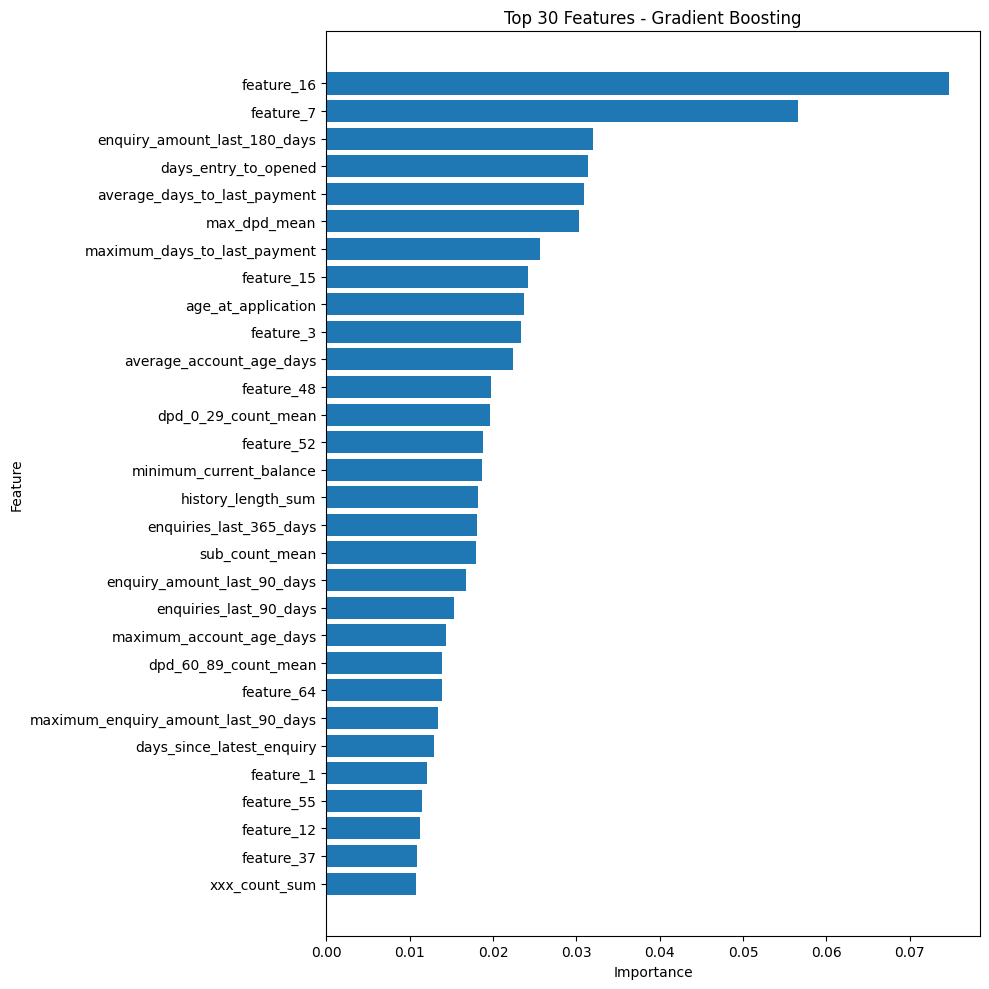

In [550]:
# Plot top 30 original features by Gradient Boosting importance

top_30_features = (
    original_feature_importance_df
    .head(30)
    .sort_values("Importance", ascending=True)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

plt.barh(
    top_30_features["Original_Feature"],
    top_30_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 30 Features - Gradient Boosting")
plt.tight_layout()

plt.show()

In [551]:
# Calculate cumulative feature importance

feature_importance_analysis = original_feature_importance_df.copy()

feature_importance_analysis["Cumulative_Importance"] = (
    feature_importance_analysis["Importance"].cumsum()
)

display(
    feature_importance_analysis.head(30)
)

,Original_Feature,Importance,Cumulative_Importance
0,feature_16,0.074711,0.074711
1,feature_7,0.056607,0.131319
2,enquiry_amount_last_180_days,0.032056,0.163375
3,days_entry_to_opened,0.031464,0.194839
4,average_days_to_last_payment,0.030970,0.225809
5,max_dpd_mean,0.030357,0.256166
6,maximum_days_to_last_payment,0.025692,0.281858
7,feature_15,0.024181,0.306038
8,age_at_application,0.023670,0.329708
9,feature_3,0.023338,0.353046


In [552]:
# Check cumulative importance at different feature counts

feature_counts = [10, 20, 30, 40, 50, 75, 100, 125, 150, 161]

cumulative_summary = []

for count in feature_counts:
    cumulative_summary.append({
        "Feature_Count": count,
        "Cumulative_Importance": (
            feature_importance_analysis
            .iloc[count - 1]["Cumulative_Importance"]
        )
    })

cumulative_summary_df = pd.DataFrame(cumulative_summary)

cumulative_summary_df["Cumulative_Importance"] = (
    cumulative_summary_df["Cumulative_Importance"].round(4)
)

display(cumulative_summary_df)

,Feature_Count,Cumulative_Importance
0,10,0.3530
1,20,0.5386
2,30,0.6637
3,40,0.7562
4,50,0.8244
5,75,0.9323
6,100,0.9883
7,125,1.0000
8,150,1.0000
9,161,1.0000


**Finding.** Importance is concentrated: the top 10 features hold 35% of total importance, the top 30 hold 66%, the top 75 hold 93% and the top 100 hold 99%. Only about 125 of the 161 features have any importance. `feature_16` (522 categories) ranks first in the full model.

In [553]:
# Select top 75 original features based on Gradient Boosting importance

selected_features_75 = (
    original_feature_importance_df
    .head(75)["Original_Feature"]
    .tolist()
)

print("Selected features:", len(selected_features_75))
print("\nFirst 20 selected features:")
print(selected_features_75[:20])

Selected features: 75

First 20 selected features:
['feature_16', 'feature_7', 'enquiry_amount_last_180_days', 'days_entry_to_opened', 'average_days_to_last_payment', 'max_dpd_mean', 'maximum_days_to_last_payment', 'feature_15', 'age_at_application', 'feature_3', 'average_account_age_days', 'feature_48', 'dpd_0_29_count_mean', 'feature_52', 'minimum_current_balance', 'history_length_sum', 'enquiries_last_365_days', 'sub_count_mean', 'enquiry_amount_last_90_days', 'enquiries_last_90_days']


In [554]:
# Create reduced train/test datasets using the selected 75 features

X_train_75 = X_train[selected_features_75].copy()
X_test_75 = X_test[selected_features_75].copy()

print("Original training shape:", X_train.shape)
print("Reduced training shape:", X_train_75.shape)

print("Original test shape:", X_test.shape)
print("Reduced test shape:", X_test_75.shape)

Original training shape: (19116, 161)
Reduced training shape: (19116, 75)
Original test shape: (4780, 161)
Reduced test shape: (4780, 75)


In [555]:
# Identify numeric and categorical features among the selected 75

numeric_features_75 = [
    column for column in selected_features_75
    if column in numeric_features
]

categorical_features_75 = [
    column for column in selected_features_75
    if column in categorical_features
]

print("Selected numeric features:", len(numeric_features_75))
print("Selected categorical features:", len(categorical_features_75))
print("Total selected features:", 
      len(numeric_features_75) + len(categorical_features_75))

Selected numeric features: 62
Selected categorical features: 13
Total selected features: 75


In [556]:
# Preprocessor for the selected 75 features

numeric_pipeline_75 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline_75 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=10
        ))
    ]
)

preprocessor_75 = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline_75, numeric_features_75),
        ("categorical", categorical_pipeline_75, categorical_features_75)
    ]
)

print("75-feature preprocessor created successfully.")

75-feature preprocessor created successfully.


In [557]:
# Gradient Boosting model using the selected 75 features

gradient_boosting_75_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_75),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

gradient_boosting_75_pipeline.fit(
    X_train_75,
    y_train
)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [558]:
# Predictions from the 75-feature Gradient Boosting model

y_pred_75 = gradient_boosting_75_pipeline.predict(X_test_75)
y_pred_proba_75 = gradient_boosting_75_pipeline.predict_proba(X_test_75)[:, 1]

# Evaluation metrics
accuracy_75 = accuracy_score(y_test, y_pred_75)
precision_75 = precision_score(y_test, y_pred_75, zero_division=0)
recall_75 = recall_score(y_test, y_pred_75, zero_division=0)
f1_75 = f1_score(y_test, y_pred_75, zero_division=0)
roc_auc_75 = roc_auc_score(y_test, y_pred_proba_75)
gini_75 = 2 * roc_auc_75 - 1

print("Gradient Boosting — 75 Features")
print("-" * 40)
print(f"Accuracy : {accuracy_75:.4f}")
print(f"Precision: {precision_75:.4f}")
print(f"Recall   : {recall_75:.4f}")
print(f"F1 Score : {f1_75:.4f}")
print(f"ROC-AUC  : {roc_auc_75:.4f}")
print(f"Gini     : {gini_75:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_75))

Gradient Boosting — 75 Features
----------------------------------------
Accuracy : 0.9561
Precision: 0.1538
Recall   : 0.0100
F1 Score : 0.0187
ROC-AUC  : 0.6614
Gini     : 0.3229

Confusion Matrix:
[[4568   11]
 [ 199    2]]


In [559]:
# Select top 50 original features based on Gradient Boosting importance

selected_features_50 = (
    original_feature_importance_df
    .head(50)["Original_Feature"]
    .tolist()
)

print("Selected features:", len(selected_features_50))

print("\nSelected 50 features:")
print(selected_features_50)

Selected features: 50

Selected 50 features:
['feature_16', 'feature_7', 'enquiry_amount_last_180_days', 'days_entry_to_opened', 'average_days_to_last_payment', 'max_dpd_mean', 'maximum_days_to_last_payment', 'feature_15', 'age_at_application', 'feature_3', 'average_account_age_days', 'feature_48', 'dpd_0_29_count_mean', 'feature_52', 'minimum_current_balance', 'history_length_sum', 'enquiries_last_365_days', 'sub_count_mean', 'enquiry_amount_last_90_days', 'enquiries_last_90_days', 'maximum_account_age_days', 'dpd_60_89_count_mean', 'feature_64', 'maximum_enquiry_amount_last_90_days', 'days_since_latest_enquiry', 'feature_1', 'feature_55', 'feature_12', 'feature_37', 'xxx_count_sum', 'average_days_to_closure', 'most_frequent_enquiry_purpose', 'xxx_count_mean', 'maximum_days_to_closure', 'average_enquiry_amount', 'feature_63_year', 'most_frequent_purpose_count', 'std_count_sum', 'history1_900_count_mean', 'numeric_dpd_count_sum', 'maximum_high_credit', 'feature_43', 'average_current_ba

In [560]:
# Create reduced train/test datasets using the selected 50 features

X_train_50 = X_train[selected_features_50].copy()
X_test_50 = X_test[selected_features_50].copy()

print("Original training shape:", X_train.shape)
print("Reduced training shape:", X_train_50.shape)

print("Original test shape:", X_test.shape)
print("Reduced test shape:", X_test_50.shape)

Original training shape: (19116, 161)
Reduced training shape: (19116, 50)
Original test shape: (4780, 161)
Reduced test shape: (4780, 50)


In [561]:
# Identify numeric and categorical features among the selected 50

numeric_features_50 = [
    column for column in selected_features_50
    if column in numeric_features
]

categorical_features_50 = [
    column for column in selected_features_50
    if column in categorical_features
]

print("Selected numeric features:", len(numeric_features_50))
print("Selected categorical features:", len(categorical_features_50))
print("Total selected features:",
      len(numeric_features_50) + len(categorical_features_50))

print("\nNumeric features:")
print(numeric_features_50)

print("\nCategorical features:")
print(categorical_features_50)

Selected numeric features: 40
Selected categorical features: 10
Total selected features: 50

Numeric features:
['feature_7', 'enquiry_amount_last_180_days', 'days_entry_to_opened', 'average_days_to_last_payment', 'max_dpd_mean', 'maximum_days_to_last_payment', 'age_at_application', 'feature_3', 'average_account_age_days', 'dpd_0_29_count_mean', 'feature_52', 'minimum_current_balance', 'history_length_sum', 'enquiries_last_365_days', 'sub_count_mean', 'enquiry_amount_last_90_days', 'enquiries_last_90_days', 'maximum_account_age_days', 'dpd_60_89_count_mean', 'maximum_enquiry_amount_last_90_days', 'days_since_latest_enquiry', 'xxx_count_sum', 'average_days_to_closure', 'xxx_count_mean', 'maximum_days_to_closure', 'average_enquiry_amount', 'feature_63_year', 'most_frequent_purpose_count', 'std_count_sum', 'history1_900_count_mean', 'numeric_dpd_count_sum', 'maximum_high_credit', 'average_current_balance', 'days_feature2_to_opened', 'median_enquiry_amount', 'feature_65', 'std_count_mean', 

In [562]:
# Preprocessor for the selected 50 features

numeric_pipeline_50 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline_50 = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=10
        ))
    ]
)

preprocessor_50 = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline_50, numeric_features_50),
        ("categorical", categorical_pipeline_50, categorical_features_50)
    ]
)

print("50-feature preprocessor created successfully.")

50-feature preprocessor created successfully.


In [563]:
gradient_boosting_50_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_50),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

gradient_boosting_50_pipeline.fit(
    X_train_50,
    y_train
)

print("Gradient Boosting model with 50 features trained successfully.")

Gradient Boosting model with 50 features trained successfully.


In [564]:
# Predictions from the 50-feature Gradient Boosting model

y_pred_50 = gradient_boosting_50_pipeline.predict(X_test_50)
y_pred_proba_50 = gradient_boosting_50_pipeline.predict_proba(X_test_50)[:, 1]

# Evaluation metrics
accuracy_50 = accuracy_score(y_test, y_pred_50)
precision_50 = precision_score(y_test, y_pred_50, zero_division=0)
recall_50 = recall_score(y_test, y_pred_50, zero_division=0)
f1_50 = f1_score(y_test, y_pred_50, zero_division=0)
roc_auc_50 = roc_auc_score(y_test, y_pred_proba_50)
gini_50 = 2 * roc_auc_50 - 1

print("Gradient Boosting — 50 Features")
print("-" * 40)
print(f"Accuracy : {accuracy_50:.4f}")
print(f"Precision: {precision_50:.4f}")
print(f"Recall   : {recall_50:.4f}")
print(f"F1 Score : {f1_50:.4f}")
print(f"ROC-AUC  : {roc_auc_50:.4f}")
print(f"Gini     : {gini_50:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_50))


Gradient Boosting — 50 Features
----------------------------------------
Accuracy : 0.9554
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.6597
Gini     : 0.3193

Confusion Matrix:
[[4567   12]
 [ 201    0]]


**Finding.** 75 features give ROC-AUC 0.661 (Gini 0.323) vs 0.657 with all 161, and 50 features give 0.660. Fewer features perform as well or better, so 75 is kept as a compromise between simplicity and retained importance (93%).

## Hyperparameter tuning
Ten Gradient Boosting configurations on the 75 features, in two rounds of five. Shallow trees (depth 2) with small leaves work best.

In [565]:
# Hyperparameter configurations for Gradient Boosting
# Using the selected 75 features

gb_param_configs = [
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 20,
        "subsample": 0.8
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 20,
        "subsample": 0.8
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_samples_leaf": 20,
        "subsample": 0.8
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_samples_leaf": 20,
        "subsample": 0.8
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_samples_leaf": 30,
        "subsample": 0.8
    }
]

print("Configurations to test:", len(gb_param_configs))

for i, params in enumerate(gb_param_configs, start=1):
    print(f"\nConfiguration {i}:")
    print(params)
    

Configurations to test: 5

Configuration 1:
{'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 20, 'subsample': 0.8}

Configuration 2:
{'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 20, 'subsample': 0.8}

Configuration 3:
{'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 3, 'min_samples_leaf': 20, 'subsample': 0.8}

Configuration 4:
{'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 3, 'min_samples_leaf': 20, 'subsample': 0.8}

Configuration 5:
{'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 30, 'subsample': 0.8}


In [566]:
# Train and evaluate all 5 Gradient Boosting configurations

gb_tuning_results = []

for i, params in enumerate(gb_param_configs, start=1):

    model = GradientBoostingClassifier(
        **params,
        random_state=42
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_75),
            ("model", model)
        ]
    )

    pipeline.fit(X_train_75, y_train)

    y_pred = pipeline.predict(X_test_75)
    y_pred_proba = pipeline.predict_proba(X_test_75)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    gini = 2 * roc_auc - 1

    gb_tuning_results.append({
        "Configuration": i,
        "n_estimators": params["n_estimators"],
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "subsample": params["subsample"],
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "Gini": gini
    })

gb_tuning_results_df = pd.DataFrame(gb_tuning_results)

print(gb_tuning_results_df.round(4).to_string(index=False))

 Configuration  n_estimators  learning_rate  max_depth  min_samples_leaf  subsample  Accuracy  Precision  Recall  F1  ROC_AUC   Gini
             1           100           0.05          2                20        0.8    0.9579        0.0     0.0 0.0   0.6516 0.3032
             2           200           0.05          2                20        0.8    0.9579        0.0     0.0 0.0   0.6604 0.3208
             3           200           0.03          3                20        0.8    0.9579        0.0     0.0 0.0   0.6590 0.3180
             4           300           0.03          3                20        0.8    0.9579        0.0     0.0 0.0   0.6581 0.3162
             5           200           0.05          3                30        0.8    0.9579        0.0     0.0 0.0   0.6527 0.3053


In [567]:
gb_param_configs_2 = [
    {
        "n_estimators": 150,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 10,
        "subsample": 0.8
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 10,
        "subsample": 0.8
    },
    {
        "n_estimators": 250,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 10,
        "subsample": 0.8
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.04,
        "max_depth": 2,
        "min_samples_leaf": 20,
        "subsample": 0.8
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.06,
        "max_depth": 2,
        "min_samples_leaf": 20,
        "subsample": 0.8
    }
]

gb_tuning_results_2 = []

for i, params in enumerate(gb_param_configs_2, start=1):

    model = GradientBoostingClassifier(
        **params,
        random_state=42
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_75),
            ("model", model)
        ]
    )

    pipeline.fit(X_train_75, y_train)

    y_pred = pipeline.predict(X_test_75)
    y_pred_proba = pipeline.predict_proba(X_test_75)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    gini = 2 * roc_auc - 1

    gb_tuning_results_2.append({
        "Configuration": i,
        "n_estimators": params["n_estimators"],
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "subsample": params["subsample"],
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "Gini": gini
    })

gb_tuning_results_2_df = pd.DataFrame(gb_tuning_results_2)

print(gb_tuning_results_2_df.round(4).to_string(index=False))

 Configuration  n_estimators  learning_rate  max_depth  min_samples_leaf  subsample  Accuracy  Precision  Recall  F1  ROC_AUC   Gini
             1           150           0.05          2                10        0.8    0.9579        0.0     0.0 0.0   0.6632 0.3263
             2           200           0.05          2                10        0.8    0.9577        0.0     0.0 0.0   0.6613 0.3225
             3           250           0.05          2                10        0.8    0.9575        0.0     0.0 0.0   0.6630 0.3260
             4           200           0.04          2                20        0.8    0.9579        0.0     0.0 0.0   0.6626 0.3251
             5           200           0.06          2                20        0.8    0.9579        0.0     0.0 0.0   0.6615 0.3231


**Finding.** All ten configurations land between ROC-AUC 0.652 and 0.663. Best: 150 trees, learning rate 0.05, depth 2, min leaf 10, subsample 0.8 (ROC-AUC 0.6632, Gini 0.3263). **Caveat:** configurations were compared on the test set, so this score is slightly optimistic.

In [568]:
best_gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_75),
        ("model", GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=2,
            min_samples_leaf=10,
            subsample=0.8,
            random_state=42
        ))
    ]
)

best_gb_pipeline.fit(X_train_75, y_train)

best_gb_pred_proba = best_gb_pipeline.predict_proba(X_test_75)[:, 1]

print("Best tuned Gradient Boosting model fitted successfully.")

Best tuned Gradient Boosting model fitted successfully.


In [569]:
# Top 3 models on 75 selected features

top3_models = {
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        random_seed=42,
        verbose=False
    )
}

top3_results = []

for model_name, model in top3_models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor_75),
            ("model", model)
        ]
    )

    pipeline.fit(X_train_75, y_train)

    y_pred = pipeline.predict(X_test_75)
    y_pred_proba = pipeline.predict_proba(X_test_75)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    gini = 2 * roc_auc - 1

    top3_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc,
        "Gini": gini
    })

top3_results_df = pd.DataFrame(top3_results)

print(top3_results_df.round(4).to_string(index=False))

            Model  Accuracy  Precision  Recall     F1  ROC_AUC   Gini
Gradient Boosting    0.9579     0.0000   0.000 0.0000   0.6632 0.3263
         LightGBM    0.9577     0.3333   0.005 0.0098   0.6367 0.2734
         CatBoost    0.9579     0.0000   0.000 0.0000   0.6530 0.3059


**Finding.** With the same 75 features, tuned Gradient Boosting (ROC-AUC 0.663) beats CatBoost (0.653) and LightGBM (0.637).

## Final model evaluation

In [570]:
# Rank ordering analysis for the best tuned Gradient Boosting model

ranking_df = pd.DataFrame({
    "actual_bad": y_test.to_numpy(),
    "predicted_probability": best_gb_pred_proba
})

# Rank customers from highest predicted risk to lowest
ranking_df = (
    ranking_df
    .sort_values("predicted_probability", ascending=False)
    .reset_index(drop=True)
)

# Divide customers into 10 equal-sized groups
ranking_df["decile"] = (
    pd.qcut(
        ranking_df.index,
        q=10,
        labels=False
    ) + 1
)

# Calculate decile-level statistics
decile_analysis = (
    ranking_df
    .groupby("decile")
    .agg(
        customers=("actual_bad", "count"),
        bad_customers=("actual_bad", "sum"),
        average_predicted_probability=("predicted_probability", "mean")
    )
    .reset_index()
)

# Bad rate within each decile
decile_analysis["bad_rate"] = (
    decile_analysis["bad_customers"]
    / decile_analysis["customers"]
)

# Cumulative bad customers
decile_analysis["cumulative_bad_customers"] = (
    decile_analysis["bad_customers"].cumsum()
)

# Total actual bad customers
total_bad = decile_analysis["bad_customers"].sum()

# Cumulative percentage of all bad customers captured
decile_analysis["cumulative_bad_capture"] = (
    decile_analysis["cumulative_bad_customers"]
    / total_bad
    * 100
)

print(
    decile_analysis.round(4).to_string(index=False)
)

 decile  customers  bad_customers  average_predicted_probability  bad_rate  cumulative_bad_customers  cumulative_bad_capture
      1        478             46                         0.1050    0.0962                        46                 22.8856
      2        478             26                         0.0629    0.0544                        72                 35.8209
      3        478             36                         0.0502    0.0753                       108                 53.7313
      4        478             21                         0.0421    0.0439                       129                 64.1791
      5        478             17                         0.0365    0.0356                       146                 72.6368
      6        478             13                         0.0317    0.0272                       159                 79.1045
      7        478             14                         0.0276    0.0293                       173                 86.0697


**Finding.** Top-decile bad rate is 9.6% (2.3x the 4.2% average) and the bottom decile 0.8%. The top decile captures 22.9% of bad customers, the top three deciles 53.7% and the top five 72.6%. Ordering is mostly monotonic, but decile 3 (7.5%) is above decile 2 (5.4%); with only 26 and 36 bad customers in those deciles this is sensitive to noise.

In [571]:
# Step 19: Threshold Analysis

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        best_gb_pred_proba >= threshold
    ).astype(int)

    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    predicted_bad_customers = y_pred_threshold.sum()

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Predicted_Bad_Customers": predicted_bad_customers
    })

threshold_results_df = pd.DataFrame(threshold_results)

print(
    threshold_results_df.round(4).to_string(index=False)
)

 Threshold  Accuracy  Precision  Recall     F1  Predicted_Bad_Customers
      0.05    0.7467     0.0778  0.4627 0.1331                     1196
      0.10    0.9293     0.1040  0.0896 0.0963                      173
      0.15    0.9492     0.1111  0.0299 0.0471                       54
      0.20    0.9548     0.1053  0.0100 0.0182                       19
      0.25    0.9571     0.1667  0.0050 0.0097                        6
      0.30    0.9573     0.0000  0.0000 0.0000                        3
      0.35    0.9573     0.0000  0.0000 0.0000                        3
      0.40    0.9575     0.0000  0.0000 0.0000                        2
      0.45    0.9579     0.0000  0.0000 0.0000                        0
      0.50    0.9579     0.0000  0.0000 0.0000                        0


**Finding.** Predicted probabilities are low (average 10.5% in the top decile), so a 0.5 cut-off flags nobody. A 0.05 threshold flags 1,196 customers and catches 46.3% of bad customers (precision 7.8%); 0.10 flags 173 (recall 9.0%, precision 10.4%). Choosing a threshold is a trade-off between review workload and recall. The model is best used as a ranking score.

In [572]:
# Step 20: Final Model Evaluation Summary

final_model_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Selected Features",
        "n_estimators",
        "learning_rate",
        "max_depth",
        "min_samples_leaf",
        "subsample",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Gini",
        "Project Benchmark Gini",
        "Benchmark Gap"
    ],
    "Value": [
        "Gradient Boosting Classifier",
        75,
        150,
        0.05,
        2,
        10,
        0.8,
        0.9579,
        0.0000,
        0.0000,
        0.0000,
        0.6632,
        0.3263,
        0.3790,
        0.3790 - 0.3263
    ]
})

final_model_summary

,Metric,Value
0,Model,Gradient Boosting Classifier
1,Selected Features,75
2,n_estimators,150
3,learning_rate,0.05
4,max_depth,2
5,min_samples_leaf,10
6,subsample,0.8
7,Accuracy,0.9579
8,Precision,0.0
9,Recall,0.0


In [573]:
print("Final Model Evaluation")
print("=" * 50)
print(final_model_summary.to_string(index=False))

Final Model Evaluation
                Metric                        Value
                 Model Gradient Boosting Classifier
     Selected Features                           75
          n_estimators                          150
         learning_rate                         0.05
             max_depth                            2
      min_samples_leaf                           10
             subsample                          0.8
              Accuracy                       0.9579
             Precision                          0.0
                Recall                          0.0
              F1 Score                          0.0
               ROC-AUC                       0.6632
                  Gini                       0.3263
Project Benchmark Gini                        0.379
         Benchmark Gap                       0.0527


**Finding.** Final model: ROC-AUC 0.663, Gini 0.326 vs the project benchmark Gini 0.379 (gap 0.053), so the benchmark is **not reached**. The 95.8% accuracy and zero precision / recall at 0.5 reflect the class imbalance, not a bug.

## Interpretation
Feature importance of the final model and a comparison of the most important features between good and bad customers.

In [574]:
# Step 21: Final Model Feature Importance

final_preprocessor = best_gb_pipeline.named_steps["preprocessor"]
final_gb_model = best_gb_pipeline.named_steps["model"]

final_feature_names = final_preprocessor.get_feature_names_out()
final_importances = final_gb_model.feature_importances_

final_feature_importance_df = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": final_importances
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("Number of transformed features:", len(final_feature_names))
print("Number of importance values:", len(final_importances))

final_feature_importance_df.head(30)

Number of transformed features: 492
Number of importance values: 492


,Feature,Importance
0,numeric__feature_7,0.105112
1,numeric__max_dpd_mean,0.046227
2,numeric__feature_52,0.042222
3,numeric__dpd_0_29_count_mean,0.040775
4,numeric__maximum_days_to_closure,0.037009
5,numeric__average_days_to_last_payment,0.036123
6,numeric__average_account_age_days,0.034126
7,numeric__enquiry_amount_last_180_days,0.030689
8,numeric__days_entry_to_opened,0.030598
9,numeric__enquiries_last_365_days,0.030139


In [575]:
# Map transformed features back to original features

def get_final_original_feature(transformed_feature):
    if transformed_feature.startswith("numeric__"):
        return transformed_feature.replace("numeric__", "", 1)

    elif transformed_feature.startswith("categorical__"):
        feature = transformed_feature.replace("categorical__", "", 1)

        for column in categorical_features_75:
            if feature == column or feature.startswith(column + "_"):
                return column

        return feature

    return transformed_feature


final_feature_importance_df["Original_Feature"] = (
    final_feature_importance_df["Feature"]
    .apply(get_final_original_feature)
)

final_original_feature_importance_df = (
    final_feature_importance_df
    .groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

final_original_feature_importance_df["Cumulative_Importance"] = (
    final_original_feature_importance_df["Importance"].cumsum()
)

print("Number of original features:",
      len(final_original_feature_importance_df))

final_original_feature_importance_df.head(30)

Number of original features: 75


,Original_Feature,Importance,Cumulative_Importance
0,feature_7,0.105112,0.105112
1,max_dpd_mean,0.046227,0.151339
2,feature_12,0.045224,0.196563
3,feature_52,0.042222,0.238785
4,dpd_0_29_count_mean,0.040775,0.279560
5,maximum_days_to_closure,0.037009,0.316569
6,average_days_to_last_payment,0.036123,0.352692
7,average_account_age_days,0.034126,0.386818
8,enquiry_amount_last_180_days,0.030689,0.417506
9,days_entry_to_opened,0.030598,0.448104


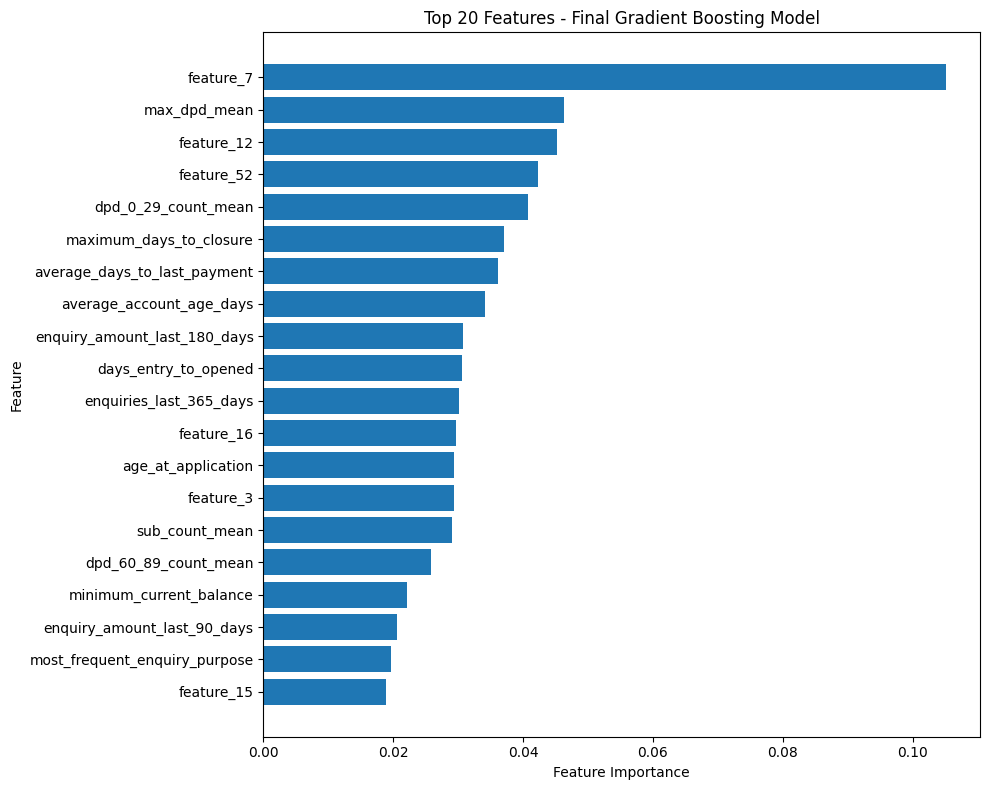

In [576]:
import matplotlib.pyplot as plt

top_20_features = (
    final_original_feature_importance_df
    .head(20)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_20_features["Original_Feature"],
    top_20_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features - Final Gradient Boosting Model")

plt.tight_layout()
plt.show()

**Finding.** Top features by importance: `feature_7` (10.5%), `max_dpd_mean` (4.6%), `feature_12` (4.5%), `feature_52` (4.2%), `dpd_0_29_count_mean` (4.1%). The top 20 features hold about 70% of importance and no single driver dominates, consistent with a modest Gini. Importance shows what the model uses, not the direction or a causal effect.

In [577]:
# Step 23: Business Insight Summary

top_business_features = [
    "feature_7",
    "max_dpd_mean",
    "feature_12",
    "feature_52",
    "dpd_0_29_count_mean",
    "maximum_days_to_closure",
    "average_days_to_last_payment",
    "average_account_age_days",
    "enquiry_amount_last_180_days",
    "days_entry_to_opened",
    "enquiries_last_365_days",
    "feature_16",
    "age_at_application",
    "feature_3",
    "sub_count_mean"
]

business_feature_summary = final_customer_features[
    top_business_features
].describe(include="all").T

business_feature_summary

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
feature_7,23881.0,NaN,NaN,NaN,119070.503748,77523.485085,0.0,72000.0,104000.0,139000.0,1217000.0
max_dpd_mean,23896.0,NaN,NaN,NaN,10.003532,34.261356,0.0,0.0,0.0,3.848901,900.0
feature_12,23881,16,PM1,8853,NaN,NaN,NaN,NaN,NaN,NaN,NaN
feature_52,23881.0,NaN,NaN,NaN,65000.733679,100822.463404,0.0,0.0,50000.0,100000.0,3777000.0
dpd_0_29_count_mean,23896.0,NaN,NaN,NaN,13.731215,6.410156,0.0,9.0,13.125,17.75,36.0
maximum_days_to_closure,17007.0,NaN,NaN,NaN,1181.522256,979.005465,0.0,450.5,888.0,1662.5,10494.0
average_days_to_last_payment,23845.0,NaN,NaN,NaN,689.874766,455.291054,0.0,362.0,579.1,899.916667,8517.0
average_account_age_days,23896.0,NaN,NaN,NaN,881.918791,616.982554,37.0,424.666667,705.0,1183.0,7700.0
enquiry_amount_last_180_days,23787.0,NaN,NaN,NaN,870461.336949,11798523.844549,0.0,0.0,50000.0,251000.0,1150010001.0
days_entry_to_opened,23881.0,NaN,NaN,NaN,27.661698,22.006406,0.0,15.0,21.0,32.0,288.0


In [578]:
# Step 23: Compare Important Features by Target

business_analysis_df = final_customer_features[
    top_business_features
].copy()

business_analysis_df["Bad_label"] = y_model.to_numpy()

numeric_business_features = [
    "feature_7",
    "max_dpd_mean",
    "feature_52",
    "dpd_0_29_count_mean",
    "maximum_days_to_closure",
    "average_days_to_last_payment",
    "average_account_age_days",
    "enquiry_amount_last_180_days",
    "days_entry_to_opened",
    "enquiries_last_365_days",
    "age_at_application",
    "feature_3",
    "sub_count_mean"
]

target_comparison = (
    business_analysis_df
    .groupby("Bad_label")[numeric_business_features]
    .mean()
    .T
)

target_comparison.columns = [
    "Good_Customers",
    "Bad_Customers"
]

target_comparison["Difference"] = (
    target_comparison["Bad_Customers"]
    - target_comparison["Good_Customers"]
)

target_comparison

,Good_Customers,Bad_Customers,Difference
feature_7,120034.954979,9.707178e+04,-22963.170333
max_dpd_mean,9.826154,1.404789e+01,4.221737
feature_52,66134.201853,3.914681e+04,-26987.391285
dpd_0_29_count_mean,13.800682,1.214733e+01,-1.653351
maximum_days_to_closure,1184.328827,1.112118e+03,-72.210824
average_days_to_last_payment,694.333388,5.882298e+02,-106.103633
average_account_age_days,887.224465,7.609452e+02,-126.279286
enquiry_amount_last_180_days,857753.137084,1.160649e+06,302895.741674
days_entry_to_opened,27.577367,2.958524e+01,2.007877
enquiries_last_365_days,4.525999,5.856713e+00,1.330714


**Finding.** Compared with good customers, bad customers on average have: lower `feature_7` (about 97k vs 120k) and `feature_52` (about 39k vs 66k); a higher average maximum DPD (14.0 vs 9.8); younger accounts (about 761 vs 887 days) and a shorter time between opening and last payment (about 588 vs 694 days); more enquiries in the last 365 days (5.9 vs 4.5) and larger enquiry amounts in the last 180 days (about 1.16M vs 0.86M); and are slightly younger (33.2 vs 34.1) with a lower credit score (715 vs 724). `feature_7` and `feature_52` are anonymised but look amount-like.

## Saving the model
The tuned pipeline (preprocessing + Gradient Boosting on 75 features) is saved with `joblib` to `../model/` (that folder must exist), reloaded and checked to give identical predictions.

In [579]:
import joblib

joblib.dump(
    best_gb_pipeline,
    "../model/banking_risk_gb_pipeline.pkl"
)

['../model/banking_risk_gb_pipeline.pkl']

In [580]:
loaded_model = joblib.load(
    "../model/banking_risk_gb_pipeline.pkl"
)

test_proba = loaded_model.predict_proba(X_test_75)[:, 1]

print(test_proba[:5])

[0.04564142 0.06837905 0.05028012 0.04745882 0.02164447]


In [581]:
# Verify saved model produces identical predictions

import numpy as np

loaded_proba = loaded_model.predict_proba(X_test_75)[:, 1]

print(
    "Predictions identical:",
    np.allclose(best_gb_pred_proba, loaded_proba)
)

print(
    "Maximum probability difference:",
    np.max(np.abs(best_gb_pred_proba - loaded_proba))
)

Predictions identical: True
Maximum probability difference: 0.0


**Finding.** The reloaded pipeline reproduces the original predictions exactly (maximum probability difference 0.0).

In [2]:
import os

model_path = "../model/banking_risk_gb_pipeline.pkl"

print("Model exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Model size (KB):", round(os.path.getsize(model_path) / 1024, 2))
    print("Model path:", os.path.abspath(model_path))

Model exists: True
Model size (KB): 153.14
Model path: d:\DataScience-Projects\Banking_Risk_Prediction\model\banking_risk_gb_pipeline.pkl


## Final Conclusion

This project developed a machine learning-based banking risk prediction system to identify customers with a higher likelihood of being classified as bad customers.

The project followed a complete machine learning workflow, including data understanding, data quality assessment, preprocessing, exploratory analysis, feature selection, multiple baseline model evaluation, rank-ordering analysis, hyperparameter tuning, threshold analysis, and final model evaluation.

Several classification algorithms were evaluated, including Logistic Regression, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, XGBoost, LightGBM, and CatBoost. Gradient Boosting was selected for the final model based on its overall rank-ordering performance among the evaluated models.

Feature selection reduced the original feature space from 161 features to 75 selected features. After preprocessing and one-hot encoding, these resulted in 492 transformed features used by the final model.

The final Gradient Boosting model used the following configuration:

* Number of estimators: 150
* Learning rate: 0.05
* Maximum depth: 2
* Minimum samples per leaf: 10
* Subsample: 0.8

On the test dataset, the final model achieved:

* Accuracy: 95.79%
* ROC-AUC: 0.6632
* Gini: 32.63%

The model also demonstrated useful rank-ordering capability. It captured approximately 22.89% of bad customers within the top 10% of customers ranked by predicted risk, 35.82% within the top 20%, 53.73% within the top 30%, and 72.64% within the top 50%.

However, the final Gini of 32.63% remained below the project benchmark of 37.9%, representing a gap of 5.27 percentage points. Therefore, the model demonstrates meaningful predictive and ranking capability but does not fully reach the defined project benchmark.

Feature-importance analysis showed that payment behaviour, account history, and recent credit-enquiry activity were important components of the model's predictions. The strongest original features included `feature_7`, `max_dpd_mean`, `feature_12`, `feature_52`, `dpd_0_29_count_mean`, `maximum_days_to_closure`, and `average_days_to_last_payment`.

The final trained preprocessing and Gradient Boosting model were saved together as a single pipeline, allowing the same preprocessing and prediction workflow to be reused on new customer data.

Overall, the project demonstrates an end-to-end approach to building, evaluating, interpreting, and deploying a credit-risk classification model while explicitly accounting for class imbalance and business-oriented rank-ordering performance.
